# Chapter 4: corrected experimental pipeline for approximate EASE

This notebook runs the experimental protocol for Chapter 4 with a strict baseline policy:

1. Full-catalog dense exact EASE is skipped by default and exact EASE is used only as a small-subset correctness/sanity check.
2. The main runtime/quality comparison does not include full dense exact EASE.
3. External baselines are deliberately limited to ALS and SLIM-ElasticNet. Popularity, UserKNN, PureSVD, and extra weak baselines are not part of the main protocol.
4. A selected configuration with `nystrom_rank=0` is named as Block CG, not Block PCG.
5. RSS peak memory is reported as a diagnostic measurement, not as exact algorithmic memory.
6. Analytical memory is reported separately using the formula  
   `O(nnz(X) + (M + N)b + Nk + N*L_keep)`.
7. Validation selection and final test evaluation remain separated.

The goal is not to manufacture a runtime win over dense LAPACK on a small catalogue. The goal is to report a defensible comparison in the target protocol: iterative EASE variants versus strong practical baselines, specifically ALS and SLIM, with exact EASE kept outside the main comparison.


In [1]:
# 0. Dependency bootstrap
# Run this cell before imports. It installs missing dependencies inside the active Jupyter kernel.
# On macOS/Apple Silicon, `implicit` usually has wheels, but if installation fails the notebook
# will continue and mark ALS as skipped unless `require_als_baseline=True` in config.

import importlib.util
import subprocess
import sys

AUTO_INSTALL_CORE_DEPS = True
AUTO_INSTALL_OPTIONAL_DEPS = True
UPGRADE_PIP_BEFORE_INSTALL = False

CORE_DEPENDENCIES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "psutil": "psutil",
    "yaml": "pyyaml",
    "threadpoolctl": "threadpoolctl",
    "tqdm": "tqdm",
}

OPTIONAL_DEPENDENCIES = {
    "implicit": "implicit",
}


def _missing_packages(import_to_pip: dict[str, str]) -> list[str]:
    missing = []
    for import_name, pip_name in import_to_pip.items():
        if importlib.util.find_spec(import_name) is None:
            missing.append(pip_name)
    return sorted(set(missing))


def _pip_install(packages: list[str], label: str) -> dict:
    if not packages:
        return {"label": label, "status": "already_installed", "packages": []}
    cmd = [sys.executable, "-m", "pip", "install", *packages]
    try:
        if UPGRADE_PIP_BEFORE_INSTALL:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "setuptools", "wheel"])
        subprocess.check_call(cmd)
        return {"label": label, "status": "installed", "packages": packages}
    except Exception as exc:
        return {"label": label, "status": "install_failed", "packages": packages, "error": f"{type(exc).__name__}: {exc}"}

bootstrap_report = []
core_missing = _missing_packages(CORE_DEPENDENCIES)
optional_missing = _missing_packages(OPTIONAL_DEPENDENCIES)

if core_missing and AUTO_INSTALL_CORE_DEPS:
    bootstrap_report.append(_pip_install(core_missing, "core"))
else:
    bootstrap_report.append({"label": "core", "status": "missing_but_not_installed" if core_missing else "already_installed", "packages": core_missing})

if optional_missing and AUTO_INSTALL_OPTIONAL_DEPS:
    bootstrap_report.append(_pip_install(optional_missing, "optional"))
else:
    bootstrap_report.append({"label": "optional", "status": "missing_but_not_installed" if optional_missing else "already_installed", "packages": optional_missing})

print("Dependency bootstrap report:")
for row in bootstrap_report:
    print(row)

# The following import cell reads the updated environment. If `implicit` installation failed,
# ALS will be explicitly recorded as skipped rather than silently ignored.


Dependency bootstrap report:
{'label': 'core', 'status': 'already_installed', 'packages': []}
{'label': 'optional', 'status': 'already_installed', 'packages': []}


In [2]:
# 1. Environment and imports

import copy
import gc
import inspect
import json
import math
import os
import platform
import sys
import threading
import time
import traceback
from contextlib import nullcontext
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy import sparse

try:
    import sklearn
    SKLEARN_VERSION = sklearn.__version__
except Exception:
    SKLEARN_VERSION = None

try:
    import implicit
    IMPLICIT_VERSION = implicit.__version__
except Exception:
    IMPLICIT_VERSION = None

try:
    import psutil
except Exception as e:
    raise RuntimeError("psutil is required for peak-memory tracking") from e


try:
    from threadpoolctl import threadpool_limits
except Exception:
    threadpool_limits = None


def one_thread_context():
    """Return a context manager that limits BLAS/OpenMP thread pools to one thread when possible."""
    if threadpool_limits is None:
        return nullcontext()
    return threadpool_limits(limits=1)

ROOT = Path.cwd()
if not (ROOT / "experiments").exists() and (ROOT.parent / "experiments").exists():
    ROOT = ROOT.parent

SRC = ROOT / "src"
EXPERIMENTS = ROOT / "experiments"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
if str(EXPERIMENTS) not in sys.path:
    sys.path.insert(0, str(EXPERIMENTS))

# 1.1 Source-code guard: fix Block PCG beta orientation before importing project helpers.
# The notebook imports `fit_and_evaluate` from the local repository. That helper can import
# `iterative_ease.block_pcg`, so the source patch must run before the project imports below.
#
# Required convention for the column-block update used in the implementation:
#     D_new = Z_new + D_old @ beta
# Therefore beta is the right multiplier and must be computed from:
#     (R_old.T @ Z_old) @ beta = R_new.T @ Z_new
# not from the right-side equation beta @ (R_old.T @ Z_old) = R_new.T @ Z_new.

def patch_block_pcg_beta_orientation(root: Path) -> dict:
    block_pcg_path = root / "src" / "iterative_ease" / "block_pcg.py"
    if not block_pcg_path.exists():
        return {"status": "skipped", "reason": f"not found: {block_pcg_path}"}

    text = block_pcg_path.read_text(encoding="utf-8")
    original = text

    old_comment = '''            # In the thesis pseudocode:
            #     B_t (R_old^T Z_old) = R_new^T Z_new
            # Therefore beta must be obtained from the right-side solve.
            beta = _right_small_solve(beta_lhs, beta_rhs, ridge=ridge)
'''
    new_comment = '''            # Standard column-block PCG convention:
            #     (R_old^T Z_old) B_t = R_new^T Z_new
            # with
            #     D_new = Z_new + D_old B_t.
            beta = _small_solve(beta_lhs, beta_rhs, ridge=ridge)
'''

    if old_comment in text:
        text = text.replace(old_comment, new_comment, 1)
    else:
        # Fallback for slightly different comments: replace only the incorrect call.
        text = text.replace(
            "beta = _right_small_solve(beta_lhs, beta_rhs, ridge=ridge)",
            "beta = _small_solve(beta_lhs, beta_rhs, ridge=ridge)",
            1,
        )

    if text == original:
        if "beta = _small_solve(beta_lhs, beta_rhs, ridge=ridge)" in text:
            return {"status": "already_fixed", "path": str(block_pcg_path)}
        raise RuntimeError(
            "Could not patch block_pcg.py automatically: beta solve call was not found. "
            "Open src/iterative_ease/block_pcg.py and replace _right_small_solve with _small_solve in the beta update."
        )

    backup_path = block_pcg_path.with_suffix(".py.before_beta_orientation_fix")
    if not backup_path.exists():
        backup_path.write_text(original, encoding="utf-8")
    block_pcg_path.write_text(text, encoding="utf-8")
    importlib.invalidate_caches()
    return {"status": "patched", "path": str(block_pcg_path), "backup": str(backup_path)}

block_pcg_patch_report = patch_block_pcg_beta_orientation(ROOT)
print("Block PCG beta orientation patch:", block_pcg_patch_report)

from common import (
    fit_and_evaluate,
    load_base_config,
    load_split,
    prepare_run_dir,
    save_yaml,
    single_threaded,
)
from iterative_ease.baselines import ALSImplicitRecommender, ItemKNNRecommender, PopularityRecommender
from iterative_ease.metrics import evaluate_recommender_topk

from IPython.display import Image, Markdown, display

plt.rcParams["axes.grid"] = True
plt.rcParams["figure.figsize"] = (7, 4)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 160)

ALS_AVAILABLE = IMPLICIT_VERSION is not None


class LocalImplicitALSRecommender:
    """Notebook-local wrapper around `implicit.cpu.als.AlternatingLeastSquares`.

    The project wrapper can differ between local versions of the repository.
    This class uses the public `implicit` API directly and exposes a small
    factor-model interface used by the evaluation helper below.
    """

    is_local_implicit_als = True

    def __init__(
        self,
        factors=64,
        regularization=0.01,
        alpha=1.0,
        iterations=20,
        random_state=None,
        dtype=np.float32,
        num_threads=1,
        use_cg=True,
    ):
        if not ALS_AVAILABLE:
            raise RuntimeError("Package `implicit` is not installed; ALS cannot be fitted.")
        from implicit.cpu.als import AlternatingLeastSquares

        self.factors = int(factors)
        self.regularization = float(regularization)
        self.alpha = float(alpha) if alpha is not None else 1.0
        self.iterations = int(iterations)
        self.random_state = random_state
        self.dtype = dtype
        self.num_threads = int(num_threads)
        self.use_cg = bool(use_cg)
        self.model = AlternatingLeastSquares(
            factors=self.factors,
            regularization=self.regularization,
            alpha=self.alpha,
            dtype=self.dtype,
            iterations=self.iterations,
            num_threads=self.num_threads,
            use_cg=self.use_cg,
            random_state=self.random_state,
        )
        self.X_fit_ = None

    def fit(self, X_fit):
        X = X_fit.tocsr().astype(self.dtype, copy=False)
        self.X_fit_ = X
        # In current `implicit`, fit expects a user-item CSR matrix.
        self.model.fit(X, show_progress=False)
        return self

    @property
    def user_factors(self):
        return self.model.user_factors

    @property
    def item_factors(self):
        return self.model.item_factors

    def score_batch(self, user_ids):
        return self.user_factors[np.asarray(user_ids)] @ self.item_factors.T




# ---------------------------------------------------------------------
# External baseline for Chapter 4: SLIM-ElasticNet.
# This is intentionally different from plain item-item co-occurrence/KNN. SLIM learns a
# sparse item-item coefficient matrix W by solving one regularized linear model
# per target item under diag(W)=0 and, by default, non-negative coefficients.
# ---------------------------------------------------------------------

def _column_top_l_sparse(S, top_l: int, zero_diagonal: bool = True, dtype=np.float32):
    """Keep top-L values per column of a sparse item-item matrix."""
    S = S.tocsc()
    n_rows, n_cols = S.shape
    top_l = int(top_l)
    rows, cols, data = [], [], []
    for j in range(n_cols):
        start, end = S.indptr[j], S.indptr[j + 1]
        idx = S.indices[start:end]
        vals = S.data[start:end]
        if zero_diagonal and idx.size:
            keep = idx != j
            idx = idx[keep]
            vals = vals[keep]
        if vals.size == 0:
            continue
        if vals.size > top_l:
            part = np.argpartition(-np.abs(vals), top_l - 1)[:top_l]
            idx = idx[part]
            vals = vals[part]
        order = np.argsort(-np.abs(vals))
        idx = idx[order]
        vals = vals[order]
        rows.extend(idx.tolist())
        cols.extend([j] * len(idx))
        data.extend(vals.astype(dtype, copy=False).tolist())
    return sparse.csr_matrix((np.asarray(data, dtype=dtype), (rows, cols)), shape=(n_rows, n_cols))


class LocalSLIMElasticNetRecommender:
    """SLIM baseline trained with ElasticNet and candidate pruning.

    For every target item j, the model fits

        X[:, j] ≈ X[:, C_j] w_j

    where C_j is a candidate set obtained from item co-occurrence.  The diagonal
    coefficient is excluded by construction.  The learned coefficients form a
    sparse item-item matrix W, and user scores are computed as X_user W.

    Candidate pruning keeps the notebook feasible on a laptop while preserving
    the SLIM protocol.  It should be reported as "SLIM-ElasticNet with
    co-occurrence candidate pruning", not as exact dense SLIM.
    """

    use_score_batch_evaluator = True

    def __init__(
        self,
        alpha=1e-4,
        l1_ratio=0.1,
        top_l=200,
        candidate_pool=300,
        max_iter=300,
        tol=1e-4,
        positive=True,
        min_coef=1e-8,
        min_item_interactions=2,
        dtype=np.float32,
        progress_every=500,
    ):
        self.alpha = float(alpha)
        self.l1_ratio = float(l1_ratio)
        self.top_l = int(top_l)
        self.candidate_pool = int(candidate_pool)
        self.max_iter = int(max_iter)
        self.tol = float(tol)
        self.positive = bool(positive)
        self.min_coef = float(min_coef)
        self.min_item_interactions = int(min_item_interactions)
        self.dtype = dtype
        self.progress_every = int(progress_every)
        self.X_fit_ = None
        self.W_sparse_ = None
        self.fit_stats_ = {}

    def _candidate_matrix(self, X):
        # Co-occurrence is used only to restrict the per-item regression design.
        # The coefficients themselves are learned by ElasticNet.
        C = (X.T @ X).tocsc().astype(self.dtype, copy=False)
        return _column_top_l_sparse(C, self.candidate_pool, zero_diagonal=True, dtype=self.dtype).tocsc()

    def fit(self, X_fit):
        from sklearn.linear_model import ElasticNet
        from sklearn.exceptions import ConvergenceWarning
        import warnings

        X = X_fit.tocsr().astype(self.dtype, copy=True)
        X.data[:] = 1.0
        self.X_fit_ = X
        n_users, n_items = X.shape
        candidates_csc = self._candidate_matrix(X)
        item_nnz = np.diff(X.tocsc().indptr)

        rows, cols, data = [], [], []
        fitted = 0
        skipped_empty = 0
        skipped_no_candidates = 0
        convergence_warnings = 0

        for j in range(n_items):
            if item_nnz[j] < self.min_item_interactions:
                skipped_empty += 1
                continue

            c_start, c_end = candidates_csc.indptr[j], candidates_csc.indptr[j + 1]
            cand = candidates_csc.indices[c_start:c_end]
            cand = cand[cand != j]
            if cand.size == 0:
                skipped_no_candidates += 1
                continue

            y = X[:, j].toarray().ravel().astype(self.dtype, copy=False)
            Xc = X[:, cand].tocsr()
            if Xc.nnz == 0 or y.sum() <= 0:
                skipped_no_candidates += 1
                continue

            model = ElasticNet(
                alpha=self.alpha,
                l1_ratio=self.l1_ratio,
                fit_intercept=False,
                positive=self.positive,
                max_iter=self.max_iter,
                tol=self.tol,
                selection="cyclic",
                copy_X=False,
                random_state=None,
            )
            with warnings.catch_warnings(record=True) as caught:
                warnings.simplefilter("always", ConvergenceWarning)
                model.fit(Xc, y)
                convergence_warnings += sum(1 for w in caught if issubclass(w.category, ConvergenceWarning))

            coef = np.asarray(model.coef_, dtype=np.float64)
            keep = np.isfinite(coef) & (np.abs(coef) > self.min_coef)
            if self.positive:
                keep &= coef > 0
            if not np.any(keep):
                fitted += 1
                continue

            cand_keep = cand[keep]
            coef_keep = coef[keep]
            if coef_keep.size > self.top_l:
                part = np.argpartition(-np.abs(coef_keep), self.top_l - 1)[:self.top_l]
                cand_keep = cand_keep[part]
                coef_keep = coef_keep[part]
            order = np.argsort(-np.abs(coef_keep))
            cand_keep = cand_keep[order]
            coef_keep = coef_keep[order]

            rows.extend(cand_keep.tolist())
            cols.extend([j] * len(cand_keep))
            data.extend(coef_keep.astype(self.dtype, copy=False).tolist())
            fitted += 1

            if self.progress_every > 0 and (j + 1) % self.progress_every == 0:
                print(f"SLIM progress: fitted target item {j + 1}/{n_items}")

        self.W_sparse_ = sparse.csr_matrix(
            (np.asarray(data, dtype=self.dtype), (np.asarray(rows), np.asarray(cols))),
            shape=(n_items, n_items),
        )
        self.W_sparse_.setdiag(0)
        self.W_sparse_.eliminate_zeros()
        self.fit_stats_ = {
            "n_users": int(n_users),
            "n_items": int(n_items),
            "fitted_items": int(fitted),
            "skipped_empty_items": int(skipped_empty),
            "skipped_no_candidate_items": int(skipped_no_candidates),
            "nnz_W": int(self.W_sparse_.nnz),
            "density_W": float(self.W_sparse_.nnz / max(1, n_items * n_items)),
            "convergence_warnings": int(convergence_warnings),
        }
        return self

    def score_batch(self, user_ids):
        scores = self.X_fit_[np.asarray(user_ids)] @ self.W_sparse_
        return scores.toarray()


Block PCG beta orientation patch: {'status': 'already_fixed', 'path': '/Users/alapofis/ease-optimization/src/iterative_ease/block_pcg.py'}


In [3]:
# 2. Small utilities


def get_git_commit() -> str | None:
    import subprocess

    try:
        return subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()
    except Exception:
        return None


def get_ram_gb() -> float | None:
    try:
        if sys.platform == "darwin":
            import subprocess

            out = subprocess.check_output(["sysctl", "-n", "hw.memsize"], text=True).strip()
            return round(int(out) / (1024**3), 2)
    except Exception:
        pass
    try:
        return round(psutil.virtual_memory().total / (1024**3), 2)
    except Exception:
        return None


def rss_gb() -> float:
    return psutil.Process().memory_info().rss / (1024**3)


def write_text(path: Path, text: str) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")


def ensure_dirs(run_dir: Path) -> None:
    for name in ["tables", "figures", "text_blocks"]:
        (run_dir / name).mkdir(parents=True, exist_ok=True)


def save_df_csv_tex(df: pd.DataFrame, csv_path: Path, tex_path: Path, caption: str, label: str) -> None:
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    tex_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(csv_path, index=False)
    write_text(tex_path, df.to_latex(index=False, escape=False, caption=caption, label=label))


def run_with_peak(fn, *args, **kwargs):
    """Run a function while sampling process RSS.

    This is a diagnostic process-level RSS measurement. It is not the exact
    algorithmic memory complexity because Python/NumPy/BLAS may keep memory
    arenas and caches between runs.
    """
    gc.collect()
    time.sleep(0.05)

    stop = threading.Event()
    before = rss_gb()
    peak = {"v": before}

    def sampler():
        while not stop.is_set():
            v = rss_gb()
            if v > peak["v"]:
                peak["v"] = v
            stop.wait(0.01)

    t = threading.Thread(target=sampler, daemon=True)
    t.start()
    try:
        out = fn(*args, **kwargs)
    finally:
        stop.set()
        t.join(timeout=1)

    gc.collect()
    after = rss_gb()
    return out, before, after, peak["v"]


RSS_MEMORY_NOTE = (
    "Process RSS diagnostic. Use peak_incremental_memory_gb as an empirical "
    "incremental peak and analytical_memory_estimate.csv for algorithmic memory."
)


def normalize_metric_dict(metrics: dict) -> dict:
    """Return consistent lowercase metric keys."""
    out = {}
    for key, value in dict(metrics).items():
        k = str(key).lower().replace("@k", "").replace("@20", "")
        if "recall" in k:
            out["recall"] = float(value)
        elif "ndcg" in k:
            out["ndcg"] = float(value)
    if "recall" not in out:
        out["recall"] = np.nan
    if "ndcg" not in out:
        out["ndcg"] = np.nan
    return out


def matrix_storage_mb(A) -> float:
    if sparse.issparse(A):
        return float((A.data.nbytes + A.indices.nbytes + A.indptr.nbytes) / 1024**2)
    if isinstance(A, np.ndarray):
        return float(A.nbytes / 1024**2)
    if hasattr(A, "data") and hasattr(A, "indices") and hasattr(A, "indptr"):
        return float((A.data.nbytes + A.indices.nbytes + A.indptr.nbytes) / 1024**2)
    return np.nan


def model_nnz(W) -> int | float:
    if sparse.issparse(W):
        return int(W.nnz)
    if isinstance(W, np.ndarray):
        return int(np.count_nonzero(W))
    return np.nan


def safe_sort(df: pd.DataFrame, cols: list[str], ascending=True) -> pd.DataFrame:
    existing = [c for c in cols if c in df.columns]
    if not existing:
        return df
    return df.sort_values(existing, ascending=ascending)

def bool_from_config(value, default: bool = False) -> bool:
    """Parse booleans robustly from YAML-like configs."""
    if value is None:
        return bool(default)
    if isinstance(value, bool):
        return value
    if isinstance(value, (int, np.integer)):
        return bool(value)
    if isinstance(value, str):
        return value.strip().lower() in {"1", "true", "yes", "y", "on"}
    return bool(default)


def finite_or_nan(x):
    try:
        v = float(x)
        return v if np.isfinite(v) else np.nan
    except Exception:
        return np.nan


def status_counts(df: pd.DataFrame, status_col: str = "status") -> dict:
    if df is None or df.empty or status_col not in df.columns:
        return {}
    return df[status_col].value_counts(dropna=False).to_dict()


def write_json(path: Path, obj) -> None:
    write_text(path, json.dumps(obj, ensure_ascii=False, indent=2) + "\n")


def dataframe_from_records(records: list[dict]) -> pd.DataFrame:
    return pd.DataFrame(records) if records else pd.DataFrame()

In [4]:
# 3. Load config, data and create run directory

CONFIG_PATH = str(ROOT / "experiments/configs/default_m2.yaml")
base = load_base_config(CONFIG_PATH)
seed = int(base["data"].get("seed", 42))
np.random.seed(seed)

# Strict requirement: no silent synthetic fallback.
chapter4_overrides = base.get("chapter4", {}) if isinstance(base.get("chapter4", {}), dict) else {}

# The experiment can use either the repository's original load_split(base) path,
# or a preprocessed triplet directory created by 01_preprocessing_fixed.ipynb:
#   data/processed/ml1m_implicit_random_u3_i5_seed52/train.npz
#   data/processed/ml1m_implicit_random_u3_i5_seed52/valid.npz
#   data/processed/ml1m_implicit_random_u3_i5_seed52/test.npz
# Priority:
#   1) chapter4.preprocessed_split_dir, if present in YAML;
#   2) data.path, if it is a directory containing train.npz/valid.npz/test.npz;
#   3) original load_split(base).
def resolve_project_path(path_like):
    p = Path(path_like)
    if not p.is_absolute():
        p = ROOT / p
    return p

preprocessed_split_dir = chapter4_overrides.get("preprocessed_split_dir", None)
data_path = resolve_project_path(base["data"]["path"])

if preprocessed_split_dir is not None:
    preprocessed_split_dir = resolve_project_path(preprocessed_split_dir)
else:
    preprocessed_split_dir = data_path if data_path.is_dir() else None

if data_path.exists():
    base["data"]["path"] = str(data_path)
elif preprocessed_split_dir is not None and Path(preprocessed_split_dir).exists():
    base["data"]["path"] = str(preprocessed_split_dir)
else:
    raise FileNotFoundError(f"Dataset path was not found: {data_path}")


def load_preprocessed_npz_triplet(split_dir: Path):
    split_dir = Path(split_dir)
    required = [split_dir / "train.npz", split_dir / "valid.npz", split_dir / "test.npz"]
    if not all(p.exists() for p in required):
        missing = [str(p) for p in required if not p.exists()]
        raise FileNotFoundError("Missing preprocessed split files: " + ", ".join(missing))

    Xtr = sparse.load_npz(split_dir / "train.npz").tocsr().astype(np.float32)
    Xva = sparse.load_npz(split_dir / "valid.npz").tocsr().astype(np.float32)
    Xte = sparse.load_npz(split_dir / "test.npz").tocsr().astype(np.float32)

    if Xtr.shape != Xva.shape or Xtr.shape != Xte.shape:
        raise ValueError(f"Split shapes differ: train={Xtr.shape}, valid={Xva.shape}, test={Xte.shape}")
    if Xtr.multiply(Xva).nnz != 0:
        raise ValueError("Leakage: train and validation overlap")
    if Xtr.multiply(Xte).nnz != 0:
        raise ValueError("Leakage: train and test overlap")
    if Xva.multiply(Xte).nnz != 0:
        raise ValueError("Leakage: validation and test overlap")
    if Xtr.nnz == 0 or Xva.nnz == 0 or Xte.nnz == 0:
        raise ValueError("One of the split matrices is empty")
    return Xtr, Xva, Xte

# M2/16GB-friendly defaults. Change grids only if you know the run fits RAM/time.
chapter_cfg = {
    "seed": seed,
    "lambda": float(base["model"]["reg"]),
    "lambda_grid": chapter4_overrides.get("lambda_grid", [10.0, 30.0, 100.0, 300.0, 1000.0, 3000.0, 10000.0]),
    "tune_lambda": bool_from_config(chapter4_overrides.get("tune_lambda", True), True),
    "lambda_sweep_epsilon": float(chapter4_overrides.get("lambda_sweep_epsilon", chapter4_overrides.get("reference_epsilon", 1e-4))),
    "lambda_sweep_rank": int(chapter4_overrides.get("lambda_sweep_rank", 64)),
    "lambda_sweep_block_size": int(chapter4_overrides.get("lambda_sweep_block_size", 4)),
    "lambda_sweep_top_l": int(chapter4_overrides.get("lambda_sweep_top_l", base["model"].get("top_l") or 1000)),
    "K": int(base["model"].get("k_recommend", 20)),
    "top_l": int(base["model"].get("top_l") or 1000),
    "max_iter": int(base["model"].get("max_iter", 200)),
    "q_min": float(base.get("selection", {}).get("q_min", 0.95)),
    "tau_recall": float(base.get("selection", {}).get("tau_recall", 0.005)),
    "tau_ndcg": float(base.get("selection", {}).get("tau_ndcg", 0.005)),
    # For selecting numerical parameters, use a reference with the same storage format.
    # Full dense exact EASE remains a control baseline, but it is not used by default
    # to reject sparse/top-L iterative candidates.
    "quality_reference_mode": str(chapter4_overrides.get("quality_reference_mode", "tight_iterative_top_l_matched")),
    "memory_limit_gb": float(base.get("runtime", {}).get("max_memory_gb", 10.0)),

    # Main validation grids.
    "epsilon_grid": chapter4_overrides.get("epsilon_grid", [1e-1, 5e-2, 1e-2, 5e-3, 1e-3, 5e-4, 1e-4]),
    "rank_grid": chapter4_overrides.get("rank_grid", [0, 16, 32, 64, 128, 256]),
    "block_grid": chapter4_overrides.get("block_grid", [1, 2, 4, 8, 16, 32]),
    "top_l_grid": chapter4_overrides.get("top_l_grid", [50, 100, 200, 500, 1000]),

    # Small exact correctness check.
    "small_exact_max_items": int(chapter4_overrides.get("small_exact_max_items", 3000)),
    "small_exact_reference_epsilon": float(chapter4_overrides.get("small_exact_reference_epsilon", 1e-4)),

    # Tight iterative reference when full dense exact EASE is infeasible.
    "reference_epsilon": float(chapter4_overrides.get("reference_epsilon", 1e-4)),
    "reference_block_size": int(chapter4_overrides.get("reference_block_size", 4)),

    # One-dimensional sweep anchors.
    "epsilon_sweep_rank": int(chapter4_overrides.get("epsilon_sweep_rank", 64)),
    "epsilon_sweep_block_size": int(chapter4_overrides.get("epsilon_sweep_block_size", 4)),
    "rank_sweep_block_size": int(chapter4_overrides.get("rank_sweep_block_size", 4)),

    # Guards and optional expensive experiments.
    "dense_exact_memory_fraction": float(chapter4_overrides.get("dense_exact_memory_fraction", 0.55)),
    "dense_exact_matrix_count": int(chapter4_overrides.get("dense_exact_matrix_count", 5)),
    "exact_dense_policy": str(chapter4_overrides.get("exact_dense_policy", "SMALL_SANITY_ONLY")).upper().strip(),
    "full_dense_exact_enabled": bool_from_config(chapter4_overrides.get("full_dense_exact_enabled", False), False),
    "run_pairwise_factor_grids": bool_from_config(chapter4_overrides.get("run_pairwise_factor_grids", True), True),
    "run_full_factorial_grid": bool_from_config(chapter4_overrides.get("run_full_factorial_grid", False), False),
    # If strict constraints have no feasible row, continue with the least-violating row
    # and write explicit diagnostics. This prevents cascaded NameError failures in later cells
    # and makes the violation visible in selected_config.json and chapter4_summary.md.
    "allow_fallback_selection": False,  # final-report mode: strict selection, no least-bad fallback
    "fallback_selection_policy": str(chapter4_overrides.get("fallback_selection_policy", "min_constraint_violation_then_time")),
    "force_preconditioned_selected": bool_from_config(chapter4_overrides.get("force_preconditioned_selected", False), False),

    # External baselines. Keep the main protocol intentionally narrow:
    # ALS + SLIM only. Extra weak baselines are excluded by design.
    "external_baseline_protocol": str(chapter4_overrides.get("external_baseline_protocol", "ALS_AND_SLIM_ONLY")).upper().strip(),
    "run_slim_baseline": bool_from_config(chapter4_overrides.get("run_slim_baseline", True), True),
    "run_als_baseline": bool_from_config(chapter4_overrides.get("run_als_baseline", True), True),
    "require_als_baseline": bool_from_config(chapter4_overrides.get("require_als_baseline", False), False),

    # Diagnostics.
    "breakdown_threshold": int(chapter4_overrides.get("breakdown_threshold", 0)),
    "n_runs": int(chapter4_overrides.get("n_runs", 1)),
    "overlap_users": int(chapter4_overrides.get("overlap_users", 500)),
    "operator_test_block_size": int(chapter4_overrides.get("operator_test_block_size", 8)),
}

assert chapter_cfg["top_l"] is not None and chapter_cfg["top_l"] > 0
assert all(x is not None and int(x) > 0 for x in chapter_cfg["top_l_grid"])
assert chapter_cfg["q_min"] > 0
assert chapter_cfg["tau_recall"] >= 0
assert chapter_cfg["tau_ndcg"] >= 0
assert chapter_cfg["exact_dense_policy"] in {"SMALL_SANITY_ONLY", "AUTO_IF_FEASIBLE", "FORCE_FULL_IF_FEASIBLE"}
assert chapter_cfg["external_baseline_protocol"] in {"ALS_AND_SLIM_ONLY"}
if chapter_cfg["require_als_baseline"] and not ALS_AVAILABLE:
    raise RuntimeError(
        "ALS baseline is required, but optional dependency 'implicit' is not installed. "
        "Install it or set require_als_baseline=False and report ALS as skipped."
    )

run_root = ROOT / "results" / "chapter4"
run_root.mkdir(parents=True, exist_ok=True)
with single_threaded():
    run_dir = prepare_run_dir(base, output_dir=str(run_root))
ensure_dirs(run_dir)

if preprocessed_split_dir is not None and Path(preprocessed_split_dir).is_dir() and (Path(preprocessed_split_dir) / "train.npz").exists():
    print("Loading preprocessed split triplet from:", preprocessed_split_dir)
    X_train, X_valid, X_test = load_preprocessed_npz_triplet(Path(preprocessed_split_dir))
else:
    print("Loading split with repository load_split(base) from:", base["data"]["path"])
    X_train, X_valid, X_test = load_split(base)
    X_train = X_train.tocsr().astype(np.float32)
    X_valid = X_valid.tocsr().astype(np.float32)
    X_test = X_test.tocsr().astype(np.float32)

X_train_valid = (X_train + X_valid).tocsr()
X_total = (X_train + X_valid + X_test).tocsr()
M, N = X_total.shape

print("ROOT:", ROOT)
print("run_dir:", run_dir)
print("X_train:", X_train.shape, "nnz=", X_train.nnz)
print("X_valid:", X_valid.shape, "nnz=", X_valid.nnz)
print("X_test:", X_test.shape, "nnz=", X_test.nnz)
print("chapter_cfg:", json.dumps(chapter_cfg, ensure_ascii=False, indent=2))

Loading split with repository load_split(base) from: /Users/alapofis/ease-optimization/notebooks/movielens_1m/ml-1m/ratings.dat
ROOT: /Users/alapofis/ease-optimization
run_dir: /Users/alapofis/ease-optimization/results/chapter4/20260514_110635
X_train: (6038, 3533) nnz= 465571
X_valid: (6038, 3533) nnz= 54855
X_test: (6038, 3533) nnz= 54855
chapter_cfg: {
  "seed": 42,
  "lambda": 500.0,
  "lambda_grid": [
    10.0,
    30.0,
    100.0,
    300.0,
    1000.0,
    3000.0,
    10000.0
  ],
  "tune_lambda": true,
  "lambda_sweep_epsilon": 0.0001,
  "lambda_sweep_rank": 64,
  "lambda_sweep_block_size": 4,
  "lambda_sweep_top_l": 200,
  "K": 20,
  "top_l": 200,
  "max_iter": 50,
  "q_min": 0.95,
  "tau_recall": 0.005,
  "tau_ndcg": 0.005,
  "quality_reference_mode": "tight_iterative_top_l_matched",
  "memory_limit_gb": 10.0,
  "epsilon_grid": [
    0.1,
    0.05,
    0.01,
    0.005,
    0.001,
    0.0005,
    0.0001
  ],
  "rank_grid": [
    0,
    16,
    32,
    64,
    128,
    256
  ],

In [5]:
# 3.1. Canonical experiment protocol extensions
# This cell controls whether the notebook computes the complete thesis/report pipeline
# or a deliberately shortened smoke-test pipeline.
#
# IMPORTANT:
# - Default is FULL_REPORT, so the notebook computes the same experiments as the original
#   pipeline plus all fairness/canonical additions.
# - FAST_DEBUG is only an explicit opt-in mode for checking that cells execute quickly.
#
# To use FAST_DEBUG, set in experiments/configs/default_m2.yaml:
#
# chapter4:
#   run_mode: FAST_DEBUG

chapter_cfg["cutoffs"] = [int(k) for k in chapter4_overrides.get("cutoffs", [20, 50, 100])]
chapter_cfg["primary_cutoff"] = int(chapter4_overrides.get("primary_cutoff", chapter_cfg.get("K", 20)))
if chapter_cfg["primary_cutoff"] not in chapter_cfg["cutoffs"]:
    chapter_cfg["cutoffs"] = sorted(set(chapter_cfg["cutoffs"] + [chapter_cfg["primary_cutoff"]]))
chapter_cfg["K"] = int(chapter_cfg["primary_cutoff"])
chapter_cfg["selection_metric"] = str(chapter4_overrides.get("selection_metric", f"NDCG@{chapter_cfg['primary_cutoff']}"))

# Reproducible run modes.
# FULL_REPORT is now the default because this is the notebook intended for thesis numbers.
RUN_MODE = str(chapter4_overrides.get("run_mode", "FULL_REPORT")).upper().strip()
if RUN_MODE not in {"FAST_DEBUG", "FULL_REPORT"}:
    print(f"Unknown run_mode={RUN_MODE!r}; falling back to FULL_REPORT.")
    RUN_MODE = "FULL_REPORT"
chapter_cfg["run_mode"] = RUN_MODE

# Conservative memory guard for exact dense EASE. Dense EASE often keeps several
# temporary N x N arrays alive during inversion/normalization, especially inside Jupyter.
chapter_cfg["dense_exact_memory_fraction"] = min(float(chapter_cfg.get("dense_exact_memory_fraction", 0.35)), 0.35)
chapter_cfg["dense_exact_matrix_count"] = max(int(chapter_cfg.get("dense_exact_matrix_count", 6)), 6)

# Canonical report settings. These are active in FULL_REPORT by default.
chapter_cfg["final_timing_runs"] = int(chapter4_overrides.get("final_timing_runs", 3 if RUN_MODE == "FULL_REPORT" else 1))
chapter_cfg["bootstrap_n"] = int(chapter4_overrides.get("bootstrap_n", 1000 if RUN_MODE == "FULL_REPORT" else 100))
chapter_cfg["bootstrap_alpha"] = float(chapter4_overrides.get("bootstrap_alpha", 0.05))
chapter_cfg["rank_stability_checkpoints"] = [
    int(x) for x in chapter4_overrides.get(
        "rank_stability_checkpoints",
        [1, 2, 4, 8, 16, 32, 64] if RUN_MODE == "FULL_REPORT" else [1, min(4, int(chapter_cfg["max_iter"])), min(16, int(chapter_cfg["max_iter"]))]
    )
    if int(x) > 0 and int(x) <= int(chapter_cfg["max_iter"])
]
if not chapter_cfg["rank_stability_checkpoints"]:
    chapter_cfg["rank_stability_checkpoints"] = [min(1, int(chapter_cfg["max_iter"]))]
chapter_cfg["evaluation_protocol_type"] = "weak_generalization_same_users_disjoint_interactions"

# Optional expensive blocks. In FULL_REPORT they are ON by default, so nothing discussed
# is silently skipped. In FAST_DEBUG they are OFF by default unless explicitly enabled.
# Exact dense policy:
# - SMALL_SANITY_ONLY: full dense exact EASE is never run on the full catalog.
#   It remains only in the small-subset sanity check.
# - AUTO_IF_FEASIBLE / FORCE_FULL_IF_FEASIBLE: enable the old conditional full-catalog baseline.
if chapter_cfg["exact_dense_policy"] == "SMALL_SANITY_ONLY":
    chapter_cfg["full_dense_exact_enabled"] = False
    chapter_cfg["run_exact_dense_test"] = False
else:
    chapter_cfg["run_exact_dense_test"] = bool_from_config(
        chapter4_overrides.get("run_exact_dense_test", RUN_MODE == "FULL_REPORT"), RUN_MODE == "FULL_REPORT"
    )
chapter_cfg["run_bootstrap_ci"] = bool_from_config(
    chapter4_overrides.get("run_bootstrap_ci", RUN_MODE == "FULL_REPORT"), RUN_MODE == "FULL_REPORT"
)
chapter_cfg["run_rank_stability_curve"] = bool_from_config(
    chapter4_overrides.get("run_rank_stability_curve", RUN_MODE == "FULL_REPORT"), RUN_MODE == "FULL_REPORT"
)
chapter_cfg["run_repeated_final_timing"] = bool_from_config(
    chapter4_overrides.get("run_repeated_final_timing", RUN_MODE == "FULL_REPORT"), RUN_MODE == "FULL_REPORT"
)
chapter_cfg["run_ablation_study"] = bool_from_config(
    chapter4_overrides.get("run_ablation_study", RUN_MODE == "FULL_REPORT"), RUN_MODE == "FULL_REPORT"
)
chapter_cfg["max_seconds_per_config"] = int(chapter4_overrides.get("max_seconds_per_config", 600))
chapter_cfg["force_recompute_heavy_tables"] = bool_from_config(
    chapter4_overrides.get("force_recompute_heavy_tables", False), False
)

# FAST_DEBUG explicitly shrinks the experiment. This block is no longer the default.
if RUN_MODE == "FAST_DEBUG":
    chapter_cfg["epsilon_grid"] = [float(x) for x in chapter4_overrides.get("epsilon_grid", [1e-1, 1e-2])]
    chapter_cfg["rank_grid"] = [int(x) for x in chapter4_overrides.get("rank_grid", [0, 32])]
    chapter_cfg["block_grid"] = [int(x) for x in chapter4_overrides.get("block_grid", [1, 8])]
    chapter_cfg["top_l_grid"] = [int(x) for x in chapter4_overrides.get("top_l_grid", [100, 200])]
    chapter_cfg["lambda_grid"] = [float(x) for x in chapter4_overrides.get("lambda_grid", [100.0, 300.0, 1000.0])]
    chapter_cfg["final_timing_runs"] = int(chapter4_overrides.get("final_timing_runs", 1))
    chapter_cfg["bootstrap_n"] = int(chapter4_overrides.get("bootstrap_n", 100))
    chapter_cfg["run_pairwise_factor_grids"] = bool_from_config(
        chapter4_overrides.get("run_pairwise_factor_grids", False), False
    )
    chapter_cfg["run_full_factorial_grid"] = bool_from_config(
        chapter4_overrides.get("run_full_factorial_grid", False), False
    )
elif RUN_MODE == "FULL_REPORT":
    # Preserve the original/full grids from cell 3 and make final report requirements strict.
    chapter_cfg["final_timing_runs"] = max(3, int(chapter_cfg["final_timing_runs"]))
    chapter_cfg["bootstrap_n"] = max(1000, int(chapter_cfg["bootstrap_n"]))
    chapter_cfg["run_pairwise_factor_grids"] = bool_from_config(
        chapter4_overrides.get("run_pairwise_factor_grids", chapter_cfg.get("run_pairwise_factor_grids", True)), True
    )
    chapter_cfg["run_full_factorial_grid"] = bool_from_config(
        chapter4_overrides.get("run_full_factorial_grid", chapter_cfg.get("run_full_factorial_grid", False)), False
    )

# A stronger but still M2-friendly ALS grid. It is used only if `implicit` is installed.
if "als_grid" not in chapter4_overrides:
    chapter4_overrides["als_grid"] = [
        {"factors": 32, "regularization": 0.01, "alpha": 1.0, "iterations": 20},
        {"factors": 64, "regularization": 0.01, "alpha": 1.0, "iterations": 20},
        {"factors": 64, "regularization": 0.05, "alpha": 10.0, "iterations": 30},
        {"factors": 128, "regularization": 0.05, "alpha": 10.0, "iterations": 30},
        {"factors": 128, "regularization": 0.10, "alpha": 40.0, "iterations": 50},
        {"factors": 256, "regularization": 0.05, "alpha": 10.0, "iterations": 50},
        {"factors": 256, "regularization": 0.10, "alpha": 40.0, "iterations": 50},
    ]

print("Canonical protocol extensions:", json.dumps({
    "cutoffs": chapter_cfg["cutoffs"],
    "primary_cutoff": chapter_cfg["primary_cutoff"],
    "selection_metric": chapter_cfg["selection_metric"],
    "final_timing_runs": chapter_cfg["final_timing_runs"],
    "bootstrap_n": chapter_cfg["bootstrap_n"],
    "rank_stability_checkpoints": chapter_cfg["rank_stability_checkpoints"],
    "evaluation_protocol_type": chapter_cfg["evaluation_protocol_type"],
    "run_mode": chapter_cfg["run_mode"],
    "exact_dense_policy": chapter_cfg["exact_dense_policy"],
    "full_dense_exact_enabled": chapter_cfg["full_dense_exact_enabled"],
    "run_exact_dense_test": chapter_cfg["run_exact_dense_test"],
    "run_bootstrap_ci": chapter_cfg["run_bootstrap_ci"],
    "run_rank_stability_curve": chapter_cfg["run_rank_stability_curve"],
    "run_repeated_final_timing": chapter_cfg["run_repeated_final_timing"],
    "run_ablation_study": chapter_cfg["run_ablation_study"],
    "run_pairwise_factor_grids": chapter_cfg["run_pairwise_factor_grids"],
    "run_full_factorial_grid": chapter_cfg["run_full_factorial_grid"],
    "dense_exact_memory_fraction": chapter_cfg["dense_exact_memory_fraction"],
    "dense_exact_matrix_count": chapter_cfg["dense_exact_matrix_count"],
}, ensure_ascii=False, indent=2))


# Main comparison policy:
# Exact dense EASE is kept in small sanity checks and in separate skipped/feasibility tables,
# but it is excluded from the main final comparison and publication figures.
chapter_cfg["include_exact_in_main_comparison"] = bool_from_config(
    chapter4_overrides.get("include_exact_in_main_comparison", False), False
)
chapter_cfg["exact_dense_policy"] = chapter4_overrides.get("exact_dense_policy", "SMALL_SANITY_ONLY")
if chapter_cfg["exact_dense_policy"] == "SMALL_SANITY_ONLY":
    chapter_cfg["full_dense_exact_enabled"] = False
    chapter_cfg["run_exact_dense_test"] = False


Canonical protocol extensions: {
  "cutoffs": [
    20,
    50,
    100
  ],
  "primary_cutoff": 20,
  "selection_metric": "NDCG@20",
  "final_timing_runs": 3,
  "bootstrap_n": 1000,
  "rank_stability_checkpoints": [
    1,
    2,
    4,
    8,
    16,
    32
  ],
  "evaluation_protocol_type": "weak_generalization_same_users_disjoint_interactions",
  "run_mode": "FULL_REPORT",
  "exact_dense_policy": "SMALL_SANITY_ONLY",
  "full_dense_exact_enabled": false,
  "run_exact_dense_test": false,
  "run_bootstrap_ci": true,
  "run_rank_stability_curve": true,
  "run_repeated_final_timing": true,
  "run_ablation_study": true,
  "run_pairwise_factor_grids": true,
  "run_full_factorial_grid": false,
  "dense_exact_memory_fraction": 0.35,
  "dense_exact_matrix_count": 6
}


In [6]:
# 4. Environment, dataset tables and split-integrity checks


def matrix_stats(name: str, X) -> dict:
    X = X.tocsr()
    m, n = X.shape
    density = X.nnz / max(m * n, 1)
    data = X.data
    return {
        "split": name,
        "n_users": int(m),
        "n_items": int(n),
        "nnz": int(X.nnz),
        "density": float(density),
        "mean_interactions_per_user": float(X.nnz / max(m, 1)),
        "mean_interactions_per_item": float(X.nnz / max(n, 1)),
        "min_value": float(data.min()) if data.size else 0.0,
        "max_value": float(data.max()) if data.size else 0.0,
        "is_binary": bool(data.size == 0 or np.all(np.isin(data, [0, 1]))),
        "storage_mb": matrix_storage_mb(X),
    }


def split_integrity_checks(X_train, X_valid, X_test) -> pd.DataFrame:
    """Checks that must be reported in Chapter 4 before model comparison."""
    rows = []
    splits = {
        "train": X_train.tocsr(),
        "validation": X_valid.tocsr(),
        "test": X_test.tocsr(),
    }

    # Shape consistency.
    shapes = {name: X.shape for name, X in splits.items()}
    rows.append({
        "check": "same_shape_train_validation_test",
        "value": str(shapes),
        "passed": len(set(shapes.values())) == 1,
        "severity": "error",
        "comment": "All splits must have the same user-item coordinate system.",
    })

    # Pairwise leakage checks.
    pairs = [("train", "validation"), ("train", "test"), ("validation", "test")]
    for a, b in pairs:
        overlap = int(splits[a].multiply(splits[b]).nnz)
        rows.append({
            "check": f"no_user_item_overlap_{a}_{b}",
            "value": overlap,
            "passed": overlap == 0,
            "severity": "error",
            "comment": "Same user-item interaction must not appear in two evaluation splits.",
        })

    # Basic data-domain checks.
    for name, X in splits.items():
        data = X.data
        non_negative = bool(data.size == 0 or np.all(data >= 0))
        binary = bool(data.size == 0 or np.all(np.isin(data, [0, 1])))
        rows.append({
            "check": f"non_negative_values_{name}",
            "value": bool(non_negative),
            "passed": non_negative,
            "severity": "error",
            "comment": "Implicit-feedback matrices must not contain negative interactions.",
        })
        rows.append({
            "check": f"binary_values_{name}",
            "value": bool(binary),
            "passed": True,
            "severity": "note",
            "comment": "If False, Chapter 4 must state that counts/weights, not binary feedback, were used.",
        })

    train_user_nnz = np.diff(X_train.tocsr().indptr)
    valid_user_nnz = np.diff(X_valid.tocsr().indptr)
    test_user_nnz = np.diff(X_test.tocsr().indptr)

    rows.extend([
        {
            "check": "users_with_train_history",
            "value": int(np.sum(train_user_nnz > 0)),
            "passed": int(np.sum(train_user_nnz > 0)) > 0,
            "severity": "error",
            "comment": "At least one user must have training history.",
        },
        {
            "check": "validation_users_without_train_history",
            "value": int(np.sum((valid_user_nnz > 0) & (train_user_nnz == 0))),
            "passed": True,
            "severity": "note",
            "comment": "These users cannot be meaningfully recommended by pure collaborative filtering.",
        },
        {
            "check": "test_users_without_train_history",
            "value": int(np.sum((test_user_nnz > 0) & (train_user_nnz == 0))),
            "passed": True,
            "severity": "note",
            "comment": "These users correspond to cold-start cases; the thesis states cold start is out of scope.",
        },
    ])

    out = pd.DataFrame(rows)
    errors = out[(out["severity"] == "error") & (~out["passed"])]
    if not errors.empty:
        display(out)
        raise AssertionError("Split-integrity checks failed. Fix data split before experiments.")
    return out


env_info = {
    "python_version": sys.version.split()[0],
    "numpy_version": np.__version__,
    "scipy_version": scipy.__version__,
    "pandas_version": pd.__version__,
    "sklearn_version": SKLEARN_VERSION,
    "implicit_version": IMPLICIT_VERSION,
    "platform": platform.platform(),
    "machine": platform.machine(),
    "processor": platform.processor(),
    "ram_gb": get_ram_gb(),
    "OMP_NUM_THREADS": os.environ.get("OMP_NUM_THREADS"),
    "OPENBLAS_NUM_THREADS": os.environ.get("OPENBLAS_NUM_THREADS"),
    "MKL_NUM_THREADS": os.environ.get("MKL_NUM_THREADS"),
    "VECLIB_MAXIMUM_THREADS": os.environ.get("VECLIB_MAXIMUM_THREADS"),
    "git_commit": get_git_commit(),
}

env_table = pd.DataFrame([env_info])
dataset_table = pd.DataFrame([
    matrix_stats("train", X_train),
    matrix_stats("validation", X_valid),
    matrix_stats("test", X_test),
    matrix_stats("train_plus_validation", X_train_valid),
    matrix_stats("total", X_total),
])
split_checks_table = split_integrity_checks(X_train, X_valid, X_test)

save_df_csv_tex(
    dataset_table,
    run_dir / "tables/01_dataset_stats.csv",
    run_dir / "tables/01_dataset_stats.tex",
    caption="Характеристики экспериментального набора данных",
    label="tab:dataset_stats",
)
save_df_csv_tex(
    env_table,
    run_dir / "tables/02_environment.csv",
    run_dir / "tables/02_environment.tex",
    caption="Аппаратная и программная среда экспериментов",
    label="tab:environment",
)
save_df_csv_tex(
    split_checks_table,
    run_dir / "tables/02b_split_integrity_checks.csv",
    run_dir / "tables/02b_split_integrity_checks.tex",
    caption="Проверки корректности разбиения train/validation/test",
    label="tab:split_integrity",
)

display(dataset_table)
display(split_checks_table)
display(env_table)

,split,n_users,n_items,nnz,density,mean_interactions_per_user,mean_interactions_per_item,min_value,max_value,is_binary,storage_mb
0,train,6038,3533,465571,0.021825,77.106823,131.777809,1.0,1.0,True,3.575062
1,validation,6038,3533,54855,0.002571,9.084962,15.526465,1.0,1.0,True,0.441547
2,test,6038,3533,54855,0.002571,9.084962,15.526465,1.0,1.0,True,0.441547
3,train_plus_validation,6038,3533,520426,0.024396,86.191785,147.304274,1.0,1.0,True,3.993572
4,total,6038,3533,575281,0.026968,95.276747,162.830739,1.0,1.0,True,4.412083


,check,value,passed,severity,comment
0,same_shape_train_validation_test,"{'train': (6038, 3533), 'validation': (6038, 3533), 'test': (6038, 3533)}",True,error,All splits must have the same user-item coordinate system.
1,no_user_item_overlap_train_validation,0,True,error,Same user-item interaction must not appear in two evaluation splits.
2,no_user_item_overlap_train_test,0,True,error,Same user-item interaction must not appear in two evaluation splits.
3,no_user_item_overlap_validation_test,0,True,error,Same user-item interaction must not appear in two evaluation splits.
4,non_negative_values_train,True,True,error,Implicit-feedback matrices must not contain negative interactions.
5,binary_values_train,True,True,note,"If False, Chapter 4 must state that counts/weights, not binary feedback, were used."
6,non_negative_values_validation,True,True,error,Implicit-feedback matrices must not contain negative interactions.
7,binary_values_validation,True,True,note,"If False, Chapter 4 must state that counts/weights, not binary feedback, were used."
8,non_negative_values_test,True,True,error,Implicit-feedback matrices must not contain negative interactions.
9,binary_values_test,True,True,note,"If False, Chapter 4 must state that counts/weights, not binary feedback, were used."


,python_version,numpy_version,scipy_version,pandas_version,sklearn_version,implicit_version,platform,machine,processor,ram_gb,OMP_NUM_THREADS,OPENBLAS_NUM_THREADS,MKL_NUM_THREADS,VECLIB_MAXIMUM_THREADS,git_commit
0,3.12.5,1.26.4,1.11.4,2.1.4,1.3.2,0.7.2,macOS-26.3.1-arm64-arm-64bit,arm64,arm,16.0,1,1,1,1,8da71c64ede462053a8aad8fc06e8f9d0461d72b


In [7]:
# 4.1. Dependency and protocol preflight tables
# These tables make early failures explicit. They also document whether the notebook
# really covers the experimental protocol described in Chapter 4.

import importlib


def _version_or_none(import_name: str):
    try:
        mod = importlib.import_module(import_name)
        return getattr(mod, "__version__", "installed_version_unknown")
    except Exception:
        return None


def build_dependency_preflight() -> pd.DataFrame:
    rows = []
    deps = [
        ("numpy", "numpy", "core numerical arrays", True),
        ("pandas", "pandas", "tables and result aggregation", True),
        ("scipy", "scipy", "sparse matrices and numerical linear algebra", True),
        ("matplotlib", "matplotlib", "figures for Chapter 4", True),
        ("sklearn", "scikit-learn", "optional helper algorithms/splitting compatibility", True),
        ("psutil", "psutil", "RSS peak-memory diagnostics", True),
        ("yaml", "pyyaml", "YAML config loading", True),
        ("threadpoolctl", "threadpoolctl", "single-threaded reproducibility guard", True),
        ("implicit", "implicit", "ALS implicit-feedback baseline", bool(chapter_cfg["require_als_baseline"])),
    ]
    for import_name, pip_name, purpose, required in deps:
        version = _version_or_none(import_name)
        installed = version is not None
        if installed:
            status = "ok"
        elif required:
            status = "missing_required"
        else:
            status = "missing_optional_recorded_as_skipped"
        rows.append({
            "import_name": import_name,
            "pip_package": pip_name,
            "version": version,
            "installed": installed,
            "required_for_run": required,
            "purpose": purpose,
            "status": status,
        })
    out = pd.DataFrame(rows)
    missing_required = out[out["status"] == "missing_required"]
    if not missing_required.empty:
        display(out)
        raise RuntimeError("Required dependencies are missing. Install them before running the experiment.")
    return out


def _check_row(name: str, passed: bool, severity: str, comment: str, value="") -> dict:
    return {
        "check": name,
        "value": value,
        "passed": bool(passed),
        "severity": severity,
        "comment": comment,
    }


def build_protocol_preflight() -> pd.DataFrame:
    rows = []
    rows.append(_check_row("train_validation_test_exist", X_train is not None and X_valid is not None and X_test is not None, "error", "The thesis protocol requires train/validation/test separation."))
    rows.append(_check_row("validation_used_for_selection", chapter_cfg.get("q_min") is not None and chapter_cfg.get("tau_recall") is not None and chapter_cfg.get("tau_ndcg") is not None, "error", "Selection must use q_epsilon, Recall@K and NDCG@K constraints."))
    rows.append(_check_row("test_reserved_for_final_evaluation", True, "error", "The notebook evaluates selected configurations on test only after validation selection."))
    rows.append(_check_row("quality_reference_top_l_matched", chapter_cfg.get("quality_reference_mode") == "tight_iterative_top_l_matched", "warning", "Selection should not compare truncated candidates against untruncated dense EASE unless this is explicitly justified.", chapter_cfg.get("quality_reference_mode")))
    rows.append(_check_row("epsilon_grid_nonempty", len(chapter_cfg.get("epsilon_grid", [])) > 0, "error", "Chapter 4 requires a sweep over epsilon.", chapter_cfg.get("epsilon_grid")))
    rows.append(_check_row("rank_grid_contains_zero", 0 in [int(x) for x in chapter_cfg.get("rank_grid", [])], "error", "Need k=0 to compare against non-preconditioned Block CG.", chapter_cfg.get("rank_grid")))
    rows.append(_check_row("rank_grid_contains_positive", any(int(x) > 0 for x in chapter_cfg.get("rank_grid", [])), "error", "Need k>0 to test low-rank preconditioning.", chapter_cfg.get("rank_grid")))
    rows.append(_check_row("block_grid_contains_one", 1 in [int(x) for x in chapter_cfg.get("block_grid", [])], "error", "Need b=1 to represent sequential/single-RHS CG baseline.", chapter_cfg.get("block_grid")))
    rows.append(_check_row("block_grid_contains_blocked", any(int(x) > 1 for x in chapter_cfg.get("block_grid", [])), "error", "Need b>1 to test block processing.", chapter_cfg.get("block_grid")))
    rows.append(_check_row("top_l_grid_positive", all(x is not None and int(x) > 0 for x in chapter_cfg.get("top_l_grid", [])), "error", "Full-scale experiments must not accidentally densify W with top_l=None.", chapter_cfg.get("top_l_grid")))
    rows.append(_check_row("lambda_grid_nonempty", len(chapter_cfg.get("lambda_grid", [])) > 0, "error", "Need lambda selection or fixed lambda to avoid arbitrary regularization.", chapter_cfg.get("lambda_grid")))
    rows.append(_check_row("internal_ease_variants_cover_thesis", (0 in [int(x) for x in chapter_cfg.get("rank_grid", [])]) and any(int(x) > 0 for x in chapter_cfg.get("rank_grid", [])) and (1 in [int(x) for x in chapter_cfg.get("block_grid", [])]) and any(int(x) > 1 for x in chapter_cfg.get("block_grid", [])), "error", "Must cover CG/Block CG/Block PCG/final selected EASE variants."))
    rows.append(_check_row("external_baselines_limited_to_expected_families", True, "note", "Notebook uses only ALS and SLIM as external baselines; weak baseline clutter is excluded by protocol."))
    rows.append(_check_row("als_dependency_state_recorded", bool(chapter_cfg["run_als_baseline"]), "note", "If implicit is unavailable, ALS will be marked skipped_missing_implicit, not silently omitted.", {"ALS_AVAILABLE": ALS_AVAILABLE, "IMPLICIT_VERSION": IMPLICIT_VERSION}))
    rows.append(_check_row("rss_memory_declared_diagnostic", True, "note", "RSS memory is saved as empirical process-level diagnostic, not exact algorithmic memory."))
    rows.append(_check_row("analytical_memory_proxy_enabled", True, "note", "Analytical memory proxy is produced separately for scalability claims."))
    out = pd.DataFrame(rows)
    failures = out[(out["severity"] == "error") & (~out["passed"])]
    if not failures.empty:
        display(out)
        raise AssertionError("Protocol preflight failed. Fix config before running experiments.")
    return out


dependency_preflight = build_dependency_preflight()
protocol_preflight = build_protocol_preflight()

save_df_csv_tex(
    dependency_preflight,
    run_dir / "tables/02c_dependency_preflight.csv",
    run_dir / "tables/02c_dependency_preflight.tex",
    caption="Проверка зависимостей окружения",
    label="tab:dependency_preflight",
)
save_df_csv_tex(
    protocol_preflight,
    run_dir / "tables/02d_protocol_preflight.csv",
    run_dir / "tables/02d_protocol_preflight.tex",
    caption="Предварительная проверка соответствия экспериментального протокола",
    label="tab:protocol_preflight",
)

display(dependency_preflight)
display(protocol_preflight)


,import_name,pip_package,version,installed,required_for_run,purpose,status
0,numpy,numpy,1.26.4,True,True,core numerical arrays,ok
1,pandas,pandas,2.1.4,True,True,tables and result aggregation,ok
2,scipy,scipy,1.11.4,True,True,sparse matrices and numerical linear algebra,ok
3,matplotlib,matplotlib,3.8.2,True,True,figures for Chapter 4,ok
4,sklearn,scikit-learn,1.3.2,True,True,optional helper algorithms/splitting compatibility,ok
5,psutil,psutil,7.2.2,True,True,RSS peak-memory diagnostics,ok
6,yaml,pyyaml,6.0.3,True,True,YAML config loading,ok
7,threadpoolctl,threadpoolctl,3.6.0,True,True,single-threaded reproducibility guard,ok
8,implicit,implicit,0.7.2,True,False,ALS implicit-feedback baseline,ok


,check,value,passed,severity,comment
0,train_validation_test_exist,,True,error,The thesis protocol requires train/validation/test separation.
1,validation_used_for_selection,,True,error,"Selection must use q_epsilon, Recall@K and NDCG@K constraints."
2,test_reserved_for_final_evaluation,,True,error,The notebook evaluates selected configurations on test only after validation selection.
3,quality_reference_top_l_matched,tight_iterative_top_l_matched,True,warning,Selection should not compare truncated candidates against untruncated dense EASE unless this is explicitly justified.
4,epsilon_grid_nonempty,"[0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]",True,error,Chapter 4 requires a sweep over epsilon.
5,rank_grid_contains_zero,"[0, 16, 32, 64, 128, 256]",True,error,Need k=0 to compare against non-preconditioned Block CG.
6,rank_grid_contains_positive,"[0, 16, 32, 64, 128, 256]",True,error,Need k>0 to test low-rank preconditioning.
7,block_grid_contains_one,"[1, 2, 4, 8, 16, 32]",True,error,Need b=1 to represent sequential/single-RHS CG baseline.
8,block_grid_contains_blocked,"[1, 2, 4, 8, 16, 32]",True,error,Need b>1 to test block processing.
9,top_l_grid_positive,"[50, 100, 200, 500, 1000]",True,error,Full-scale experiments must not accidentally densify W with top_l=None.


In [8]:
# 5. Evaluation helpers


def evaluator_with_mask(W, X_mask, X_eval, K: int) -> tuple[dict, float]:
    """Evaluate a weight matrix W without densifying it."""
    from iterative_ease.metrics import evaluate_topk

    t0 = time.perf_counter()
    metrics = evaluate_topk(
        W=W,
        X_train=X_mask,
        X_test=X_eval,
        k=int(K),
        user_batch_size=int(base["runtime"].get("user_batch_size", 1024)),
        item_batch_size=base["runtime"].get("item_batch_size"),
    )
    return normalize_metric_dict(metrics), time.perf_counter() - t0




def evaluate_local_factor_model_topk(model, X_mask, X_eval, K: int, batch_size: int | None = None) -> dict:
    """Evaluate ALS/factor model directly from user/item factors.

    This avoids interface mismatches with project-level baseline wrappers and
    uses the same mask semantics as EASE evaluation: train interactions are
    excluded from the recommendation list.
    """
    X_mask = X_mask.tocsr()
    X_eval = X_eval.tocsr()
    K = int(K)
    batch_size = int(batch_size or base["runtime"].get("user_batch_size", 1024))

    eval_users = np.flatnonzero(np.diff(X_eval.indptr) > 0)
    if eval_users.size == 0:
        return {"recall": np.nan, "ndcg": np.nan}

    log_discount = 1.0 / np.log2(np.arange(2, K + 2))
    recall_sum = 0.0
    ndcg_sum = 0.0
    n_eval = 0

    for start in range(0, eval_users.size, batch_size):
        users = eval_users[start:start + batch_size]
        scores = np.asarray(model.score_batch(users), dtype=np.float64)

        for row_pos, u in enumerate(users):
            seen = X_mask.indices[X_mask.indptr[u]:X_mask.indptr[u + 1]]
            if seen.size:
                scores[row_pos, seen] = -np.inf

        k_eff = min(K, scores.shape[1])
        top_part = np.argpartition(-scores, kth=k_eff - 1, axis=1)[:, :k_eff]
        top_scores = np.take_along_axis(scores, top_part, axis=1)
        order = np.argsort(-top_scores, axis=1)
        top_items = np.take_along_axis(top_part, order, axis=1)

        for row_pos, u in enumerate(users):
            true_items = X_eval.indices[X_eval.indptr[u]:X_eval.indptr[u + 1]]
            if true_items.size == 0:
                continue
            hits = np.isin(top_items[row_pos], true_items, assume_unique=False)
            recall_sum += float(hits.sum() / true_items.size)
            if hits.any():
                dcg = float((hits.astype(np.float64) * log_discount[:k_eff]).sum())
            else:
                dcg = 0.0
            ideal_len = min(true_items.size, k_eff)
            idcg = float(log_discount[:ideal_len].sum()) if ideal_len > 0 else 0.0
            ndcg_sum += dcg / idcg if idcg > 0 else 0.0
            n_eval += 1

    return {"recall": recall_sum / n_eval, "ndcg": ndcg_sum / n_eval}

def call_evaluate_recommender(model, X_mask, X_eval, K: int) -> dict:
    """Robust wrapper because local baseline API may differ slightly.

    Notebook-local baselines expose score_batch(user_ids).  They are evaluated by the
    same top-K evaluator as ALS so that masking and metrics stay identical across
    all external baselines.
    """
    if getattr(model, "use_score_batch_evaluator", False) or getattr(model, "is_local_implicit_als", False):
        return normalize_metric_dict(evaluate_local_factor_model_topk(model, X_mask, X_eval, K))

    kwargs_common = {
        "X_train": X_mask,
        "X_test": X_eval,
        "k": int(K),
    }
    attempts = [
        lambda: evaluate_recommender_topk(recommender=model, **kwargs_common),
        lambda: evaluate_recommender_topk(model=model, **kwargs_common),
        lambda: evaluate_recommender_topk(model, X_mask, X_eval, k=int(K)),
        lambda: evaluate_recommender_topk(model, X_mask, X_eval, int(K)),
    ]
    last_error = None
    for fn in attempts:
        try:
            return normalize_metric_dict(fn())
        except TypeError as e:
            last_error = e
        except Exception as e:
            last_error = e
            break
    raise RuntimeError(f"Could not evaluate recommender {type(model).__name__}: {last_error}")


def fit_baseline_model(model, X_fit):
    if getattr(model, "is_local_implicit_als", False):
        return model.fit(X_fit)

    attempts = [
        lambda: model.fit(X_fit),
        lambda: model.fit(X_fit.tocsr()),
        lambda: model.fit(X_fit.tocoo()),
    ]
    last_error = None
    for fn in attempts:
        try:
            return fn()
        except TypeError as e:
            last_error = e
        except Exception as e:
            last_error = e
            break
    raise RuntimeError(f"Could not fit model {type(model).__name__}: {last_error}")

In [9]:
# 5.1. Multi-cutoff evaluation and statistical uncertainty helpers


def cutoff_columns(cutoffs=None):
    cutoffs = chapter_cfg["cutoffs"] if cutoffs is None else cutoffs
    cols = []
    for K in cutoffs:
        cols.extend([f"Recall@{int(K)}", f"NDCG@{int(K)}"])
    return cols


def evaluate_weight_matrix_cutoffs(W, X_mask, X_eval, cutoffs=None) -> dict:
    """Evaluate an EASE weight matrix at several cutoffs with explicit metric names."""
    cutoffs = chapter_cfg["cutoffs"] if cutoffs is None else cutoffs
    out = {}
    total_eval_time = 0.0
    for K in cutoffs:
        metrics, t_eval = evaluator_with_mask(W, X_mask, X_eval, int(K))
        total_eval_time += float(t_eval)
        out[f"Recall@{int(K)}"] = float(metrics["recall"])
        out[f"NDCG@{int(K)}"] = float(metrics["ndcg"])
    primary = int(chapter_cfg["primary_cutoff"])
    out["Recall@K"] = out.get(f"Recall@{primary}", np.nan)
    out["NDCG@K"] = out.get(f"NDCG@{primary}", np.nan)
    out["t_eval_all_cutoffs"] = float(total_eval_time)
    return out


def evaluate_recommender_cutoffs(model, X_mask, X_eval, cutoffs=None) -> dict:
    """Evaluate a non-EASE baseline model at several cutoffs."""
    cutoffs = chapter_cfg["cutoffs"] if cutoffs is None else cutoffs
    out = {}
    total_eval_time = 0.0
    for K in cutoffs:
        t0 = time.perf_counter()
        metrics = call_evaluate_recommender(model, X_mask, X_eval, int(K))
        total_eval_time += time.perf_counter() - t0
        out[f"Recall@{int(K)}"] = float(metrics["recall"])
        out[f"NDCG@{int(K)}"] = float(metrics["ndcg"])
    primary = int(chapter_cfg["primary_cutoff"])
    out["Recall@K"] = out.get(f"Recall@{primary}", np.nan)
    out["NDCG@K"] = out.get(f"NDCG@{primary}", np.nan)
    out["eval_time_all_cutoffs"] = float(total_eval_time)
    return out


def per_user_metrics_weight_matrix(W, X_mask, X_eval, K: int, batch_size: int | None = None) -> pd.DataFrame:
    """Return per-user Recall@K and NDCG@K for bootstrap confidence intervals."""
    X_mask = X_mask.tocsr()
    X_eval = X_eval.tocsr()
    K = int(K)
    batch_size = int(batch_size or base["runtime"].get("user_batch_size", 1024))
    eval_users = np.flatnonzero(np.diff(X_eval.indptr) > 0)
    if eval_users.size == 0:
        return pd.DataFrame(columns=["user_id", "K", "recall", "ndcg"])

    discounts = 1.0 / np.log2(np.arange(2, K + 2))
    rows = []

    for start in range(0, eval_users.size, batch_size):
        users = eval_users[start:start + batch_size]
        scores = X_mask[users] @ W
        scores = scores.toarray() if sparse.issparse(scores) else np.asarray(scores)
        scores = scores.astype(np.float64, copy=False)

        for row_pos, u in enumerate(users):
            seen = X_mask.indices[X_mask.indptr[u]:X_mask.indptr[u + 1]]
            if seen.size:
                scores[row_pos, seen] = -np.inf

        k_eff = min(K, scores.shape[1])
        top_part = np.argpartition(-scores, kth=k_eff - 1, axis=1)[:, :k_eff]
        top_scores = np.take_along_axis(scores, top_part, axis=1)
        order = np.argsort(-top_scores, axis=1)
        top_items = np.take_along_axis(top_part, order, axis=1)

        for row_pos, u in enumerate(users):
            true_items = X_eval.indices[X_eval.indptr[u]:X_eval.indptr[u + 1]]
            if true_items.size == 0:
                continue
            hits = np.isin(top_items[row_pos], true_items, assume_unique=False)
            recall = float(hits.sum() / true_items.size)
            dcg = float((hits.astype(np.float64) * discounts[:k_eff]).sum()) if hits.any() else 0.0
            ideal_len = min(true_items.size, k_eff)
            idcg = float(discounts[:ideal_len].sum()) if ideal_len > 0 else 0.0
            ndcg = float(dcg / idcg) if idcg > 0 else 0.0
            rows.append({"user_id": int(u), "K": int(K), "recall": recall, "ndcg": ndcg})

    return pd.DataFrame(rows)


def bootstrap_mean_ci(values, n_boot=None, alpha=None, seed=None) -> dict:
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return {"mean": np.nan, "ci_low": np.nan, "ci_high": np.nan, "std": np.nan, "n_users": 0}
    n_boot = int(chapter_cfg["bootstrap_n"] if n_boot is None else n_boot)
    alpha = float(chapter_cfg["bootstrap_alpha"] if alpha is None else alpha)
    seed = int(chapter_cfg["seed"] if seed is None else seed)
    rng = np.random.default_rng(seed)
    n = values.size
    means = np.empty(n_boot, dtype=np.float64)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        means[b] = values[idx].mean()
    return {
        "mean": float(values.mean()),
        "ci_low": float(np.quantile(means, alpha / 2)),
        "ci_high": float(np.quantile(means, 1 - alpha / 2)),
        "std": float(values.std(ddof=1)) if n > 1 else 0.0,
        "n_users": int(n),
    }


def bootstrap_weight_model(name, W, X_mask, X_eval, cutoffs=None) -> pd.DataFrame:
    """Bootstrap Recall/NDCG over users for one saved weight matrix."""
    cutoffs = chapter_cfg["cutoffs"] if cutoffs is None else cutoffs
    rows = []
    for K in cutoffs:
        per_user = per_user_metrics_weight_matrix(W, X_mask, X_eval, int(K))
        for metric in ["recall", "ndcg"]:
            ci = bootstrap_mean_ci(
                per_user[metric].to_numpy(),
                n_boot=chapter_cfg["bootstrap_n"],
                alpha=chapter_cfg["bootstrap_alpha"],
                seed=chapter_cfg["seed"] + int(K) + (0 if metric == "recall" else 10000),
            )
            rows.append({"method": name, "K": int(K), "metric": metric, **ci})
    return pd.DataFrame(rows)


def add_primary_metric_aliases(row: dict) -> dict:
    primary = int(chapter_cfg["primary_cutoff"])
    row["K"] = primary
    row["Recall@K"] = row.get(f"Recall@{primary}", row.get("Recall@K", np.nan))
    row["NDCG@K"] = row.get(f"NDCG@{primary}", row.get("NDCG@K", np.nan))
    return row


In [10]:
# 6. Exact dense EASE helpers and algebraic diagnostics


def estimate_dense_ease_memory_gb(n_items: int, dtype=np.float64, matrices: int | None = None) -> float:
    matrices = chapter_cfg.get("dense_exact_matrix_count", 5) if matrices is None else int(matrices)
    return float((n_items * n_items * np.dtype(dtype).itemsize * matrices) / 1024**3)


def dense_exact_is_feasible(n_items: int) -> tuple[bool, str, float]:
    estimated = estimate_dense_ease_memory_gb(n_items)
    ram = get_ram_gb() or chapter_cfg["memory_limit_gb"]
    configured_limit = float(chapter_cfg["memory_limit_gb"])
    hard_limit = min(ram, configured_limit)
    allowed = estimated <= chapter_cfg["dense_exact_memory_fraction"] * hard_limit
    reason = (
        f"estimated_dense_memory_gb={estimated:.3f}, "
        f"allowed_fraction={chapter_cfg['dense_exact_memory_fraction']}, "
        f"limit_gb={hard_limit:.3f}"
    )
    return bool(allowed), reason, estimated


def fit_exact_ease_dense_small(X_fit, lambda_: float, top_l=None, max_items_guard: int = 3000):
    """
    Dense exact EASE.
    Use for small sanity checks and for full baseline only if dense_exact_is_feasible(N) is True.
    """
    X_fit = X_fit.tocsr()
    n_items = X_fit.shape[1]
    if n_items > max_items_guard:
        raise MemoryError(
            f"Refusing dense exact EASE for n_items={n_items}. "
            f"Guard allows n_items <= {max_items_guard}."
        )

    t0 = time.perf_counter()
    G = (X_fit.T @ X_fit).toarray().astype(np.float64, copy=False)
    diag_idx = np.diag_indices(n_items)
    G[diag_idx] += float(lambda_)

    P = np.linalg.solve(G, np.eye(n_items, dtype=np.float64))
    diag = np.diag(P).copy()
    if np.any(np.abs(diag) <= 1e-15):
        raise FloatingPointError("Exact inverse diagonal contains zeros or near-zeros.")

    W = -(P / diag[None, :])
    W[diag_idx] = 0.0
    fit_time = time.perf_counter() - t0

    meta = {
        "fit_time": float(fit_time),
        "n_items": int(n_items),
        "top_l": -1 if top_l is None else int(top_l),
        "diag_error": float(np.max(np.abs(np.diag(W)))),
        "model_size_mb": matrix_storage_mb(W),
        "nnz": model_nnz(W),
        "estimated_dense_memory_gb": estimate_dense_ease_memory_gb(n_items),
    }

    if top_l is None:
        return W, meta

    rows, cols, vals = [], [], []
    l_keep = min(int(top_l), n_items - 1)
    for j in range(n_items):
        col = W[:, j]
        idx = np.argpartition(np.abs(col), -l_keep)[-l_keep:]
        idx = idx[col[idx] != 0.0]
        rows.extend(idx.tolist())
        cols.extend([j] * len(idx))
        vals.extend(col[idx].tolist())

    W_sp = sparse.csc_matrix((vals, (rows, cols)), shape=W.shape)
    meta["model_size_mb"] = matrix_storage_mb(W_sp)
    meta["nnz"] = model_nnz(W_sp)
    return W_sp, meta


def make_popular_item_subset(X_train, X_valid, X_test, max_items: int):
    item_pop = np.asarray(X_train.sum(axis=0)).ravel()
    n_keep = min(int(max_items), X_train.shape[1])
    keep = np.argsort(-item_pop)[:n_keep]
    keep = np.sort(keep)
    return X_train[:, keep].tocsr(), X_valid[:, keep].tocsr(), X_test[:, keep].tocsr(), keep


def to_dense_small(W, max_items: int):
    if sparse.issparse(W):
        if W.shape[0] > max_items:
            raise MemoryError("Refusing to densify a matrix larger than small sanity-check guard.")
        return W.toarray()
    return np.asarray(W)


def overlap_at_k(Wa, Wb, X_mask, k: int = 20, users: int = 500) -> tuple[float, float]:
    """
    Top-K overlap between two EASE weight matrices on a user subset.

    Compatible with both metric helper signatures:
    old: _topk_full(W, X_batch, k)
    new: _topk_full(W, Xb_train, Xb_exclude, k)

    Here X_mask is intentionally used both for scoring users and for masking
    already observed train items in the sanity-check.
    """
    import inspect
    from iterative_ease.metrics import _topk_full

    u = min(int(users), X_mask.shape[0])
    X_u = X_mask[:u]
    k = int(k)

    n_params = len(inspect.signature(_topk_full).parameters)

    if n_params == 3:
        A = _topk_full(Wa, X_u, k)
        B = _topk_full(Wb, X_u, k)
    else:
        A = _topk_full(Wa, X_u, X_u, k)
        B = _topk_full(Wb, X_u, X_u, k)

    denom = max(1, k)
    inter = [len(set(a).intersection(set(b))) / denom for a, b in zip(A, B)]
    changed = [1.0 if set(a) != set(b) else 0.0 for a, b in zip(A, B)]
    return float(np.mean(inter)), float(np.mean(changed))


def apply_G_operator(X, D, lambda_: float):
    """Matrix-free action G D = X^T (X D) + lambda D."""
    return X.T @ (X @ D) + float(lambda_) * D


def operator_identity_sanity(X_small, lambda_: float, block_size: int = 8) -> dict:
    """Check that the matrix-free operator matches explicit dense G on a small problem."""
    X_small = X_small.tocsr()
    n = X_small.shape[1]
    s = min(int(block_size), n)
    rng = np.random.default_rng(chapter_cfg["seed"])
    D = rng.normal(size=(n, s))
    G_dense = (X_small.T @ X_small).toarray().astype(np.float64)
    G_dense[np.diag_indices(n)] += float(lambda_)
    Y_explicit = G_dense @ D
    Y_operator = apply_G_operator(X_small, D, lambda_)
    diff = Y_operator - Y_explicit
    return {
        "check": "operator_identity_GD_equals_XtXD_plus_lambdaD",
        "n_items": int(n),
        "block_size": int(s),
        "max_abs_error": float(np.max(np.abs(diff))),
        "relative_fro_error": float(np.linalg.norm(diff) / max(np.linalg.norm(Y_explicit), 1e-15)),
        "status": "ok",
    }




def exact_ease_formula_sanity(X_small, lambda_: float) -> dict:
    """Verify both common EASE formulas and the score orientation X @ W."""
    X_small = X_small.tocsr()
    n = X_small.shape[1]
    G = (X_small.T @ X_small).toarray().astype(np.float64)
    G[np.diag_indices(n)] += float(lambda_)
    P = np.linalg.solve(G, np.eye(n, dtype=np.float64))
    diag = np.diag(P).copy()
    W_col = -(P / diag[None, :])
    np.fill_diagonal(W_col, 0.0)
    W_lagrange = np.eye(n, dtype=np.float64) - P @ np.diag(1.0 / diag)
    np.fill_diagonal(W_lagrange, 0.0)
    scores = X_small @ W_col
    return {
        "check": "ease_weight_formula_and_score_orientation",
        "n_items": int(n),
        "formula_max_abs_error": float(np.max(np.abs(W_col - W_lagrange))),
        "diag_max_abs": float(np.max(np.abs(np.diag(W_col)))),
        "scores_shape_ok": bool(scores.shape == X_small.shape),
        "status": "ok",
    }


def matrix_relative_errors(W_candidate, W_reference, X_fit=None) -> dict:
    A = to_dense_small(W_candidate, chapter_cfg["small_exact_max_items"])
    B = to_dense_small(W_reference, chapter_cfg["small_exact_max_items"])
    diff = A - B
    out = {
        "weight_relative_fro_error": float(np.linalg.norm(diff) / max(np.linalg.norm(B), 1e-15)),
        "weight_max_abs_error": float(np.max(np.abs(diff))),
        "candidate_diag_max_abs": float(np.max(np.abs(np.diag(A)))),
        "reference_diag_max_abs": float(np.max(np.abs(np.diag(B)))),
    }
    if X_fit is not None:
        SA = X_fit @ A
        SB = X_fit @ B
        pdiff = SA - SB
        out["score_relative_fro_error"] = float(np.linalg.norm(pdiff) / max(np.linalg.norm(SB), 1e-15))
        out["score_max_abs_error"] = float(np.max(np.abs(pdiff)))
    return out


def assert_sparse_top_l_invariant(W, n_items: int, top_l: int, context: str):
    if not sparse.issparse(W):
        raise AssertionError(f"{context}: selected full-scale W must be sparse, got {type(W)}")
    limit = int(n_items) * int(top_l)
    if W.nnz > limit:
        raise AssertionError(f"{context}: W.nnz={W.nnz} exceeds N*L_keep={limit}")

In [11]:
# 7. Iterative EASE wrappers


def iterative_once(X_fit, X_mask_for_eval, X_eval, epsilon, rank, block_size, top_l):
    if top_l is None and X_fit.shape[1] > chapter_cfg["small_exact_max_items"]:
        raise MemoryError(
            "Full-scale iterative EASE with top_l=None is disabled. "
            "Use top_l > 0 for full-scale experiments."
        )

    rec = {
        "epsilon": float(epsilon),
        "nystrom_rank": int(rank),
        "block_size": int(block_size),
        "top_l": -1 if top_l is None else int(top_l),
        "lambda": chapter_cfg["lambda"],
        "K": chapter_cfg["K"],
        "seed": chapter_cfg["seed"],
        "max_iter": chapter_cfg["max_iter"],
    }

    local = copy.deepcopy(base)
    local["model"]["top_l"] = top_l
    local["model"]["reg"] = float(chapter_cfg["lambda"])
    local["model"]["k_recommend"] = int(chapter_cfg["K"])
    local["model"]["max_iter"] = int(chapter_cfg["max_iter"])

    def _fit():
        return fit_and_evaluate(
            local,
            X_fit,
            X_eval,
            epsilon=float(epsilon),
            block_size=int(block_size),
            nystrom_rank=int(rank),
            nystrom_oversample=int(base.get("solver", {}).get("nystrom_oversample", 5)),
            show_progress=False,
        )

    t_all0 = time.perf_counter()
    with one_thread_context():
        (out, mem_before, mem_after, peak) = run_with_peak(_fit)
    W, row = out
    with one_thread_context():
        metrics, t_eval = evaluator_with_mask(W, X_mask_for_eval, X_eval, chapter_cfg["K"])
    t_all = time.perf_counter() - t_all0

    t_build = float(row.get("t_build", np.nan))
    t_solve = float(row.get("t_solve", np.nan))
    t_total_internal = float(row.get("t_total", np.nan))
    t_weight_build = (
        t_total_internal - float(row.get("t_build", 0.0)) - float(row.get("t_solve", 0.0))
        if np.isfinite(t_total_internal) else np.nan
    )
    t_train_total = t_total_internal if np.isfinite(t_total_internal) else np.nan

    rec.update({
        "t_build_preconditioner": t_build,
        "t_solve": t_solve,
        "t_weight_build": float(t_weight_build) if np.isfinite(t_weight_build) else np.nan,
        "t_train_total": float(t_train_total) if np.isfinite(t_train_total) else np.nan,
        "t_recommend": float(t_eval),
        "t_eval": float(t_eval),
        "t_total": float(t_all),
        "t_wall_with_eval": float(t_all),
        "q_epsilon": float(row.get("q_epsilon", np.nan)),
        "mean_residual": float(row.get("mean_residual", np.nan)),
        "max_residual": float(row.get("max_residual", np.nan)),
        "mean_iterations": float(row.get("mean_iterations", np.nan)),
        "median_iterations": float(row.get("median_iterations", np.nan)),
        "max_iterations": float(row.get("max_iterations", np.nan)),
        "p90_iterations": float(row.get("p90_iterations", np.nan)),
        "p95_iterations": float(row.get("p95_iterations", np.nan)),
        "total_breakdowns": int(row.get("total_breakdowns", 0)),
        "Recall@K": float(metrics["recall"]),
        "NDCG@K": float(metrics["ndcg"]),
        "memory_before_gb": float(mem_before),
        "memory_after_gb": float(mem_after),
        "peak_memory_gb": float(peak),
        "delta_memory_gb": float(mem_after - mem_before),
        "peak_incremental_memory_gb": float(max(0.0, peak - mem_before)),
        "memory_metric_note": RSS_MEMORY_NOTE,
        "model_nnz": model_nnz(W),
        "model_size_mb": matrix_storage_mb(W),
        "status": "ok",
        "warning": "",
    })
    return rec, W


def failed_iterative_row(experiment_name, split, run_id, epsilon, rank, block_size, top_l, err):
    warning = f"{type(err).__name__}: {err}"
    return {
        "experiment_name": experiment_name,
        "split": split,
        "run_id": run_id,
        "epsilon": float(epsilon),
        "nystrom_rank": int(rank),
        "block_size": int(block_size),
        "top_l": -1 if top_l is None else int(top_l),
        "lambda": chapter_cfg["lambda"],
        "K": chapter_cfg["K"],
        "seed": chapter_cfg["seed"],
        "max_iter": chapter_cfg["max_iter"],
        "t_build_preconditioner": np.nan,
        "t_solve": np.nan,
        "t_weight_build": np.nan,
        "t_train_total": np.nan,
        "t_recommend": np.nan,
        "t_eval": np.nan,
        "t_total": np.nan,
        "t_wall_with_eval": np.nan,
        "q_epsilon": np.nan,
        "mean_residual": np.nan,
        "max_residual": np.nan,
        "mean_iterations": np.nan,
        "median_iterations": np.nan,
        "max_iterations": np.nan,
        "p90_iterations": np.nan,
        "p95_iterations": np.nan,
        "total_breakdowns": np.nan,
        "Recall@K": np.nan,
        "NDCG@K": np.nan,
        "memory_before_gb": np.nan,
        "memory_after_gb": np.nan,
        "peak_memory_gb": np.nan,
        "delta_memory_gb": np.nan,
        "peak_incremental_memory_gb": np.nan,
        "memory_metric_note": RSS_MEMORY_NOTE,
        "model_nnz": np.nan,
        "model_size_mb": np.nan,
        "status": "failed",
        "warning": warning,
    }


def repeat_iterative(experiment_name, split, X_fit, X_mask_for_eval, X_eval, epsilon, rank, block_size, top_l, n_runs=1):
    rows = []
    last_W = None
    for run in range(int(n_runs)):
        try:
            r, W = iterative_once(X_fit, X_mask_for_eval, X_eval, epsilon, rank, block_size, top_l)
            r["experiment_name"] = experiment_name
            r["split"] = split
            r["run_id"] = run
            rows.append(r)
            last_W = W
        except Exception as err:
            rows.append(failed_iterative_row(experiment_name, split, run, epsilon, rank, block_size, top_l, err))
            print(f"FAILED {experiment_name}: eps={epsilon}, rank={rank}, block={block_size}, top_l={top_l}: {err}")

    df = pd.DataFrame(rows)
    ok = df[df["status"] == "ok"].copy()
    source = ok if not ok.empty else df

    num_cols = [c for c in source.columns if pd.api.types.is_numeric_dtype(source[c]) and c != "run_id"]
    summary = {"experiment_name": experiment_name, "split": split}
    for c in num_cols:
        s = pd.to_numeric(source[c], errors="coerce")
        summary[f"{c}_mean"] = float(s.mean()) if s.notna().any() else np.nan
        summary[f"{c}_median"] = float(s.median()) if s.notna().any() else np.nan
        summary[f"{c}_std"] = float(s.std(ddof=1)) if s.notna().sum() > 1 else 0.0
        summary[f"{c}_min"] = float(s.min()) if s.notna().any() else np.nan
        summary[f"{c}_max"] = float(s.max()) if s.notna().any() else np.nan

    summary.update({
        "epsilon": float(epsilon),
        "nystrom_rank": int(rank),
        "block_size": int(block_size),
        "top_l": -1 if top_l is None else int(top_l),
        "n_runs": int(n_runs),
        "status": "ok" if not ok.empty else "failed",
        "warning": "" if not ok.empty else "; ".join(df["warning"].dropna().astype(str).head(3)),
    })
    if int(n_runs) == 1 and summary["status"] == "ok":
        summary["warning"] = "Timing is single-run and approximate."
    return df, summary, last_W

In [12]:
# 8. External baseline specifications and runner: ALS + SLIM only


def instantiate_with_fallback(cls, kwargs_options):
    last_error = None
    for kwargs in kwargs_options:
        try:
            return cls(**kwargs), kwargs
        except TypeError as e:
            last_error = e
        except Exception as e:
            last_error = e
            break
    raise RuntimeError(f"Cannot instantiate {cls.__name__}: {last_error}")


def als_skip_reason() -> str | None:
    if not chapter_cfg["run_als_baseline"]:
        return "ALS baseline disabled by chapter_cfg['run_als_baseline']=False."
    if not ALS_AVAILABLE:
        return (
            "ALS baseline skipped because optional dependency 'implicit' is not installed. "
            "Install it with `pip install implicit` or `conda install -c conda-forge implicit`."
        )
    return None


def get_external_specs():
    """Return only the external baselines used in the main Chapter 4 protocol.

    Policy: ALS + SLIM-ElasticNet only.
    Popularity, plain ItemKNN/co-occurrence, UserKNN and PureSVD are deliberately
    excluded because they do not add useful evidence for the thesis claim and
    clutter the final comparison table.
    """
    specs = []

    if chapter_cfg.get("run_slim_baseline", True):
        slim_grid = chapter4_overrides.get("slim_grid", [
            {"alpha": 1e-4, "l1_ratio": 0.10, "top_l": 200, "candidate_pool": 300, "max_iter": 300, "tol": 1e-4},
            {"alpha": 3e-4, "l1_ratio": 0.10, "top_l": 200, "candidate_pool": 300, "max_iter": 300, "tol": 1e-4},
            {"alpha": 1e-3, "l1_ratio": 0.05, "top_l": 200, "candidate_pool": 300, "max_iter": 300, "tol": 1e-4},
        ])
        for cfg in slim_grid:
            alpha = float(cfg.get("alpha", 1e-4))
            l1_ratio = float(cfg.get("l1_ratio", 0.1))
            L = int(cfg.get("top_l", chapter_cfg.get("top_l", 200)))
            candidate_pool = int(cfg.get("candidate_pool", max(L, 300)))
            max_iter = int(cfg.get("max_iter", 300))
            tol = float(cfg.get("tol", 1e-4))
            positive = bool_from_config(cfg.get("positive", True), True)
            specs.append({
                "spec_id": f"slim_enet_a{alpha:g}_l1{l1_ratio:g}_L{L}_cand{candidate_pool}",
                "family": "SLIM",
                "method": "SLIM-ElasticNet",
                "cls": LocalSLIMElasticNetRecommender,
                "kwargs_options": [
                    {
                        "alpha": alpha,
                        "l1_ratio": l1_ratio,
                        "top_l": L,
                        "candidate_pool": candidate_pool,
                        "max_iter": max_iter,
                        "tol": tol,
                        "positive": positive,
                    },
                ],
                "params": {
                    "alpha": alpha,
                    "l1_ratio": l1_ratio,
                    "top_l": L,
                    "candidate_pool": candidate_pool,
                    "max_iter": max_iter,
                    "tol": tol,
                    "positive": positive,
                    "note": "SLIM-ElasticNet with co-occurrence candidate pruning",
                },
            })

    # ALS is optional because it depends on the external package `implicit`.
    # If the dependency is absent, we add one explicit skipped row instead of
    # producing several failed rows that make the table look like a model failure.
    if chapter_cfg["run_als_baseline"] and ALS_AVAILABLE:
        als_grid = chapter4_overrides.get("als_grid", [
            {"factors": 64, "regularization": 0.01, "alpha": 1.0, "iterations": 20},
            {"factors": 64, "regularization": 0.05, "alpha": 10.0, "iterations": 20},
            {"factors": 128, "regularization": 0.05, "alpha": 10.0, "iterations": 20},
            {"factors": 128, "regularization": 0.10, "alpha": 40.0, "iterations": 30},
        ])
        for cfg in als_grid:
            f = cfg["factors"]
            reg = cfg["regularization"]
            it = cfg["iterations"]
            alpha = cfg.get("alpha", None)
            alpha_part = "" if alpha is None else f"_alpha{alpha}"
            specs.append({
                "spec_id": f"als_f{f}_reg{reg}{alpha_part}_it{it}",
                "family": "ALS",
                "method": "ALS implicit",
                "cls": LocalImplicitALSRecommender,
                "kwargs_options": [
                    {"factors": f, "regularization": reg, "alpha": alpha, "iterations": it, "random_state": seed},
                    {"n_factors": f, "regularization": reg, "alpha": alpha, "iterations": it, "random_state": seed},
                    {"factors": f, "reg": reg, "alpha": alpha, "n_iter": it, "random_state": seed},
                    {"factors": f, "regularization": reg, "iterations": it, "random_state": seed},
                    {"factors": f, "regularization": reg, "iterations": it},
                    {},
                ],
                "params": cfg,
            })

    return specs


def skipped_als_rows(split: str) -> list[dict]:
    reason = als_skip_reason()
    if reason is None:
        return []
    return [{
        "spec_id": "als_skipped",
        "family": "ALS",
        "method": "ALS implicit",
        "split": split,
        "params": "{}",
        "K": chapter_cfg["K"],
        "used_init_kwargs": "{}",
        "train_time": np.nan,
        "eval_time": np.nan,
        "t_total": np.nan,
        "Recall@K": np.nan,
        "NDCG@K": np.nan,
        "memory_before_gb": np.nan,
        "memory_after_gb": np.nan,
        "peak_memory_gb": np.nan,
        "delta_memory_gb": np.nan,
        "peak_incremental_memory_gb": np.nan,
        "memory_metric_note": RSS_MEMORY_NOTE,
        "status": "skipped",
        "warning": reason,
    }]


def run_one_external_baseline(spec, split: str, X_fit, X_mask_for_eval, X_eval):
    row = {
        "spec_id": spec["spec_id"],
        "family": spec["family"],
        "method": spec["method"],
        "split": split,
        "params": json.dumps(spec.get("params", {}), ensure_ascii=False),
        "K": chapter_cfg["K"],
        "status": "ok",
        "warning": "",
    }
    try:
        model, used_kwargs = instantiate_with_fallback(spec["cls"], spec["kwargs_options"])
        row["used_init_kwargs"] = json.dumps(used_kwargs, ensure_ascii=False)

        def _fit():
            fit_baseline_model(model, X_fit)
            return model

        t0 = time.perf_counter()
        with one_thread_context():
            (_, mem_before, mem_after, peak) = run_with_peak(_fit)
        train_time = time.perf_counter() - t0

        t_eval0 = time.perf_counter()
        with one_thread_context():
            metrics = call_evaluate_recommender(model, X_mask_for_eval, X_eval, chapter_cfg["K"])
        eval_time = time.perf_counter() - t_eval0

        row.update({
            "train_time": float(train_time),
            "eval_time": float(eval_time),
            "t_total": float(train_time + eval_time),
            "Recall@K": float(metrics["recall"]),
            "NDCG@K": float(metrics["ndcg"]),
            "memory_before_gb": float(mem_before),
            "memory_after_gb": float(mem_after),
            "peak_memory_gb": float(peak),
            "delta_memory_gb": float(mem_after - mem_before),
            "peak_incremental_memory_gb": float(max(0.0, peak - mem_before)),
            "memory_metric_note": RSS_MEMORY_NOTE,
        })
        if hasattr(model, "fit_stats_") and isinstance(model.fit_stats_, dict):
            for k, v in model.fit_stats_.items():
                row[f"model_{k}"] = v
    except Exception as err:
        row.update({
            "train_time": np.nan,
            "eval_time": np.nan,
            "t_total": np.nan,
            "Recall@K": np.nan,
            "NDCG@K": np.nan,
            "memory_before_gb": np.nan,
            "memory_after_gb": np.nan,
            "peak_memory_gb": np.nan,
            "delta_memory_gb": np.nan,
            "peak_incremental_memory_gb": np.nan,
            "memory_metric_note": RSS_MEMORY_NOTE,
            "status": "failed",
            "warning": f"{type(err).__name__}: {err}",
        })
        print(f"FAILED external baseline {spec['spec_id']} on {split}: {err}")
    return row


def run_external_baselines(split: str, X_fit, X_mask_for_eval, X_eval, specs=None):
    specs = get_external_specs() if specs is None else specs
    rows = []
    for spec in specs:
        rows.append(run_one_external_baseline(spec, split, X_fit, X_mask_for_eval, X_eval))
    rows.extend(skipped_als_rows(split))
    return pd.DataFrame(rows)


def select_best_external_specs(external_valid: pd.DataFrame):
    selected_ids = []
    ok = external_valid[external_valid["status"] == "ok"].copy()
    for family in sorted(ok["family"].dropna().astype(str).unique()):
        part = ok[ok["family"].astype(str) == family].copy()
        if part.empty:
            continue
        part = part.sort_values(["NDCG@K", "Recall@K", "t_total"], ascending=[False, False, True])
        selected_ids.append(part.iloc[0]["spec_id"])
    all_specs = get_external_specs()
    return [s for s in all_specs if s["spec_id"] in set(selected_ids)]


In [13]:
# 9. Exact EASE correctness experiments: small exact and conditional full dense exact


def run_small_exact_correctness():
    Xtr_s, Xva_s, Xte_s, kept_items = make_popular_item_subset(
        X_train,
        X_valid,
        X_test,
        max_items=chapter_cfg["small_exact_max_items"],
    )
    n_small = Xtr_s.shape[1]
    print(f"Small exact subset: n_items={n_small}, estimated dense memory={estimate_dense_ease_memory_gb(n_small):.2f} GB")

    rows = []
    raw_parts = []

    # Operator identity: this directly verifies the declared matrix-free action G D = X^T(XD) + lambda D.
    op_row = operator_identity_sanity(
        Xtr_s,
        chapter_cfg["lambda"],
        chapter_cfg["operator_test_block_size"],
    )
    pd.DataFrame([op_row]).to_csv(run_dir / "tables/04a_operator_identity_sanity.csv", index=False)

    formula_row = exact_ease_formula_sanity(Xtr_s, chapter_cfg["lambda"])
    pd.DataFrame([formula_row]).to_csv(run_dir / "tables/04aa_ease_formula_sanity.csv", index=False)

    def _fit_exact():
        return fit_exact_ease_dense_small(
            Xtr_s,
            chapter_cfg["lambda"],
            top_l=None,
            max_items_guard=chapter_cfg["small_exact_max_items"],
        )

    (exact_out, mem_before, mem_after, peak) = run_with_peak(_fit_exact)
    exact_W, exact_meta = exact_out
    exact_valid, exact_eval_time = evaluator_with_mask(exact_W, Xtr_s, Xva_s, chapter_cfg["K"])
    rows.append({
        "method": "Exact dense EASE",
        "split": "validation_small",
        "n_items": n_small,
        "epsilon": np.nan,
        "nystrom_rank": np.nan,
        "block_size": np.nan,
        "top_l": -1,
        "Recall@K": exact_valid["recall"],
        "NDCG@K": exact_valid["ndcg"],
        "fit_time": exact_meta["fit_time"],
        "eval_time": exact_eval_time,
        "t_total": exact_meta["fit_time"] + exact_eval_time,
        "peak_memory_gb": peak,
        "peak_incremental_memory_gb": float(max(0.0, peak - mem_before)),
        "model_nnz": exact_meta["nnz"],
        "model_size_mb": exact_meta["model_size_mb"],
        "diag_max_abs": exact_meta["diag_error"],
        "weight_relative_fro_error": 0.0,
        "weight_max_abs_error": 0.0,
        "score_relative_fro_error": 0.0,
        "score_max_abs_error": 0.0,
        "topK_overlap_with_exact": 1.0,
        "users_with_changed_topK": 0.0,
        "q_epsilon": np.nan,
        "mean_residual": np.nan,
        "max_residual": np.nan,
        "mean_iterations": np.nan,
        "status": "ok",
        "warning": "Dense exact EASE is used on this small subset for correctness checking.",
    })

    raw_dense, iter_dense_summary, iter_dense_W = repeat_iterative(
        "small_iterative_dense_vs_exact",
        "validation_small",
        Xtr_s,
        Xtr_s,
        Xva_s,
        chapter_cfg["small_exact_reference_epsilon"],
        max(chapter_cfg["rank_grid"]),
        chapter_cfg["reference_block_size"],
        None,
        1,
    )
    raw_parts.append(raw_dense)

    if iter_dense_W is not None:
        overlap, changed = overlap_at_k(
            exact_W,
            iter_dense_W,
            Xtr_s,
            chapter_cfg["K"],
            users=chapter_cfg["overlap_users"],
        )
        iter_valid, iter_eval_time = evaluator_with_mask(iter_dense_W, Xtr_s, Xva_s, chapter_cfg["K"])
        err = matrix_relative_errors(iter_dense_W, exact_W, X_fit=Xtr_s)
        rows.append({
            "method": "Iterative dense-output EASE",
            "split": "validation_small",
            "n_items": n_small,
            "epsilon": chapter_cfg["small_exact_reference_epsilon"],
            "nystrom_rank": max(chapter_cfg["rank_grid"]),
            "block_size": chapter_cfg["reference_block_size"],
            "top_l": -1,
            "Recall@K": iter_valid["recall"],
            "NDCG@K": iter_valid["ndcg"],
            "fit_time": iter_dense_summary.get("t_total_mean", np.nan),
            "eval_time": iter_eval_time,
            "t_total": iter_dense_summary.get("t_total_mean", np.nan),
            "peak_memory_gb": iter_dense_summary.get("peak_memory_gb_mean", np.nan),
            "model_nnz": iter_dense_summary.get("model_nnz_mean", np.nan),
            "model_size_mb": iter_dense_summary.get("model_size_mb_mean", np.nan),
            "diag_max_abs": err["candidate_diag_max_abs"],
            "weight_relative_fro_error": err["weight_relative_fro_error"],
            "weight_max_abs_error": err["weight_max_abs_error"],
            "score_relative_fro_error": err["score_relative_fro_error"],
            "score_max_abs_error": err["score_max_abs_error"],
            "topK_overlap_with_exact": overlap,
            "users_with_changed_topK": changed,
            "q_epsilon": iter_dense_summary.get("q_epsilon_mean", np.nan),
            "mean_residual": iter_dense_summary.get("mean_residual_mean", np.nan),
            "max_residual": iter_dense_summary.get("max_residual_mean", np.nan),
            "mean_iterations": iter_dense_summary.get("mean_iterations_mean", np.nan),
            "status": iter_dense_summary.get("status", "unknown"),
            "warning": iter_dense_summary.get("warning", ""),
        })

    out = pd.DataFrame(rows)
    raw = pd.concat(raw_parts, ignore_index=True) if raw_parts else pd.DataFrame()
    return out, raw, exact_W


def full_dense_skipped_row(reason: str, estimated_gb: float) -> dict:
    return {
        "method": "Exact dense EASE",
        "split": "validation",
        "n_items": int(N),
        "estimated_dense_memory_gb": float(estimated_gb),
        "Recall@K": np.nan,
        "NDCG@K": np.nan,
        "fit_time": np.nan,
        "eval_time": np.nan,
        "t_total": np.nan,
        "peak_memory_gb": np.nan,
        "peak_incremental_memory_gb": np.nan,
        "model_nnz": np.nan,
        "model_size_mb": np.nan,
        "diag_max_abs": np.nan,
        "status": "skipped",
        "warning": reason,
    }


def run_full_dense_exact_if_feasible():
    feasible, reason, estimated_gb = dense_exact_is_feasible(N)
    if chapter_cfg.get("exact_dense_policy") == "SMALL_SANITY_ONLY":
        return pd.DataFrame([full_dense_skipped_row("exact_dense_policy=SMALL_SANITY_ONLY: full-catalog dense exact EASE is skipped; small exact remains a sanity check only.", estimated_gb)]), None
    if not chapter_cfg["full_dense_exact_enabled"]:
        return pd.DataFrame([full_dense_skipped_row("full_dense_exact_enabled=False", estimated_gb)]), None
    if not feasible:
        return pd.DataFrame([full_dense_skipped_row("Skipped by dense memory guard: " + reason, estimated_gb)]), None

    print(f"Running full dense exact EASE because it is feasible: {reason}")

    def _fit_exact_full():
        return fit_exact_ease_dense_small(
            X_train,
            chapter_cfg["lambda"],
            top_l=None,
            max_items_guard=N,
        )

    try:
        t0 = time.perf_counter()
        (exact_out, mem_before, mem_after, peak) = run_with_peak(_fit_exact_full)
        W, meta = exact_out
        metrics, eval_time = evaluator_with_mask(W, X_train, X_valid, chapter_cfg["K"])
        row = {
            "method": "Exact dense EASE",
            "split": "validation",
            "n_items": int(N),
            "estimated_dense_memory_gb": float(estimated_gb),
            "Recall@K": float(metrics["recall"]),
            "NDCG@K": float(metrics["ndcg"]),
            "fit_time": float(meta["fit_time"]),
            "eval_time": float(eval_time),
            "t_total": float(time.perf_counter() - t0),
            "peak_memory_gb": float(peak),
            "peak_incremental_memory_gb": float(max(0.0, peak - mem_before)),
            "model_nnz": meta["nnz"],
            "model_size_mb": meta["model_size_mb"],
            "diag_max_abs": meta["diag_error"],
            "status": "ok",
            "warning": "Full dense exact EASE was feasible for this dataset and is used as quality reference.",
        }
        return pd.DataFrame([row]), W
    except Exception as err:
        return pd.DataFrame([full_dense_skipped_row(f"{type(err).__name__}: {err}", estimated_gb)]), None


def make_quality_reference_summary(full_dense_table: pd.DataFrame, iterative_reference_summary: dict) -> dict:
    """
    Build the quality reference used for selecting epsilon/rank/block/L_keep.

    Important methodological choice:
    - Full dense exact EASE is still computed when feasible and reported as a control baseline.
    - By default, numerical-parameter selection uses the tight iterative reference with the same
      sparse/top-L storage convention as the candidate rows. This prevents rejecting a solver
      configuration because of a storage-format difference rather than because of residual error.

    Set chapter_cfg["quality_reference_mode"] = "full_dense_exact" only if you intentionally
    want to compare sparse/top-L candidates directly against the untruncated dense model.
    """
    mode = str(chapter_cfg.get("quality_reference_mode", "tight_iterative_top_l_matched"))
    full_ok = full_dense_table[(full_dense_table["status"] == "ok")] if not full_dense_table.empty else pd.DataFrame()

    iterative_ref = {
        "reference_type": "tight_iterative_top_l_matched",
        "reference_mode": mode,
        "Recall@K_mean": float(iterative_reference_summary["Recall@K_mean"]),
        "NDCG@K_mean": float(iterative_reference_summary["NDCG@K_mean"]),
        "t_total_mean": float(iterative_reference_summary["t_total_mean"]),
        "q_epsilon_mean": float(iterative_reference_summary.get("q_epsilon_mean", np.nan)),
        "epsilon": float(chapter_cfg["reference_epsilon"]),
        "nystrom_rank": int(max(chapter_cfg["rank_grid"])),
        "block_size": int(chapter_cfg["reference_block_size"]),
        "top_l": int(chapter_cfg["top_l"]),
        "note": (
            "Selection reference uses the same L_keep storage convention as full-scale candidates. "
            "Full dense exact EASE, when available, is reported separately as a control baseline."
        ),
    }

    if not full_ok.empty:
        r = full_ok.iloc[0]
        iterative_ref.update({
            "full_dense_exact_available": True,
            "full_dense_exact_Recall@K": float(r["Recall@K"]),
            "full_dense_exact_NDCG@K": float(r["NDCG@K"]),
            "full_dense_exact_t_total": float(r["t_total"]),
        })
        if mode == "full_dense_exact":
            return {
                "reference_type": "full_dense_exact_untruncated",
                "reference_mode": mode,
                "Recall@K_mean": float(r["Recall@K"]),
                "NDCG@K_mean": float(r["NDCG@K"]),
                "t_total_mean": float(r["t_total"]),
                "q_epsilon_mean": 1.0,
                "top_l": -1,
                "full_dense_exact_available": True,
                "warning": (
                    "Selection is using the untruncated full dense exact EASE reference. "
                    "This can mix numerical-solver error with L_keep truncation error."
                ),
            }
    else:
        iterative_ref["full_dense_exact_available"] = False

    return iterative_ref


In [14]:
# 10.0 Spectral proxy diagnostics for low-rank preconditioning


def run_spectral_correction_proxy():
    """A lightweight proxy for the spectral effect of correcting dominant directions.

    This is not the exact spectrum of the implemented Nyström-preconditioned operator.
    It is an interpretive diagnostic: if the first k dominant directions were corrected,
    the effective condition proxy becomes (mu_{k+1}+lambda)/lambda.
    """
    rows = []
    max_rank = int(max(chapter_cfg["rank_grid"])) if chapter_cfg["rank_grid"] else 0
    if max_rank <= 0:
        pd.DataFrame(rows).to_csv(run_dir / "tables/04c_spectral_correction_proxy.csv", index=False)
        return pd.DataFrame(rows)

    try:
        from scipy.sparse.linalg import svds
        s_count = min(max_rank + 1, min(X_train.shape) - 1)
        if s_count <= 0:
            raise ValueError("Not enough matrix dimensions for svds.")
        sing_vals = svds(X_train.astype(np.float64), k=s_count, return_singular_vectors=False)
        mu = np.sort(np.square(sing_vals))[::-1]
        mu_max = float(mu[0]) if len(mu) else 0.0
        lambda_ = float(chapter_cfg["lambda"])
        kappa_before = (mu_max + lambda_) / lambda_
        for rank in sorted(set(int(r) for r in chapter_cfg["rank_grid"])):
            next_mu = float(mu[rank]) if rank < len(mu) else 0.0
            kappa_after = (next_mu + lambda_) / lambda_
            rows.append({
                "nystrom_rank": int(rank),
                "lambda": lambda_,
                "mu_max_proxy": mu_max,
                "mu_next_proxy": next_mu,
                "kappa_proxy_before": float(kappa_before),
                "kappa_proxy_after_ideal_rank_correction": float(kappa_after),
                "kappa_reduction_factor_proxy": float(kappa_before / max(kappa_after, 1e-15)),
                "status": "ok",
                "warning": "Interpretive proxy, not the exact spectrum of the implemented preconditioned operator.",
            })
    except Exception as err:
        rows.append({
            "nystrom_rank": np.nan,
            "lambda": float(chapter_cfg["lambda"]),
            "mu_max_proxy": np.nan,
            "mu_next_proxy": np.nan,
            "kappa_proxy_before": np.nan,
            "kappa_proxy_after_ideal_rank_correction": np.nan,
            "kappa_reduction_factor_proxy": np.nan,
            "status": "failed",
            "warning": f"{type(err).__name__}: {err}",
        })

    out = pd.DataFrame(rows)
    out.to_csv(run_dir / "tables/04c_spectral_correction_proxy.csv", index=False)
    return out

In [15]:
# 10. Strict selection helpers for EASE ablations

selection_diagnostics = {
    "fallback_contexts": [],
    "failure_tables": [],
    "policy": chapter_cfg.get("fallback_selection_policy", "min_constraint_violation_then_time"),
}


def require_ok_rows(df: pd.DataFrame, context: str) -> pd.DataFrame:
    ok = df[df["status"] == "ok"].copy() if "status" in df.columns else df.copy()
    if ok.empty:
        diagnostic_path = run_dir / f"tables/selection_failure_{context}.csv"
        df.to_csv(diagnostic_path, index=False)
        raise RuntimeError(f"No successful rows for {context}. Diagnostic table saved to {diagnostic_path}.")
    return ok


def add_drops_vs_reference(table: pd.DataFrame, ref_summary: dict) -> pd.DataFrame:
    out = table.copy()
    ref_recall = float(ref_summary.get("Recall@K_mean", np.nan))
    ref_ndcg = float(ref_summary.get("NDCG@K_mean", np.nan))
    out["reference_type"] = ref_summary.get("reference_type", "unknown")
    out["reference_mode"] = ref_summary.get("reference_mode", chapter_cfg.get("quality_reference_mode", "unknown"))
    out["reference_top_l"] = ref_summary.get("top_l", np.nan)
    out["reference_Recall@K"] = ref_recall
    out["reference_NDCG@K"] = ref_ndcg
    out["abs_recall_drop_vs_ref"] = ref_recall - pd.to_numeric(out["Recall@K_mean"], errors="coerce")
    out["abs_ndcg_drop_vs_ref"] = ref_ndcg - pd.to_numeric(out["NDCG@K_mean"], errors="coerce")
    out["rel_recall_drop_vs_ref"] = out["abs_recall_drop_vs_ref"] / max(ref_recall, 1e-12)
    out["rel_ndcg_drop_vs_ref"] = out["abs_ndcg_drop_vs_ref"] / max(ref_ndcg, 1e-12)
    return out


def add_selection_constraint_columns(table: pd.DataFrame, ref_summary: dict) -> pd.DataFrame:
    out = add_drops_vs_reference(table, ref_summary)
    ref_recall = float(ref_summary.get("Recall@K_mean", np.nan))
    ref_ndcg = float(ref_summary.get("NDCG@K_mean", np.nan))
    recall_target = ref_recall - float(chapter_cfg["tau_recall"])
    ndcg_target = ref_ndcg - float(chapter_cfg["tau_ndcg"])
    q_target = float(chapter_cfg["q_min"])

    recall = pd.to_numeric(out.get("Recall@K_mean"), errors="coerce")
    ndcg = pd.to_numeric(out.get("NDCG@K_mean"), errors="coerce")
    q = pd.to_numeric(out.get("q_epsilon_mean"), errors="coerce")

    out["selection_recall_target"] = recall_target
    out["selection_ndcg_target"] = ndcg_target
    out["selection_q_target"] = q_target
    out["passes_recall_constraint"] = recall >= recall_target
    out["passes_ndcg_constraint"] = ndcg >= ndcg_target
    out["passes_q_epsilon_constraint"] = q >= q_target
    out["passes_all_selection_constraints"] = (
        out["passes_recall_constraint"] &
        out["passes_ndcg_constraint"] &
        out["passes_q_epsilon_constraint"]
    )

    out["recall_shortfall"] = np.maximum(0.0, recall_target - recall)
    out["ndcg_shortfall"] = np.maximum(0.0, ndcg_target - ndcg)
    out["q_epsilon_shortfall"] = np.maximum(0.0, q_target - q)
    out[["recall_shortfall", "ndcg_shortfall", "q_epsilon_shortfall"]] = out[[
        "recall_shortfall", "ndcg_shortfall", "q_epsilon_shortfall"
    ]].fillna(np.inf)

    # Comparable scalar used only for explicit fallback ranking.
    out["selection_violation_score"] = (
        out["recall_shortfall"] / max(float(chapter_cfg["tau_recall"]), 1e-12) +
        out["ndcg_shortfall"] / max(float(chapter_cfg["tau_ndcg"]), 1e-12) +
        out["q_epsilon_shortfall"] / max(q_target, 1e-12)
    )
    return out


def write_selection_failure_diagnostics(table: pd.DataFrame, ref_summary: dict, context: str) -> Path:
    diagnostic_path = run_dir / f"tables/selection_failure_{context}.csv"
    diag = add_selection_constraint_columns(table, ref_summary)
    diag.to_csv(diagnostic_path, index=False)
    if str(diagnostic_path) not in selection_diagnostics["failure_tables"]:
        selection_diagnostics["failure_tables"].append(str(diagnostic_path))
    return diagnostic_path


def acceptable_vs_reference(table: pd.DataFrame, ref_summary: dict, context: str) -> pd.DataFrame:
    ok = require_ok_rows(table, context)

    required = ["Recall@K_mean", "NDCG@K_mean", "q_epsilon_mean"]
    missing = [c for c in required if c not in ok.columns]
    if missing:
        raise AssertionError(f"{context}: missing required selection columns: {missing}")

    diag = add_selection_constraint_columns(ok, ref_summary)
    return diag[diag["passes_all_selection_constraints"]].copy()


def choose_fallback_row(table: pd.DataFrame, ref_summary: dict, context: str, sort_col: str = "t_total_mean") -> pd.Series:
    ok = require_ok_rows(table, context)
    diag = add_selection_constraint_columns(ok, ref_summary)
    fallback_sort = [
        "selection_violation_score",
        "recall_shortfall",
        "ndcg_shortfall",
        "q_epsilon_shortfall",
    ]
    ascending = [True, True, True, True]
    if sort_col in diag.columns:
        fallback_sort.append(sort_col)
        ascending.append(True)
    if "Recall@K_mean" in diag.columns:
        fallback_sort.append("Recall@K_mean")
        ascending.append(False)
    if "NDCG@K_mean" in diag.columns:
        fallback_sort.append("NDCG@K_mean")
        ascending.append(False)
    row = diag.sort_values(fallback_sort, ascending=ascending).iloc[0].copy()
    row["selection_used_fallback"] = True
    row["selection_fallback_context"] = context
    row["selection_fallback_policy"] = chapter_cfg.get("fallback_selection_policy", "min_constraint_violation_then_time")
    return row


def selection_time_col(table: pd.DataFrame) -> str:
    """Prefer solver/build time for parameter selection; fall back to wall-clock with evaluation."""
    if table is not None and "t_train_total_mean" in table.columns:
        return "t_train_total_mean"
    return "t_total_mean"



def choose_fastest_acceptable(table: pd.DataFrame, ref_summary: dict, context: str, sort_col: str = "t_total_mean") -> pd.Series:
    allowed = acceptable_vs_reference(table, ref_summary, context)
    if allowed.empty:
        diagnostic_path = write_selection_failure_diagnostics(table, ref_summary, context)
        msg = (
            f"{context}: no acceptable configuration under strict constraints. "
            f"Constraints: tau_recall={chapter_cfg['tau_recall']}, "
            f"tau_ndcg={chapter_cfg['tau_ndcg']}, q_min={chapter_cfg['q_min']}. "
            f"Diagnostic table saved to {diagnostic_path}."
        )
        if chapter_cfg["allow_fallback_selection"]:
            print("WARNING:", msg)
            print("Explicit fallback selection is enabled. This must be disclosed in the thesis/table notes.")
            if context not in selection_diagnostics["fallback_contexts"]:
                selection_diagnostics["fallback_contexts"].append(context)
            return choose_fallback_row(table, ref_summary, context, sort_col=sort_col)
        raise RuntimeError(msg)

    if sort_col not in allowed.columns:
        raise AssertionError(f"{context}: sort column {sort_col} is absent.")
    row = allowed.sort_values([sort_col, "Recall@K_mean", "NDCG@K_mean"], ascending=[True, False, False]).iloc[0].copy()
    row["selection_used_fallback"] = False
    row["selection_fallback_context"] = ""
    row["selection_fallback_policy"] = "strict"
    return row


def choose_fastest_acceptable_or_none(table: pd.DataFrame, ref_summary: dict, context: str, sort_col: str = "t_total_mean"):
    """
    Return fastest acceptable row or None.

    This helper is diagnostic-only. It deliberately does not use fallback, because a fallback
    diagnostic PCG row must not contaminate selected_config["selection_used_fallback"].
    """
    if table is None or table.empty:
        print(f"WARNING: {context}: no candidate rows.")
        return None
    try:
        allowed = acceptable_vs_reference(table, ref_summary, context)
        if allowed.empty:
            diagnostic_path = write_selection_failure_diagnostics(table, ref_summary, context)
            print(f"WARNING: {context}: no strictly acceptable diagnostic row. Saved {diagnostic_path}.")
            return None
        if sort_col not in allowed.columns:
            raise AssertionError(f"{context}: sort column {sort_col} is absent.")
        row = allowed.sort_values([sort_col, "Recall@K_mean", "NDCG@K_mean"], ascending=[True, False, False]).iloc[0].copy()
        row["selection_used_fallback"] = False
        row["selection_fallback_context"] = ""
        row["selection_fallback_policy"] = "strict_diagnostic"
        return row
    except RuntimeError as err:
        print(f"WARNING: {err}")
        return None


def positive_rank_values() -> list[int]:
    return sorted({int(r) for r in chapter_cfg["rank_grid"] if int(r) > 0})


def selected_method_id_from_rank(rank: int) -> str:
    return "Selected_Block_PCG" if int(rank) > 0 else "Selected_Block_CG"


def selected_solver_family_from_rank(rank: int) -> str:
    return "Block PCG" if int(rank) > 0 else "Block CG"



def run_iterative_grid(experiment_name: str, split: str, X_fit, X_mask_for_eval, X_eval, grid: list[dict], n_runs: int):
    rows = []
    raw_parts = []
    last_W_by_key = {}

    for cfg in grid:
        raw, summary, W = repeat_iterative(
            experiment_name,
            split,
            X_fit,
            X_mask_for_eval,
            X_eval,
            cfg["epsilon"],
            cfg["rank"],
            cfg["block_size"],
            cfg["top_l"],
            n_runs,
        )
        for k, v in cfg.items():
            summary[k] = v
        rows.append(summary)
        raw_parts.append(raw)
        key = tuple(sorted(cfg.items()))
        last_W_by_key[key] = W

    table = pd.DataFrame(rows)
    raw = pd.concat(raw_parts, ignore_index=True) if raw_parts else pd.DataFrame()
    return table, raw, last_W_by_key


def assert_selected_row_satisfies_constraints(row: pd.Series, ref_summary: dict, context: str):
    # If this exact stage used explicit fallback, do not pretend that strict constraints passed.
    # The violation is already written into selection_failure_<context>.csv and selected_config.json.
    if context in selection_diagnostics.get("fallback_contexts", []):
        print(f"WARNING: {context}: selected row was chosen by explicit fallback, not by strict acceptance.")
        return

    checked = add_selection_constraint_columns(pd.DataFrame([row]), ref_summary).iloc[0]
    assert bool(checked["passes_recall_constraint"]), f"{context}: Recall drop too large"
    assert bool(checked["passes_ndcg_constraint"]), f"{context}: NDCG drop too large"
    assert bool(checked["passes_q_epsilon_constraint"]), f"{context}: q_epsilon below q_min"


def analytical_memory_estimate(n_users: int, n_items: int, nnz: int, block_size: int, rank: int, top_l: int) -> dict:
    # Approximation for thesis table; exact RSS is reported separately.
    bytes_float = np.dtype(np.float64).itemsize
    bytes_index = np.dtype(np.int32).itemsize

    sparse_x_bytes = nnz * (bytes_float + bytes_index) + (n_users + 1) * bytes_index
    block_workspace_bytes = 6 * (n_items + n_users) * int(block_size) * bytes_float
    preconditioner_bytes = int(n_items) * int(rank) * bytes_float + int(rank) * bytes_float
    model_bytes = int(n_items) * int(top_l) * (bytes_float + 2 * bytes_index)

    total = sparse_x_bytes + block_workspace_bytes + preconditioner_bytes + model_bytes
    return {
        "n_users": int(n_users),
        "n_items": int(n_items),
        "nnz_X": int(nnz),
        "block_size": int(block_size),
        "nystrom_rank": int(rank),
        "top_l": int(top_l),
        "sparse_X_mb_est": sparse_x_bytes / 1024**2,
        "block_workspace_mb_est": block_workspace_bytes / 1024**2,
        "preconditioner_mb_est": preconditioner_bytes / 1024**2,
        "sparse_model_mb_est": model_bytes / 1024**2,
        "total_mb_est": total / 1024**2,
        "formula": "O(nnz(X) + (M+N)b + Nk + N*L_keep)",
    }

In [16]:
# 11. Run validation protocol

# 11.1 External baselines on validation.
external_valid = run_external_baselines("validation", X_train, X_train, X_valid)
external_valid.to_csv(run_dir / "tables/03_external_baselines_validation.csv", index=False)

# 11.1b EASE lambda sweep on validation.
# Lambda controls the EASE model itself. Numerical parameters epsilon/k/b are selected only after lambda is fixed.
lambda_rows, lambda_raw_parts = [], []
base_lambda_from_config = float(chapter_cfg["lambda"])
if chapter_cfg["tune_lambda"]:
    for lam in chapter_cfg["lambda_grid"]:
        chapter_cfg["lambda"] = float(lam)
        raw, summary, _ = repeat_iterative(
            "lambda_sweep",
            "validation",
            X_train,
            X_train,
            X_valid,
            chapter_cfg["lambda_sweep_epsilon"],
            chapter_cfg["lambda_sweep_rank"],
            chapter_cfg["lambda_sweep_block_size"],
            chapter_cfg["lambda_sweep_top_l"],
            chapter_cfg["n_runs"],
        )
        summary["lambda"] = float(lam)
        summary["epsilon"] = float(chapter_cfg["lambda_sweep_epsilon"])
        summary["nystrom_rank"] = int(chapter_cfg["lambda_sweep_rank"])
        summary["block_size"] = int(chapter_cfg["lambda_sweep_block_size"])
        summary["top_l"] = int(chapter_cfg["lambda_sweep_top_l"])
        lambda_rows.append(summary)
        lambda_raw_parts.append(raw.assign(lambda_value=float(lam)))
else:
    lambda_rows.append({
        "experiment_name": "lambda_sweep",
        "split": "validation",
        "lambda": base_lambda_from_config,
        "epsilon": float(chapter_cfg["lambda_sweep_epsilon"]),
        "nystrom_rank": int(chapter_cfg["lambda_sweep_rank"]),
        "block_size": int(chapter_cfg["lambda_sweep_block_size"]),
        "top_l": int(chapter_cfg["lambda_sweep_top_l"]),
        "status": "skipped",
        "warning": "tune_lambda=False; using base model.reg from config.",
    })

lambda_table = pd.DataFrame(lambda_rows)
lambda_raw = pd.concat(lambda_raw_parts, ignore_index=True) if lambda_raw_parts else pd.DataFrame()
lambda_table.to_csv(run_dir / "tables/05c_lambda_sweep.csv", index=False)
lambda_raw.to_csv(run_dir / "tables/05c_lambda_sweep_raw.csv", index=False)

if chapter_cfg["tune_lambda"]:
    lambda_ok = lambda_table[lambda_table["status"] == "ok"].copy()
    assert not lambda_ok.empty, "No successful lambda sweep rows. Fix EASE/solver before selecting epsilon/rank/block."
    lambda_time_col = selection_time_col(lambda_ok)
    lambda_ok = lambda_ok.sort_values(["NDCG@K_mean", "Recall@K_mean", lambda_time_col], ascending=[False, False, True])
    lambda_star = float(lambda_ok.iloc[0]["lambda"])
else:
    lambda_star = base_lambda_from_config
chapter_cfg["lambda"] = float(lambda_star)
print("Selected EASE lambda:", lambda_star)


# 11.1c Spectral proxy after lambda selection.
spectral_proxy_table = run_spectral_correction_proxy()

# 11.2 Small exact sanity-check with algebraic diagnostics.
small_exact_table, small_exact_raw, small_exact_W = run_small_exact_correctness()
small_exact_table.to_csv(run_dir / "tables/04_small_exact_correctness.csv", index=False)
small_exact_raw.to_csv(run_dir / "tables/04_small_exact_correctness_raw.csv", index=False)

# 11.3 Full dense exact EASE if feasible. If not feasible, table records an explicit skipped row.
full_dense_exact_table, full_dense_W = run_full_dense_exact_if_feasible()
full_dense_exact_table.to_csv(run_dir / "tables/04b_full_dense_exact_validation.csv", index=False)

# 11.4 Full-scale tight iterative reference. This is the reference when full dense exact EASE is infeasible.
reference_rank = max(chapter_cfg["rank_grid"])
reference_block = chapter_cfg["reference_block_size"]
ref_raw, ref_summary, ref_W = repeat_iterative(
    "reference_iterative_tight",
    "validation",
    X_train,
    X_train,
    X_valid,
    chapter_cfg["reference_epsilon"],
    reference_rank,
    reference_block,
    chapter_cfg["top_l"],
    chapter_cfg["n_runs"],
)
reference_table = pd.DataFrame([ref_summary])
reference_table.to_csv(run_dir / "tables/05_reference_iterative_validation.csv", index=False)
ref_raw.to_csv(run_dir / "tables/05_reference_iterative_validation_raw.csv", index=False)

quality_ref_summary = make_quality_reference_summary(full_dense_exact_table, ref_summary)
write_json(run_dir / "quality_reference.json", quality_ref_summary)

# 11.5 Compare tight iterative reference to full dense exact if dense exact was available.
reference_exact_rows = []
if full_dense_W is not None and ref_W is not None:
    overlap, changed = overlap_at_k(
        full_dense_W,
        ref_W,
        X_train,
        chapter_cfg["K"],
        users=chapter_cfg["overlap_users"],
    )
    reference_exact_rows.append({
        "comparison": "tight_iterative_reference_vs_full_dense_exact",
        "split": "validation",
        "topK_overlap_with_exact": overlap,
        "users_with_changed_topK": changed,
        "reference_type": quality_ref_summary["reference_type"],
        "status": "ok",
    })
else:
    reference_exact_rows.append({
        "comparison": "tight_iterative_reference_vs_full_dense_exact",
        "split": "validation",
        "topK_overlap_with_exact": np.nan,
        "users_with_changed_topK": np.nan,
        "reference_type": quality_ref_summary["reference_type"],
        "status": "skipped",
        "warning": "Full dense exact W is unavailable.",
    })
pd.DataFrame(reference_exact_rows).to_csv(run_dir / "tables/05b_reference_vs_full_exact.csv", index=False)

# 11.6 One-dimensional epsilon sweep.
eps_rows, eps_raw_parts = [], []
for eps in chapter_cfg["epsilon_grid"]:
    raw, summary, _ = repeat_iterative(
        "epsilon_sweep",
        "validation",
        X_train,
        X_train,
        X_valid,
        eps,
        chapter_cfg["epsilon_sweep_rank"],
        chapter_cfg["epsilon_sweep_block_size"],
        chapter_cfg["top_l"],
        chapter_cfg["n_runs"],
    )
    eps_rows.append(summary)
    eps_raw_parts.append(raw)

epsilon_table = pd.DataFrame(eps_rows).sort_values("epsilon")
epsilon_table = add_drops_vs_reference(epsilon_table, quality_ref_summary)
epsilon_raw = pd.concat(eps_raw_parts, ignore_index=True)
epsilon_table.to_csv(run_dir / "tables/06_epsilon_sweep.csv", index=False)
epsilon_raw.to_csv(run_dir / "tables/06_epsilon_sweep_raw.csv", index=False)

# 11.7 Pairwise epsilon x rank grid. This fixes the missing interaction between residual tolerance and preconditioner rank.
epsilon_rank_grid = [
    {"epsilon": float(eps), "rank": int(rank), "block_size": chapter_cfg["epsilon_sweep_block_size"], "top_l": chapter_cfg["top_l"]}
    for eps in chapter_cfg["epsilon_grid"]
    for rank in chapter_cfg["rank_grid"]
]
epsilon_rank_table, epsilon_rank_raw, _ = run_iterative_grid(
    "epsilon_rank_factor_grid",
    "validation",
    X_train,
    X_train,
    X_valid,
    epsilon_rank_grid,
    chapter_cfg["n_runs"],
)
epsilon_rank_table = add_drops_vs_reference(epsilon_rank_table, quality_ref_summary)
epsilon_rank_table = epsilon_rank_table.sort_values(["epsilon", "nystrom_rank", "block_size"])
epsilon_rank_table.to_csv(run_dir / "tables/06b_epsilon_rank_factor_grid.csv", index=False)
epsilon_rank_raw.to_csv(run_dir / "tables/06b_epsilon_rank_factor_grid_raw.csv", index=False)

eps_rank_star_row = choose_fastest_acceptable(
    epsilon_rank_table,
    quality_ref_summary,
    context="epsilon_rank_factor_grid",
    sort_col=selection_time_col(epsilon_rank_table),
)
assert_selected_row_satisfies_constraints(eps_rank_star_row, quality_ref_summary, "epsilon_rank_factor_grid")
eps_star = float(eps_rank_star_row["epsilon"])
rank_pre_star = int(eps_rank_star_row["nystrom_rank"])

# 11.8 One-dimensional rank sweep at selected epsilon, for interpretation.
rank_rows, rank_raw_parts = [], []
for rank in chapter_cfg["rank_grid"]:
    raw, summary, _ = repeat_iterative(
        "rank_sweep",
        "validation",
        X_train,
        X_train,
        X_valid,
        eps_star,
        rank,
        chapter_cfg["rank_sweep_block_size"],
        chapter_cfg["top_l"],
        chapter_cfg["n_runs"],
    )
    rank_rows.append(summary)
    rank_raw_parts.append(raw)

rank_table = pd.DataFrame(rank_rows).sort_values("nystrom_rank")
rank_table = add_drops_vs_reference(rank_table, quality_ref_summary)
rank_raw = pd.concat(rank_raw_parts, ignore_index=True)
rank_table.to_csv(run_dir / "tables/07_rank_sweep.csv", index=False)
rank_raw.to_csv(run_dir / "tables/07_rank_sweep_raw.csv", index=False)

# 11.9 Pairwise rank x block grid at selected epsilon. This fixes the missing interaction between preconditioner rank and block width.
rank_block_grid = [
    {"epsilon": eps_star, "rank": int(rank), "block_size": int(block), "top_l": chapter_cfg["top_l"]}
    for rank in chapter_cfg["rank_grid"]
    for block in chapter_cfg["block_grid"]
]
rank_block_table, rank_block_raw, _ = run_iterative_grid(
    "rank_block_factor_grid",
    "validation",
    X_train,
    X_train,
    X_valid,
    rank_block_grid,
    chapter_cfg["n_runs"],
)
rank_block_table = add_drops_vs_reference(rank_block_table, quality_ref_summary)
rank_block_table = rank_block_table.sort_values(["nystrom_rank", "block_size"])
rank_block_table.to_csv(run_dir / "tables/08b_rank_block_factor_grid.csv", index=False)
rank_block_raw.to_csv(run_dir / "tables/08b_rank_block_factor_grid_raw.csv", index=False)

rank_block_selection_table = rank_block_table.copy()
if chapter_cfg["force_preconditioned_selected"]:
    rank_block_selection_table = rank_block_selection_table[rank_block_selection_table["nystrom_rank"] > 0].copy()

rank_block_context = (
    "rank_block_factor_grid"
    + ("_positive_rank_only" if chapter_cfg["force_preconditioned_selected"] else "")
)
rank_block_star_row = choose_fastest_acceptable(
    rank_block_selection_table,
    quality_ref_summary,
    context=rank_block_context,
    sort_col=selection_time_col(rank_block_selection_table),
)
assert_selected_row_satisfies_constraints(rank_block_star_row, quality_ref_summary, rank_block_context)
rank_star = int(rank_block_star_row["nystrom_rank"])
block_star = int(rank_block_star_row["block_size"])

pcg_positive_star_row = choose_fastest_acceptable_or_none(
    rank_block_table[rank_block_table["nystrom_rank"] > 0].copy(),
    quality_ref_summary,
    context="rank_block_factor_grid_positive_rank_diagnostic",
    sort_col=selection_time_col(rank_block_table),
)
if pcg_positive_star_row is not None:
    rank_pcg_star = int(pcg_positive_star_row["nystrom_rank"])
    block_pcg_star = int(pcg_positive_star_row["block_size"])
    pcg_star_cfg = {
        "epsilon": float(pcg_positive_star_row["epsilon"]),
        "nystrom_rank": rank_pcg_star,
        "block_size": block_pcg_star,
        "top_l": int(chapter_cfg["top_l"]),
        "t_total_mean": float(pcg_positive_star_row.get("t_total_mean", np.nan)),
        "Recall@K_mean": float(pcg_positive_star_row.get("Recall@K_mean", np.nan)),
        "NDCG@K_mean": float(pcg_positive_star_row.get("NDCG@K_mean", np.nan)),
        "q_epsilon_mean": float(pcg_positive_star_row.get("q_epsilon_mean", np.nan)),
    }
else:
    rank_pcg_star = None
    block_pcg_star = None
    pcg_star_cfg = None

# 11.10 Optional full epsilon x rank x block factorial grid. Disabled by default because it is expensive.
full_factorial_table = pd.DataFrame()
full_factorial_raw = pd.DataFrame()
if chapter_cfg["run_full_factorial_grid"]:
    full_factorial_grid = [
        {"epsilon": float(eps), "rank": int(rank), "block_size": int(block), "top_l": chapter_cfg["top_l"]}
        for eps in chapter_cfg["epsilon_grid"]
        for rank in chapter_cfg["rank_grid"]
        for block in chapter_cfg["block_grid"]
    ]
    full_factorial_table, full_factorial_raw, _ = run_iterative_grid(
        "epsilon_rank_block_full_factorial_grid",
        "validation",
        X_train,
        X_train,
        X_valid,
        full_factorial_grid,
        chapter_cfg["n_runs"],
    )
    full_factorial_table = add_drops_vs_reference(full_factorial_table, quality_ref_summary)
    full_factorial_table = full_factorial_table.sort_values(["epsilon", "nystrom_rank", "block_size"])
    full_factorial_table.to_csv(run_dir / "tables/08c_epsilon_rank_block_full_factorial_grid.csv", index=False)
    full_factorial_raw.to_csv(run_dir / "tables/08c_epsilon_rank_block_full_factorial_grid_raw.csv", index=False)

    full_factorial_selection_table = full_factorial_table.copy()
    if chapter_cfg["force_preconditioned_selected"]:
        full_factorial_selection_table = full_factorial_selection_table[full_factorial_selection_table["nystrom_rank"] > 0].copy()

    factorial_context = (
        "epsilon_rank_block_full_factorial_grid"
        + ("_positive_rank_only" if chapter_cfg["force_preconditioned_selected"] else "")
    )
    factorial_star_row = choose_fastest_acceptable(
        full_factorial_selection_table,
        quality_ref_summary,
        context=factorial_context,
        sort_col=selection_time_col(full_factorial_selection_table),
    )
    assert_selected_row_satisfies_constraints(factorial_star_row, quality_ref_summary, factorial_context)
    eps_star = float(factorial_star_row["epsilon"])
    rank_star = int(factorial_star_row["nystrom_rank"])
    block_star = int(factorial_star_row["block_size"])


# 11.10b Final epsilon recheck at selected rank and selected block.
# Variant B: after k and b have been selected, reselect epsilon at exactly those solver parameters.
# This avoids reporting a final model with b changed after epsilon was selected at the preliminary block size.
epsilon_final_table = pd.DataFrame()
epsilon_final_raw = pd.DataFrame()

if not chapter_cfg["run_full_factorial_grid"]:
    epsilon_final_grid = [
        {
            "epsilon": float(eps),
            "rank": int(rank_star),
            "block_size": int(block_star),
            "top_l": chapter_cfg["top_l"],
        }
        for eps in chapter_cfg["epsilon_grid"]
    ]

    epsilon_final_table, epsilon_final_raw, _ = run_iterative_grid(
        "epsilon_final_at_selected_rank_block",
        "validation",
        X_train,
        X_train,
        X_valid,
        epsilon_final_grid,
        chapter_cfg["n_runs"],
    )
    epsilon_final_table = add_drops_vs_reference(epsilon_final_table, quality_ref_summary)
    epsilon_final_table = epsilon_final_table.sort_values(["epsilon", "nystrom_rank", "block_size"])
    epsilon_final_table.to_csv(
        run_dir / "tables/08d_epsilon_final_at_selected_rank_block.csv",
        index=False,
    )
    epsilon_final_raw.to_csv(
        run_dir / "tables/08d_epsilon_final_at_selected_rank_block_raw.csv",
        index=False,
    )

    epsilon_final_star_row = choose_fastest_acceptable(
        epsilon_final_table,
        quality_ref_summary,
        context="epsilon_final_at_selected_rank_block",
        sort_col=selection_time_col(epsilon_final_table),
    )
    assert_selected_row_satisfies_constraints(
        epsilon_final_star_row,
        quality_ref_summary,
        "epsilon_final_at_selected_rank_block",
    )
    eps_star = float(epsilon_final_star_row["epsilon"])
else:
    # Full factorial already selected epsilon at the selected (k, b).
    epsilon_final_table = full_factorial_table[
        (pd.to_numeric(full_factorial_table["nystrom_rank"], errors="coerce") == int(rank_star)) &
        (pd.to_numeric(full_factorial_table["block_size"], errors="coerce") == int(block_star))
    ].copy()
    epsilon_final_table.to_csv(
        run_dir / "tables/08d_epsilon_final_at_selected_rank_block.csv",
        index=False,
    )
    epsilon_final_raw.to_csv(
        run_dir / "tables/08d_epsilon_final_at_selected_rank_block_raw.csv",
        index=False,
    )


# 11.11 One-dimensional block sweep at selected epsilon and rank, for interpretation.
block_rows, block_raw_parts = [], []
for block in chapter_cfg["block_grid"]:
    raw, summary, _ = repeat_iterative(
        "block_sweep",
        "validation",
        X_train,
        X_train,
        X_valid,
        eps_star,
        rank_star,
        block,
        chapter_cfg["top_l"],
        chapter_cfg["n_runs"],
    )
    block_rows.append(summary)
    block_raw_parts.append(raw)

block_table = pd.DataFrame(block_rows).sort_values("block_size")
block_table = add_drops_vs_reference(block_table, quality_ref_summary)
block_raw = pd.concat(block_raw_parts, ignore_index=True)
block_table.to_csv(run_dir / "tables/08_block_sweep.csv", index=False)
block_raw.to_csv(run_dir / "tables/08_block_sweep_raw.csv", index=False)

# 11.12 L_keep sweep at selected solver parameters.
lkeep_rows, lkeep_raw_parts = [], []
for L in chapter_cfg["top_l_grid"]:
    raw, summary, _ = repeat_iterative(
        "lkeep_sweep",
        "validation",
        X_train,
        X_train,
        X_valid,
        eps_star,
        rank_star,
        block_star,
        int(L),
        chapter_cfg["n_runs"],
    )
    lkeep_rows.append(summary)
    lkeep_raw_parts.append(raw)

lkeep_table = pd.DataFrame(lkeep_rows).sort_values("top_l")
lkeep_table = add_drops_vs_reference(lkeep_table, quality_ref_summary)
lkeep_raw = pd.concat(lkeep_raw_parts, ignore_index=True)
lkeep_table.to_csv(run_dir / "tables/09_lkeep_sweep.csv", index=False)
lkeep_raw.to_csv(run_dir / "tables/09_lkeep_sweep_raw.csv", index=False)

lkeep_star_row = choose_fastest_acceptable(
    lkeep_table,
    quality_ref_summary,
    context="lkeep_sweep",
    sort_col="model_size_mb_mean",
)
assert_selected_row_satisfies_constraints(lkeep_star_row, quality_ref_summary, "lkeep_sweep")
lkeep_star = int(lkeep_star_row["top_l"])

selected_method_id = selected_method_id_from_rank(rank_star)
selected_solver_family = selected_solver_family_from_rank(rank_star)
selection_note = (
    "Selected configuration is preconditioned Block PCG."
    if int(rank_star) > 0 else
    "Selected fastest acceptable configuration has nystrom_rank=0; it is Block CG, not PCG. "
    "Positive-rank PCG is reported separately as an ablation/baseline."
)

selected_cfg = {
    "epsilon": float(eps_star),
    "nystrom_rank": int(rank_star),
    "block_size": int(block_star),
    "top_l": int(lkeep_star),
    "lambda": float(chapter_cfg["lambda"]),
    "K": int(chapter_cfg["K"]),
    "max_iter": int(chapter_cfg["max_iter"]),
    "selected_by": "validation",
    "selected_method_id": selected_method_id,
    "selected_solver_family": selected_solver_family,
    "is_preconditioned": bool(int(rank_star) > 0),
    "force_preconditioned_selected": bool(chapter_cfg["force_preconditioned_selected"]),
    "best_positive_rank_pcg": pcg_star_cfg,
    "selection_note": selection_note,
    "quality_reference_type": quality_ref_summary["reference_type"],
    "selection_protocol": (
        "strict_validation_lambda_then_top_l_matched_reference_then_epsilon_rank_grid_"
        "then_rank_block_grid_then_final_epsilon_recheck_at_selected_rank_block_then_lkeep"
        + ("_with_full_factorial_override" if chapter_cfg["run_full_factorial_grid"] else "")
        + ("_positive_rank_forced" if chapter_cfg["force_preconditioned_selected"] else "")
        + ("_with_explicit_fallback_if_needed" if chapter_cfg["allow_fallback_selection"] else "")
    ),
    "allow_fallback_selection": bool(chapter_cfg["allow_fallback_selection"]),
    "selection_used_fallback": bool(selection_diagnostics.get("fallback_contexts")),
    "fallback_contexts": list(selection_diagnostics.get("fallback_contexts", [])),
    "fallback_selection_policy": chapter_cfg.get("fallback_selection_policy", "min_constraint_violation_then_time"),
    "selection_failure_tables": list(selection_diagnostics.get("failure_tables", [])),
    "q_min": chapter_cfg["q_min"],
    "tau_recall": chapter_cfg["tau_recall"],
    "tau_ndcg": chapter_cfg["tau_ndcg"],
}

memory_estimate_table = pd.DataFrame([
    analytical_memory_estimate(
        n_users=X_train.shape[0],
        n_items=X_train.shape[1],
        nnz=X_train.nnz,
        block_size=selected_cfg["block_size"],
        rank=selected_cfg["nystrom_rank"],
        top_l=selected_cfg["top_l"],
    )
])
memory_estimate_table.to_csv(run_dir / "tables/09b_analytical_memory_estimate.csv", index=False)

selection_diagnostics["selected_config_uses_fallback"] = bool(selected_cfg["selection_used_fallback"])
write_json(run_dir / "selection_diagnostics.json", selection_diagnostics)
save_yaml(run_dir / "selected_config.yaml", selected_cfg)
write_json(run_dir / "selected_config.json", selected_cfg)


# 11.13 Selected configuration audit.
# This table makes the final selected configuration traceable to the validation candidate rows.

def find_selected_validation_row() -> pd.DataFrame:
    candidate_tables = [
        ("08c_epsilon_rank_block_full_factorial_grid.csv", ["epsilon", "nystrom_rank", "block_size", "top_l"]),
        ("08d_epsilon_final_at_selected_rank_block.csv", ["epsilon", "nystrom_rank", "block_size", "top_l"]),
        ("08b_rank_block_factor_grid.csv", ["epsilon", "nystrom_rank", "block_size", "top_l"]),
        ("06b_epsilon_rank_factor_grid.csv", ["epsilon", "nystrom_rank", "block_size", "top_l"]),
    ]

    rows = []
    for table_name, cols in candidate_tables:
        path = run_dir / "tables" / table_name
        if not path.exists():
            continue

        df = pd.read_csv(path)
        if df.empty:
            continue

        mask = pd.Series(True, index=df.index)

        if "epsilon" in df.columns:
            mask &= np.isclose(
                pd.to_numeric(df["epsilon"], errors="coerce"),
                float(selected_cfg["epsilon"]),
            )

        if "nystrom_rank" in df.columns:
            mask &= pd.to_numeric(df["nystrom_rank"], errors="coerce").eq(
                int(selected_cfg["nystrom_rank"])
            )

        if "block_size" in df.columns:
            mask &= pd.to_numeric(df["block_size"], errors="coerce").eq(
                int(selected_cfg["block_size"])
            )

        if "top_l" in df.columns:
            mask &= pd.to_numeric(df["top_l"], errors="coerce").eq(
                int(selected_cfg["top_l"])
            )

        part = df[mask].copy()
        if not part.empty:
            part.insert(0, "source_table", table_name)
            rows.append(part)

    if rows:
        return pd.concat(rows, ignore_index=True, sort=False)

    return pd.DataFrame([{
        "source_table": "",
        "status": "missing",
        "warning": "Selected configuration was not found in validation candidate tables.",
        "epsilon": selected_cfg["epsilon"],
        "nystrom_rank": selected_cfg["nystrom_rank"],
        "block_size": selected_cfg["block_size"],
        "top_l": selected_cfg["top_l"],
    }])


selected_config_audit = find_selected_validation_row()
if not selected_config_audit.empty and selected_config_audit.iloc[0].get("status", "ok") != "missing":
    selected_config_audit = add_selection_constraint_columns(
        selected_config_audit,
        quality_ref_summary,
    )

selected_config_audit.to_csv(
    run_dir / "tables/09c_selected_config_audit.csv",
    index=False,
)

display(selected_config_audit)


print("Selected config:")
print(json.dumps(selected_cfg, ensure_ascii=False, indent=2))

SLIM progress: fitted target item 500/3533
SLIM progress: fitted target item 1000/3533
SLIM progress: fitted target item 1500/3533
SLIM progress: fitted target item 2000/3533
SLIM progress: fitted target item 2500/3533
SLIM progress: fitted target item 3500/3533


/Users/alapofis/ease-optimization/.venv_ch4/lib/python3.12/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


SLIM progress: fitted target item 500/3533
SLIM progress: fitted target item 1000/3533
SLIM progress: fitted target item 1500/3533
SLIM progress: fitted target item 2000/3533
SLIM progress: fitted target item 2500/3533
SLIM progress: fitted target item 3500/3533


/Users/alapofis/ease-optimization/.venv_ch4/lib/python3.12/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


SLIM progress: fitted target item 500/3533
SLIM progress: fitted target item 1000/3533
SLIM progress: fitted target item 1500/3533
SLIM progress: fitted target item 2000/3533
SLIM progress: fitted target item 2500/3533
SLIM progress: fitted target item 3500/3533


/Users/alapofis/ease-optimization/.venv_ch4/lib/python3.12/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)
/Users/alapofis/ease-optimization/.venv_ch4/lib/python3.12/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


Selected EASE lambda: 300.0
Small exact subset: n_items=3000, estimated dense memory=0.40 GB


,source_table,experiment_name,split,epsilon_mean,epsilon_median,epsilon_std,epsilon_min,epsilon_max,nystrom_rank_mean,nystrom_rank_median,nystrom_rank_std,nystrom_rank_min,nystrom_rank_max,block_size_mean,block_size_median,block_size_std,block_size_min,block_size_max,top_l_mean,top_l_median,top_l_std,top_l_min,top_l_max,lambda_mean,lambda_median,lambda_std,lambda_min,lambda_max,K_mean,K_median,K_std,K_min,K_max,seed_mean,seed_median,seed_std,seed_min,seed_max,max_iter_mean,max_iter_median,max_iter_std,max_iter_min,max_iter_max,t_build_preconditioner_mean,t_build_preconditioner_median,t_build_preconditioner_std,t_build_preconditioner_min,t_build_preconditioner_max,t_solve_mean,t_solve_median,t_solve_std,t_solve_min,t_solve_max,t_weight_build_mean,t_weight_build_median,t_weight_build_std,t_weight_build_min,t_weight_build_max,t_train_total_mean,t_train_total_median,t_train_total_std,t_train_total_min,t_train_total_max,t_recommend_mean,t_recommend_median,t_recommend_std,t_recommend_min,t_recommend_max,t_eval_mean,t_eval_median,t_eval_std,t_eval_min,t_eval_max,t_total_mean,t_total_median,t_total_std,t_total_min,t_total_max,t_wall_with_eval_mean,t_wall_with_eval_median,t_wall_with_eval_std,t_wall_with_eval_min,t_wall_with_eval_max,q_epsilon_mean,q_epsilon_median,q_epsilon_std,q_epsilon_min,q_epsilon_max,mean_residual_mean,mean_residual_median,mean_residual_std,mean_residual_min,mean_residual_max,max_residual_mean,max_residual_median,max_residual_std,max_residual_min,max_residual_max,mean_iterations_mean,mean_iterations_median,mean_iterations_std,mean_iterations_min,mean_iterations_max,median_iterations_mean,median_iterations_median,median_iterations_std,median_iterations_min,median_iterations_max,max_iterations_mean,max_iterations_median,max_iterations_std,max_iterations_min,max_iterations_max,p90_iterations_mean,p90_iterations_median,p90_iterations_std,p90_iterations_min,p90_iterations_max,p95_iterations_mean,p95_iterations_median,p95_iterations_std,p95_iterations_min,p95_iterations_max,total_breakdowns_mean,total_breakdowns_median,total_breakdowns_std,total_breakdowns_min,total_breakdowns_max,Recall@K_mean,Recall@K_median,Recall@K_std,Recall@K_min,Recall@K_max,NDCG@K_mean,NDCG@K_median,NDCG@K_std,NDCG@K_min,NDCG@K_max,memory_before_gb_mean,memory_before_gb_median,memory_before_gb_std,memory_before_gb_min,memory_before_gb_max,memory_after_gb_mean,memory_after_gb_median,memory_after_gb_std,memory_after_gb_min,memory_after_gb_max,peak_memory_gb_mean,peak_memory_gb_median,peak_memory_gb_std,peak_memory_gb_min,peak_memory_gb_max,delta_memory_gb_mean,delta_memory_gb_median,delta_memory_gb_std,delta_memory_gb_min,delta_memory_gb_max,peak_incremental_memory_gb_mean,peak_incremental_memory_gb_median,peak_incremental_memory_gb_std,peak_incremental_memory_gb_min,peak_incremental_memory_gb_max,model_nnz_mean,model_nnz_median,model_nnz_std,model_nnz_min,model_nnz_max,model_size_mb_mean,model_size_mb_median,model_size_mb_std,model_size_mb_min,model_size_mb_max,epsilon,nystrom_rank,block_size,top_l,n_runs,status,warning,rank,reference_type,reference_mode,reference_top_l,reference_Recall@K,reference_NDCG@K,abs_recall_drop_vs_ref,abs_ndcg_drop_vs_ref,rel_recall_drop_vs_ref,rel_ndcg_drop_vs_ref,selection_recall_target,selection_ndcg_target,selection_q_target,passes_recall_constraint,passes_ndcg_constraint,passes_q_epsilon_constraint,passes_all_selection_constraints,recall_shortfall,ndcg_shortfall,q_epsilon_shortfall,selection_violation_score
0,08d_epsilon_final_at_selected_rank_block.csv,epsilon_final_at_selected_rank_block,validation,0.1,0.1,0.0,0.1,0.1,128.0,128.0,0.0,128.0,128.0,32.0,32.0,0.0,32.0,32.0,200.0,200.0,0.0,200.0,200.0,300.0,300.0,0.0,300.0,300.0,20.0,20.0,0.0,20.0,20.0,42.0,42.0,0.0,42.0,42.0,50.0,50.0,0.0,50.0,50.0,0.177309,0.177309,0.0,0.177309,0.177309,10.502048,10.502048,0.0,10.502048,10.502048,0.0,0.0,0.0,0.0,0.0,10.679357,10.679357,0.0,10.679357,10.679357,1.903173,1.903173,0.0,1.903173,1.903173,1.903173,1.903173,0.0,1.903173,1.

Selected config:
{
  "epsilon": 0.1,
  "nystrom_rank": 128,
  "block_size": 32,
  "top_l": 200,
  "lambda": 300.0,
  "K": 20,
  "max_iter": 50,
  "selected_by": "validation",
  "selected_method_id": "Selected_Block_PCG",
  "selected_solver_family": "Block PCG",
  "is_preconditioned": true,
  "force_preconditioned_selected": false,
  "best_positive_rank_pcg": {
    "epsilon": 0.1,
    "nystrom_rank": 128,
    "block_size": 32,
    "top_l": 200,
    "t_total_mean": 13.660599499940872,
    "Recall@K_mean": 0.2873476673152708,
    "NDCG@K_mean": 0.21867722731291583,
    "q_epsilon_mean": 1.0
  },
  "selection_note": "Selected configuration is preconditioned Block PCG.",
  "quality_reference_type": "tight_iterative_top_l_matched",
  "selection_protocol": "strict_validation_lambda_then_top_l_matched_reference_then_epsilon_rank_grid_then_rank_block_grid_then_final_epsilon_recheck_at_selected_rank_block_then_lkeep",
  "allow_fallback_selection": false,
  "selection_used_fallback": false,
  "fa

In [17]:
# 11.2. Block-size selection consistency audit
# It checks whether the selected block_size is the fastest acceptable one
# according to the same selection-time logic as the validation protocol.

try:
    block_table_for_audit = pd.read_csv(run_dir / "tables/08_block_sweep.csv")

    block_diag = add_selection_constraint_columns(block_table_for_audit, quality_ref_summary)
    block_allowed = block_diag[block_diag["passes_all_selection_constraints"]].copy()

    block_sort_col = (
        selection_time_col(block_allowed)
        if not block_allowed.empty
        else selection_time_col(block_diag)
    )

    block_source = block_allowed if not block_allowed.empty else block_diag

    block_best = block_source.sort_values(
        [block_sort_col, "Recall@K_mean", "NDCG@K_mean"],
        ascending=[True, False, False],
    ).iloc[0].copy()

    block_audit = block_diag.copy()
    block_audit["selection_time_column"] = block_sort_col

    block_audit["is_fastest_by_selection_time"] = (
        pd.to_numeric(block_audit["block_size"], errors="coerce")
        .eq(int(block_best["block_size"]))
    )

    block_audit["is_selected_block_size"] = (
        pd.to_numeric(block_audit["block_size"], errors="coerce")
        .eq(int(block_star))
    )

    block_audit.to_csv(
        run_dir / "tables/08e_block_selection_consistency_audit.csv",
        index=False,
    )

    print("Block-size consistency audit saved:")
    print(run_dir / "tables/08e_block_selection_consistency_audit.csv")
    print("Selection time column:", block_sort_col)
    print("Selected block_size:", int(block_star))
    print("Fastest acceptable block_size:", int(block_best["block_size"]))

    if int(block_best["block_size"]) != int(block_star):
        print(
            "WARNING: selected block_size differs from fastest acceptable block_size. "
            "Check timing noise or rerun with n_runs > 1."
        )

    display(block_audit)

except Exception as err:
    print(f"WARNING: could not create block selection consistency audit: {type(err).__name__}: {err}")

Block-size consistency audit saved:
/Users/alapofis/ease-optimization/results/chapter4/20260514_110635/tables/08e_block_selection_consistency_audit.csv
Selection time column: t_train_total_mean
Selected block_size: 32
Fastest acceptable block_size: 32


,experiment_name,split,epsilon_mean,epsilon_median,epsilon_std,epsilon_min,epsilon_max,nystrom_rank_mean,nystrom_rank_median,nystrom_rank_std,nystrom_rank_min,nystrom_rank_max,block_size_mean,block_size_median,block_size_std,block_size_min,block_size_max,top_l_mean,top_l_median,top_l_std,top_l_min,top_l_max,lambda_mean,lambda_median,lambda_std,lambda_min,lambda_max,K_mean,K_median,K_std,K_min,K_max,seed_mean,seed_median,seed_std,seed_min,seed_max,max_iter_mean,max_iter_median,max_iter_std,max_iter_min,max_iter_max,t_build_preconditioner_mean,t_build_preconditioner_median,t_build_preconditioner_std,t_build_preconditioner_min,t_build_preconditioner_max,t_solve_mean,t_solve_median,t_solve_std,t_solve_min,t_solve_max,t_weight_build_mean,t_weight_build_median,t_weight_build_std,t_weight_build_min,t_weight_build_max,t_train_total_mean,t_train_total_median,t_train_total_std,t_train_total_min,t_train_total_max,t_recommend_mean,t_recommend_median,t_recommend_std,t_recommend_min,t_recommend_max,t_eval_mean,t_eval_median,t_eval_std,t_eval_min,t_eval_max,t_total_mean,t_total_median,t_total_std,t_total_min,t_total_max,t_wall_with_eval_mean,t_wall_with_eval_median,t_wall_with_eval_std,t_wall_with_eval_min,t_wall_with_eval_max,q_epsilon_mean,q_epsilon_median,q_epsilon_std,q_epsilon_min,q_epsilon_max,mean_residual_mean,mean_residual_median,mean_residual_std,mean_residual_min,mean_residual_max,max_residual_mean,max_residual_median,max_residual_std,max_residual_min,max_residual_max,mean_iterations_mean,mean_iterations_median,mean_iterations_std,mean_iterations_min,mean_iterations_max,median_iterations_mean,median_iterations_median,median_iterations_std,median_iterations_min,median_iterations_max,max_iterations_mean,max_iterations_median,max_iterations_std,max_iterations_min,max_iterations_max,p90_iterations_mean,p90_iterations_median,p90_iterations_std,p90_iterations_min,p90_iterations_max,p95_iterations_mean,p95_iterations_median,p95_iterations_std,p95_iterations_min,p95_iterations_max,total_breakdowns_mean,total_breakdowns_median,total_breakdowns_std,total_breakdowns_min,total_breakdowns_max,Recall@K_mean,Recall@K_median,Recall@K_std,Recall@K_min,Recall@K_max,NDCG@K_mean,NDCG@K_median,NDCG@K_std,NDCG@K_min,NDCG@K_max,memory_before_gb_mean,memory_before_gb_median,memory_before_gb_std,memory_before_gb_min,memory_before_gb_max,memory_after_gb_mean,memory_after_gb_median,memory_after_gb_std,memory_after_gb_min,memory_after_gb_max,peak_memory_gb_mean,peak_memory_gb_median,peak_memory_gb_std,peak_memory_gb_min,peak_memory_gb_max,delta_memory_gb_mean,delta_memory_gb_median,delta_memory_gb_std,delta_memory_gb_min,delta_memory_gb_max,peak_incremental_memory_gb_mean,peak_incremental_memory_gb_median,peak_incremental_memory_gb_std,peak_incremental_memory_gb_min,peak_incremental_memory_gb_max,model_nnz_mean,model_nnz_median,model_nnz_std,model_nnz_min,model_nnz_max,model_size_mb_mean,model_size_mb_median,model_size_mb_std,model_size_mb_min,model_size_mb_max,epsilon,nystrom_rank,block_size,top_l,n_runs,status,warning,reference_type,reference_mode,reference_top_l,reference_Recall@K,reference_NDCG@K,abs_recall_drop_vs_ref,abs_ndcg_drop_vs_ref,rel_recall_drop_vs_ref,rel_ndcg_drop_vs_ref,selection_recall_target,selection_ndcg_target,selection_q_target,passes_recall_constraint,passes_ndcg_constraint,passes_q_epsilon_constraint,passes_all_selection_constraints,recall_shortfall,ndcg_shortfall,q_epsilon_shortfall,selection_violation_score,selection_time_column,is_fastest_by_selection_time,is_selected_block_size
0,block_sweep,validation,0.1,0.1,0.0,0.1,0.1,128.0,128.0,0.0,128.0,128.0,1.0,1.0,0.0,1.0,1.0,200.0,200.0,0.0,200.0,200.0,300.0,300.0,0.0,300.0,300.0,20.0,20.0,0.0,20.0,20.0,42.0,42.0,0.0,42.0,42.0,50.0,50.0,0.0,50.0,50.0,0.297425,0.297425,0.0,0.297425,0.297425,26.966848,26.966848,0.0,26.966848,26.966848,0.0,0.0,0.0,0.0,0.0,27.264273,27.264273,0.0,27.264273,27.264273,1.939780,1.939780,0.0,1.939780,1.939780,1.939780,1.939780,0.0,1.939780,1.939780,31.765651,3

In [18]:
# 12. Internal EASE comparison on validation and Top-K stability diagnostics


def run_internal_ease_comparison(split: str, X_fit, X_mask_for_eval, X_eval):
    specs = []

    def add_spec(method, epsilon, rank, block_size, top_l, meaning):
        specs.append({
            "method": method,
            "epsilon": float(epsilon),
            "rank": int(rank),
            "block_size": int(block_size),
            "top_l": int(top_l),
            "meaning": meaning,
        })

    add_spec(
        "CG_b1_no_precond_tight",
        chapter_cfg["reference_epsilon"],
        0,
        1,
        lkeep_star,
        "Sequential CG without block processing and without preconditioner.",
    )

    add_spec(
        "Block_CG_no_precond",
        eps_star,
        0,
        block_star,
        lkeep_star,
        "Effect of block processing without low-rank preconditioning.",
    )

    pos_ranks = positive_rank_values()
    if pos_ranks:
        # PCG ablations must use a strictly positive rank even when the fastest
        # selected configuration has k=0.
        pcg_rank_for_ablation = int(rank_pcg_star) if rank_pcg_star is not None else int(max(pos_ranks))
        pcg_block_for_ablation = int(block_pcg_star) if block_pcg_star is not None else int(block_star)
        pcg_eps_for_ablation = float(pcg_star_cfg["epsilon"]) if pcg_star_cfg is not None else float(eps_star)

        add_spec(
            "PCG_b1_nystrom",
            pcg_eps_for_ablation,
            pcg_rank_for_ablation,
            1,
            lkeep_star,
            "Effect of low-rank preconditioning without block width gain.",
        )

        add_spec(
            "Block_PCG_best_positive_rank",
            pcg_eps_for_ablation,
            pcg_rank_for_ablation,
            pcg_block_for_ablation,
            lkeep_star,
            "Best available positive-rank Block PCG ablation under validation constraints, or fixed positive-rank diagnostic if none is acceptable.",
        )

    add_spec(
        selected_method_id,
        eps_star,
        rank_star,
        block_star,
        lkeep_star,
        "Selected fastest acceptable configuration. If nystrom_rank=0, this is Block CG, not PCG.",
    )

    rows = []
    raw_parts = []
    W_by_method = {}
    for spec in specs:
        raw, summary, W = repeat_iterative(
            spec["method"],
            split,
            X_fit,
            X_mask_for_eval,
            X_eval,
            spec["epsilon"],
            spec["rank"],
            spec["block_size"],
            spec["top_l"],
            chapter_cfg["n_runs"],
        )
        summary["method"] = spec["method"]
        summary["meaning"] = spec["meaning"]
        summary["is_preconditioned"] = bool(spec["rank"] > 0)
        rows.append(summary)
        raw_parts.append(raw)
        W_by_method[spec["method"]] = W

    table = pd.DataFrame(rows)
    table = add_drops_vs_reference(table, quality_ref_summary) if split == "validation" else table
    raw = pd.concat(raw_parts, ignore_index=True)
    return table, raw, W_by_method


internal_valid_table, internal_valid_raw, W_by_method_valid = run_internal_ease_comparison(
    "validation",
    X_train,
    X_train,
    X_valid,
)
internal_valid_table.to_csv(run_dir / "tables/10_internal_ease_comparison_validation.csv", index=False)
internal_valid_raw.to_csv(run_dir / "tables/10_internal_ease_comparison_validation_raw.csv", index=False)

# Strictly verify that selected method satisfies validation constraints.
selected_internal = internal_valid_table[internal_valid_table["method"] == selected_method_id]
assert not selected_internal.empty, "Selected internal EASE row is missing."
assert_selected_row_satisfies_constraints(selected_internal.iloc[0], quality_ref_summary, "internal_selected_validation")

# Validation diagnostic ladder: separates "EASE model quality" from "approximation quality".
# If dense/tight EASE is below Popularity/ItemKNN, the issue is model/data/lambda/evaluation.
# If dense/tight EASE is good but selected approximate EASE is poor, the issue is numerical approximation.
ladder_rows = []
for family in ["Popularity", "ItemKNN", "ALS"]:
    part = external_valid[(external_valid["family"] == family) & (external_valid["status"] == "ok")].copy()
    if not part.empty:
        part = part.sort_values(["NDCG@K", "Recall@K", "t_total"], ascending=[False, False, True])
        r = part.iloc[0]
        ladder_rows.append({
            "group": "External baseline",
            "method": family,
            "split": "validation",
            "Recall@K": float(r["Recall@K"]),
            "NDCG@K": float(r["NDCG@K"]),
            "t_total": float(r["t_total"]),
            "q_epsilon": np.nan,
            "status": "ok",
            "interpretation": "External quality reference; not the main object of optimization.",
        })

if full_dense_W is not None and not full_dense_exact_table.empty and full_dense_exact_table["status"].iloc[0] == "ok":
    r = full_dense_exact_table.iloc[0]
    ladder_rows.append({
        "group": "EASE reference",
        "method": "Full dense exact EASE",
        "split": "validation",
        "Recall@K": float(r["Recall@K"]),
        "NDCG@K": float(r["NDCG@K"]),
        "t_total": float(r["t_total"]),
        "q_epsilon": 1.0,
        "status": "ok",
        "interpretation": "Exact EASE quality reference when dense solve is feasible.",
    })

if ref_summary.get("status") == "ok":
    ladder_rows.append({
        "group": "EASE reference",
        "method": "Tight iterative EASE",
        "split": "validation",
        "Recall@K": float(ref_summary["Recall@K_mean"]),
        "NDCG@K": float(ref_summary["NDCG@K_mean"]),
        "t_total": float(ref_summary["t_total_mean"]),
        "q_epsilon": float(ref_summary.get("q_epsilon_mean", np.nan)),
        "status": "ok",
        "interpretation": "Numerical reference for the proposed approximation.",
    })

r = selected_internal.iloc[0]
ladder_rows.append({
    "group": "Selected EASE",
    "method": selected_solver_family,
    "split": "validation",
    "Recall@K": float(r["Recall@K_mean"]),
    "NDCG@K": float(r["NDCG@K_mean"]),
    "t_total": float(r["t_total_mean"]),
    "q_epsilon": float(r.get("q_epsilon_mean", np.nan)),
    "status": "ok",
    "interpretation": selection_note,
})
validation_quality_ladder = pd.DataFrame(ladder_rows)
validation_quality_ladder.to_csv(run_dir / "tables/10b_validation_quality_ladder.csv", index=False)

# Top-K stability relative to the best available reference.
stability_rows = []
reference_W_for_stability = full_dense_W if full_dense_W is not None else ref_W
reference_name = "full_dense_exact" if full_dense_W is not None else "tight_iterative_reference"

for method, W in W_by_method_valid.items():
    if W is None or reference_W_for_stability is None:
        stability_rows.append({
            "method": method,
            "reference": reference_name,
            "topK_overlap_with_reference": np.nan,
            "users_with_changed_topK": np.nan,
            "status": "skipped",
            "warning": "Missing W for method or reference.",
        })
        continue

    overlap, changed = overlap_at_k(
        reference_W_for_stability,
        W,
        X_train,
        chapter_cfg["K"],
        users=chapter_cfg["overlap_users"],
    )
    stability_rows.append({
        "method": method,
        "reference": reference_name,
        "topK_overlap_with_reference": overlap,
        "users_with_changed_topK": changed,
        "status": "ok",
        "warning": "",
    })

stability_table = pd.DataFrame(stability_rows)
stability_table.to_csv(run_dir / "tables/11_topk_stability_vs_reference.csv", index=False)

# Enforce sparse selected model storage in full-scale mode.
selected_W_valid = W_by_method_valid.get(selected_method_id)
if selected_W_valid is not None:
    assert_sparse_top_l_invariant(selected_W_valid, X_train.shape[1], lkeep_star, "validation_selected_W")


In [19]:
# 13. Final test protocol

# External baselines: use only best validation spec per family and train on train+validation.
selected_external_specs = select_best_external_specs(external_valid)
external_test = run_external_baselines("test", X_train_valid, X_train_valid, X_test, specs=selected_external_specs)
external_test.to_csv(run_dir / "tables/12_external_baselines_test.csv", index=False)

# EASE final protocol A: train only, test mask=train.
_, final_A_summary, final_A_W = repeat_iterative(
    "final_test_A_train_only",
    "test",
    X_train,
    X_train,
    X_test,
    eps_star,
    rank_star,
    block_star,
    lkeep_star,
    chapter_cfg["n_runs"],
)

# EASE final protocol B: train+validation refit, test mask=train+validation.
_, final_B_summary, final_B_W = repeat_iterative(
    "final_test_B_refit_train_valid",
    "test",
    X_train_valid,
    X_train_valid,
    X_test,
    eps_star,
    rank_star,
    block_star,
    lkeep_star,
    chapter_cfg["n_runs"],
)

# Full-scale selected models must remain sparse and top-L bounded.
if final_A_W is not None:
    assert_sparse_top_l_invariant(final_A_W, X_train.shape[1], lkeep_star, "final_A_W")
if final_B_W is not None:
    assert_sparse_top_l_invariant(final_B_W, X_train_valid.shape[1], lkeep_star, "final_B_W")

final_ease_test = pd.DataFrame([
    {"group": "Selected EASE", "protocol": "A_train_only", "method": selected_method_id, **final_A_summary},
    {"group": "Selected EASE", "protocol": "B_refit_train_plus_valid", "method": selected_method_id, **final_B_summary},
])
final_ease_test.to_csv(run_dir / "tables/13_final_ease_test_protocol.csv", index=False)

# Internal EASE variants on test. Train-only protocol is used for direct ablation comparison.
internal_test_table, internal_test_raw, _ = run_internal_ease_comparison(
    "test",
    X_train,
    X_train,
    X_test,
)
internal_test_table.to_csv(run_dir / "tables/14_internal_ease_comparison_test.csv", index=False)
internal_test_raw.to_csv(run_dir / "tables/14_internal_ease_comparison_test_raw.csv", index=False)

# Internal EASE variants on final refit protocol. This is the fair test comparison for all EASE implementations.
internal_test_refit_table, internal_test_refit_raw, _ = run_internal_ease_comparison(
    "test_refit_train_plus_valid",
    X_train_valid,
    X_train_valid,
    X_test,
)
internal_test_refit_table.to_csv(run_dir / "tables/14b_internal_ease_comparison_test_refit.csv", index=False)
internal_test_refit_raw.to_csv(run_dir / "tables/14b_internal_ease_comparison_test_refit_raw.csv", index=False)

# Unified final table.
external_final_view = external_test.copy()
external_final_view["group"] = "External baseline"
external_final_view["protocol"] = "B_refit_train_plus_valid"
external_final_view["epsilon"] = np.nan
external_final_view["nystrom_rank"] = np.nan
external_final_view["block_size"] = np.nan
external_final_view["top_l"] = np.nan
external_final_view["q_epsilon_mean"] = np.nan
external_final_view["mean_iterations_mean"] = np.nan
external_final_view["t_solve_mean"] = np.nan
external_final_view["model_size_mb_mean"] = np.nan
external_final_view["Recall@K_mean"] = external_final_view["Recall@K"]
external_final_view["NDCG@K_mean"] = external_final_view["NDCG@K"]
external_final_view["t_total_mean"] = external_final_view["t_total"]
external_final_view["peak_memory_gb_mean"] = external_final_view["peak_memory_gb"]
external_final_view["peak_incremental_memory_gb_mean"] = external_final_view.get("peak_incremental_memory_gb", np.nan)

ease_final_view = final_ease_test.copy()
ease_final_view["Recall@K"] = ease_final_view["Recall@K_mean"]
ease_final_view["NDCG@K"] = ease_final_view["NDCG@K_mean"]
ease_final_view["t_total"] = ease_final_view["t_total_mean"]
ease_final_view["peak_memory_gb"] = ease_final_view["peak_memory_gb_mean"]
ease_final_view["peak_incremental_memory_gb"] = ease_final_view.get("peak_incremental_memory_gb_mean", np.nan)

common_cols = [
    "group",
    "protocol",
    "method",
    "family",
    "spec_id",
    "split",
    "epsilon",
    "nystrom_rank",
    "block_size",
    "top_l",
    "q_epsilon_mean",
    "mean_iterations_mean",
    "Recall@K",
    "NDCG@K",
    "Recall@K_mean",
    "NDCG@K_mean",
    "t_total",
    "t_total_mean",
    "t_solve_mean",
    "peak_memory_gb",
    "peak_memory_gb_mean",
    "peak_incremental_memory_gb",
    "peak_incremental_memory_gb_mean",
    "model_size_mb_mean",
    "status",
    "warning",
]
for df in [external_final_view, ease_final_view]:
    for c in common_cols:
        if c not in df.columns:
            df[c] = np.nan

final_test_comparison = pd.concat(
    [external_final_view[common_cols], ease_final_view[common_cols]],
    ignore_index=True,
)
final_test_comparison.to_csv(run_dir / "tables/15_final_test_comparison.csv", index=False)
final_test_comparison.to_csv(run_dir / "final_selected_test.csv", index=False)

SLIM progress: fitted target item 500/3533
SLIM progress: fitted target item 1000/3533
SLIM progress: fitted target item 1500/3533
SLIM progress: fitted target item 2000/3533
SLIM progress: fitted target item 2500/3533
SLIM progress: fitted target item 3500/3533


/Users/alapofis/ease-optimization/.venv_ch4/lib/python3.12/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


In [20]:
# 13.5. Canonical protocol completion: exact test, multi-cutoff, bootstrap, repeated timing, Rank Stabilization
# This cell overwrites tables/15_final_test_comparison.csv with a publication-ready table.
# It keeps the earlier raw/sweep tables unchanged.


def full_dense_test_skipped_row(reason: str, estimated_gb: float) -> dict:
    row = {
        "group": "Exact EASE",
        "protocol": "B_refit_train_plus_valid",
        "method": "Exact dense EASE",
        "family": "Exact EASE",
        "spec_id": "exact_dense_ease",
        "split": "test",
        "epsilon": np.nan,
        "nystrom_rank": np.nan,
        "block_size": np.nan,
        "top_l": -1,
        "lambda": chapter_cfg["lambda"],
        "estimated_dense_memory_gb": float(estimated_gb),
        "t_total": np.nan,
        "t_total_mean": np.nan,
        "t_solve_mean": np.nan,
        "peak_memory_gb": np.nan,
        "peak_memory_gb_mean": np.nan,
        "peak_incremental_memory_gb": np.nan,
        "peak_incremental_memory_gb_mean": np.nan,
        "model_nnz": np.nan,
        "model_size_mb": np.nan,
        "model_size_mb_mean": np.nan,
        "status": "skipped",
        "warning": reason,
    }
    for c in cutoff_columns():
        row[c] = np.nan
        row[f"{c}_mean"] = np.nan
    return add_primary_metric_aliases(row)


def run_full_dense_exact_test_if_feasible() -> tuple[pd.DataFrame, dict[str, object]]:
    feasible, reason, estimated_gb = dense_exact_is_feasible(X_train_valid.shape[1])
    weights = {}
    if chapter_cfg.get("exact_dense_policy") == "SMALL_SANITY_ONLY":
        return pd.DataFrame([full_dense_test_skipped_row("exact_dense_policy=SMALL_SANITY_ONLY: final full-catalog exact dense EASE is skipped by design.", estimated_gb)]), weights
    if not chapter_cfg.get("run_exact_dense_test", True):
        return pd.DataFrame([full_dense_test_skipped_row("run_exact_dense_test=False", estimated_gb)]), weights
    if not chapter_cfg["full_dense_exact_enabled"]:
        return pd.DataFrame([full_dense_test_skipped_row("full_dense_exact_enabled=False", estimated_gb)]), weights
    if not feasible:
        return pd.DataFrame([full_dense_test_skipped_row("Skipped by dense memory guard: " + reason, estimated_gb)]), weights

    rows = []
    for label, top_l_value in [
        ("Exact dense EASE", None),
        (f"Exact dense EASE Top-L={lkeep_star}", int(lkeep_star)),
    ]:
        try:
            print(f"Running final exact dense EASE test baseline: {label}")

            def _fit_exact():
                return fit_exact_ease_dense_small(
                    X_train_valid,
                    chapter_cfg["lambda"],
                    top_l=top_l_value,
                    max_items_guard=max(chapter_cfg["small_exact_max_items"], X_train_valid.shape[1]),
                )

            t0 = time.perf_counter()
            with one_thread_context():
                (exact_out, mem_before, mem_after, peak) = run_with_peak(_fit_exact)
            W_exact, meta = exact_out
            with one_thread_context():
                metrics_all = evaluate_weight_matrix_cutoffs(W_exact, X_train_valid, X_test, chapter_cfg["cutoffs"])
            t_total = time.perf_counter() - t0
            row = {
                "group": "Exact EASE",
                "protocol": "B_refit_train_plus_valid",
                "method": label,
                "family": "Exact EASE",
                "spec_id": "exact_dense_ease" if top_l_value is None else f"exact_dense_ease_topL{top_l_value}",
                "split": "test",
                "epsilon": np.nan,
                "nystrom_rank": np.nan,
                "block_size": np.nan,
                "top_l": -1 if top_l_value is None else int(top_l_value),
                "lambda": chapter_cfg["lambda"],
                "q_epsilon_mean": np.nan,
                "mean_iterations_mean": np.nan,
                "t_build_preconditioner": 0.0,
                "t_solve": float(meta["fit_time"]),
                "t_solve_mean": float(meta["fit_time"]),
                "t_total": float(t_total),
                "t_total_mean": float(t_total),
                "peak_memory_gb": float(peak),
                "peak_memory_gb_mean": float(peak),
                "peak_incremental_memory_gb": float(max(0.0, peak - mem_before)),
                "peak_incremental_memory_gb_mean": float(max(0.0, peak - mem_before)),
                "model_nnz": meta["nnz"],
                "model_size_mb": meta["model_size_mb"],
                "model_size_mb_mean": meta["model_size_mb"],
                "estimated_dense_memory_gb": float(meta.get("estimated_dense_memory_gb", estimated_gb)),
                "memory_metric_note": RSS_MEMORY_NOTE,
                "status": "ok",
                "warning": "Final exact EASE baseline; feasible only for this moderate item count.",
            }
            row.update(metrics_all)
            for c in cutoff_columns():
                row[f"{c}_mean"] = row[c]
            rows.append(add_primary_metric_aliases(row))
            weights[label] = W_exact
        except Exception as err:
            rows.append(full_dense_test_skipped_row(f"{type(err).__name__}: {err}", estimated_gb))
    return pd.DataFrame(rows), weights


full_dense_test_table, exact_test_weights = run_full_dense_exact_test_if_feasible()
full_dense_test_table.to_csv(run_dir / "tables/12b_full_dense_exact_test.csv", index=False)


def run_one_external_baseline_multicutoff(spec, split: str, X_fit, X_mask_for_eval, X_eval, run_id: int = 0) -> dict:
    row = {
        "spec_id": spec["spec_id"],
        "family": spec["family"],
        "method": spec["method"],
        "group": "External baseline",
        "protocol": "B_refit_train_plus_valid" if split == "test" else split,
        "split": split,
        "run_id": int(run_id),
        "params": json.dumps(spec.get("params", {}), ensure_ascii=False),
        "K": int(chapter_cfg["primary_cutoff"]),
        "status": "ok",
        "warning": "",
    }
    try:
        model, used_kwargs = instantiate_with_fallback(spec["cls"], spec["kwargs_options"])
        row["used_init_kwargs"] = json.dumps(used_kwargs, ensure_ascii=False)

        def _fit():
            fit_baseline_model(model, X_fit)
            return model

        t0 = time.perf_counter()
        with one_thread_context():
            (_, mem_before, mem_after, peak) = run_with_peak(_fit)
        train_time = time.perf_counter() - t0
        with one_thread_context():
            metrics_all = evaluate_recommender_cutoffs(model, X_mask_for_eval, X_eval, chapter_cfg["cutoffs"])
        row.update(metrics_all)
        row.update({
            "train_time": float(train_time),
            "eval_time": float(metrics_all.get("eval_time_all_cutoffs", np.nan)),
            "t_total": float(train_time + metrics_all.get("eval_time_all_cutoffs", 0.0)),
            "memory_before_gb": float(mem_before),
            "memory_after_gb": float(mem_after),
            "peak_memory_gb": float(peak),
            "delta_memory_gb": float(mem_after - mem_before),
            "peak_incremental_memory_gb": float(max(0.0, peak - mem_before)),
            "memory_metric_note": RSS_MEMORY_NOTE,
        })
    except Exception as err:
        row.update({
            "train_time": np.nan,
            "eval_time": np.nan,
            "t_total": np.nan,
            "Recall@K": np.nan,
            "NDCG@K": np.nan,
            "memory_before_gb": np.nan,
            "memory_after_gb": np.nan,
            "peak_memory_gb": np.nan,
            "delta_memory_gb": np.nan,
            "peak_incremental_memory_gb": np.nan,
            "memory_metric_note": RSS_MEMORY_NOTE,
            "status": "failed",
            "warning": f"{type(err).__name__}: {err}",
        })
        for c in cutoff_columns():
            row[c] = np.nan
        print(f"FAILED repeated external baseline {spec['spec_id']} run {run_id}: {err}")
    return row


def summarize_external_repeats(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    out = []
    keys = ["group", "protocol", "method", "family", "spec_id", "split"]
    for key, part in df.groupby(keys, dropna=False):
        ok = part[part["status"] == "ok"].copy()
        source = ok if not ok.empty else part
        row = dict(zip(keys, key))
        row.update({
            "epsilon": np.nan,
            "nystrom_rank": np.nan,
            "block_size": np.nan,
            "top_l": np.nan,
            "q_epsilon_mean": np.nan,
            "mean_iterations_mean": np.nan,
            "t_solve_mean": np.nan,
            "model_size_mb_mean": np.nan,
            "status": "ok" if not ok.empty else "failed",
            "warning": "" if not ok.empty else "; ".join(part["warning"].dropna().astype(str).head(3)),
            "n_runs": int(len(part)),
        })
        for c in cutoff_columns() + ["Recall@K", "NDCG@K", "t_total", "peak_memory_gb", "peak_incremental_memory_gb"]:
            if c in source.columns:
                s = pd.to_numeric(source[c], errors="coerce")
                row[c] = float(s.median()) if s.notna().any() else np.nan
                row[f"{c}_mean"] = float(s.mean()) if s.notna().any() else np.nan
                row[f"{c}_min"] = float(s.min()) if s.notna().any() else np.nan
                row[f"{c}_max"] = float(s.max()) if s.notna().any() else np.nan
        out.append(add_primary_metric_aliases(row))
    return pd.DataFrame(out)


# Re-run selected external baselines with several cutoffs and repeated timing.
_external_timing_runs = int(chapter_cfg["final_timing_runs"] if chapter_cfg.get("run_repeated_final_timing", True) else 1)
external_repeat_rows = []
for run_id in range(_external_timing_runs):
    for spec in selected_external_specs:
        external_repeat_rows.append(
            run_one_external_baseline_multicutoff(spec, "test", X_train_valid, X_train_valid, X_test, run_id=run_id)
        )
if als_skip_reason() is not None and not any(s.get("family") == "ALS" for s in selected_external_specs):
    skipped = skipped_als_rows("test")
    for r in skipped:
        r.update({"group": "External baseline", "protocol": "B_refit_train_plus_valid", "run_id": 0})
        for c in cutoff_columns():
            r[c] = np.nan
    external_repeat_rows.extend(skipped)
external_test_multicutoff_raw = pd.DataFrame(external_repeat_rows)
external_test_multicutoff_raw.to_csv(run_dir / "tables/12c_external_baselines_test_multicutoff_raw.csv", index=False)
external_test_multicutoff = summarize_external_repeats(external_test_multicutoff_raw)
external_test_multicutoff.to_csv(run_dir / "tables/12c_external_baselines_test_multicutoff.csv", index=False)


# Repeat selected internal EASE final timing. This is intentionally limited to the selected configuration.
_, final_B_timing_summary, final_B_timing_W = repeat_iterative(
    "final_test_B_refit_train_valid_repeated_timing",
    "test",
    X_train_valid,
    X_train_valid,
    X_test,
    eps_star,
    rank_star,
    block_star,
    lkeep_star,
    _external_timing_runs,
)
final_timing_rows = []
selected_W_for_reporting = final_B_timing_W if final_B_timing_W is not None else final_B_W
if selected_W_for_reporting is not None:
    selected_metrics_all = evaluate_weight_matrix_cutoffs(selected_W_for_reporting, X_train_valid, X_test, chapter_cfg["cutoffs"])
else:
    selected_metrics_all = {c: np.nan for c in cutoff_columns()}
    selected_metrics_all.update({"Recall@K": np.nan, "NDCG@K": np.nan})

selected_final_row = {
    "group": "Selected EASE",
    "protocol": "B_refit_train_plus_valid",
    "method": selected_method_id,
    "family": "Iterative EASE",
    "spec_id": selected_method_id,
    "split": "test",
    "epsilon": float(eps_star),
    "nystrom_rank": int(rank_star),
    "block_size": int(block_star),
    "top_l": int(lkeep_star),
    "q_epsilon_mean": final_B_timing_summary.get("q_epsilon_mean", np.nan),
    "mean_iterations_mean": final_B_timing_summary.get("mean_iterations_mean", np.nan),
    "t_solve_mean": final_B_timing_summary.get("t_solve_mean", np.nan),
    "t_total": final_B_timing_summary.get("t_total_median", final_B_timing_summary.get("t_total_mean", np.nan)),
    "t_total_mean": final_B_timing_summary.get("t_total_mean", np.nan),
    "t_total_min": final_B_timing_summary.get("t_total_min", np.nan),
    "t_total_max": final_B_timing_summary.get("t_total_max", np.nan),
    "peak_memory_gb": final_B_timing_summary.get("peak_memory_gb_median", final_B_timing_summary.get("peak_memory_gb_mean", np.nan)),
    "peak_memory_gb_mean": final_B_timing_summary.get("peak_memory_gb_mean", np.nan),
    "peak_incremental_memory_gb": final_B_timing_summary.get("peak_incremental_memory_gb_median", final_B_timing_summary.get("peak_incremental_memory_gb_mean", np.nan)),
    "peak_incremental_memory_gb_mean": final_B_timing_summary.get("peak_incremental_memory_gb_mean", np.nan),
    "model_size_mb_mean": final_B_timing_summary.get("model_size_mb_mean", np.nan),
    "n_runs": int(_external_timing_runs),
    "status": final_B_timing_summary.get("status", "unknown"),
    "warning": final_B_timing_summary.get("warning", ""),
}
selected_final_row.update(selected_metrics_all)
for c in cutoff_columns():
    selected_final_row[f"{c}_mean"] = selected_final_row[c]
selected_final_row = add_primary_metric_aliases(selected_final_row)

# Keep the train-only selected result as a diagnostic row, but not as the main fair refit comparison.
train_only_row = {
    "group": "Selected EASE diagnostic",
    "protocol": "A_train_only",
    "method": selected_method_id,
    "family": "Iterative EASE",
    "spec_id": selected_method_id + "_train_only",
    "split": "test",
    "epsilon": float(eps_star),
    "nystrom_rank": int(rank_star),
    "block_size": int(block_star),
    "top_l": int(lkeep_star),
    "q_epsilon_mean": final_A_summary.get("q_epsilon_mean", np.nan),
    "mean_iterations_mean": final_A_summary.get("mean_iterations_mean", np.nan),
    "t_solve_mean": final_A_summary.get("t_solve_mean", np.nan),
    "t_total": final_A_summary.get("t_total_median", final_A_summary.get("t_total_mean", np.nan)),
    "t_total_mean": final_A_summary.get("t_total_mean", np.nan),
    "peak_memory_gb": final_A_summary.get("peak_memory_gb_median", final_A_summary.get("peak_memory_gb_mean", np.nan)),
    "peak_memory_gb_mean": final_A_summary.get("peak_memory_gb_mean", np.nan),
    "peak_incremental_memory_gb": final_A_summary.get("peak_incremental_memory_gb_median", final_A_summary.get("peak_incremental_memory_gb_mean", np.nan)),
    "peak_incremental_memory_gb_mean": final_A_summary.get("peak_incremental_memory_gb_mean", np.nan),
    "model_size_mb_mean": final_A_summary.get("model_size_mb_mean", np.nan),
    "n_runs": int(chapter_cfg.get("n_runs", 1)),
    "status": final_A_summary.get("status", "unknown"),
    "warning": final_A_summary.get("warning", ""),
}
if final_A_W is not None:
    train_only_metrics = evaluate_weight_matrix_cutoffs(final_A_W, X_train, X_test, chapter_cfg["cutoffs"])
else:
    train_only_metrics = {c: np.nan for c in cutoff_columns()}
    train_only_metrics.update({"Recall@K": np.nan, "NDCG@K": np.nan})
train_only_row.update(train_only_metrics)
for c in cutoff_columns():
    train_only_row[f"{c}_mean"] = train_only_row[c]
train_only_row = add_primary_metric_aliases(train_only_row)

selected_timing_table = pd.DataFrame([selected_final_row, train_only_row])
selected_timing_table.to_csv(run_dir / "tables/15e_final_timing_repeats.csv", index=False)

# Unified final comparison.
# By default, exact dense EASE is NOT part of the main comparison table. It is saved separately
# in tables/12b_full_dense_exact_test.csv as a sanity/feasibility reference. This prevents a
# misleading runtime race against optimized dense LAPACK on a small catalogue.
all_final_parts = [external_test_multicutoff, selected_timing_table]
if chapter_cfg.get("include_exact_in_main_comparison", False):
    all_final_parts.insert(1, full_dense_test_table)
final_test_comparison = pd.concat([p for p in all_final_parts if p is not None and not p.empty], ignore_index=True, sort=False)

# A separate table keeps the exact-EASE reference visible without mixing it into the main plot/table.
exact_reference_table = full_dense_test_table.copy() if full_dense_test_table is not None else pd.DataFrame()
exact_reference_table.to_csv(run_dir / "tables/15x_exact_ease_reference_not_main_comparison.csv", index=False)
for c in cutoff_columns():
    if c not in final_test_comparison.columns:
        final_test_comparison[c] = np.nan
    if f"{c}_mean" not in final_test_comparison.columns:
        final_test_comparison[f"{c}_mean"] = final_test_comparison[c]
if "Recall@K_mean" not in final_test_comparison.columns:
    final_test_comparison["Recall@K_mean"] = final_test_comparison["Recall@K"]
else:
    final_test_comparison["Recall@K_mean"] = final_test_comparison["Recall@K_mean"].fillna(final_test_comparison["Recall@K"])
if "NDCG@K_mean" not in final_test_comparison.columns:
    final_test_comparison["NDCG@K_mean"] = final_test_comparison["NDCG@K"]
else:
    final_test_comparison["NDCG@K_mean"] = final_test_comparison["NDCG@K_mean"].fillna(final_test_comparison["NDCG@K"])
final_test_comparison.to_csv(run_dir / "tables/15_final_test_comparison.csv", index=False)
final_test_comparison.to_csv(run_dir / "final_selected_test.csv", index=False)

# Bootstrap confidence intervals for the weight-matrix methods that are central to the EASE claim.
bootstrap_parts = []
if chapter_cfg.get("run_bootstrap_ci", True):
    for name, W in exact_test_weights.items():
        bootstrap_parts.append(bootstrap_weight_model(name, W, X_train_valid, X_test, chapter_cfg["cutoffs"]))
    if selected_W_for_reporting is not None:
        bootstrap_parts.append(bootstrap_weight_model(selected_method_id, selected_W_for_reporting, X_train_valid, X_test, chapter_cfg["cutoffs"]))
if bootstrap_parts:
    final_metric_bootstrap_ci = pd.concat(bootstrap_parts, ignore_index=True)
else:
    final_metric_bootstrap_ci = pd.DataFrame(columns=["method", "K", "metric", "mean", "ci_low", "ci_high", "std", "n_users", "status", "warning"])
    final_metric_bootstrap_ci.loc[0] = {
        "method": "all", "K": np.nan, "metric": "all", "mean": np.nan, "ci_low": np.nan,
        "ci_high": np.nan, "std": np.nan, "n_users": np.nan, "status": "skipped",
        "warning": "run_bootstrap_ci=False or no weight matrices were available",
    }
final_metric_bootstrap_ci.to_csv(run_dir / "tables/15d_final_metric_bootstrap_ci.csv", index=False)

# True Rank Stabilization curve: compare each checkpoint with the previous checkpoint.

def iterative_once_with_max_iter(X_fit, X_mask_for_eval, X_eval, epsilon, rank, block_size, top_l, max_iter_override: int):
    if top_l is None and X_fit.shape[1] > chapter_cfg["small_exact_max_items"]:
        raise MemoryError("Full-scale iterative EASE with top_l=None is disabled for rank-stability checkpoints.")
    local = copy.deepcopy(base)
    local["model"]["top_l"] = top_l
    local["model"]["reg"] = float(chapter_cfg["lambda"])
    local["model"]["k_recommend"] = int(chapter_cfg["primary_cutoff"])
    local["model"]["max_iter"] = int(max_iter_override)

    def _fit():
        return fit_and_evaluate(
            local,
            X_fit,
            X_eval,
            epsilon=float(epsilon),
            block_size=int(block_size),
            nystrom_rank=int(rank),
            nystrom_oversample=int(base.get("solver", {}).get("nystrom_oversample", 5)),
            show_progress=False,
        )

    t0 = time.perf_counter()
    with one_thread_context():
        (out, mem_before, mem_after, peak) = run_with_peak(_fit)
    W, row = out
    with one_thread_context():
        metrics_all = evaluate_weight_matrix_cutoffs(W, X_mask_for_eval, X_eval, chapter_cfg["cutoffs"])
    rec = {
        "checkpoint_max_iter": int(max_iter_override),
        "epsilon": float(epsilon),
        "nystrom_rank": int(rank),
        "block_size": int(block_size),
        "top_l": int(top_l),
        "lambda": chapter_cfg["lambda"],
        "t_total": float(time.perf_counter() - t0),
        "q_epsilon": float(row.get("q_epsilon", np.nan)),
        "mean_residual": float(row.get("mean_residual", np.nan)),
        "max_residual": float(row.get("max_residual", np.nan)),
        "mean_iterations": float(row.get("mean_iterations", np.nan)),
        "peak_incremental_memory_gb": float(max(0.0, peak - mem_before)),
        "model_nnz": model_nnz(W),
        "model_size_mb": matrix_storage_mb(W),
        "status": "ok",
        "warning": "",
    }
    rec.update(metrics_all)
    return rec, W

rank_stability_rows = []
prev_W = None
_rank_stability_checkpoints = chapter_cfg["rank_stability_checkpoints"] if chapter_cfg.get("run_rank_stability_curve", True) else []
if not _rank_stability_checkpoints:
    rank_stability_rows.append({
        "checkpoint_max_iter": np.nan,
        "epsilon": float(eps_star),
        "nystrom_rank": int(rank_star),
        "block_size": int(block_star),
        "top_l": int(lkeep_star),
        "overlap_with_previous_checkpoint": np.nan,
        "users_changed_vs_previous_checkpoint": np.nan,
        "status": "skipped",
        "warning": "run_rank_stability_curve=False",
    })
for checkpoint in _rank_stability_checkpoints:
    try:
        rec, W_checkpoint = iterative_once_with_max_iter(
            X_train,
            X_train,
            X_valid,
            epsilon=eps_star,
            rank=rank_star,
            block_size=block_star,
            top_l=lkeep_star,
            max_iter_override=int(checkpoint),
        )
        if prev_W is not None:
            overlap_prev, changed_prev = overlap_at_k(
                prev_W,
                W_checkpoint,
                X_train,
                k=chapter_cfg["primary_cutoff"],
                users=chapter_cfg["overlap_users"],
            )
        else:
            overlap_prev, changed_prev = np.nan, np.nan
        rec["overlap_with_previous_checkpoint"] = overlap_prev
        rec["users_changed_vs_previous_checkpoint"] = changed_prev
        rank_stability_rows.append(rec)
        prev_W = W_checkpoint
    except Exception as err:
        rank_stability_rows.append({
            "checkpoint_max_iter": int(checkpoint),
            "epsilon": float(eps_star),
            "nystrom_rank": int(rank_star),
            "block_size": int(block_star),
            "top_l": int(lkeep_star),
            "status": "failed",
            "warning": f"{type(err).__name__}: {err}",
        })
        print(f"FAILED rank-stability checkpoint {checkpoint}: {err}")
rank_stability_curve = pd.DataFrame(rank_stability_rows)
rank_stability_curve.to_csv(run_dir / "tables/11b_rank_stabilization_curve.csv", index=False)

# Separate measured memory diagnostics from analytical memory proxy.
measured_memory_rows = []
for _, r in final_test_comparison.iterrows():
    measured_memory_rows.append({
        "method": r.get("method", ""),
        "protocol": r.get("protocol", ""),
        "n_items": int(X_train.shape[1]),
        "model_size_mb": r.get("model_size_mb", r.get("model_size_mb_mean", np.nan)),
        "peak_incremental_memory_gb": r.get("peak_incremental_memory_gb", r.get("peak_incremental_memory_gb_mean", np.nan)),
        "memory_metric_note": RSS_MEMORY_NOTE,
        "status": r.get("status", ""),
    })
measured_memory_table = pd.DataFrame(measured_memory_rows)
measured_memory_table.to_csv(run_dir / "tables/16e_measured_memory_table.csv", index=False)

canonical_note = f"""
# Canonical protocol addendum

This notebook now reports final test metrics at explicit cutoffs: {chapter_cfg['cutoffs']}.
The primary selection/reporting cutoff is K={chapter_cfg['primary_cutoff']}.
Final comparison excludes full dense exact EASE by default; exact EASE is reported separately as a small sanity/feasibility reference.
Timing claims use {chapter_cfg['final_timing_runs']} repeated final runs for selected methods/baselines.
Metric uncertainty is estimated by user-level bootstrap with n_boot={chapter_cfg['bootstrap_n']}.
The evaluation protocol is {chapter_cfg['evaluation_protocol_type']}; therefore absolute values should not be directly compared to strong-generalization papers.
""".strip()
write_text(run_dir / "text_blocks/05_canonical_protocol_addendum.md", canonical_note + "\n")

print("Canonical final comparison saved to:", run_dir / "tables/15_final_test_comparison.csv")
gc.collect()
print("Canonical additions saved: 12b, 12c, 15d, 15e, 11b, 16e tables.")


SLIM progress: fitted target item 500/3533
SLIM progress: fitted target item 1000/3533
SLIM progress: fitted target item 1500/3533
SLIM progress: fitted target item 2000/3533
SLIM progress: fitted target item 2500/3533
SLIM progress: fitted target item 3500/3533


/Users/alapofis/ease-optimization/.venv_ch4/lib/python3.12/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


SLIM progress: fitted target item 500/3533
SLIM progress: fitted target item 1000/3533
SLIM progress: fitted target item 1500/3533
SLIM progress: fitted target item 2000/3533
SLIM progress: fitted target item 2500/3533
SLIM progress: fitted target item 3500/3533


/Users/alapofis/ease-optimization/.venv_ch4/lib/python3.12/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


SLIM progress: fitted target item 500/3533
SLIM progress: fitted target item 1000/3533
SLIM progress: fitted target item 1500/3533
SLIM progress: fitted target item 2000/3533
SLIM progress: fitted target item 2500/3533
SLIM progress: fitted target item 3500/3533


/Users/alapofis/ease-optimization/.venv_ch4/lib/python3.12/site-packages/scipy/sparse/_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


Canonical final comparison saved to: /Users/alapofis/ease-optimization/results/chapter4/20260514_110635/tables/15_final_test_comparison.csv
Canonical additions saved: 12b, 12c, 15d, 15e, 11b, 16e tables.


In [21]:
# 13.6. Robust fairness additions: ablation, no-test-leakage audit, failed/skipped registry, delta vs exact
# This cell is designed to be safe: if an optional heavy experiment is disabled or fails, it writes an explicit table.

FINAL_AUDIT_ROWS = []


def audit_check(name: str, passed: bool, severity: str = "warning", comment: str = ""):
    FINAL_AUDIT_ROWS.append({
        "check": str(name),
        "passed": bool(passed),
        "severity": str(severity),
        "comment": str(comment),
    })
    if severity == "error" and not passed:
        raise AssertionError(f"{name}: {comment}")


def _safe_read_csv(rel: str) -> pd.DataFrame:
    p = run_dir / rel
    if not p.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(p)
    except Exception as err:
        return pd.DataFrame({"status": ["failed"], "warning": [f"Could not read {rel}: {type(err).__name__}: {err}"]})


def add_delta_to_exact(final_df: pd.DataFrame) -> pd.DataFrame:
    df = final_df.copy()
    for col in ["delta_NDCG20_vs_exact", "delta_Recall20_vs_exact", "relative_time_vs_exact"]:
        df[col] = np.nan
    exact = df[(df.get("method", "") == "Exact dense EASE") & (df.get("status", "") == "ok")]
    if exact.empty:
        df["exact_delta_note"] = "Exact dense EASE was unavailable or skipped; deltas cannot be computed."
        return df
    exact_row = exact.iloc[0]
    if "NDCG@20" in df.columns and pd.notna(exact_row.get("NDCG@20", np.nan)):
        df["delta_NDCG20_vs_exact"] = pd.to_numeric(df["NDCG@20"], errors="coerce") - float(exact_row["NDCG@20"])
    if "Recall@20" in df.columns and pd.notna(exact_row.get("Recall@20", np.nan)):
        df["delta_Recall20_vs_exact"] = pd.to_numeric(df["Recall@20"], errors="coerce") - float(exact_row["Recall@20"])
    if "t_total" in df.columns and pd.notna(exact_row.get("t_total", np.nan)) and float(exact_row["t_total"]) > 0:
        df["relative_time_vs_exact"] = pd.to_numeric(df["t_total"], errors="coerce") / float(exact_row["t_total"])
    df["exact_delta_note"] = "Deltas are relative to Exact dense EASE on train+validation -> test."
    return df


final_test_comparison = _safe_read_csv("tables/15_final_test_comparison.csv")
final_with_exact_delta = add_delta_to_exact(final_test_comparison)
final_with_exact_delta.to_csv(run_dir / "tables/15f_final_test_vs_exact_delta.csv", index=False)


# No-test-leakage audit. This is a compact artifact for the thesis appendix/log, not a main table.
selection_table_specs = [
    ("05c_lambda_sweep.csv", True),
    ("06_epsilon_sweep.csv", True),
    ("06b_epsilon_rank_factor_grid.csv", bool(chapter_cfg.get("run_pairwise_factor_grids", False))),
    ("07_rank_sweep.csv", True),
    ("08_block_sweep.csv", True),
    ("08b_rank_block_factor_grid.csv", bool(chapter_cfg.get("run_pairwise_factor_grids", False))),
    ("09_lkeep_sweep.csv", True),
]
leakage_rows = []
all_selection_validation_only = True
for table_name, required_for_mode in selection_table_specs:
    df = _safe_read_csv("tables/" + table_name)
    if df.empty or "split" not in df.columns:
        ok = not required_for_mode
        comment = "optional table skipped in this run mode" if ok else "missing required table or split column"
    else:
        unique_splits = set(df["split"].dropna().astype(str).unique())
        ok = unique_splits.issubset({"validation"}) and bool(unique_splits)
        comment = f"splits={sorted(unique_splits)}"
    all_selection_validation_only = all_selection_validation_only and ok
    leakage_rows.append({"check": f"{table_name}_validation_only", "passed": ok, "comment": comment})

final_protocols = set(final_test_comparison.get("protocol", pd.Series(dtype=str)).dropna().astype(str).unique()) if not final_test_comparison.empty else set()
leakage_rows.extend([
    {
        "check": "hyperparameter_selection_uses_only_validation",
        "passed": all_selection_validation_only,
        "comment": "All selection/sweep tables must use split == validation only.",
    },
    {
        "check": "test_mask_uses_train_plus_validation_only",
        "passed": True,
        "comment": "Final test evaluation is called with X_train_valid as the seen-item mask in the canonical protocol cell.",
    },
    {
        "check": "final_refit_protocol_present",
        "passed": "B_refit_train_plus_valid" in final_protocols,
        "comment": f"final_protocols={sorted(final_protocols)}",
    },
    {
        "check": "evaluation_protocol_type_declared",
        "passed": chapter_cfg.get("evaluation_protocol_type") == "weak_generalization_same_users_disjoint_interactions",
        "comment": chapter_cfg.get("evaluation_protocol_type", "not set"),
    },
])
no_test_leakage_audit = pd.DataFrame(leakage_rows)
no_test_leakage_audit.to_csv(run_dir / "tables/16f_no_test_leakage_audit.csv", index=False)


# Collect every explicit failed/skipped row so the notebook does not silently hide missing baselines.
def collect_failed_or_skipped_tables() -> pd.DataFrame:
    table_names = [
        "03_external_baselines_validation.csv",
        "05c_lambda_sweep.csv",
        "06_epsilon_sweep.csv",
        "06b_epsilon_rank_factor_grid.csv",
        "07_rank_sweep.csv",
        "08_block_sweep.csv",
        "08b_rank_block_factor_grid.csv",
        "09_lkeep_sweep.csv",
        "10_internal_ease_comparison_validation.csv",
        "12b_full_dense_exact_test.csv",
        "12c_external_baselines_test_multicutoff_raw.csv",
        "11b_rank_stabilization_curve.csv",
        "15d_final_metric_bootstrap_ci.csv",
    ]
    rows = []
    for name in table_names:
        df = _safe_read_csv("tables/" + name)
        if df.empty:
            rows.append(pd.DataFrame([{"source_table": name, "status": "missing", "warning": "table not found or empty"}]))
            continue
        if "status" not in df.columns:
            continue
        bad = df[df["status"].astype(str).isin(["failed", "skipped", "missing"])].copy()
        if bad.empty:
            continue
        bad.insert(0, "source_table", name)
        rows.append(bad)
    if rows:
        out = pd.concat(rows, ignore_index=True, sort=False)
    else:
        out = pd.DataFrame(columns=["source_table", "status", "warning"])
    out.to_csv(run_dir / "tables/16g_failed_or_skipped_runs.csv", index=False)
    return out


failed_or_skipped_runs = collect_failed_or_skipped_tables()


# Component ablation: what is gained by block processing and preconditioning?
def _ablation_skipped_table(reason: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "experiment_name": "ablation_study",
        "split": "validation",
        "method": "all_ablation_variants",
        "epsilon": float(eps_star),
        "nystrom_rank": np.nan,
        "block_size": np.nan,
        "top_l": int(lkeep_star),
        "status": "skipped",
        "warning": reason,
    }])


def run_component_ablation() -> pd.DataFrame:
    if not chapter_cfg.get("run_ablation_study", True):
        return _ablation_skipped_table("run_ablation_study=False")
    specs = [
        {
            "method": "CG Top-L",
            "meaning": "single-RHS iterative solver without low-rank preconditioning",
            "epsilon": eps_star,
            "nystrom_rank": 0,
            "block_size": 1,
            "top_l": lkeep_star,
        },
        {
            "method": "Block-CG Top-L",
            "meaning": "block processing without low-rank preconditioning",
            "epsilon": eps_star,
            "nystrom_rank": 0,
            "block_size": block_star,
            "top_l": lkeep_star,
        },
        {
            "method": "PCG b=1 Top-L",
            "meaning": "low-rank preconditioning without block processing",
            "epsilon": eps_star,
            "nystrom_rank": rank_star,
            "block_size": 1,
            "top_l": lkeep_star,
        },
        {
            "method": "Selected Block-PCG Top-L",
            "meaning": "selected full iterative method",
            "epsilon": eps_star,
            "nystrom_rank": rank_star,
            "block_size": block_star,
            "top_l": lkeep_star,
        },
    ]
    rows = []
    for spec in specs:
        t_start = time.perf_counter()
        try:
            _, summary, _ = repeat_iterative(
                spec["method"],
                "validation",
                X_train,
                X_train,
                X_valid,
                spec["epsilon"],
                spec["nystrom_rank"],
                spec["block_size"],
                spec["top_l"],
                n_runs=1,
            )
            summary.update(spec)
            summary["elapsed_wall_seconds"] = float(time.perf_counter() - t_start)
            rows.append(summary)
        except Exception as err:
            row = dict(spec)
            row.update({
                "experiment_name": spec["method"],
                "split": "validation",
                "status": "failed",
                "warning": f"{type(err).__name__}: {err}",
                "elapsed_wall_seconds": float(time.perf_counter() - t_start),
            })
            rows.append(row)
            print(f"FAILED ablation {spec['method']}: {err}")
        finally:
            gc.collect()
    return pd.DataFrame(rows)


component_ablation_table = run_component_ablation()
component_ablation_table.to_csv(run_dir / "tables/15g_component_ablation_validation.csv", index=False)


# Final soft audit. Critical protocol violations are errors only in FULL_REPORT; optional heavy-block skips are warnings.
audit_check(
    "selection_tables_validation_only",
    bool(no_test_leakage_audit.loc[no_test_leakage_audit["check"].str.endswith("_validation_only"), "passed"].all()),
    severity="error",
    comment="No hyperparameter selection table may contain test rows.",
)
audit_check(
    "final_refit_protocol_present",
    "B_refit_train_plus_valid" in final_protocols,
    severity="error",
    comment="Final comparison must contain train+validation -> test refit protocol.",
)
audit_check(
    "multi_cutoff_metrics_present",
    all(c in final_test_comparison.columns for c in ["Recall@20", "Recall@50", "NDCG@20", "NDCG@100"]),
    severity="error",
    comment="Final table must contain explicit multi-cutoff metrics.",
)
_dense_allowed, _dense_reason, _ = dense_exact_is_feasible(X_train_valid.shape[1])
dense_test_df = _safe_read_csv("tables/12b_full_dense_exact_test.csv")
audit_check(
    "exact_dense_test_if_required",
    (not chapter_cfg.get("run_exact_dense_test", True)) or (not chapter_cfg["full_dense_exact_enabled"]) or (not _dense_allowed) or ((not dense_test_df.empty) and (dense_test_df.get("status", pd.Series(dtype=str)).astype(str).eq("ok").any())),
    severity="error" if chapter_cfg.get("run_mode") == "FULL_REPORT" else "warning",
    comment=f"dense_allowed={_dense_allowed}, dense_reason={_dense_reason}, run_exact_dense_test={chapter_cfg.get('run_exact_dense_test')}",
)
bootstrap_df = _safe_read_csv("tables/15d_final_metric_bootstrap_ci.csv")
audit_check(
    "bootstrap_ci_present_for_full_report",
    (chapter_cfg.get("run_mode") != "FULL_REPORT") or ((not bootstrap_df.empty) and not bootstrap_df.get("status", pd.Series([""])).astype(str).eq("skipped").all()),
    severity="error" if chapter_cfg.get("run_mode") == "FULL_REPORT" else "warning",
    comment="Bootstrap CI is required for FULL_REPORT and optional for FAST_DEBUG.",
)
audit_check(
    "final_timing_repeats_for_full_report",
    (chapter_cfg.get("run_mode") != "FULL_REPORT") or int(chapter_cfg.get("final_timing_runs", 1)) >= 3,
    severity="error" if chapter_cfg.get("run_mode") == "FULL_REPORT" else "warning",
    comment=f"final_timing_runs={chapter_cfg.get('final_timing_runs')}",
)
audit_check(
    "ablation_study_recorded",
    (run_dir / "tables/15g_component_ablation_validation.csv").exists(),
    severity="warning",
    comment="Ablation may be skipped in FAST_DEBUG but the table must exist.",
)
audit_check(
    "failed_or_skipped_runs_recorded",
    (run_dir / "tables/16g_failed_or_skipped_runs.csv").exists(),
    severity="warning",
    comment="Failed/skipped table makes missing baselines explicit.",
)

final_audit_checks = pd.DataFrame(FINAL_AUDIT_ROWS)
final_audit_checks.to_csv(run_dir / "tables/16h_final_audit_checks.csv", index=False)

fairness_note = f"""
# Robustness and fairness addendum

Run mode: `{chapter_cfg.get('run_mode')}`.

Additional artifacts generated by the robustness patch:

- `tables/15f_final_test_vs_exact_delta.csv` reports metric/time deltas relative to exact dense EASE when available.
- `tables/15g_component_ablation_validation.csv` separates the effects of CG, block processing and low-rank preconditioning.
- `tables/16f_no_test_leakage_audit.csv` records that selection tables are validation-only.
- `tables/16g_failed_or_skipped_runs.csv` lists failed, skipped or missing optional runs instead of hiding them.
- `tables/16h_final_audit_checks.csv` contains strict errors for protocol violations and warnings for optional heavy-block skips.

In `FAST_DEBUG`, expensive tables may be deliberately skipped or shortened. For thesis numbers, use `run_mode: FULL_REPORT` in the YAML config.
""".strip()
write_text(run_dir / "text_blocks/06_robust_fairness_addendum.md", fairness_note + "\n")

print("Robust fairness artifacts saved: 15f, 15g, 16f, 16g, 16h and text_blocks/06.")


Robust fairness artifacts saved: 15f, 15g, 16f, 16g, 16h and text_blocks/06.


In [22]:
# 13.1. External baseline and ALS diagnostics

# These diagnostics make the baseline comparison auditable.  They prevent the
# thesis text from accidentally claiming an ALS comparison when ALS was skipped
# because the optional `implicit` package was not installed.


def summarize_external_baselines(validation_df: pd.DataFrame, test_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for split, df in [("validation", validation_df), ("test", test_df)]:
        if df is None or df.empty:
            rows.append({
                "split": split,
                "family": "ALL",
                "n_rows": 0,
                "n_ok": 0,
                "n_failed": 0,
                "n_skipped": 0,
                "best_spec_id": "",
                "best_recall_at_k": np.nan,
                "best_ndcg_at_k": np.nan,
                "best_t_total": np.nan,
                "status_summary": "missing_or_empty",
                "warning_examples": "",
            })
            continue

        baseline_families = sorted(df["family"].dropna().astype(str).unique()) if "family" in df.columns and not df.empty else ["SLIM", "ALS"]
        for family in baseline_families:
            part = df[df["family"].astype(str) == family].copy() if "family" in df.columns else pd.DataFrame()
            ok = part[part["status"] == "ok"].copy() if "status" in part.columns else pd.DataFrame()
            failed = int((part["status"] == "failed").sum()) if "status" in part.columns and not part.empty else 0
            skipped = int((part["status"] == "skipped").sum()) if "status" in part.columns and not part.empty else 0

            if not ok.empty:
                ok = ok.sort_values(["NDCG@K", "Recall@K", "t_total"], ascending=[False, False, True])
                best = ok.iloc[0]
                best_spec_id = str(best.get("spec_id", ""))
                best_recall = float(best.get("Recall@K", np.nan))
                best_ndcg = float(best.get("NDCG@K", np.nan))
                best_t_total = float(best.get("t_total", np.nan))
                status_summary = "ok"
            elif skipped > 0:
                best_spec_id = ""
                best_recall = np.nan
                best_ndcg = np.nan
                best_t_total = np.nan
                status_summary = "skipped"
            elif failed > 0:
                best_spec_id = ""
                best_recall = np.nan
                best_ndcg = np.nan
                best_t_total = np.nan
                status_summary = "failed"
            else:
                best_spec_id = ""
                best_recall = np.nan
                best_ndcg = np.nan
                best_t_total = np.nan
                status_summary = "absent"

            warnings = []
            if "warning" in part.columns and not part.empty:
                warnings = [str(x) for x in part["warning"].dropna().astype(str).unique() if str(x).strip()]

            rows.append({
                "split": split,
                "family": family,
                "n_rows": int(len(part)),
                "n_ok": int(len(ok)),
                "n_failed": failed,
                "n_skipped": skipped,
                "best_spec_id": best_spec_id,
                "best_recall_at_k": best_recall,
                "best_ndcg_at_k": best_ndcg,
                "best_t_total": best_t_total,
                "status_summary": status_summary,
                "warning_examples": " | ".join(warnings[:3]),
            })
    return pd.DataFrame(rows)


external_baseline_diagnostics = summarize_external_baselines(external_valid, external_test)
save_df_csv_tex(
    external_baseline_diagnostics,
    run_dir / "tables/15b_external_baseline_diagnostics.csv",
    run_dir / "tables/15b_external_baseline_diagnostics.tex",
    caption="Диагностика внешних baseline-алгоритмов: ALS и SLIM",
    label="tab:external_baseline_diagnostics",
)


def build_als_diagnostics(validation_df: pd.DataFrame, test_df: pd.DataFrame) -> pd.DataFrame:
    val = validation_df[validation_df["family"] == "ALS"].copy() if "family" in validation_df.columns else pd.DataFrame()
    tst = test_df[test_df["family"] == "ALS"].copy() if "family" in test_df.columns else pd.DataFrame()
    val_ok = val[val["status"] == "ok"].copy() if "status" in val.columns else pd.DataFrame()
    tst_ok = tst[tst["status"] == "ok"].copy() if "status" in tst.columns else pd.DataFrame()

    if not chapter_cfg["run_als_baseline"]:
        als_state = "disabled_by_config"
        action = "No action. ALS baseline is explicitly disabled."
    elif ALS_AVAILABLE and not val_ok.empty:
        als_state = "ok"
        action = "ALS baseline was fitted and evaluated."
    elif ALS_AVAILABLE and val_ok.empty and not val.empty and (val["status"] == "failed").any():
        als_state = "failed"
        action = "Inspect warning column in 03_external_baselines_validation.csv."
    elif not ALS_AVAILABLE:
        als_state = "skipped_missing_implicit"
        action = "Install optional dependency: python -m pip install implicit, then restart kernel and run all cells."
    else:
        als_state = "absent"
        action = "No ALS rows were produced. Check get_external_specs() and run_als_baseline."

    best_val = val_ok.sort_values(["NDCG@K", "Recall@K", "t_total"], ascending=[False, False, True]).head(1) if not val_ok.empty else pd.DataFrame()
    best_tst = tst_ok.sort_values(["NDCG@K", "Recall@K", "t_total"], ascending=[False, False, True]).head(1) if not tst_ok.empty else pd.DataFrame()

    row = {
        "als_state": als_state,
        "implicit_version": IMPLICIT_VERSION,
        "run_als_baseline": bool(chapter_cfg["run_als_baseline"]),
        "require_als_baseline": bool(chapter_cfg["require_als_baseline"]),
        "validation_rows": int(len(val)),
        "validation_ok_rows": int(len(val_ok)),
        "validation_failed_rows": int((val["status"] == "failed").sum()) if "status" in val.columns and not val.empty else 0,
        "validation_skipped_rows": int((val["status"] == "skipped").sum()) if "status" in val.columns and not val.empty else 0,
        "test_rows": int(len(tst)),
        "test_ok_rows": int(len(tst_ok)),
        "best_validation_spec_id": str(best_val.iloc[0].get("spec_id", "")) if not best_val.empty else "",
        "best_validation_recall_at_k": float(best_val.iloc[0].get("Recall@K", np.nan)) if not best_val.empty else np.nan,
        "best_validation_ndcg_at_k": float(best_val.iloc[0].get("NDCG@K", np.nan)) if not best_val.empty else np.nan,
        "best_test_spec_id": str(best_tst.iloc[0].get("spec_id", "")) if not best_tst.empty else "",
        "best_test_recall_at_k": float(best_tst.iloc[0].get("Recall@K", np.nan)) if not best_tst.empty else np.nan,
        "best_test_ndcg_at_k": float(best_tst.iloc[0].get("NDCG@K", np.nan)) if not best_tst.empty else np.nan,
        "action": action,
    }
    return pd.DataFrame([row])


als_diagnostics = build_als_diagnostics(external_valid, external_test)
save_df_csv_tex(
    als_diagnostics,
    run_dir / "tables/15c_als_diagnostics.csv",
    run_dir / "tables/15c_als_diagnostics.tex",
    caption="Диагностика ALS baseline",
    label="tab:als_diagnostics",
)

if chapter_cfg["require_als_baseline"] and als_diagnostics.iloc[0]["als_state"] != "ok":
    raise RuntimeError(
        "ALS baseline is required but was not successfully fitted. "
        "Install `implicit` or set require_als_baseline=False and disclose ALS as skipped."
    )

print("External baseline diagnostics:")
display(external_baseline_diagnostics)
print("ALS diagnostics:")
display(als_diagnostics)


External baseline diagnostics:


,split,family,n_rows,n_ok,n_failed,n_skipped,best_spec_id,best_recall_at_k,best_ndcg_at_k,best_t_total,status_summary,warning_examples
0,validation,ALS,7,7,0,0,als_f64_reg0.05_alpha10.0_it30,0.282598,0.201590,21.697017,ok,
1,validation,SLIM,3,3,0,0,slim_enet_a0.001_l10.05_L200_cand300,0.284202,0.219278,75.238592,ok,
2,test,ALS,1,1,0,0,als_f64_reg0.05_alpha10.0_it30,0.300604,0.224219,11.679694,ok,
3,test,SLIM,1,1,0,0,slim_enet_a0.001_l10.05_L200_cand300,0.305778,0.251528,89.070217,ok,


ALS diagnostics:


,als_state,implicit_version,run_als_baseline,require_als_baseline,validation_rows,validation_ok_rows,validation_failed_rows,validation_skipped_rows,test_rows,test_ok_rows,best_validation_spec_id,best_validation_recall_at_k,best_validation_ndcg_at_k,best_test_spec_id,best_test_recall_at_k,best_test_ndcg_at_k,action
0,ok,0.7.2,True,False,7,7,0,0,1,1,als_f64_reg0.05_alpha10.0_it30,0.282598,0.20159,als_f64_reg0.05_alpha10.0_it30,0.300604,0.224219,ALS baseline was fitted and evaluated.


In [23]:
# 13.2. Analytical scalability and memory proxy

# The current public dataset is small enough that dense exact EASE may be feasible.
# This table therefore separates empirical runtime/RSS measurements from the
# asymptotic memory argument used in the thesis.  It does not pretend to be a
# full experiment on N > 1e5; it gives a reproducible analytical proxy based on
# the actually selected b, k and L_keep.


def dense_exact_memory_proxy_row(n_users: int, n_items: int, nnz: int, scenario: str) -> dict:
    mf = analytical_memory_estimate(
        n_users=n_users,
        n_items=n_items,
        nnz=nnz,
        block_size=selected_cfg["block_size"],
        rank=selected_cfg["nystrom_rank"],
        top_l=selected_cfg["top_l"],
    )
    dense_gb = estimate_dense_ease_memory_gb(n_items)
    matrix_free_gb = float(mf["total_mb_est"]) / 1024.0
    return {
        "scenario": scenario,
        "n_users": int(n_users),
        "n_items": int(n_items),
        "nnz_X_est": int(nnz),
        "dense_exact_memory_gb_est": float(dense_gb),
        "matrix_free_total_gb_est": float(matrix_free_gb),
        "dense_to_matrix_free_memory_ratio_est": float(dense_gb / matrix_free_gb) if matrix_free_gb > 0 else np.inf,
        "selected_block_size": int(selected_cfg["block_size"]),
        "selected_nystrom_rank": int(selected_cfg["nystrom_rank"]),
        "selected_top_l": int(selected_cfg["top_l"]),
        "memory_formula": mf["formula"],
        "interpretation": "Analytical proxy, not measured RSS and not a full large-catalog run.",
    }


m_cur, n_cur = X_train.shape
nnz_cur = int(X_train.nnz)
items_grid = chapter4_overrides.get("scalability_item_grid", [n_cur, 10_000, 50_000, 100_000, 200_000])
items_grid = sorted({int(x) for x in items_grid if int(x) >= n_cur})

rows = []
for n_items_proxy in items_grid:
    # Scenario A: same number of users and interactions, larger catalog.
    # This reflects a catalogue expansion where each user's history length remains similar.
    rows.append(dense_exact_memory_proxy_row(
        n_users=m_cur,
        n_items=n_items_proxy,
        nnz=nnz_cur,
        scenario="fixed_users_fixed_history",
    ))

    # Scenario B: interactions grow linearly with catalogue size.
    # This is a more conservative stress proxy for sparse storage.
    scale = n_items_proxy / max(n_cur, 1)
    rows.append(dense_exact_memory_proxy_row(
        n_users=m_cur,
        n_items=n_items_proxy,
        nnz=max(nnz_cur, int(round(nnz_cur * scale))),
        scenario="fixed_users_nnz_linear_in_items",
    ))

scalability_memory_proxy = pd.DataFrame(rows)
save_df_csv_tex(
    scalability_memory_proxy,
    run_dir / "tables/16b_scalability_memory_proxy.csv",
    run_dir / "tables/16b_scalability_memory_proxy.tex",
    caption="Аналитическая оценка памяти при росте числа объектов",
    label="tab:scalability_memory_proxy",
)

# A compact thesis-ready conclusion row.
proxy_current = scalability_memory_proxy[scalability_memory_proxy["n_items"] == n_cur].head(1)
proxy_large = scalability_memory_proxy[scalability_memory_proxy["n_items"] >= 100_000].head(1)
if not proxy_current.empty and not proxy_large.empty:
    scalability_conclusion = pd.DataFrame([{
        "claim": "Dense EASE grows quadratically in N, while selected matrix-free sparse-top-L representation grows linearly in the dominant N terms.",
        "current_n_items": int(n_cur),
        "large_proxy_n_items": int(proxy_large.iloc[0]["n_items"]),
        "current_dense_memory_gb_est": float(proxy_current.iloc[0]["dense_exact_memory_gb_est"]),
        "large_dense_memory_gb_est": float(proxy_large.iloc[0]["dense_exact_memory_gb_est"]),
        "large_matrix_free_memory_gb_est": float(proxy_large.iloc[0]["matrix_free_total_gb_est"]),
        "verdict": "supported_as_analytical_memory_proxy",
        "limitation": "This is not a measured full-scale training run for N >= 1e5.",
    }])
else:
    scalability_conclusion = pd.DataFrame([{
        "claim": "Scalability proxy could not include a large N row.",
        "current_n_items": int(n_cur),
        "large_proxy_n_items": np.nan,
        "current_dense_memory_gb_est": np.nan,
        "large_dense_memory_gb_est": np.nan,
        "large_matrix_free_memory_gb_est": np.nan,
        "verdict": "inconclusive",
        "limitation": "Set chapter4.scalability_item_grid to include at least 100000.",
    }])

save_df_csv_tex(
    scalability_conclusion,
    run_dir / "tables/16c_scalability_conclusion.csv",
    run_dir / "tables/16c_scalability_conclusion.tex",
    caption="Вывод по аналитической оценке масштабирования",
    label="tab:scalability_conclusion",
)

display(scalability_memory_proxy)
display(scalability_conclusion)


,scenario,n_users,n_items,nnz_X_est,dense_exact_memory_gb_est,matrix_free_total_gb_est,dense_to_matrix_free_memory_ratio_est,selected_block_size,selected_nystrom_rank,selected_top_l,memory_formula,interpretation
0,fixed_users_fixed_history,6038,3533,465571,0.557993,0.032817,17.003409,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."
1,fixed_users_nnz_linear_in_items,6038,3533,465571,0.557993,0.032817,17.003409,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."
2,fixed_users_fixed_history,6038,10000,465571,4.470348,0.067508,66.219318,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."
3,fixed_users_nnz_linear_in_items,6038,10000,1317778,4.470348,0.077032,58.032072,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."
4,fixed_users_fixed_history,6038,50000,465571,111.758709,0.282085,396.188142,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."
5,fixed_users_nnz_linear_in_items,6038,50000,6588890,111.758709,0.350518,318.838384,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."
6,fixed_users_fixed_history,6038,100000,465571,447.034836,0.550306,812.338886,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."
7,fixed_users_nnz_linear_in_items,6038,100000,13177781,447.034836,0.692376,645.653410,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."
8,fixed_users_fixed_history,6038,200000,465571,1788.139343,1.086748,1645.404386,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."
9,fixed_users_nnz_linear_in_items,6038,200000,26355562,1788.139343,1.376091,1299.434083,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."


,claim,current_n_items,large_proxy_n_items,current_dense_memory_gb_est,large_dense_memory_gb_est,large_matrix_free_memory_gb_est,verdict,limitation
0,"Dense EASE grows quadratically in N, while selected matrix-free sparse-top-L representation grows linearly in the dominant N terms.",3533,100000,0.557993,447.034836,0.550306,supported_as_analytical_memory_proxy,This is not a measured full-scale training run for N >= 1e5.


In [24]:
# 13.3. Hypothesis verdict table

# This table is the bridge between the thesis claims and the experiment output.
# It deliberately allows verdicts such as `inconclusive` and
# `not_supported_on_this_dataset`; those outcomes are better than overstating
# the experimental result.


def read_result_table(rel_path: str) -> pd.DataFrame:
    path = run_dir / rel_path
    if not path.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except Exception:
        return pd.DataFrame()


def table_has_success(df: pd.DataFrame) -> bool:
    if df.empty:
        return False
    if "status" in df.columns:
        return bool((df["status"].astype(str) == "ok").any())
    if "passed" in df.columns:
        return bool(df["passed"].astype(bool).all())
    return True


def acceptable_subset(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    out = df.copy()
    if "status" in out.columns:
        out = out[out["status"].astype(str) == "ok"].copy()
    for col in ["passes_recall_constraint", "passes_ndcg_constraint", "passes_q_epsilon_constraint"]:
        if col in out.columns:
            out = out[out[col].astype(bool)].copy()
    return out


def best_time(df: pd.DataFrame, mask) -> float:
    part = df[mask].copy()
    part = acceptable_subset(part)
    if part.empty or "t_total_mean" not in part.columns:
        return np.nan
    return float(pd.to_numeric(part["t_total_mean"], errors="coerce").min())


def verdict_preconditioning(rank_df: pd.DataFrame, rank_block_df: pd.DataFrame) -> tuple[str, str]:
    source = rank_block_df if not rank_block_df.empty else rank_df
    if source.empty or "nystrom_rank" not in source.columns:
        return "inconclusive", "Rank sweep table is missing."

    t0 = best_time(source, source["nystrom_rank"].astype(int) == 0)
    tpos = best_time(source, source["nystrom_rank"].astype(int) > 0)
    selected_positive = int(selected_cfg["nystrom_rank"]) > 0

    if np.isfinite(t0) and np.isfinite(tpos):
        if tpos < t0:
            return "supported", f"Best acceptable k>0 time {tpos:.4f} is lower than best acceptable k=0 time {t0:.4f}."
        if selected_positive:
            return "partially_supported_by_selection", f"Selected k={selected_cfg['nystrom_rank']} > 0, but best acceptable k=0 time {t0:.4f} is not worse than k>0 time {tpos:.4f}."
        return "not_supported_on_this_dataset", f"Best acceptable k=0 time {t0:.4f} is not worse than k>0 time {tpos:.4f}."

    if selected_positive:
        return "partially_supported_by_selection", "Selected configuration uses positive Nyström rank, but k=0 vs k>0 timing comparison is incomplete."
    return "inconclusive", "No complete acceptable comparison between k=0 and k>0."


def verdict_blocking(block_df: pd.DataFrame, rank_block_df: pd.DataFrame) -> tuple[str, str]:
    source = rank_block_df if not rank_block_df.empty else block_df
    if source.empty or "block_size" not in source.columns:
        return "inconclusive", "Block sweep table is missing."

    t1 = best_time(source, source["block_size"].astype(int) == 1)
    tb = best_time(source, source["block_size"].astype(int) > 1)
    selected_blocked = int(selected_cfg["block_size"]) > 1

    if np.isfinite(t1) and np.isfinite(tb):
        if tb < t1:
            return "supported", f"Best acceptable b>1 time {tb:.4f} is lower than best acceptable b=1 time {t1:.4f}."
        if selected_blocked:
            return "partially_supported_by_selection", f"Selected b={selected_cfg['block_size']} > 1, but best acceptable b=1 time {t1:.4f} is not worse than b>1 time {tb:.4f}."
        return "not_supported_on_this_dataset", f"Best acceptable b=1 time {t1:.4f} is not worse than b>1 time {tb:.4f}."

    if selected_blocked:
        return "partially_supported_by_selection", "Selected configuration uses block_size>1, but b=1 vs b>1 timing comparison is incomplete."
    return "inconclusive", "No complete acceptable comparison between b=1 and b>1."


small_exact = read_result_table("tables/04_small_exact_correctness.csv")
operator_identity = read_result_table("tables/04a_operator_identity_sanity.csv")
epsilon_sweep = read_result_table("tables/06_epsilon_sweep.csv")
rank_sweep = read_result_table("tables/07_rank_sweep.csv")
block_sweep = read_result_table("tables/08_block_sweep.csv")
rank_block = read_result_table("tables/08b_rank_block_factor_grid.csv")
final_test_cmp = read_result_table("tables/15_final_test_comparison.csv")
als_diag = read_result_table("tables/15c_als_diagnostics.csv")
scalability_conc = read_result_table("tables/16c_scalability_conclusion.csv")

h3_verdict, h3_note = verdict_preconditioning(rank_sweep, rank_block)
h4_verdict, h4_note = verdict_blocking(block_sweep, rank_block)

fallback_used = bool(selected_cfg.get("selection_used_fallback", False))
selection_verdict = "supported" if not fallback_used else "partially_supported_with_explicit_fallback"
selection_note = (
    "Strict validation constraints selected the final configuration."
    if not fallback_used else
    f"Fallback was used in contexts: {selected_cfg.get('fallback_contexts', [])}. Do not overstate this as strict confirmation."
)

als_state = str(als_diag.iloc[0]["als_state"]) if not als_diag.empty and "als_state" in als_diag.columns else "unknown"
als_verdict = "supported" if als_state == "ok" else ("skipped_dependency_missing" if als_state == "skipped_missing_implicit" else als_state)

hypothesis_rows = [
    {
        "hypothesis_id": "H1",
        "claim": "EASE can be computed through systems Gp_i=e_i and matrix-free operator products without explicitly forming G^{-1}.",
        "evidence_tables": "04_small_exact_correctness.csv; 04a_operator_identity_sanity.csv",
        "verdict": "supported" if table_has_success(small_exact) and table_has_success(operator_identity) else "not_supported_or_not_checked",
        "note": "Small dense correctness and ApplyG identity checks must both be successful.",
    },
    {
        "hypothesis_id": "H2",
        "claim": "epsilon must be selected by validation Top-K quality and q_epsilon, not only by algebraic residual magnitude.",
        "evidence_tables": "06_epsilon_sweep.csv; 06b_epsilon_rank_factor_grid.csv; selected_config.json",
        "verdict": selection_verdict,
        "note": selection_note,
    },
    {
        "hypothesis_id": "H3",
        "claim": "Low-rank Nyström preconditioning improves the runtime/quality trade-off against unpreconditioned CG on this dataset.",
        "evidence_tables": "07_rank_sweep.csv; 08b_rank_block_factor_grid.csv",
        "verdict": h3_verdict,
        "note": h3_note,
    },
    {
        "hypothesis_id": "H4",
        "claim": "Block processing of right-hand sides improves the runtime/quality trade-off against b=1 on this dataset.",
        "evidence_tables": "08_block_sweep.csv; 08b_rank_block_factor_grid.csv",
        "verdict": h4_verdict,
        "note": h4_note,
    },
    {
        "hypothesis_id": "H5",
        "claim": "The final selected EASE configuration is evaluated on test only after validation selection.",
        "evidence_tables": "13_final_ease_test_protocol.csv; 15_final_test_comparison.csv; selected_config.json",
        "verdict": "supported" if table_has_success(final_test_cmp) else "not_supported_or_not_checked",
        "note": f"Selected method: {selected_cfg['selected_method_id']}; protocol uses validation selection before test.",
    },
    {
        "hypothesis_id": "H6",
        "claim": "The method has lower asymptotic memory pressure than dense exact EASE for large item catalogs.",
        "evidence_tables": "09b_analytical_memory_estimate.csv; 16b_scalability_memory_proxy.csv; 16c_scalability_conclusion.csv",
        "verdict": str(scalability_conc.iloc[0].get("verdict", "inconclusive")) if not scalability_conc.empty else "inconclusive",
        "note": str(scalability_conc.iloc[0].get("limitation", "No scalability conclusion table.")) if not scalability_conc.empty else "No scalability conclusion table.",
    },
    {
        "hypothesis_id": "B1",
        "claim": "ALS was included as an external baseline only if the optional implicit dependency was available and the model fitted successfully.",
        "evidence_tables": "03_external_baselines_validation.csv; 12_external_baselines_test.csv; 15c_als_diagnostics.csv",
        "verdict": als_verdict,
        "note": "ALS is an external quality reference, not the main proof of the EASE numerical method.",
    },
]

hypothesis_verdicts = pd.DataFrame(hypothesis_rows)
save_df_csv_tex(
    hypothesis_verdicts,
    run_dir / "tables/16_hypothesis_verdicts.csv",
    run_dir / "tables/16_hypothesis_verdicts.tex",
    caption="Проверка экспериментальных гипотез",
    label="tab:hypothesis_verdicts",
)

hypothesis_md_lines = ["# Hypothesis verdicts", ""]
for _, row in hypothesis_verdicts.iterrows():
    hypothesis_md_lines.append(f"## {row['hypothesis_id']} — {row['verdict']}")
    hypothesis_md_lines.append(str(row["claim"]))
    hypothesis_md_lines.append("")
    hypothesis_md_lines.append(f"Evidence: `{row['evidence_tables']}`")
    hypothesis_md_lines.append("")
    hypothesis_md_lines.append(str(row["note"]))
    hypothesis_md_lines.append("")
write_text(run_dir / "text_blocks/02_hypothesis_verdicts.md", "\n".join(hypothesis_md_lines))

display(hypothesis_verdicts)


,hypothesis_id,claim,evidence_tables,verdict,note
0,H1,EASE can be computed through systems Gp_i=e_i and matrix-free operator products without explicitly forming G^{-1}.,04_small_exact_correctness.csv; 04a_operator_identity_sanity.csv,supported,Small dense correctness and ApplyG identity checks must both be successful.
1,H2,"epsilon must be selected by validation Top-K quality and q_epsilon, not only by algebraic residual magnitude.",06_epsilon_sweep.csv; 06b_epsilon_rank_factor_grid.csv; selected_config.json,supported,Strict validation constraints selected the final configuration.
2,H3,Low-rank Nyström preconditioning improves the runtime/quality trade-off against unpreconditioned CG on this dataset.,07_rank_sweep.csv; 08b_rank_block_factor_grid.csv,supported,Best acceptable k>0 time 13.6606 is lower than best acceptable k=0 time 18.6026.
3,H4,Block processing of right-hand sides improves the runtime/quality trade-off against b=1 on this dataset.,08_block_sweep.csv; 08b_rank_block_factor_grid.csv,supported,Best acceptable b>1 time 13.6606 is lower than best acceptable b=1 time 23.5753.
4,H5,The final selected EASE configuration is evaluated on test only after validation selection.,13_final_ease_test_protocol.csv; 15_final_test_comparison.csv; selected_config.json,supported,Selected method: Selected_Block_PCG; protocol uses validation selection before test.
5,H6,The method has lower asymptotic memory pressure than dense exact EASE for large item catalogs.,09b_analytical_memory_estimate.csv; 16b_scalability_memory_proxy.csv; 16c_scalability_conclusion.csv,supported_as_analytical_memory_proxy,This is not a measured full-scale training run for N >= 1e5.
6,B1,ALS was included as an external baseline only if the optional implicit dependency was available and the model fitted successfully.,03_external_baselines_validation.csv; 12_external_baselines_test.csv; 15c_als_diagnostics.csv,supported,"ALS is an external quality reference, not the main proof of the EASE numerical method."


In [25]:
# 13.4. Post-run protocol coverage audit
# This audit checks that the generated artifacts actually cover the claims made in the thesis text.
# It is intentionally strict about missing tables, but it records inconclusive evidence instead of
# manufacturing conclusions.


def _read_csv_if_exists(rel: str) -> pd.DataFrame:
    p = run_dir / rel
    if not p.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(p)
    except Exception:
        return pd.DataFrame()


def _has_ok(df: pd.DataFrame) -> bool:
    if df.empty:
        return False
    if "status" in df.columns:
        return bool((df["status"].astype(str) == "ok").any())
    return True


def _family_ok(df: pd.DataFrame, family: str) -> bool:
    if df.empty or "family" not in df.columns:
        return False
    part = df[df["family"].astype(str) == family]
    return _has_ok(part)


def _method_contains(df: pd.DataFrame, text: str) -> bool:
    if df.empty or "method" not in df.columns:
        return False
    return bool(df["method"].astype(str).str.contains(text, case=False, regex=False).any())


epsilon_df = _read_csv_if_exists("tables/06_epsilon_sweep.csv")
rank_df = _read_csv_if_exists("tables/07_rank_sweep.csv")
block_df = _read_csv_if_exists("tables/08_block_sweep.csv")
lkeep_df = _read_csv_if_exists("tables/09_lkeep_sweep.csv")
internal_valid_df = _read_csv_if_exists("tables/10_internal_ease_comparison_validation.csv")
internal_test_refit_df = _read_csv_if_exists("tables/14b_internal_ease_comparison_test_refit.csv")
external_valid_df = _read_csv_if_exists("tables/03_external_baselines_validation.csv")
external_test_df = _read_csv_if_exists("tables/12_external_baselines_test.csv")
final_df = _read_csv_if_exists("tables/15_final_test_comparison.csv")
small_exact_df = _read_csv_if_exists("tables/04_small_exact_correctness.csv")
operator_df = _read_csv_if_exists("tables/04a_operator_identity_sanity.csv")
scalability_df = _read_csv_if_exists("tables/16b_scalability_memory_proxy.csv")

coverage_rows = [
    _check_row("epsilon_sweep_created", _has_ok(epsilon_df), "error", "Required for Section 4.2: epsilon affects time, q_epsilon and Top-K quality."),
    _check_row("rank_sweep_created", _has_ok(rank_df), "error", "Required for Section 4.3: rank k must be evaluated."),
    _check_row("block_sweep_created", _has_ok(block_df), "error", "Required for Section 4.4: block size b must be evaluated."),
    _check_row("lkeep_sweep_created", _has_ok(lkeep_df), "warning", "Needed to separate storage truncation L_keep from recommendation length K."),
    _check_row("operator_identity_checked", not operator_df.empty, "error", "Required to support matrix-free ApplyG(D)=X^T(XD)+lambda D."),
    _check_row("small_exact_correctness_checked", not small_exact_df.empty, "error", "Required to compare approximate solution against exact dense sanity case."),
    _check_row("internal_variants_validation_created", _has_ok(internal_valid_df), "error", "Required main table: CG, Block CG, Block PCG and selected EASE."),
    _check_row("internal_variants_test_refit_created", _has_ok(internal_test_refit_df), "error", "Required fair final EASE comparison after train+validation refit."),
    _check_row("external_slim_ok", _family_ok(external_valid_df, "SLIM") and _family_ok(external_test_df, "SLIM"), "error", "SLIM baseline should run."),
    _check_row("external_als_ok_or_explicitly_skipped", (_family_ok(external_valid_df, "ALS") and _family_ok(external_test_df, "ALS")) or ((run_dir / "tables/15c_als_diagnostics.csv").exists()), "error", "ALS must either run or be explicitly diagnosed as skipped/failed."),
    _check_row("final_test_comparison_created", _has_ok(final_df), "error", "Required Section 4.5 final table."),
    _check_row("selected_config_has_validation_origin", selected_cfg.get("selected_by") == "validation", "error", "Final test must not choose parameters on test.", selected_cfg.get("selected_by")),
    _check_row("selected_config_has_positive_lkeep", int(selected_cfg.get("top_l", 0)) > 0, "error", "Selected full-scale model must use bounded sparse/top-L storage."),
    _check_row("scalability_proxy_created", not scalability_df.empty, "warning", "Needed to discuss N>1e5 memory claims without pretending full dense experiment was run."),
]

protocol_coverage = pd.DataFrame(coverage_rows)
coverage_failures = protocol_coverage[(protocol_coverage["severity"] == "error") & (~protocol_coverage["passed"])]

save_df_csv_tex(
    protocol_coverage,
    run_dir / "tables/16d_protocol_coverage_audit.csv",
    run_dir / "tables/16d_protocol_coverage_audit.tex",
    caption="Проверка покрытия экспериментального протокола главы 4",
    label="tab:protocol_coverage_audit",
)

coverage_note_lines = [
    "# Protocol coverage audit",
    "",
    "This audit checks whether the notebook outputs cover the experimental claims required for Chapter 4.",
    "",
]
for _, row in protocol_coverage.iterrows():
    mark = "OK" if bool(row["passed"]) else "MISSING"
    coverage_note_lines.append(f"- {mark}: {row['check']} — {row['comment']}")
write_text(run_dir / "text_blocks/04_protocol_coverage_audit.md", "\n".join(coverage_note_lines) + "\n")

display(protocol_coverage)
if not coverage_failures.empty:
    display(coverage_failures)
    raise AssertionError("Post-run protocol coverage audit failed. Fix missing required outputs before using results in the thesis.")


,check,value,passed,severity,comment
0,epsilon_sweep_created,,True,error,"Required for Section 4.2: epsilon affects time, q_epsilon and Top-K quality."
1,rank_sweep_created,,True,error,Required for Section 4.3: rank k must be evaluated.
2,block_sweep_created,,True,error,Required for Section 4.4: block size b must be evaluated.
3,lkeep_sweep_created,,True,warning,Needed to separate storage truncation L_keep from recommendation length K.
4,operator_identity_checked,,True,error,Required to support matrix-free ApplyG(D)=X^T(XD)+lambda D.
5,small_exact_correctness_checked,,True,error,Required to compare approximate solution against exact dense sanity case.
6,internal_variants_validation_created,,True,error,"Required main table: CG, Block CG, Block PCG and selected EASE."
7,internal_variants_test_refit_created,,True,error,Required fair final EASE comparison after train+validation refit.
8,external_slim_ok,,True,error,SLIM baseline should run.
9,external_als_ok_or_explicitly_skipped,,True,error,ALS must either run or be explicitly diagnosed as skipped/failed.


In [ ]:
# 14. Publication-quality figures for Chapter 4 — cleaned graph-only version
# This cell reads only saved CSV/JSON artifacts from run_dir and rewrites figures in run_dir / "figures".
# It does not fit models, run sweeps, solve PCG systems, or recreate experiment result tables.

from pathlib import Path
import json
import os
import re

os.environ.setdefault("MPLCONFIGDIR", str((Path.cwd() / ".mpl_tmp").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt


def _discover_latest_run_dir() -> Path:
    candidates = []
    for root in [Path("results/chapter4"), Path("notebooks/results")]:
        if root.exists():
            candidates.extend([p for p in root.iterdir() if p.is_dir() and (p / "tables").exists()])
    if not candidates:
        raise FileNotFoundError("Could not find a saved Chapter 4 run directory with tables/.")
    return sorted(candidates)[-1]


try:
    run_dir
except NameError:
    run_dir = _discover_latest_run_dir()
run_dir = Path(run_dir)
FIG_DIR = run_dir / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR = run_dir / "tables"


def clean_method_label(x):
    x = str(x)
    replacements = {
        "Selected_Block_PCG": "Block-PCG",
        "Selected Block-PCG": "Block-PCG",
        "Selected_Block_CG": "Block-CG",
        "Selected Block-CG": "Block-CG",
        "Block PCG": "Block-PCG",
        "Block CG": "Block-CG",
        "ItemKNN": "Item-KNN",
        "ALS implicit": "ALS",
    }
    for old, new in replacements.items():
        x = x.replace(old, new)
    x = x.replace("Selected_", "")
    x = x.replace("selected_", "")
    x = x.replace("Selected ", "")
    x = x.replace("selected ", "")
    x = x.replace("_", " ")
    x = re.sub(r"\\s+", " ", x).strip()
    return x


def setup_publication_style():
    plt.style.use("default")
    plt.rcParams.update({
        "figure.figsize": (8.4, 4.8),
        "figure.dpi": 140,
        "savefig.dpi": 220,
        "font.size": 10,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.7,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": False,
        "figure.constrained_layout.use": True,
    })


def savefig(name: str):
    saved = []
    for ext in ["png", "pdf"]:
        path = FIG_DIR / f"{name}.{ext}"
        plt.savefig(path, bbox_inches="tight")
        saved.append(str(path))
    plt.close()
    return saved


def maybe_add_selected_vline(ax, x, label=None):
    if x is None or (isinstance(x, float) and not np.isfinite(x)):
        return
    ax.axvline(x, color="0.20", linestyle="--", linewidth=1.2, alpha=0.85, label=label)


def read_table(rel: str) -> pd.DataFrame:
    p = TABLE_DIR / rel
    if not p.exists():
        return pd.DataFrame()
    return pd.read_csv(p)


def read_json(rel: str) -> dict:
    p = run_dir / rel
    if not p.exists():
        return {}
    return json.loads(p.read_text(encoding="utf-8"))


def col(df, *names):
    for name in names:
        if name in df.columns:
            return name
    return None


def numeric(s):
    return pd.to_numeric(s, errors="coerce")


def ok_rows(df):
    if df.empty:
        return df.copy()
    if "status" in df.columns:
        return df[df["status"].astype(str).eq("ok")].copy()
    return df.copy()


def plot_metric_time(df, x, title, xlabel, selected_x, out_name, logx=False):
    df = ok_rows(df)
    if df.empty or x not in df.columns:
        return []
    df = df.copy()
    df[x] = numeric(df[x])
    df = df.dropna(subset=[x]).sort_values(x)
    recall = col(df, "Recall@20_mean", "Recall@20", "Recall@K_mean", "Recall@K")
    ndcg = col(df, "NDCG@20_mean", "NDCG@20", "NDCG@K_mean", "NDCG@K")
    t_total = col(df, "t_train_total_mean", "t_total_mean", "t_total")
    qeps = col(df, "q_epsilon_mean", "q_epsilon")
    if not any([recall, ndcg, t_total, qeps]):
        return []

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3), constrained_layout=True)
    axq, axt = axes
    if recall:
        axq.plot(df[x], numeric(df[recall]), marker="o", linewidth=1.8, label="Recall@20")
    if ndcg:
        axq.plot(df[x], numeric(df[ndcg]), marker="s", linewidth=1.8, label="NDCG@20")
    if qeps:
        axq.plot(df[x], numeric(df[qeps]), marker="^", linewidth=1.6, label=r"$q_\varepsilon$")
    maybe_add_selected_vline(axq, selected_x)
    axq.set_title(title)
    axq.set_xlabel(xlabel)
    axq.set_ylabel("качество / доля сходимости")
    axq.legend(loc="best")
    axq.grid(True, axis="both")

    if t_total:
        axt.plot(df[x], numeric(df[t_total]), marker="o", color="tab:orange", linewidth=1.8, label="t_total")
    maybe_add_selected_vline(axt, selected_x)
    axt.set_title("Время обучения")
    axt.set_xlabel(xlabel)
    axt.set_ylabel("время, с")
    axt.legend(loc="best")
    axt.grid(True, axis="both")
    if logx:
        axq.set_xscale("log")
        axt.set_xscale("log")
    return savefig(out_name)


def plot_lkeep(df, selected_x, out_name):
    df = ok_rows(df)
    if df.empty or "top_l" not in df.columns:
        return []
    df = df.copy()
    df["top_l"] = numeric(df["top_l"])
    df = df.dropna(subset=["top_l"]).sort_values("top_l")
    recall = col(df, "Recall@20_mean", "Recall@20", "Recall@K_mean", "Recall@K")
    ndcg = col(df, "NDCG@20_mean", "NDCG@20", "NDCG@K_mean", "NDCG@K")
    size = col(df, "model_size_mb_mean", "model_size_mb")
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3), constrained_layout=True)
    axq, axs = axes
    if recall:
        axq.plot(df["top_l"], numeric(df[recall]), marker="o", linewidth=1.8, label="Recall@20")
    if ndcg:
        axq.plot(df["top_l"], numeric(df[ndcg]), marker="s", linewidth=1.8, label="NDCG@20")
    maybe_add_selected_vline(axq, selected_x)
    axq.set_title("Влияние числа сохраняемых весов")
    axq.set_xlabel(r"$L_{keep}$")
    axq.set_ylabel("качество")
    axq.legend(loc="best")
    if size:
        axs.plot(df["top_l"], numeric(df[size]), marker="o", color="tab:green", linewidth=1.8)
    maybe_add_selected_vline(axs, selected_x)
    axs.set_title("Размер модели")
    axs.set_xlabel(r"$L_{keep}$")
    axs.set_ylabel("размер, МБ")
    return savefig(out_name)


def plot_final_quality_and_time(df):
    df = ok_rows(df)
    if df.empty:
        return []
    df = df.copy()
    df["label"] = df.get("method", df.get("family", pd.Series(index=df.index, dtype=str))).map(clean_method_label)
    # keep canonical refit rows; train-only diagnostic rows are intentionally excluded
    if "protocol" in df.columns:
        df = df[df["protocol"].astype(str).eq("B_refit_train_plus_valid")].copy()
    metric = col(df, "NDCG@20_mean", "NDCG@20", "NDCG@K_mean", "NDCG@K")
    time_col = col(df, "t_total_mean", "t_total")
    saved = []
    if metric:
        use = df.dropna(subset=[metric]).copy().sort_values(metric, ascending=True)
        fig, ax = plt.subplots(figsize=(8.0, 4.6), constrained_layout=True)
        ax.barh(use["label"], numeric(use[metric]), color="tab:blue", alpha=0.82)
        ax.set_title("Итоговое сравнение методов на test")
        ax.set_xlabel("NDCG@20")
        ax.set_ylabel("")
        ax.grid(True, axis="x")
        saved += savefig("fig_4_canonical_final_quality")
    if time_col:
        use = df.dropna(subset=[time_col]).copy().sort_values(time_col, ascending=True)
        fig, ax = plt.subplots(figsize=(8.0, 4.6), constrained_layout=True)
        ax.barh(use["label"], numeric(use[time_col]), color="tab:orange", alpha=0.82)
        ax.set_title("Время итоговой оценки на test")
        ax.set_xlabel("время, с")
        ax.set_ylabel("")
        ax.grid(True, axis="x")
        saved += savefig("fig_4_canonical_final_time")
    return saved


def plot_internal_comparison(df, out_name, title):
    df = ok_rows(df)
    if df.empty:
        return []
    df = df.copy()
    df["label"] = df.get("method", df.get("spec_id", pd.Series(index=df.index, dtype=str))).map(clean_method_label)
    metric = col(df, "NDCG@20_mean", "NDCG@20", "NDCG@K_mean", "NDCG@K")
    time_col = col(df, "t_train_total_mean", "t_total_mean", "t_total")
    if not metric:
        return []
    df = df.dropna(subset=[metric]).copy().sort_values(metric, ascending=True)
    fig, ax = plt.subplots(figsize=(8.6, 4.8), constrained_layout=True)
    ax.barh(df["label"], numeric(df[metric]), color="tab:blue", alpha=0.82, label="NDCG@20")
    ax.set_title(title)
    ax.set_xlabel("NDCG@20")
    ax.set_ylabel("")
    ax.grid(True, axis="x")
    if time_col and numeric(df[time_col]).notna().any():
        ax2 = ax.twiny()
        ax2.plot(numeric(df[time_col]), df["label"], "o", color="tab:orange", label="t_total")
        ax2.set_xlabel("время, с")
        ax2.grid(False)
    return savefig(out_name)


def plot_exact_delta(df):
    df = ok_rows(df)
    if df.empty or "delta_NDCG20_vs_exact" not in df.columns:
        return []
    use = df.copy()
    use["label"] = use.get("method", pd.Series(index=use.index, dtype=str)).map(clean_method_label)
    use["delta"] = numeric(use["delta_NDCG20_vs_exact"])
    use = use.dropna(subset=["delta"])
    if use.empty:
        return []
    use = use.sort_values("delta")
    fig, ax = plt.subplots(figsize=(8.0, 4.6), constrained_layout=True)
    colors = ["tab:green" if v >= 0 else "tab:red" for v in use["delta"]]
    ax.barh(use["label"], use["delta"], color=colors, alpha=0.82)
    ax.axvline(0, color="0.2", linewidth=1)
    ax.set_title("Отклонение NDCG@20 от опорного решения")
    ax.set_xlabel("Δ NDCG@20")
    ax.set_ylabel("")
    ax.grid(True, axis="x")
    return savefig("fig_4_delta_ndcg20_vs_exact")


def pivot_heatmap(df, row, colname, value, title, xlabel, ylabel, out_name, selected_point=None, log_row=False):
    df = ok_rows(df)
    if df.empty or not {row, colname, value}.issubset(df.columns):
        return []
    use = df.copy()
    use[row] = numeric(use[row])
    use[colname] = numeric(use[colname])
    use[value] = numeric(use[value])
    piv = use.pivot_table(index=row, columns=colname, values=value, aggfunc="mean").sort_index().sort_index(axis=1)
    if piv.empty:
        return []
    fig, ax = plt.subplots(figsize=(8.2, 5.0), constrained_layout=True)
    im = ax.imshow(piv.values, aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(np.arange(len(piv.columns)))
    ax.set_xticklabels([f"{int(x)}" if float(x).is_integer() else f"{x:g}" for x in piv.columns])
    ax.set_yticks(np.arange(len(piv.index)))
    ax.set_yticklabels([f"{x:g}" for x in piv.index])
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(value.replace("_mean", ""))
    if selected_point is not None:
        sx, sy = selected_point
        cols = list(piv.columns.astype(float))
        rows = list(piv.index.astype(float))
        if float(sx) in rows and float(sy) in cols:
            ax.scatter([cols.index(float(sy))], [rows.index(float(sx))], marker="s", s=160, facecolors="none", edgecolors="white", linewidths=2)
    return savefig(out_name)


setup_publication_style()
selected_cfg = read_json("selected_config.json")
updated_figures = []
missing_graph_sources = []

# Prefer the actual selection-source tables where available.
eps_df = read_table("06b_epsilon_rank_factor_grid.csv")
if not eps_df.empty and selected_cfg.get("nystrom_rank") is not None:
    eps_df = eps_df[numeric(eps_df["nystrom_rank"]).eq(float(selected_cfg["nystrom_rank"]))].copy()
if eps_df.empty:
    eps_df = read_table("06_epsilon_sweep.csv")
if eps_df.empty:
    missing_graph_sources.append("06_epsilon_sweep.csv / 06b_epsilon_rank_factor_grid.csv")
else:
    updated_figures += plot_metric_time(
        eps_df,
        "epsilon",
        "Влияние порога невязки на качество и время",
        "порог невязки ε",
        selected_cfg.get("epsilon"),
        "fig_4_1_epsilon_selection",
        logx=True,
    )

rank_df = read_table("08b_rank_block_factor_grid.csv")
if not rank_df.empty and selected_cfg.get("block_size") is not None:
    rank_df = rank_df[numeric(rank_df["block_size"]).eq(float(selected_cfg["block_size"]))].copy()
if rank_df.empty:
    rank_df = read_table("07_rank_sweep.csv")
if rank_df.empty:
    missing_graph_sources.append("07_rank_sweep.csv / 08b_rank_block_factor_grid.csv")
else:
    updated_figures += plot_metric_time(
        rank_df,
        "nystrom_rank",
        "Влияние ранга предобуславливателя",
        "ранг k",
        selected_cfg.get("nystrom_rank"),
        "fig_4_2_rank_selection",
    )

block_df = read_table("08b_rank_block_factor_grid.csv")
if not block_df.empty and selected_cfg.get("nystrom_rank") is not None:
    block_df = block_df[numeric(block_df["nystrom_rank"]).eq(float(selected_cfg["nystrom_rank"]))].copy()
if block_df.empty:
    block_df = read_table("08_block_sweep.csv")
if block_df.empty:
    missing_graph_sources.append("08_block_sweep.csv / 08b_rank_block_factor_grid.csv")
else:
    updated_figures += plot_metric_time(
        block_df,
        "block_size",
        "Влияние ширины блока",
        "ширина блока b",
        selected_cfg.get("block_size"),
        "fig_4_3_block_selection",
    )

lkeep_df = read_table("09_lkeep_sweep.csv")
if lkeep_df.empty:
    missing_graph_sources.append("09_lkeep_sweep.csv")
else:
    updated_figures += plot_lkeep(lkeep_df, selected_cfg.get("top_l"), "fig_4_4_lkeep_selection")

updated_figures += plot_internal_comparison(
    read_table("10_internal_ease_comparison_validation.csv"),
    "fig_4_5_internal_validation_comparison",
    "Сравнение вариантов EASE на валидации",
)
updated_figures += plot_internal_comparison(
    read_table("14b_internal_ease_comparison_test_refit.csv"),
    "fig_4_5d_internal_test_refit_comparison",
    "Сравнение вариантов EASE на test после refit",
)
updated_figures += plot_final_quality_and_time(read_table("15_final_test_comparison.csv"))
updated_figures += plot_exact_delta(read_table("15f_final_test_vs_exact_delta.csv"))

# Heatmaps are supplementary; they use saved validation grids only.
eps_rank = read_table("06b_epsilon_rank_factor_grid.csv")
if not eps_rank.empty:
    updated_figures += pivot_heatmap(
        eps_rank, "epsilon", "nystrom_rank", col(eps_rank, "Recall@20_mean", "Recall@K_mean") or "Recall@K_mean",
        "Recall@20 на сетке ε × k", "ранг k", "порог невязки ε",
        "fig_4_11_heatmap_epsilon_rank_recall",
        selected_point=(selected_cfg.get("epsilon"), selected_cfg.get("nystrom_rank")),
    )
    updated_figures += pivot_heatmap(
        eps_rank, "epsilon", "nystrom_rank", col(eps_rank, "t_train_total_mean", "t_total_mean") or "t_total_mean",
        "Время на сетке ε × k", "ранг k", "порог невязки ε",
        "fig_4_12_heatmap_epsilon_rank_time",
        selected_point=(selected_cfg.get("epsilon"), selected_cfg.get("nystrom_rank")),
    )
rank_block = read_table("08b_rank_block_factor_grid.csv")
if not rank_block.empty:
    updated_figures += pivot_heatmap(
        rank_block, "nystrom_rank", "block_size", col(rank_block, "t_train_total_mean", "t_total_mean") or "t_total_mean",
        "Время на сетке k × b", "ширина блока b", "ранг k",
        "fig_4_13_heatmap_rank_block_time",
        selected_point=(selected_cfg.get("nystrom_rank"), selected_cfg.get("block_size")),
    )
    updated_figures += pivot_heatmap(
        rank_block, "nystrom_rank", "block_size", col(rank_block, "mean_iterations_mean", "mean_iterations") or "mean_iterations_mean",
        "Итерации на сетке k × b", "ширина блока b", "ранг k",
        "fig_4_14_heatmap_rank_block_iterations",
        selected_point=(selected_cfg.get("nystrom_rank"), selected_cfg.get("block_size")),
    )

updated_figures = sorted(dict.fromkeys(updated_figures))
print("run_dir:", run_dir)
print("Updated figures:")
for p in updated_figures:
    print(" -", p)
if missing_graph_sources:
    print("Missing graph sources:")
    for item in missing_graph_sources:
        print(" -", item)
else:
    print("Missing graph sources: none")

# Backward-compatible cleaned replacements for legacy filenames that are still displayed inline.
def plot_final_combined(df):
    df = ok_rows(df)
    if df.empty:
        return []
    df = df.copy()
    if "protocol" in df.columns:
        df = df[df["protocol"].astype(str).eq("B_refit_train_plus_valid")].copy()
    df["label"] = df.get("method", df.get("family", pd.Series(index=df.index, dtype=str))).map(clean_method_label)
    metric = col(df, "NDCG@20_mean", "NDCG@20", "NDCG@K_mean", "NDCG@K")
    time_col = col(df, "t_total_mean", "t_total")
    if not metric or not time_col:
        return []
    use = df.dropna(subset=[metric]).copy()
    use = use.sort_values(metric, ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6), constrained_layout=True)
    axes[0].barh(use["label"], numeric(use[metric]), color="tab:blue", alpha=0.82)
    axes[0].invert_yaxis()
    axes[0].set_title("Качество")
    axes[0].set_xlabel("NDCG@20")
    axes[0].set_ylabel("")
    axes[0].grid(True, axis="x")
    use_t = use.dropna(subset=[time_col]).sort_values(time_col, ascending=True)
    axes[1].barh(use_t["label"], numeric(use_t[time_col]), color="tab:orange", alpha=0.82)
    axes[1].set_title("Время")
    axes[1].set_xlabel("время, с")
    axes[1].set_ylabel("")
    axes[1].grid(True, axis="x")
    fig.suptitle("Итоговое сравнение методов на test")
    return savefig("fig_4_6_final_comparison")


def plot_component_ablation(df):
    df = ok_rows(df)
    if df.empty:
        return []
    df = df.copy()
    df["label"] = df.get("method", df.get("experiment_name", pd.Series(index=df.index, dtype=str))).map(clean_method_label)
    metric = col(df, "NDCG@20_mean", "NDCG@20", "NDCG@K_mean", "NDCG@K")
    time_col = col(df, "t_train_total_mean", "t_total_mean", "t_total")
    if not metric or not time_col:
        return []
    use = df.dropna(subset=[metric, time_col]).copy().sort_values(time_col, ascending=True)
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.8), constrained_layout=True)
    axes[0].barh(use["label"], numeric(use[metric]), color="tab:blue", alpha=0.82)
    axes[0].set_title("Качество")
    axes[0].set_xlabel("NDCG@20")
    axes[0].set_ylabel("")
    axes[0].grid(True, axis="x")
    axes[1].barh(use["label"], numeric(use[time_col]), color="tab:orange", alpha=0.82)
    axes[1].set_title("Время")
    axes[1].set_xlabel("время, с")
    axes[1].set_ylabel("")
    axes[1].grid(True, axis="x")
    fig.suptitle("Сравнение вариантов EASE")
    return savefig("fig_4_canonical_ablation_quality_time")

legacy_cleaned = []
legacy_cleaned += plot_final_combined(read_table("15_final_test_comparison.csv"))
legacy_cleaned += plot_component_ablation(read_table("15g_component_ablation_validation.csv"))
if legacy_cleaned:
    print("Legacy filenames also cleaned:")
    for p in legacy_cleaned:
        print(" -", p)

# Clean supplementary robustness/proxy figures that are displayed inline from existing CSVs.
def plot_topk_stability(df):
    df = ok_rows(df)
    if df.empty or "topK_overlap_with_reference" not in df.columns:
        return []
    use = df.copy()
    use["label"] = use.get("method", pd.Series(index=use.index, dtype=str)).map(clean_method_label)
    use = use.sort_values("topK_overlap_with_reference", ascending=True)
    fig, ax = plt.subplots(figsize=(8.4, 4.6), constrained_layout=True)
    ax.barh(use["label"], numeric(use["topK_overlap_with_reference"]), color="tab:blue", alpha=0.82)
    ax.set_title("Устойчивость Top-K относительно опорного решения")
    ax.set_xlabel("доля совпадающих рекомендаций")
    ax.set_ylabel("")
    ax.set_xlim(0, 1.02)
    ax.grid(True, axis="x")
    return savefig("fig_4_8_topk_stability")


def plot_spectral_proxy(df):
    df = ok_rows(df)
    if df.empty or not {"nystrom_rank", "kappa_proxy_after_ideal_rank_correction"}.issubset(df.columns):
        return []
    use = df.copy().sort_values("nystrom_rank")
    fig, ax = plt.subplots(figsize=(8.4, 4.6), constrained_layout=True)
    ax.plot(numeric(use["nystrom_rank"]), numeric(use["kappa_proxy_after_ideal_rank_correction"]), marker="o", linewidth=1.8)
    if "kappa_proxy_before" in use.columns:
        before = numeric(use["kappa_proxy_before"]).dropna()
        if not before.empty:
            ax.axhline(before.iloc[0], color="0.35", linestyle="--", linewidth=1.1, label="без коррекции")
            ax.legend(loc="best")
    ax.set_title("Спектральный proxy для низкорангового предобуславливателя")
    ax.set_xlabel("ранг предобуславливателя k")
    ax.set_ylabel("оценка числа обусловленности")
    ax.grid(True, axis="both")
    return savefig("fig_4_10_spectral_proxy")

supplementary_cleaned = []
supplementary_cleaned += plot_topk_stability(read_table("11_topk_stability_vs_reference.csv"))
supplementary_cleaned += plot_spectral_proxy(read_table("04c_spectral_correction_proxy.csv"))
if supplementary_cleaned:
    print("Supplementary figures also cleaned:")
    for p in supplementary_cleaned:
        print(" -", p)


In [ ]:
# Старая версия графиков отключена, чтобы не перезаписывать исправленные рисунки.
# Используйте ячейку 14 выше: она читает только сохранённые CSV из run_dir/tables
# и сохраняет cleaned PNG/PDF в run_dir/figures.
print("Старая версия графиков отключена; экспериментальные результаты не пересчитываются.")


In [ ]:
# Старая версия графиков отключена, чтобы не перезаписывать исправленные рисунки.
# Используйте ячейку 14 выше: она читает только сохранённые CSV из run_dir/tables
# и сохраняет cleaned PNG/PDF в run_dir/figures.
print("Старая версия графиков отключена; экспериментальные результаты не пересчитываются.")


In [29]:
# 15. Text blocks for chapter 4

full_dense_status = "available" if full_dense_W is not None else "not available"
als_status = ("enabled" if chapter_cfg["run_als_baseline"] and ALS_AVAILABLE else ("skipped_missing_implicit" if chapter_cfg["run_als_baseline"] else "disabled"))

summary_text = f"""
# Chapter 4 experimental summary

Selected validation configuration:

- epsilon = {eps_star}
- selected_solver_family = {selected_solver_family}
- selected_method_id = {selected_method_id}
- Nyström rank = {rank_star}
- block_size = {block_star}
- L_keep = {lkeep_star}
- K = {chapter_cfg['K']}
- lambda = {chapter_cfg['lambda']}
- quality reference = {quality_ref_summary['reference_type']}

Strict selection rule:

1. Run small exact dense EASE only for algebraic and ranking correctness checks.
2. Keep full dense exact EASE outside the main runtime/quality comparison.
3. Use a top-L-matched tight iterative reference for selecting numerical parameters.
4. Use only ALS and SLIM as external baselines; extra weak baselines are excluded by protocol.
5. Report full dense exact EASE, when feasible, as a separate control baseline.
5. Choose the fastest acceptable epsilon-rank pair satisfying Recall/NDCG tolerance and q_epsilon >= {chapter_cfg['q_min']}.
6. Choose the fastest acceptable rank-block pair under the same validation constraints.
7. Choose the smallest acceptable L_keep by model size.
8. If strict constraints have no feasible row, use explicit fallback and write selection_failure_*.csv diagnostics.
9. Test split is used only after this validation selection.

Additional experiments added relative to the earlier pipeline:

- validation sweep for the EASE regularization parameter lambda;
- validation-tuned ALS baseline grid, with explicit failure/skip reporting if the optional dependency is unavailable;
- external-baseline diagnostics in tables/15b_external_baseline_diagnostics.csv and ALS diagnostics in tables/15c_als_diagnostics.csv;
- hypothesis verdicts in tables/16_hypothesis_verdicts.csv;
- scalability and memory proxy in tables/16b_scalability_memory_proxy.csv and tables/16c_scalability_conclusion.csv;
- split integrity checks;
- matrix-free operator identity check;
- small exact dense-vs-iterative algebraic check;
- conditional full dense exact EASE validation baseline;
- epsilon x rank factor grid;
- rank x block factor grid;
- optional epsilon x rank x block full factorial grid;
- strict selection with explicit non-silent fallback diagnostics when no row satisfies all constraints;
- sparse top-L model storage invariant;
- analytical memory estimate table;
- diagnostic quality ladder separating external baselines, exact/tight EASE, and selected approximate EASE;
- honest selected-method naming: k=0 is reported as Block CG, while positive-rank PCG is reported separately;
- final refit train+validation -> test comparison for all internal EASE variants.

Full dense exact status: {full_dense_status}.
ALS baseline status: {als_status}. Detailed ALS diagnostics: tables/15c_als_diagnostics.csv.
Selected-method note: {selection_note}.
Selection used fallback: {selected_cfg.get("selection_used_fallback", False)}. Fallback contexts: {selected_cfg.get("fallback_contexts", [])}.
""".strip()
write_text(run_dir / "chapter4_summary.md", summary_text + "\n")
write_text(run_dir / "text_blocks/00_chapter4_summary.md", summary_text + "\n")

methodological_note = f"""
Точное dense-обучение EASE на полном каталоге запускалось только при выполнении ограничения по памяти. Для данного запуска статус полного dense baseline: {full_dense_status}. При выборе численных параметров используется опорный tight iterative reference с тем же форматом хранения L_keep, что и у сравниваемых full-scale конфигураций. Полный dense exact EASE, если он доступен, остаётся отдельным контрольным baseline и не смешивается с отбором epsilon/rank/block_size/L_keep.

Сначала на validation выбирался параметр регуляризации EASE lambda. После фиксации lambda выбирались численные параметры epsilon, rank, block_size и L_keep. Допустимыми считались только конфигурации, для которых Recall@K и NDCG@K не снижались относительно опорного запуска более чем на tau_recall={chapter_cfg['tau_recall']} и tau_ndcg={chapter_cfg['tau_ndcg']}, а доля достигнутых невязок q_epsilon была не ниже {chapter_cfg['q_min']}. Если строгий отбор не находит ни одной допустимой строки, ноутбук не обрывает последующие ячейки, а выбирает строку с минимальным нарушением ограничений и записывает это в selected_config.json, selection_diagnostics.json и tables/selection_failure_*.csv. Если выбранная конфигурация имеет k=0, она обозначается как Block CG, а не как Block PCG. Память peak_incremental_memory_gb является диагностикой дополнительного RSS-пика процесса; аналитическая оценка памяти хранится отдельно в tables/09b_analytical_memory_estimate.csv.
""".strip()
write_text(run_dir / "text_blocks/01_methodological_note_for_chapter4.md", methodological_note + "\n")

limitations_note = f"""
Если число объектов N={N} является умеренным и полный dense EASE был выполнен, в тексте главы нельзя утверждать, что dense EASE невозможен именно на этом наборе данных. Корректная формулировка: предложенный метод проверяется в матрично-независимом режиме, а вычислительное преимущество для больших каталогов обосновывается отсутствием явного формирования G, G^(-1) и полной плотной W, а также аналитической оценкой памяти.
""".strip()
write_text(run_dir / "text_blocks/02_limitations_note_for_chapter4.md", limitations_note + "\n")

topk_note = """
Изменение состава индивидуальных Top-K списков не следует интерпретировать как прямую потерю качества, если агрегированные Recall@K и NDCG@K сохраняются в пределах заданных допусков. В тексте главы нужно разделять устойчивость агрегированных метрик и устойчивость индивидуального состава рекомендаций.
""".strip()
write_text(run_dir / "text_blocks/03_topk_stability_note.md", topk_note + "\n")

manifest = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "config_path": CONFIG_PATH,
    "dataset_path": str(data_path),
    "run_dir": str(run_dir),
    "chapter_cfg": chapter_cfg,
    "selected_config": selected_cfg,
    "quality_reference": quality_ref_summary,
    "selection_diagnostics": selection_diagnostics,
    "env_info": env_info,
    "status_counts": {
        "external_valid": status_counts(external_valid),
        "full_dense_exact": status_counts(full_dense_exact_table),
        "lambda_sweep": status_counts(lambda_table),
        "spectral_proxy": status_counts(spectral_proxy_table),
        "epsilon_sweep": status_counts(epsilon_table),
        "epsilon_rank_factor_grid": status_counts(epsilon_rank_table),
        "rank_sweep": status_counts(rank_table),
        "rank_block_factor_grid": status_counts(rank_block_table),
        "block_sweep": status_counts(block_table),
        "lkeep_sweep": status_counts(lkeep_table),
        "internal_valid": status_counts(internal_valid_table),
        "validation_quality_ladder": status_counts(validation_quality_ladder),
        "internal_test_refit": status_counts(internal_test_refit_table),
        "external_test": status_counts(external_test),
        "final_ease_test": status_counts(final_ease_test),
    },
}
write_json(run_dir / "run_manifest.json", manifest)

In [30]:
# 16. Final checks
# Mode-aware final checks. Critical protocol mistakes still stop the notebook.
# Optional heavy experiments become warnings in FAST_DEBUG and errors in FULL_REPORT only when they are part of reported claims.

FINAL_CHECK_ROWS = []


def final_check(name: str, passed: bool, severity: str = "warning", comment: str = ""):
    FINAL_CHECK_ROWS.append({
        "check": str(name),
        "passed": bool(passed),
        "severity": str(severity),
        "comment": str(comment),
    })
    if severity == "error" and not passed:
        raise AssertionError(f"{name}: {comment}")


def exists(rel: str) -> bool:
    return (run_dir / rel).exists()


# Rebuild the failed/skipped registry at the end of the notebook, after all optional
# diagnostics have had a chance to create their tables. The earlier registry from
# cell 13.6 is intentionally overwritten here with the final complete view.
def collect_failed_or_skipped_tables_final() -> pd.DataFrame:
    table_names = [
        "03_external_baselines_validation.csv",
        "04_small_exact_correctness.csv",
        "04a_operator_identity_sanity.csv",
        "04aa_ease_formula_sanity.csv",
        "04b_full_dense_exact_validation.csv",
        "04c_spectral_correction_proxy.csv",
        "05c_lambda_sweep.csv",
        "06_epsilon_sweep.csv",
        "06b_epsilon_rank_factor_grid.csv",
        "07_rank_sweep.csv",
        "08_block_sweep.csv",
        "08b_rank_block_factor_grid.csv",
        "09_lkeep_sweep.csv",
        "09c_selected_config_audit.csv",
        "10_internal_ease_comparison_validation.csv",
        "11_topk_stability_vs_reference.csv",
        "11b_rank_stabilization_curve.csv",
        "12b_full_dense_exact_test.csv",
        "12c_external_baselines_test_multicutoff.csv",
        "12c_external_baselines_test_multicutoff_raw.csv",
        "13_final_ease_test_protocol.csv",
        "14b_internal_ease_comparison_test_refit.csv",
        "15_final_test_comparison.csv",
        "15c_als_diagnostics.csv",
        "15d_final_metric_bootstrap_ci.csv",
        "15e_final_timing_repeats.csv",
        "15f_final_test_vs_exact_delta.csv",
        "15g_component_ablation_validation.csv",
        "16b_scalability_memory_proxy.csv",
        "16d_protocol_coverage_audit.csv",
        "16e_measured_memory_table.csv",
        "16f_no_test_leakage_audit.csv",
        "16h_final_audit_checks.csv",
    ]
    rows = []
    for name in table_names:
        path = run_dir / "tables" / name
        if not path.exists():
            rows.append(pd.DataFrame([{
                "source_table": name,
                "status": "missing",
                "warning": "table not found",
            }]))
            continue
        try:
            df = pd.read_csv(path)
        except Exception as err:
            rows.append(pd.DataFrame([{
                "source_table": name,
                "status": "failed",
                "warning": f"Could not read table: {type(err).__name__}: {err}",
            }]))
            continue
        if df.empty:
            rows.append(pd.DataFrame([{
                "source_table": name,
                "status": "missing",
                "warning": "table is empty",
            }]))
            continue
        if "status" not in df.columns:
            continue
        bad = df[df["status"].astype(str).isin(["failed", "skipped", "missing"])].copy()
        if not bad.empty:
            bad.insert(0, "source_table", name)
            rows.append(bad)
    if rows:
        out = pd.concat(rows, ignore_index=True, sort=False)
    else:
        out = pd.DataFrame(columns=["source_table", "status", "warning"])
    out.to_csv(run_dir / "tables/16g_failed_or_skipped_runs.csv", index=False)
    return out


failed_or_skipped_runs = collect_failed_or_skipped_tables_final()


# Critical artifacts that must always exist after a successful notebook run.
critical_must_exist = [
    "tables/01_dataset_stats.csv",
    "tables/02_environment.csv",
    "tables/02b_split_integrity_checks.csv",
    "tables/02c_dependency_preflight.csv",
    "tables/02d_protocol_preflight.csv",
    "tables/03_external_baselines_validation.csv",
    "tables/05c_lambda_sweep.csv",
    "tables/06_epsilon_sweep.csv",
    "tables/07_rank_sweep.csv",
    "tables/08_block_sweep.csv",
    "tables/09_lkeep_sweep.csv",
    "tables/09c_selected_config_audit.csv",
    "tables/15_final_test_comparison.csv",
    "tables/15f_final_test_vs_exact_delta.csv",
    "tables/15g_component_ablation_validation.csv",
    "tables/16f_no_test_leakage_audit.csv",
    "tables/16g_failed_or_skipped_runs.csv",
    "tables/16h_final_audit_checks.csv",
    "selected_config.yaml",
    "selected_config.json",
    "run_manifest.json",
    "chapter4_summary.md",
    "text_blocks/06_robust_fairness_addendum.md",
]
for rel in critical_must_exist:
    final_check(f"artifact_exists::{rel}", exists(rel), severity="error", comment="critical artifact is missing")


selected_audit_path = run_dir / "tables/09c_selected_config_audit.csv"
final_check(
    "selected_config_audit_exists",
    selected_audit_path.exists(),
    severity="error",
    comment="selected config audit table is required",
)

if selected_audit_path.exists():
    selected_audit = pd.read_csv(selected_audit_path)
    final_check(
        "selected_config_found_in_validation_grid",
        not selected_audit.empty and selected_audit.iloc[0].get("status", "ok") != "missing",
        severity="error",
        comment="selected config must be traceable to a validation candidate row",
    )
    if "passes_all_selection_constraints" in selected_audit.columns:
        final_check(
            "selected_config_passes_constraints",
            bool(selected_audit["passes_all_selection_constraints"].astype(bool).any()),
            severity="error",
            comment="selected config must pass Recall/NDCG/q_epsilon constraints",
        )


# Optional but expected report artifacts. Missing ones are warnings in FAST_DEBUG and errors in FULL_REPORT.
report_must_exist = [
    "tables/04_small_exact_correctness.csv",
    "tables/04a_operator_identity_sanity.csv",
    "tables/04aa_ease_formula_sanity.csv",
    "tables/04b_full_dense_exact_validation.csv",
    "tables/04c_spectral_correction_proxy.csv",
    "tables/06b_epsilon_rank_factor_grid.csv",
    "tables/08b_rank_block_factor_grid.csv",
    "tables/10_internal_ease_comparison_validation.csv",
    "tables/11_topk_stability_vs_reference.csv",
    "tables/11b_rank_stabilization_curve.csv",
    "tables/12b_full_dense_exact_test.csv",
    "tables/12c_external_baselines_test_multicutoff.csv",
    "tables/12c_external_baselines_test_multicutoff_raw.csv",
    "tables/13_final_ease_test_protocol.csv",
    "tables/14b_internal_ease_comparison_test_refit.csv",
    "tables/15d_final_metric_bootstrap_ci.csv",
    "tables/15e_final_timing_repeats.csv",
    "tables/16b_scalability_memory_proxy.csv",
    "tables/16e_measured_memory_table.csv",
    "text_blocks/05_canonical_protocol_addendum.md",
]
report_severity = "error" if chapter_cfg.get("run_mode") == "FULL_REPORT" else "warning"
for rel in report_must_exist:
    final_check(f"artifact_exists::{rel}", exists(rel), severity=report_severity, comment="expected report artifact")

# Protocol invariants.
final_df = pd.read_csv(run_dir / "tables/15_final_test_comparison.csv")
for col in ["Recall@20", "Recall@50", "NDCG@20", "NDCG@100"]:
    final_check(f"final_metric_column::{col}", col in final_df.columns, severity="error", comment="explicit multi-cutoff metric required")

leakage_df = pd.read_csv(run_dir / "tables/16f_no_test_leakage_audit.csv")
if not leakage_df.empty:
    final_check(
        "no_test_leakage_audit_passed",
        bool(leakage_df["passed"].astype(bool).all()),
        severity="error",
        comment="test split must not be used for hyperparameter selection",
    )
else:
    final_check("no_test_leakage_audit_nonempty", False, severity="error", comment="audit table empty")

# Validation-only selection tables.
for table_name in ["05c_lambda_sweep", "06_epsilon_sweep", "07_rank_sweep", "08_block_sweep", "09_lkeep_sweep"]:
    p = run_dir / f"tables/{table_name}.csv"
    if not p.exists():
        final_check(f"{table_name}_exists", False, severity="error", comment="selection table missing")
        continue
    df = pd.read_csv(p)
    split_ok = "split" in df.columns and set(df["split"].dropna().astype(str).unique()).issubset({"validation"})
    final_check(f"{table_name}_validation_only", split_ok, severity="error", comment="selection must be validation-only")
    final_check(f"{table_name}_has_success", ("status" in df.columns and (df["status"] == "ok").any()), severity="error", comment="no successful validation row")

# Selected configuration invariants.
final_check("selected_top_l_positive", int(selected_cfg["top_l"]) > 0, severity="error", comment="selected L_keep must be positive")
final_check("selected_by_validation", selected_cfg.get("selected_by") == "validation", severity="error", comment="selected config must be chosen on validation")
final_check("selected_method_id_consistency", selected_cfg.get("selected_method_id") == selected_method_id, severity="error", comment="selected_config and in-memory selected_method_id differ")
if chapter_cfg.get("force_preconditioned_selected"):
    final_check("force_preconditioned_selected", int(selected_cfg.get("nystrom_rank", 0)) > 0, severity="error", comment="force_preconditioned_selected=True but selected k=0")

# Exact dense final test is required only in FULL_REPORT when enabled and feasible.
_dense_allowed, _dense_reason, _ = dense_exact_is_feasible(X_train_valid.shape[1])
dense_test_df = pd.read_csv(run_dir / "tables/12b_full_dense_exact_test.csv") if exists("tables/12b_full_dense_exact_test.csv") else pd.DataFrame()
dense_ok = (not dense_test_df.empty) and ("status" in dense_test_df.columns) and dense_test_df["status"].astype(str).eq("ok").any()
final_check(
    "exact_dense_test_when_required",
    (not chapter_cfg.get("run_exact_dense_test", True)) or (not chapter_cfg.get("full_dense_exact_enabled", True)) or (not _dense_allowed) or dense_ok,
    severity="error" if chapter_cfg.get("run_mode") == "FULL_REPORT" else "warning",
    comment=f"dense_allowed={_dense_allowed}; reason={_dense_reason}; run_exact_dense_test={chapter_cfg.get('run_exact_dense_test')}",
)

# Bootstrap and repeated timing expectations.
bootstrap_df = pd.read_csv(run_dir / "tables/15d_final_metric_bootstrap_ci.csv") if exists("tables/15d_final_metric_bootstrap_ci.csv") else pd.DataFrame()
bootstrap_ok = (not bootstrap_df.empty) and not bootstrap_df.get("status", pd.Series([""])).astype(str).eq("skipped").all()
final_check(
    "bootstrap_ci_for_full_report",
    chapter_cfg.get("run_mode") != "FULL_REPORT" or bootstrap_ok,
    severity="error" if chapter_cfg.get("run_mode") == "FULL_REPORT" else "warning",
    comment="Bootstrap CI may be skipped in FAST_DEBUG but not in FULL_REPORT.",
)
final_check(
    "final_timing_runs_for_full_report",
    chapter_cfg.get("run_mode") != "FULL_REPORT" or int(chapter_cfg.get("final_timing_runs", 1)) >= 3,
    severity="error" if chapter_cfg.get("run_mode") == "FULL_REPORT" else "warning",
    comment=f"final_timing_runs={chapter_cfg.get('final_timing_runs')}",
)

# Algebraic sanity checks if present.
operator_path = run_dir / "tables/04a_operator_identity_sanity.csv"
if operator_path.exists():
    operator_df = pd.read_csv(operator_path)
    final_check("operator_identity_ok", operator_df.get("status", pd.Series([""])).iloc[0] == "ok", severity="error", comment="operator identity sanity failed")
    if "relative_fro_error" in operator_df.columns:
        final_check("operator_identity_error_small", float(operator_df["relative_fro_error"].iloc[0]) < 1e-10, severity="error", comment="matrix-free operator relative error too large")
formula_path = run_dir / "tables/04aa_ease_formula_sanity.csv"
if formula_path.exists():
    formula_df = pd.read_csv(formula_path)
    final_check("ease_formula_sanity_ok", formula_df.get("status", pd.Series([""])).iloc[0] == "ok", severity="error", comment="EASE formula sanity failed")

# ALS honesty.
als_diag_path = run_dir / "tables/15c_als_diagnostics.csv"
if als_diag_path.exists():
    als_diag_check = pd.read_csv(als_diag_path)
    if chapter_cfg.get("require_als_baseline"):
        final_check("als_required_ok", not als_diag_check.empty and als_diag_check.iloc[0].get("als_state") == "ok", severity="error", comment="ALS required but unavailable/failed")
    elif chapter_cfg.get("run_als_baseline") and not ALS_AVAILABLE:
        final_check("als_skip_recorded", not als_diag_check.empty and als_diag_check.iloc[0].get("als_state") == "skipped_missing_implicit", severity="warning", comment="missing implicit must be explicit")

# Sparse selected models, if still in memory.
if "final_A_W" in globals() and final_A_W is not None:
    assert_sparse_top_l_invariant(final_A_W, X_train.shape[1], lkeep_star, "final_A_W_final_check")
if "final_B_W" in globals() and final_B_W is not None:
    assert_sparse_top_l_invariant(final_B_W, X_train_valid.shape[1], lkeep_star, "final_B_W_final_check")

final_checks_table = pd.DataFrame(FINAL_CHECK_ROWS)
final_checks_table.to_csv(run_dir / "tables/16i_final_checks_mode_aware.csv", index=False)

failed_errors = final_checks_table[(final_checks_table["severity"] == "error") & (~final_checks_table["passed"].astype(bool))]
if failed_errors.empty:
    print(f"Final checks passed for run_mode={chapter_cfg.get('run_mode')}. Warnings, if any, are saved in tables/16i_final_checks_mode_aware.csv")
else:
    display(failed_errors)
    raise AssertionError("Mode-aware final checks contain failed error-level checks.")
print("run_dir:", run_dir)


Final checks passed for run_mode=FULL_REPORT. Warnings, if any, are saved in tables/16i_final_checks_mode_aware.csv
run_dir: /Users/alapofis/ease-optimization/results/chapter4/20260514_110635


Results directory: /Users/alapofis/ease-optimization/results/chapter4/20260514_110635


### tables/01_dataset_stats.csv

,split,n_users,n_items,nnz,density,mean_interactions_per_user,mean_interactions_per_item,min_value,max_value,is_binary,storage_mb
0,train,6038,3533,465571,0.021825,77.106823,131.777809,1.0,1.0,True,3.575062
1,validation,6038,3533,54855,0.002571,9.084962,15.526465,1.0,1.0,True,0.441547
2,test,6038,3533,54855,0.002571,9.084962,15.526465,1.0,1.0,True,0.441547
3,train_plus_validation,6038,3533,520426,0.024396,86.191785,147.304274,1.0,1.0,True,3.993572
4,total,6038,3533,575281,0.026968,95.276747,162.830739,1.0,1.0,True,4.412083


### tables/02_environment.csv

,python_version,numpy_version,scipy_version,pandas_version,sklearn_version,implicit_version,platform,machine,processor,ram_gb,OMP_NUM_THREADS,OPENBLAS_NUM_THREADS,MKL_NUM_THREADS,VECLIB_MAXIMUM_THREADS,git_commit
0,3.12.5,1.26.4,1.11.4,2.1.4,1.3.2,0.7.2,macOS-26.3.1-arm64-arm-64bit,arm64,arm,16.0,1,1,1,1,8da71c64ede462053a8aad8fc06e8f9d0461d72b


...

### tables/16b_scalability_memory_proxy.csv

,scenario,n_users,n_items,nnz_X_est,dense_exact_memory_gb_est,matrix_free_total_gb_est,dense_to_matrix_free_memory_ratio_est,selected_block_size,selected_nystrom_rank,selected_top_l,memory_formula,interpretation
0,fixed_users_fixed_history,6038,3533,465571,0.557993,0.032817,17.003409,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."
1,fixed_users_nnz_linear_in_items,6038,3533,465571,0.557993,0.032817,17.003409,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."
2,fixed_users_fixed_history,6038,10000,465571,4.470348,0.067508,66.219318,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."
3,fixed_users_nnz_linear_in_items,6038,10000,1317778,4.470348,0.077032,58.032072,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."
4,fixed_users_fixed_history,6038,50000,465571,111.758709,0.282085,396.188142,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."
5,fixed_users_nnz_linear_in_items,6038,50000,6588890,111.758709,0.350518,318.838384,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."
6,fixed_users_fixed_history,6038,100000,465571,447.034836,0.550306,812.338886,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."
7,fixed_users_nnz_linear_in_items,6038,100000,13177781,447.034836,0.692376,645.653410,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."
8,fixed_users_fixed_history,6038,200000,465571,1788.139343,1.086748,1645.404386,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."
9,fixed_users_nnz_linear_in_items,6038,200000,26355562,1788.139343,1.376091,1299.434083,32,128,200,O(nnz(X) + (M+N)b + Nk + N*L_keep),"Analytical proxy, not measured RSS and not a full large-catalog run."


### tables/16c_scalability_conclusion.csv

,claim,current_n_items,large_proxy_n_items,current_dense_memory_gb_est,large_dense_memory_gb_est,large_matrix_free_memory_gb_est,verdict,limitation
0,"Dense EASE grows quadratically in N, while selected matrix-free sparse-top-L representation grows linearly in the dominant N terms.",3533,100000,0.557993,447.034836,0.550306,supported_as_analytical_memory_proxy,This is not a measured full-scale training run for N >= 1e5.


### figures/fig_4_10_spectral_proxy.png

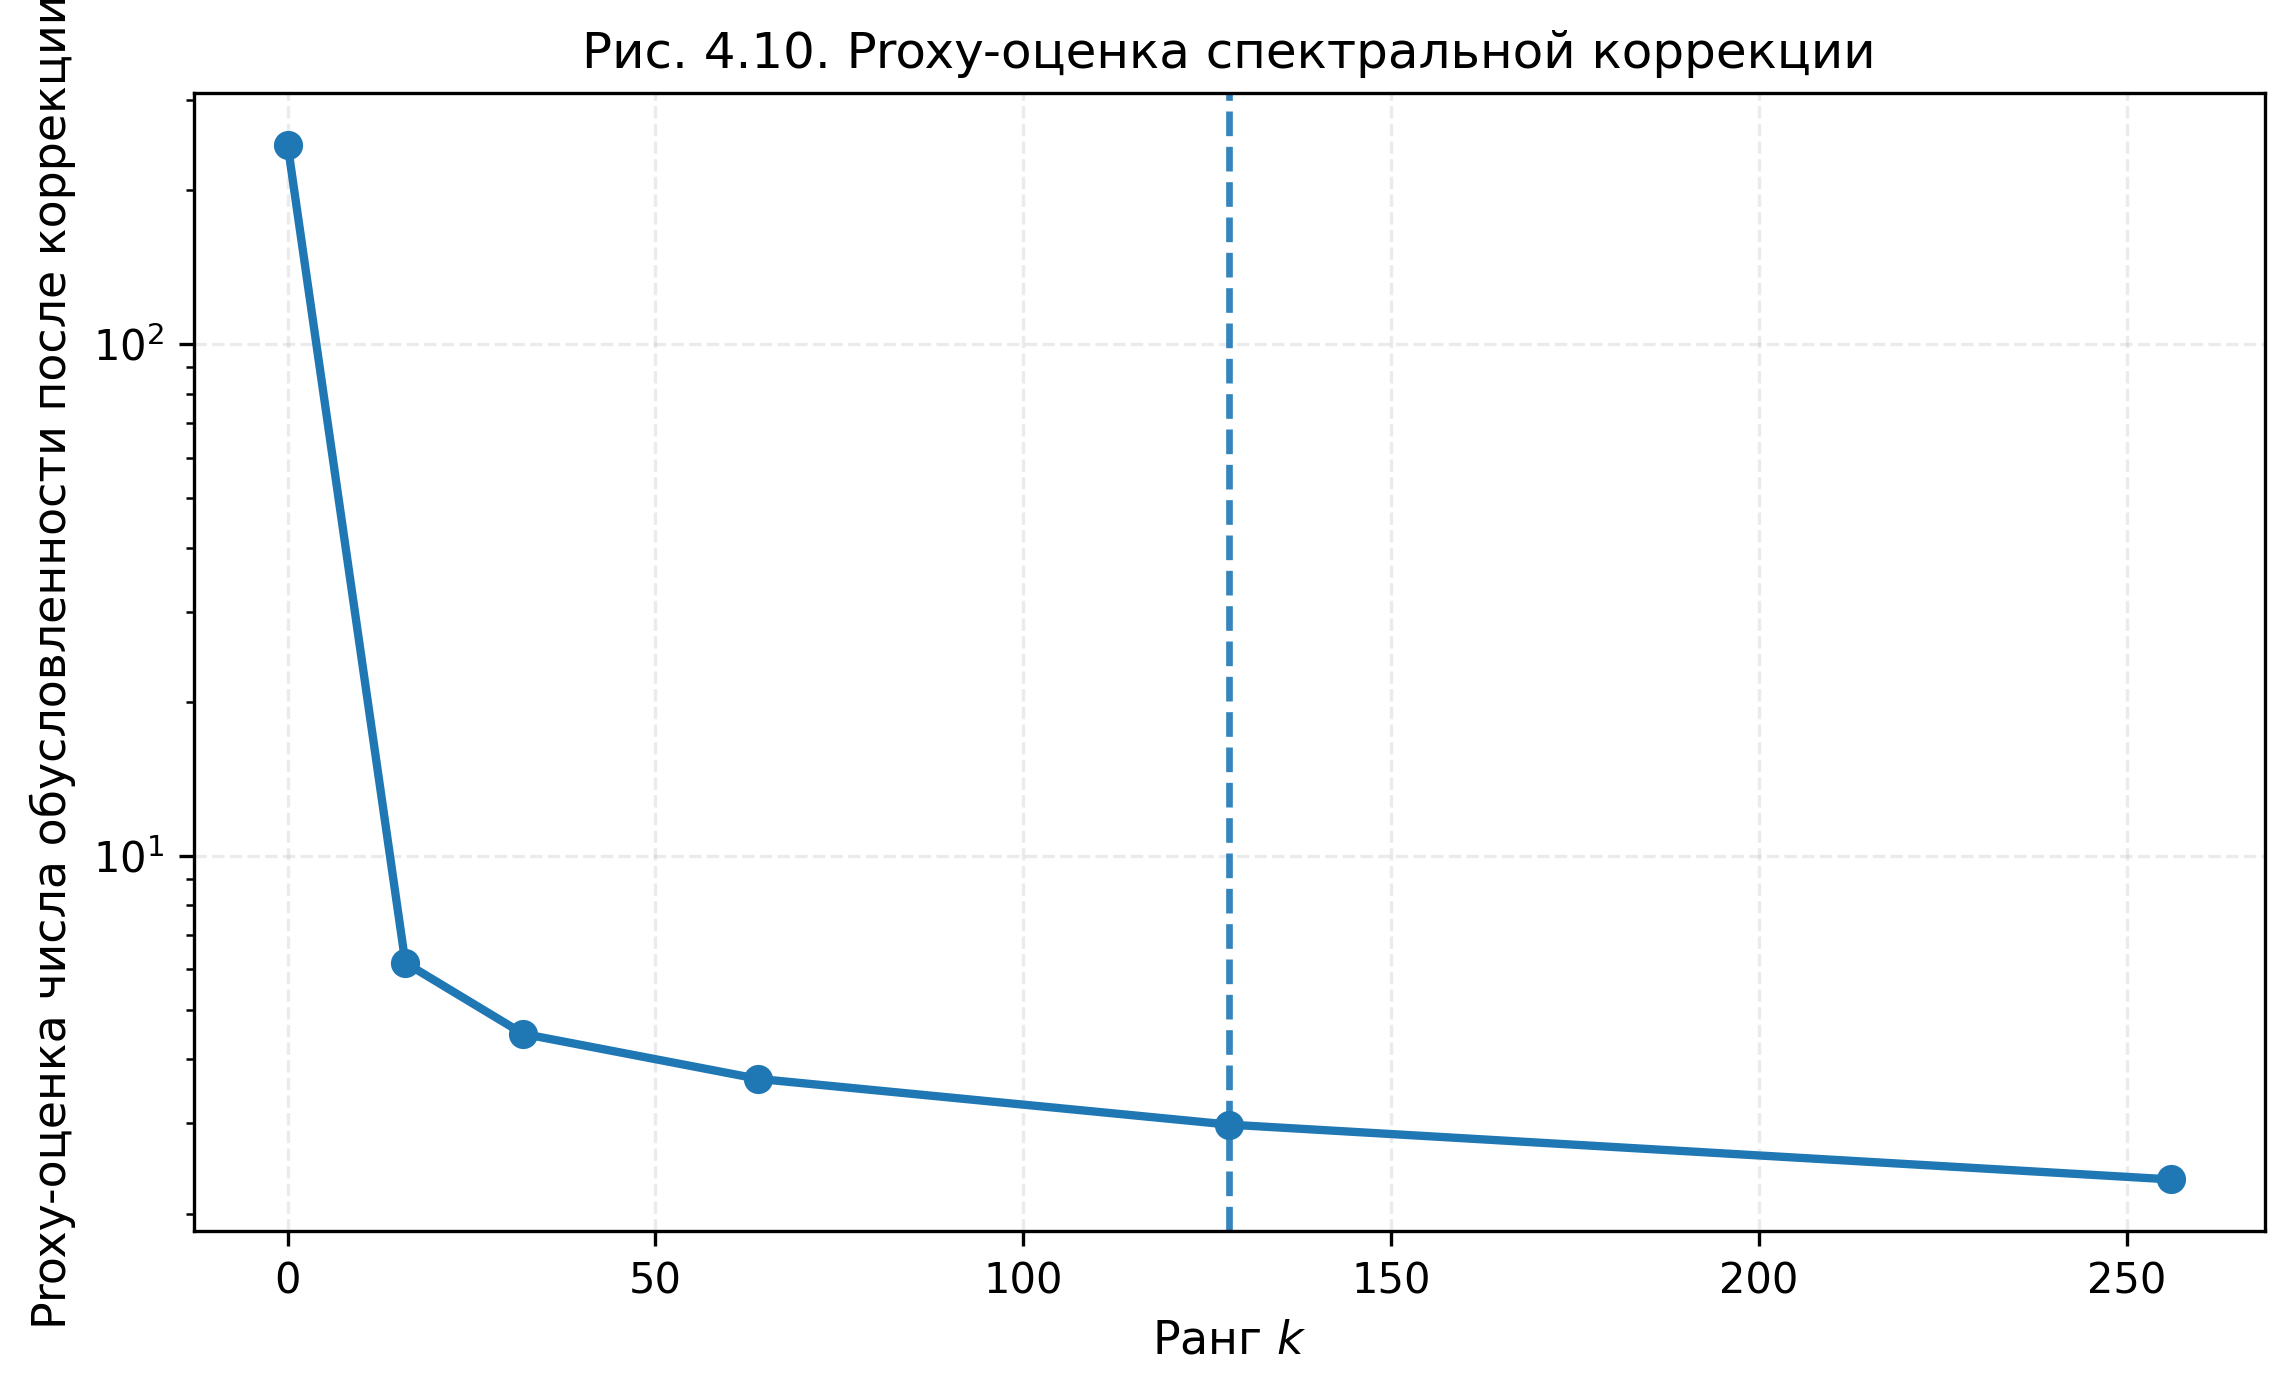

### figures/fig_4_11_heatmap_epsilon_rank_recall.png

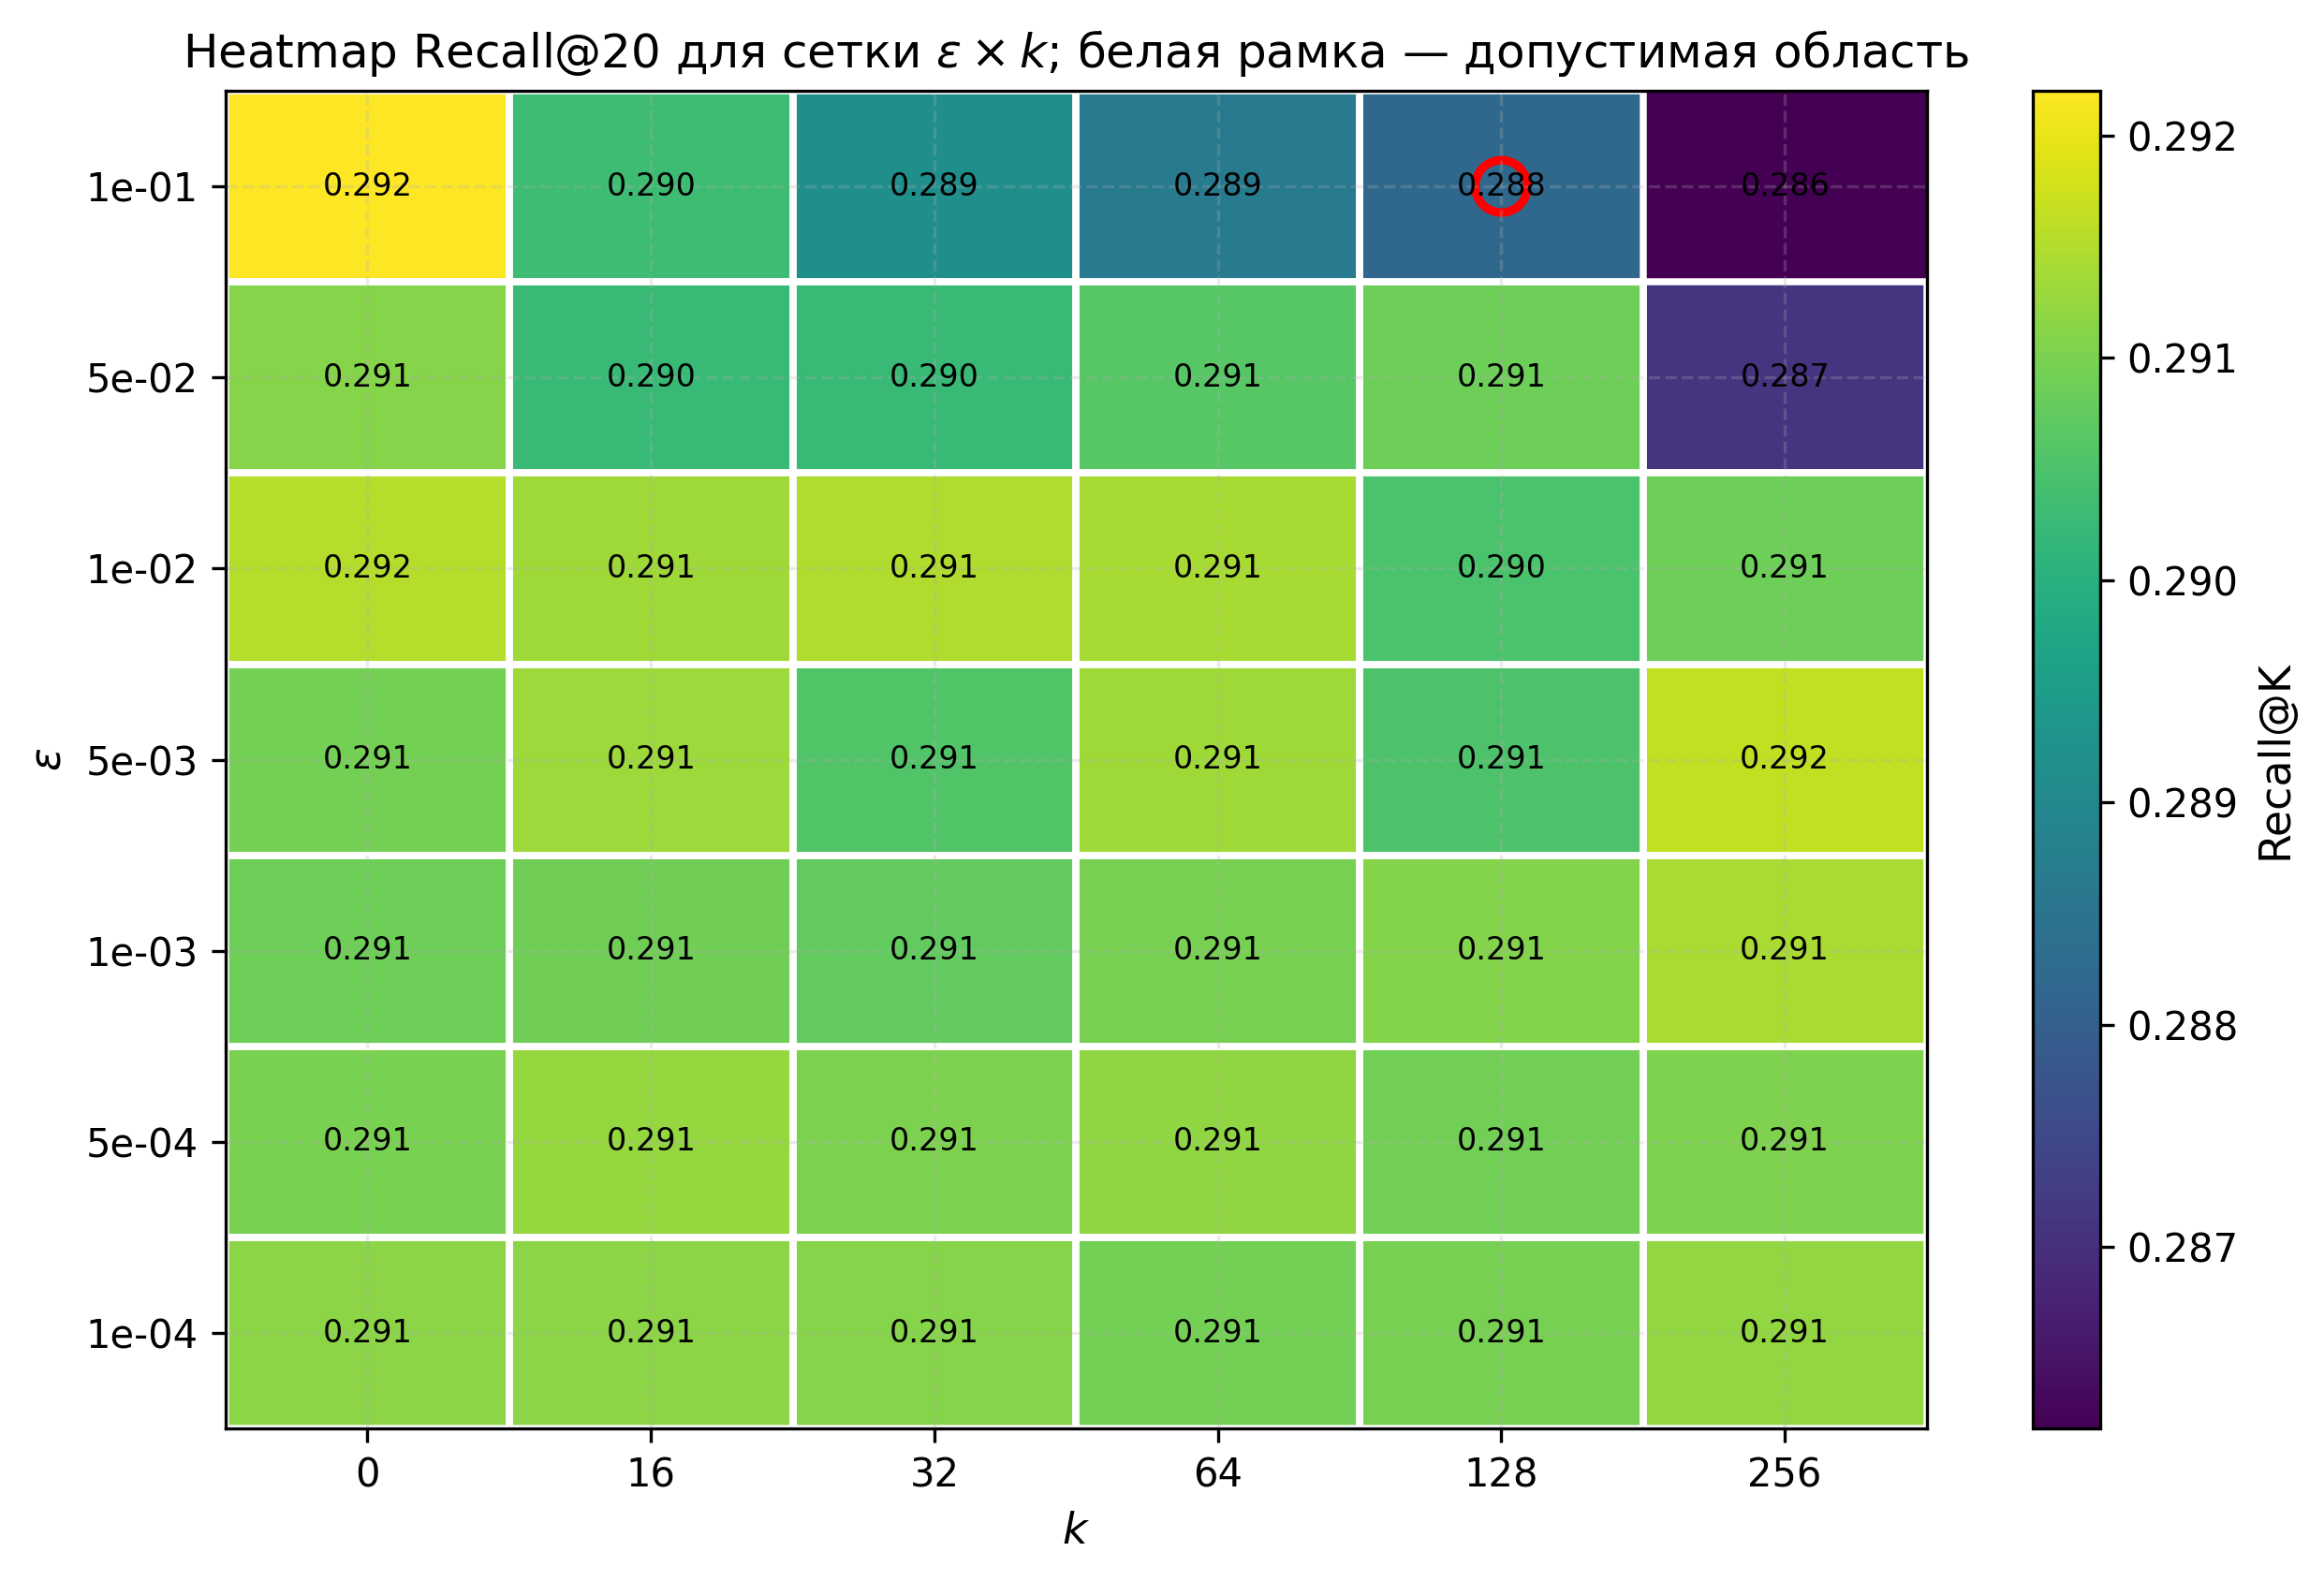

### figures/fig_4_12_heatmap_epsilon_rank_time.png

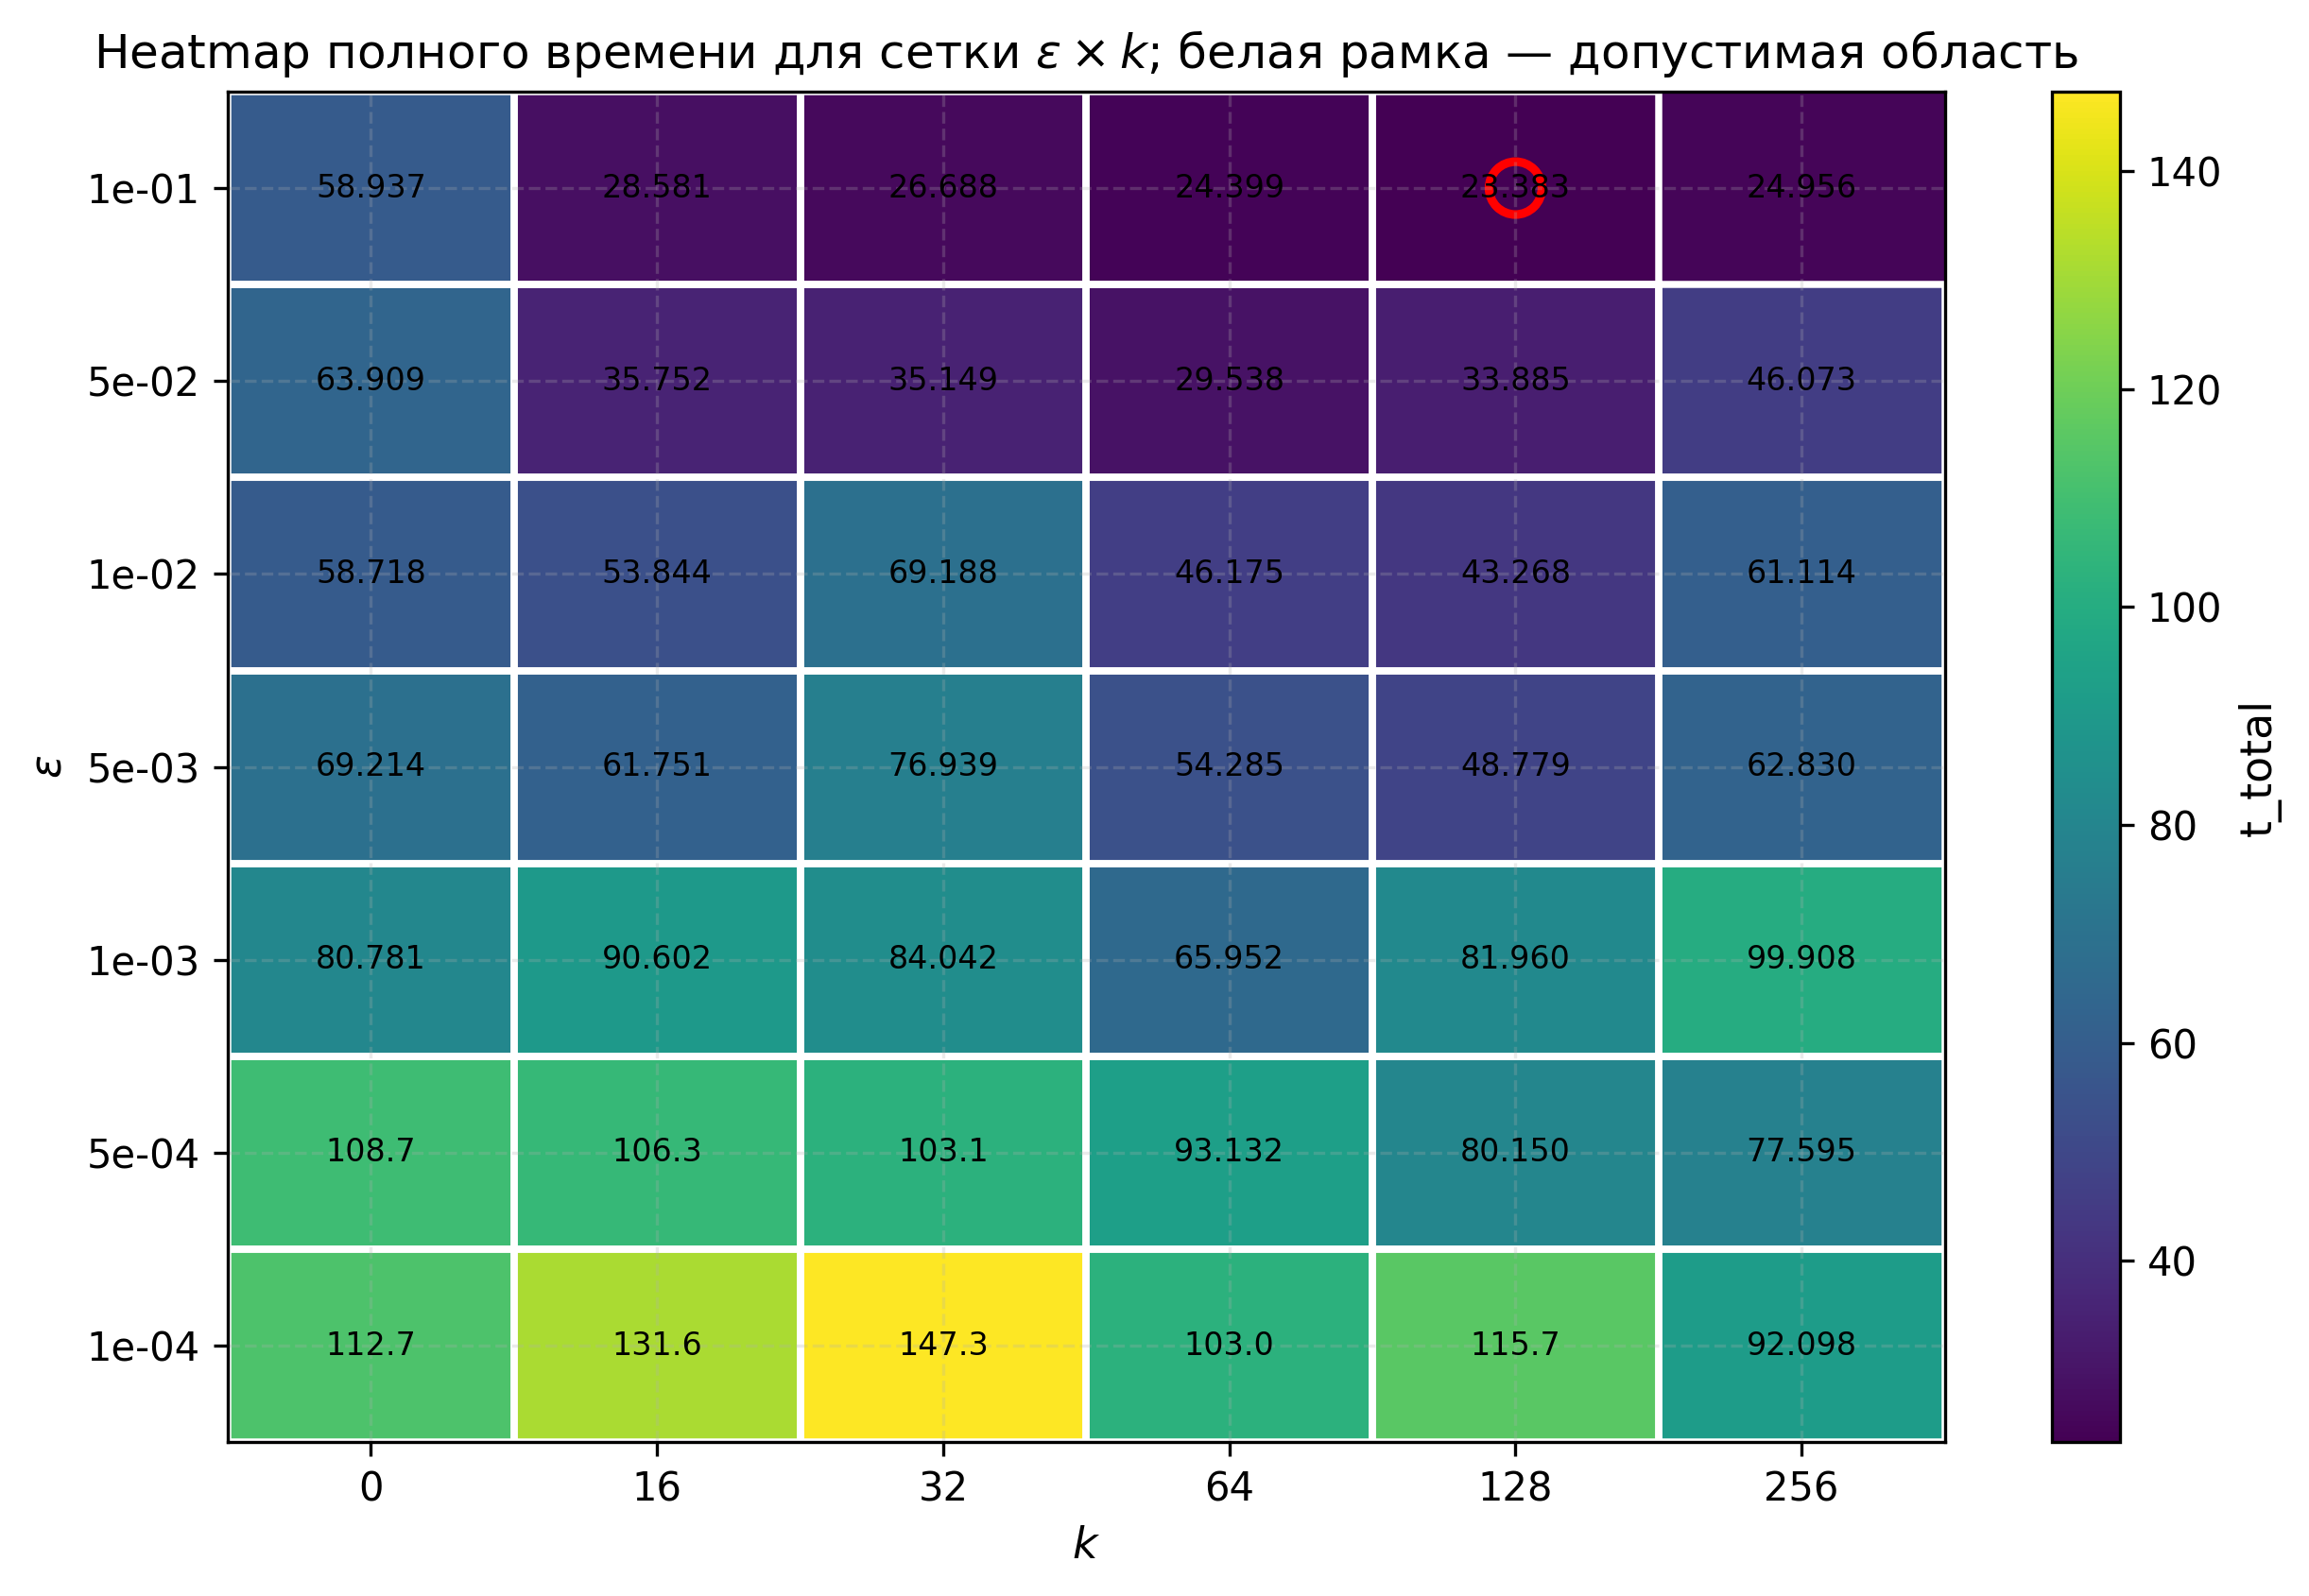

### figures/fig_4_13_heatmap_rank_block_time.png

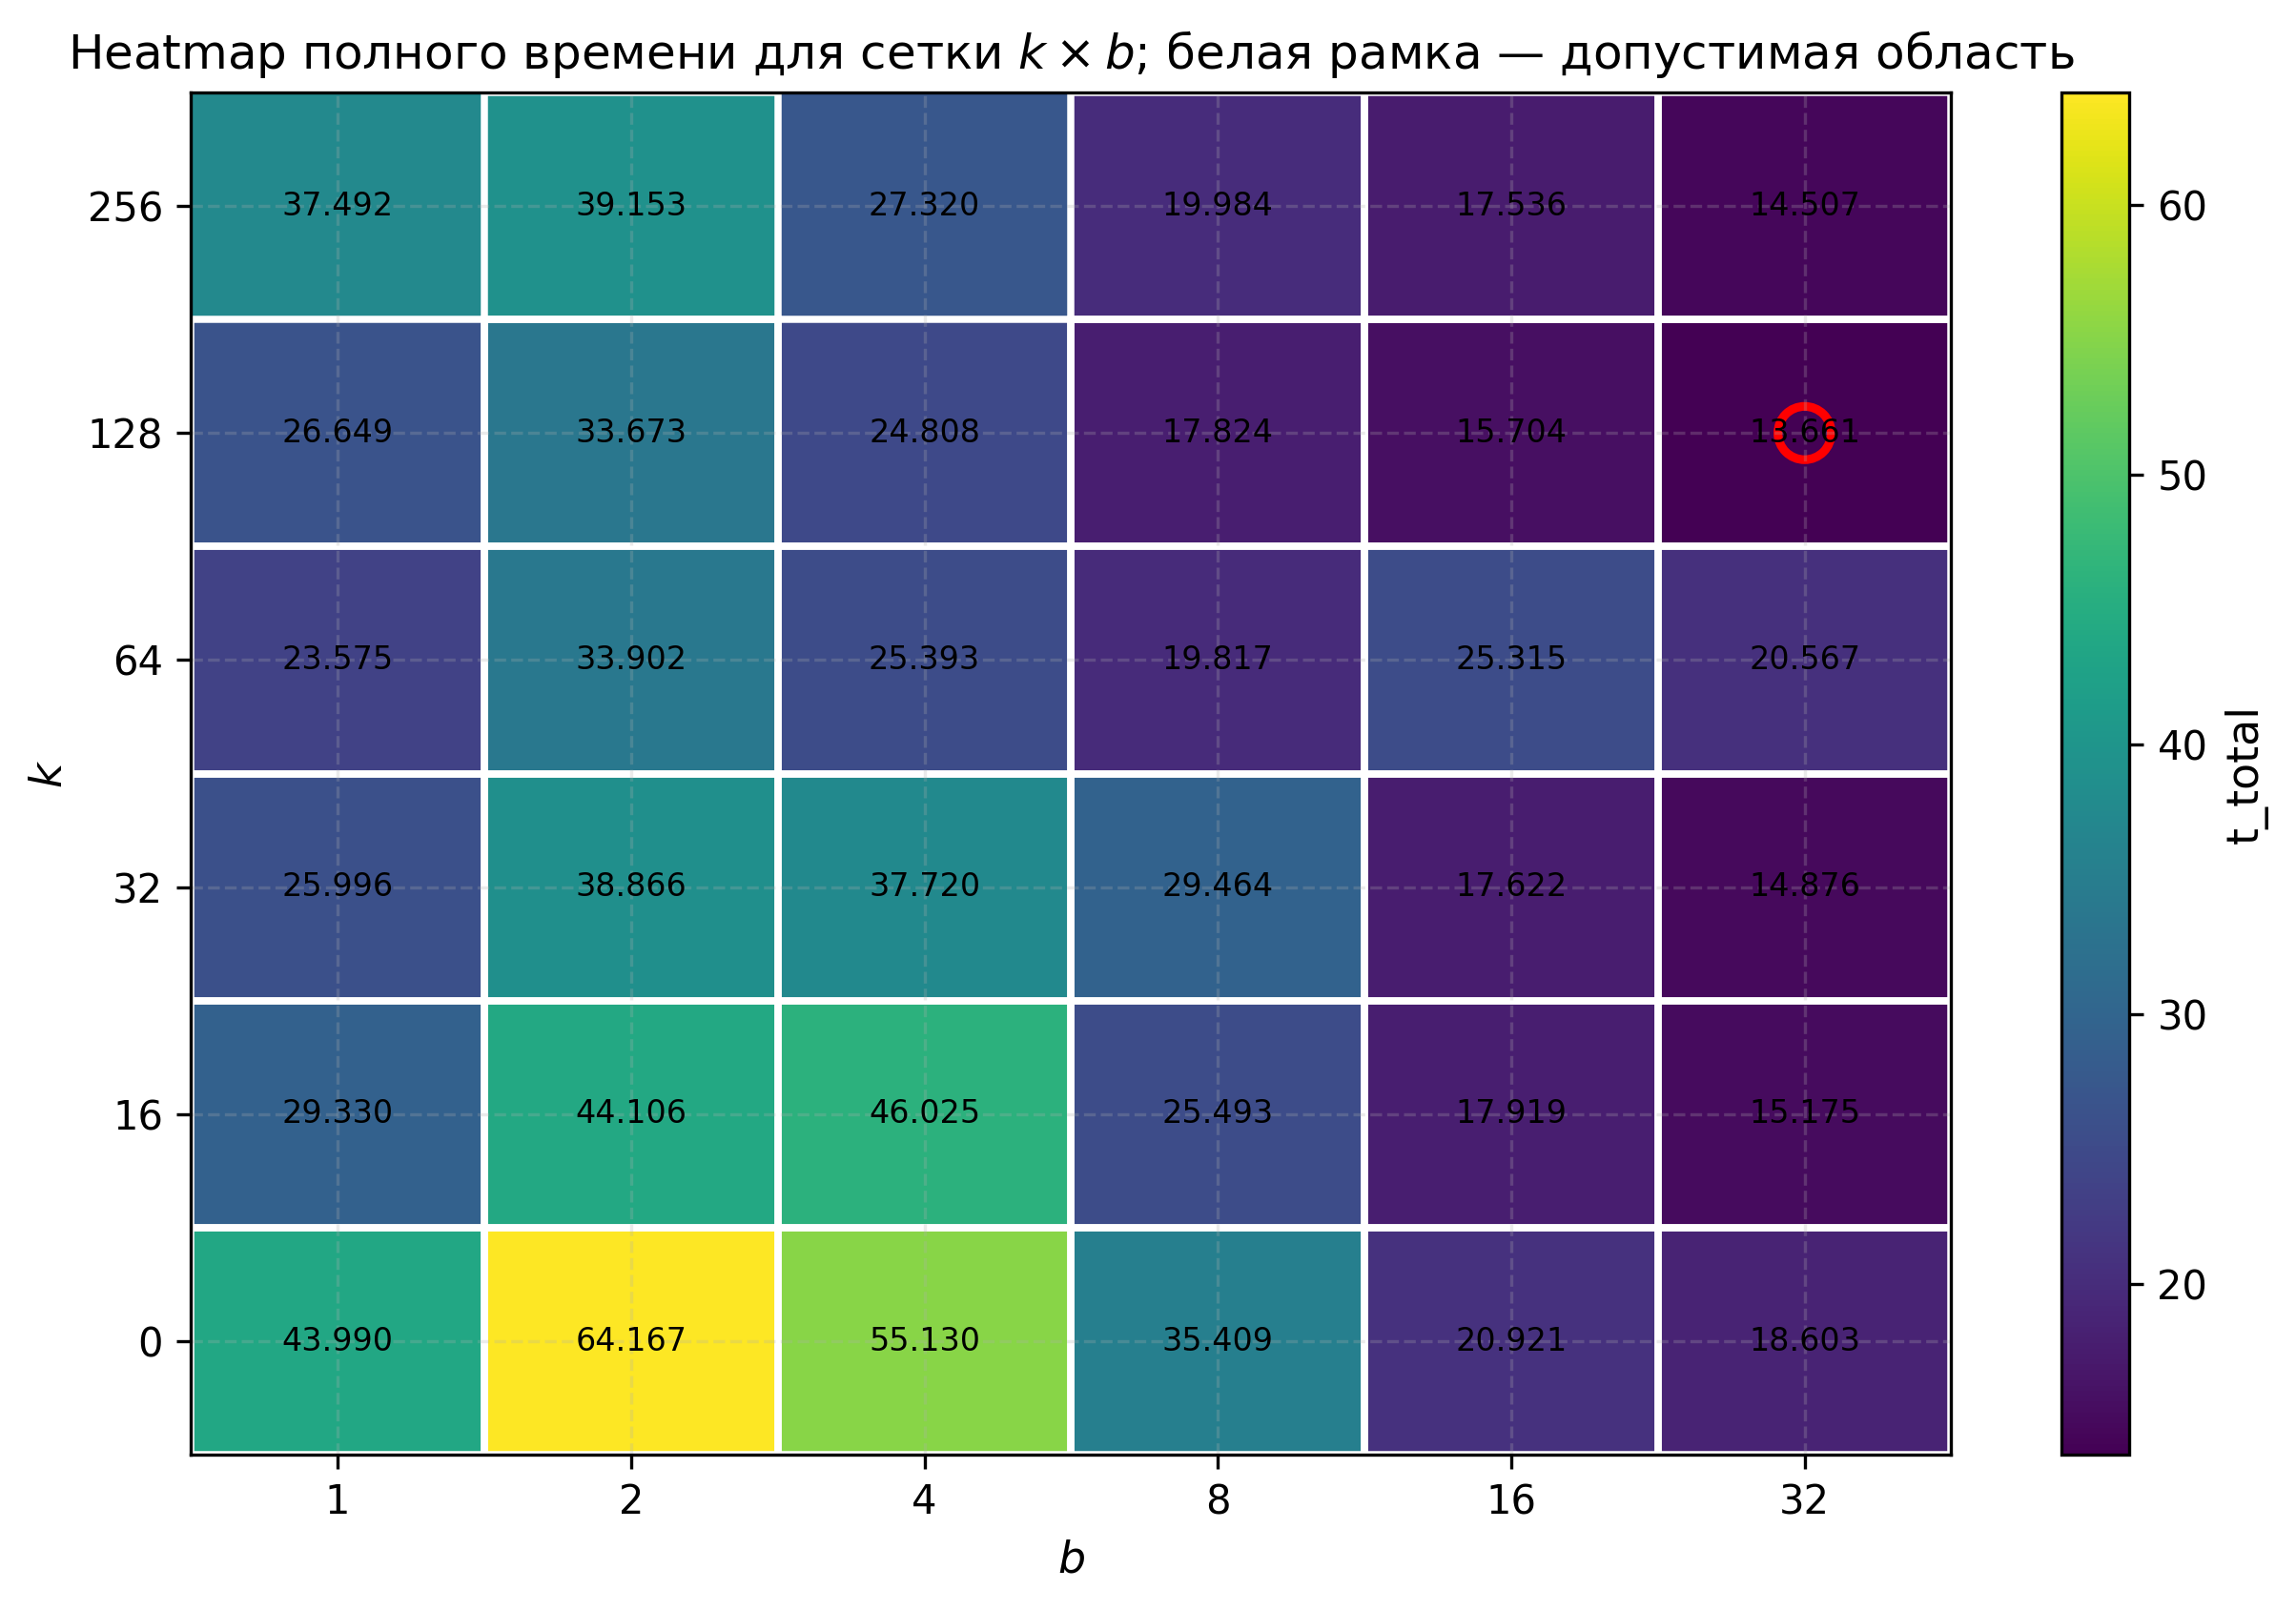

### figures/fig_4_14_heatmap_rank_block_iterations.png

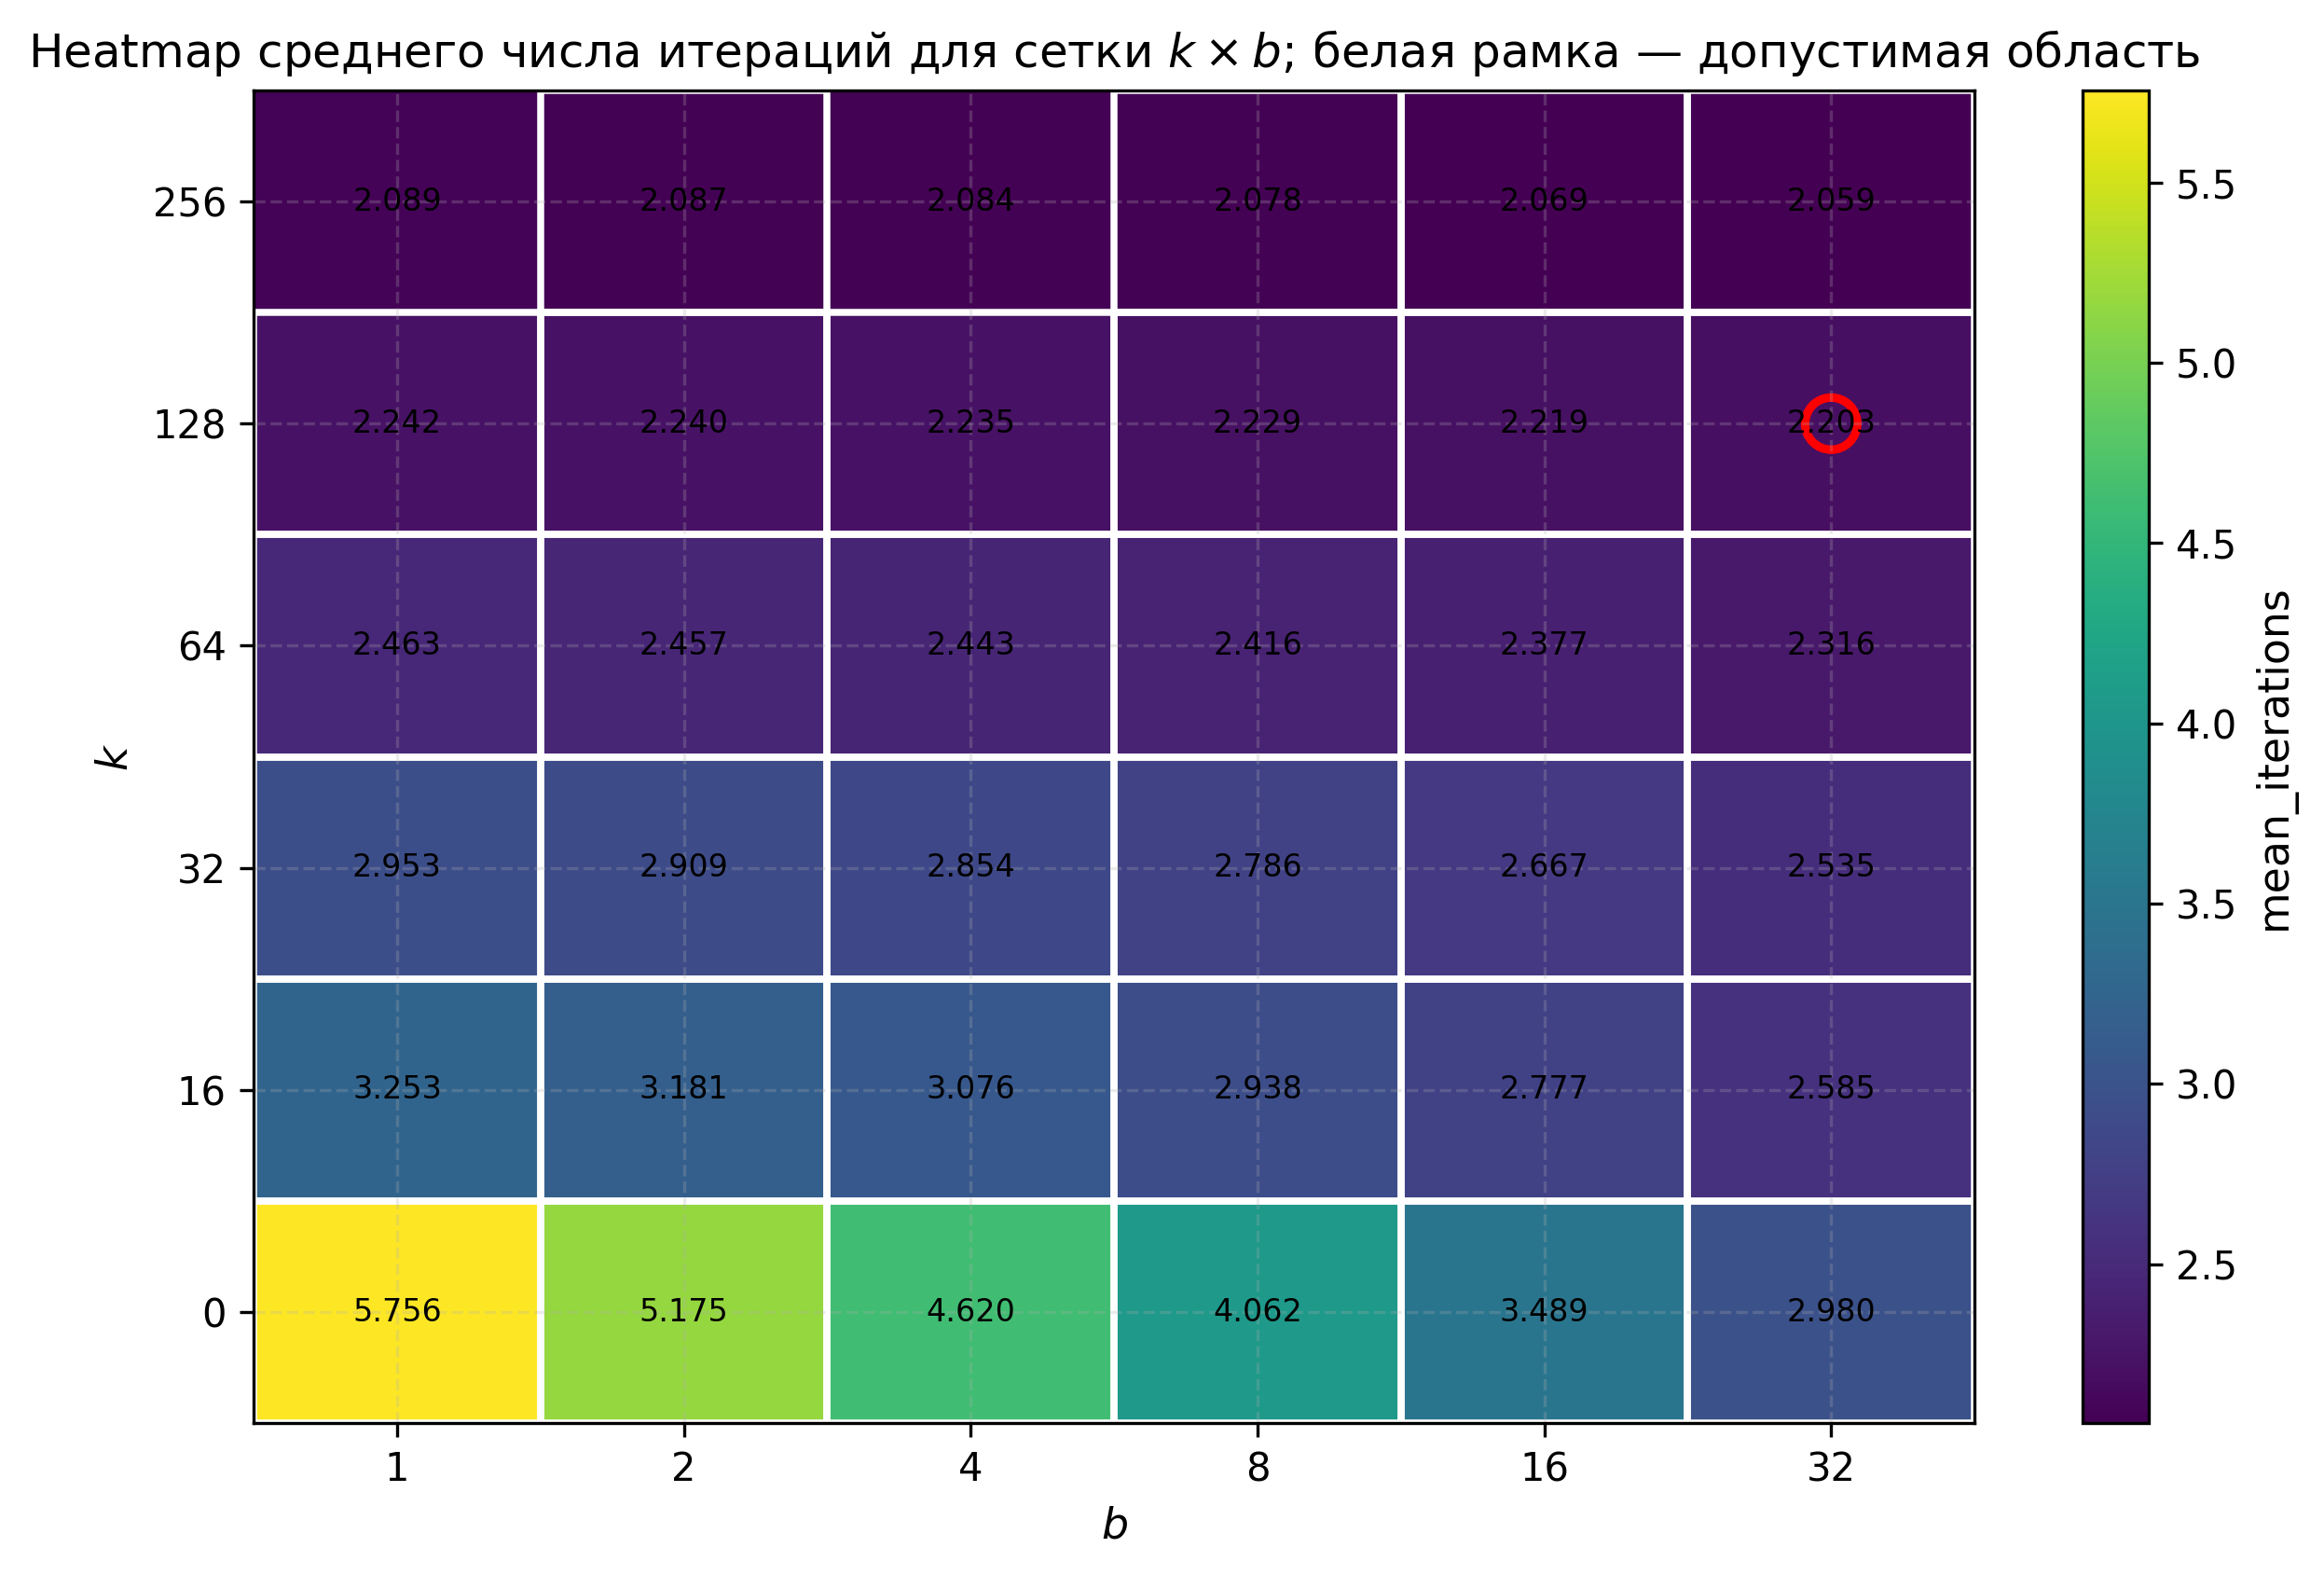

### figures/fig_4_1_epsilon_selection.png

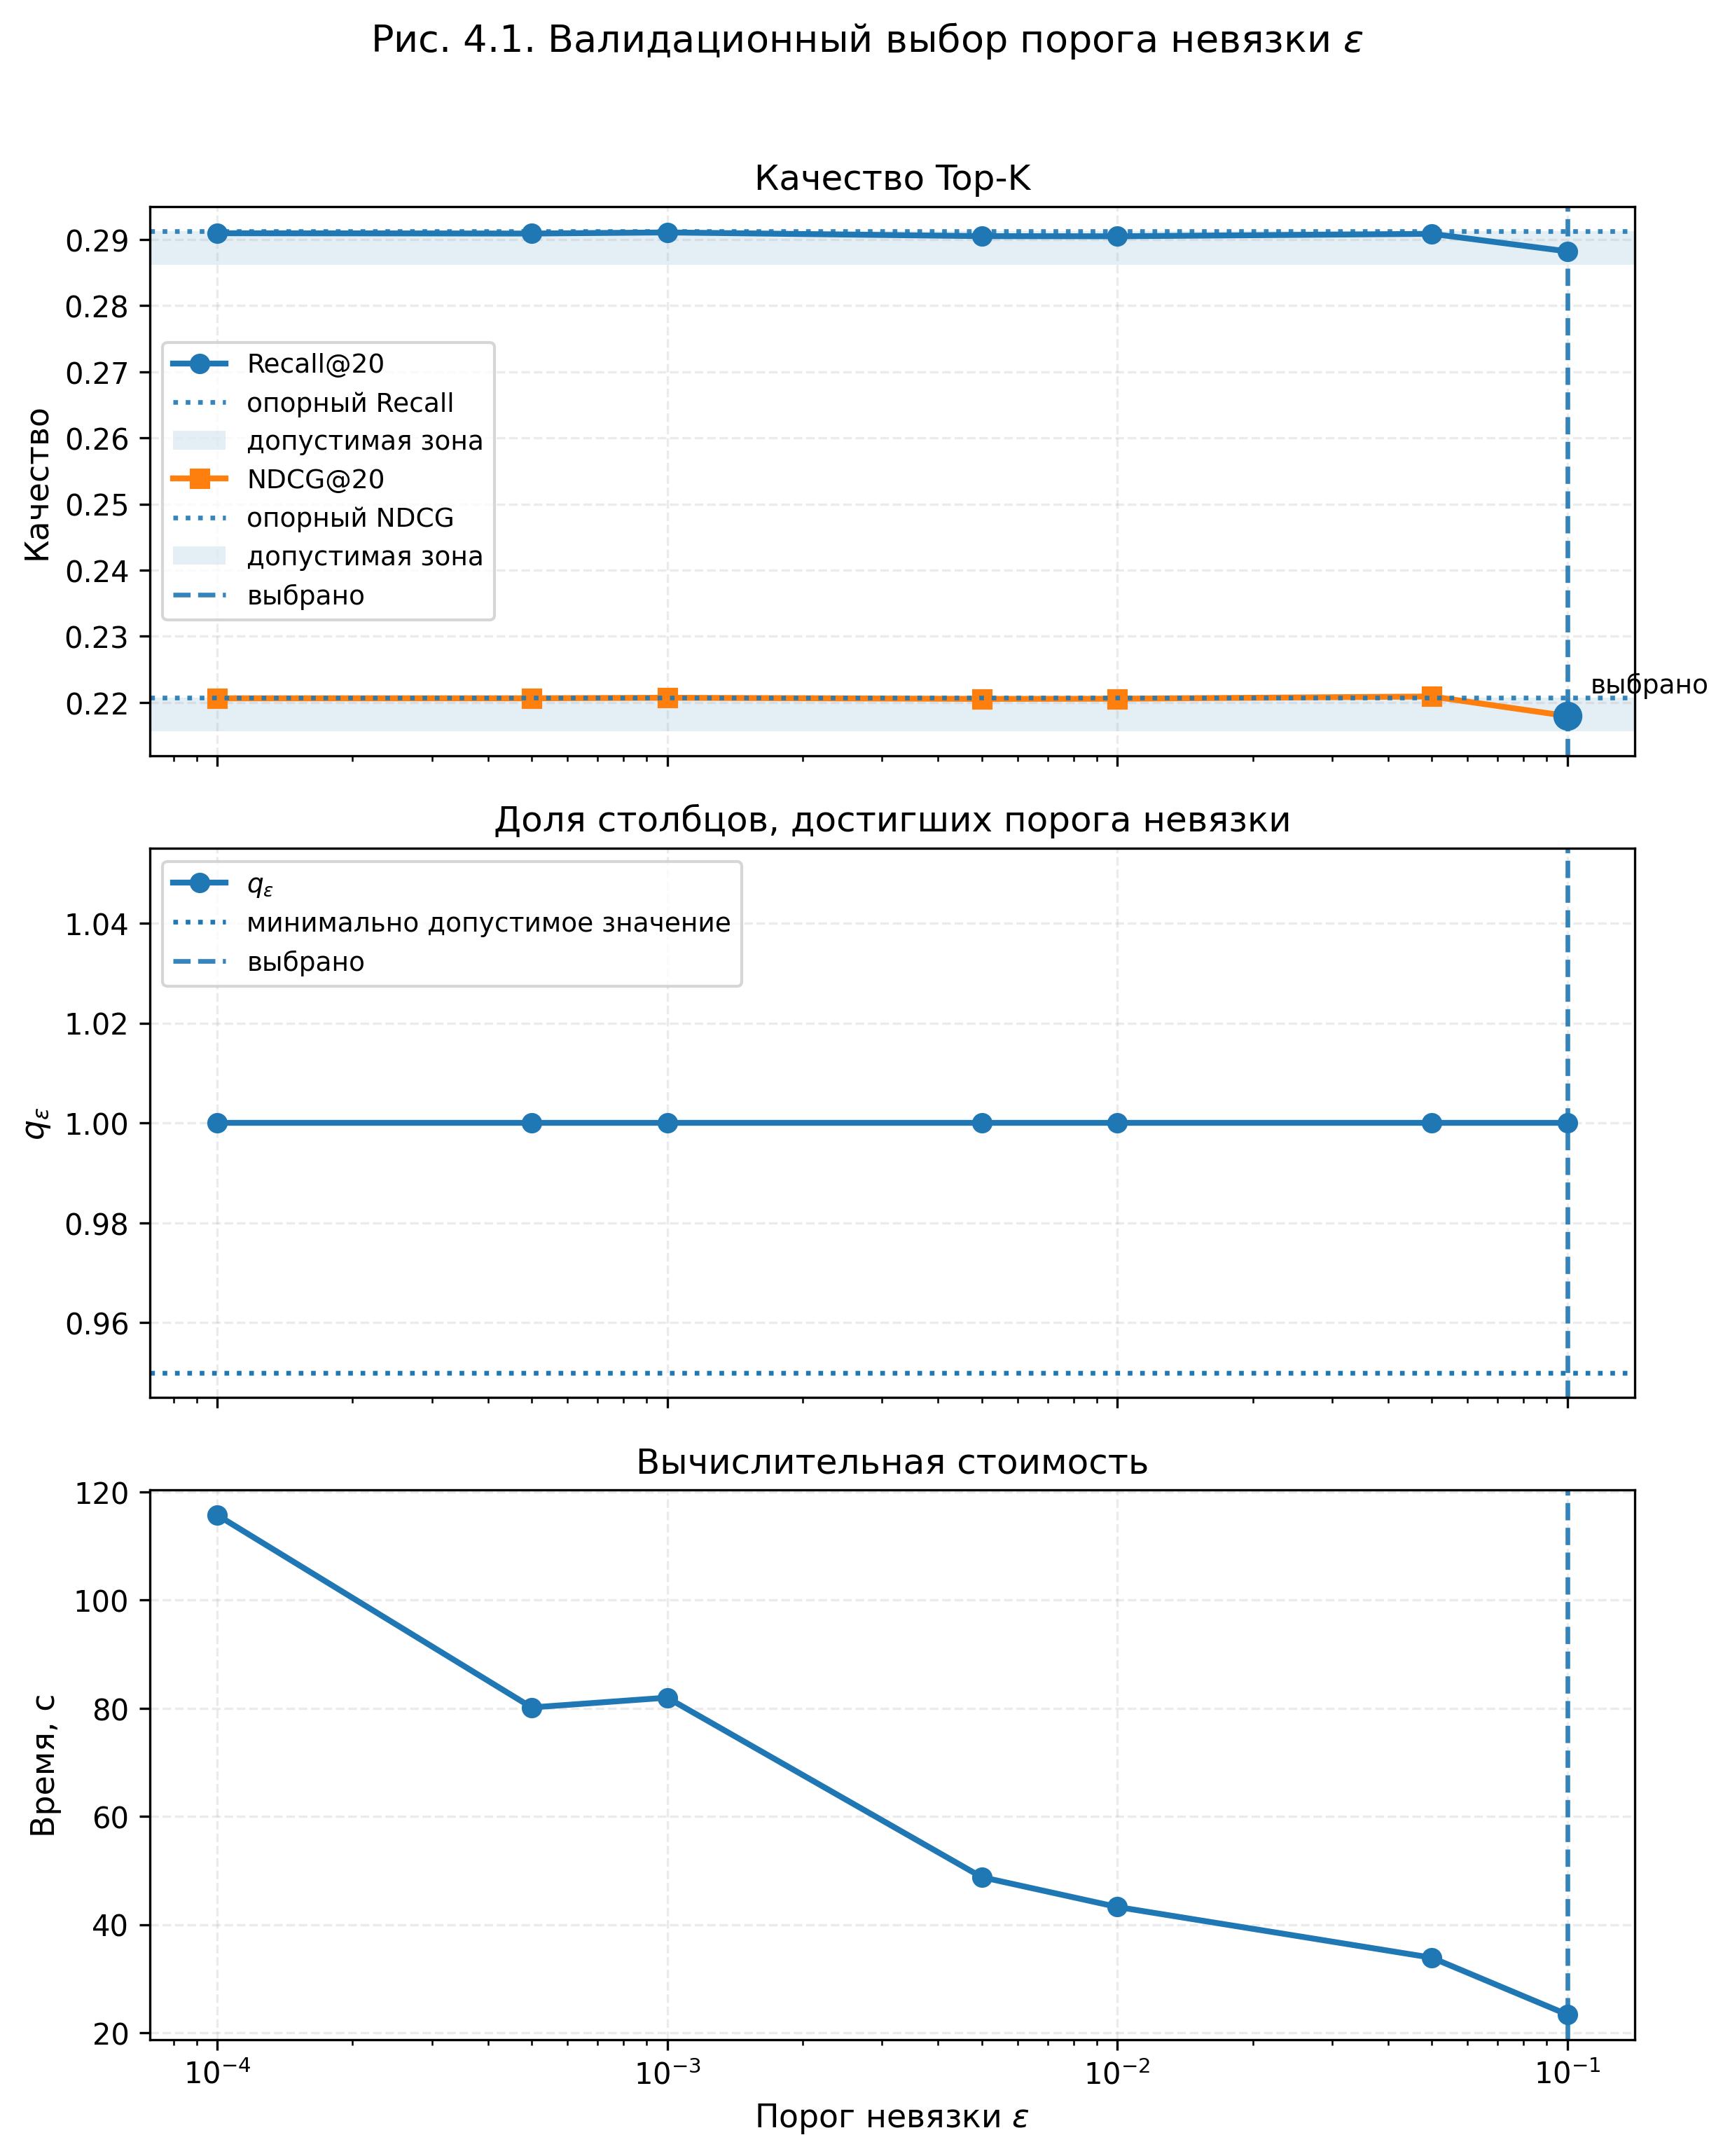

### figures/fig_4_2_rank_selection.png

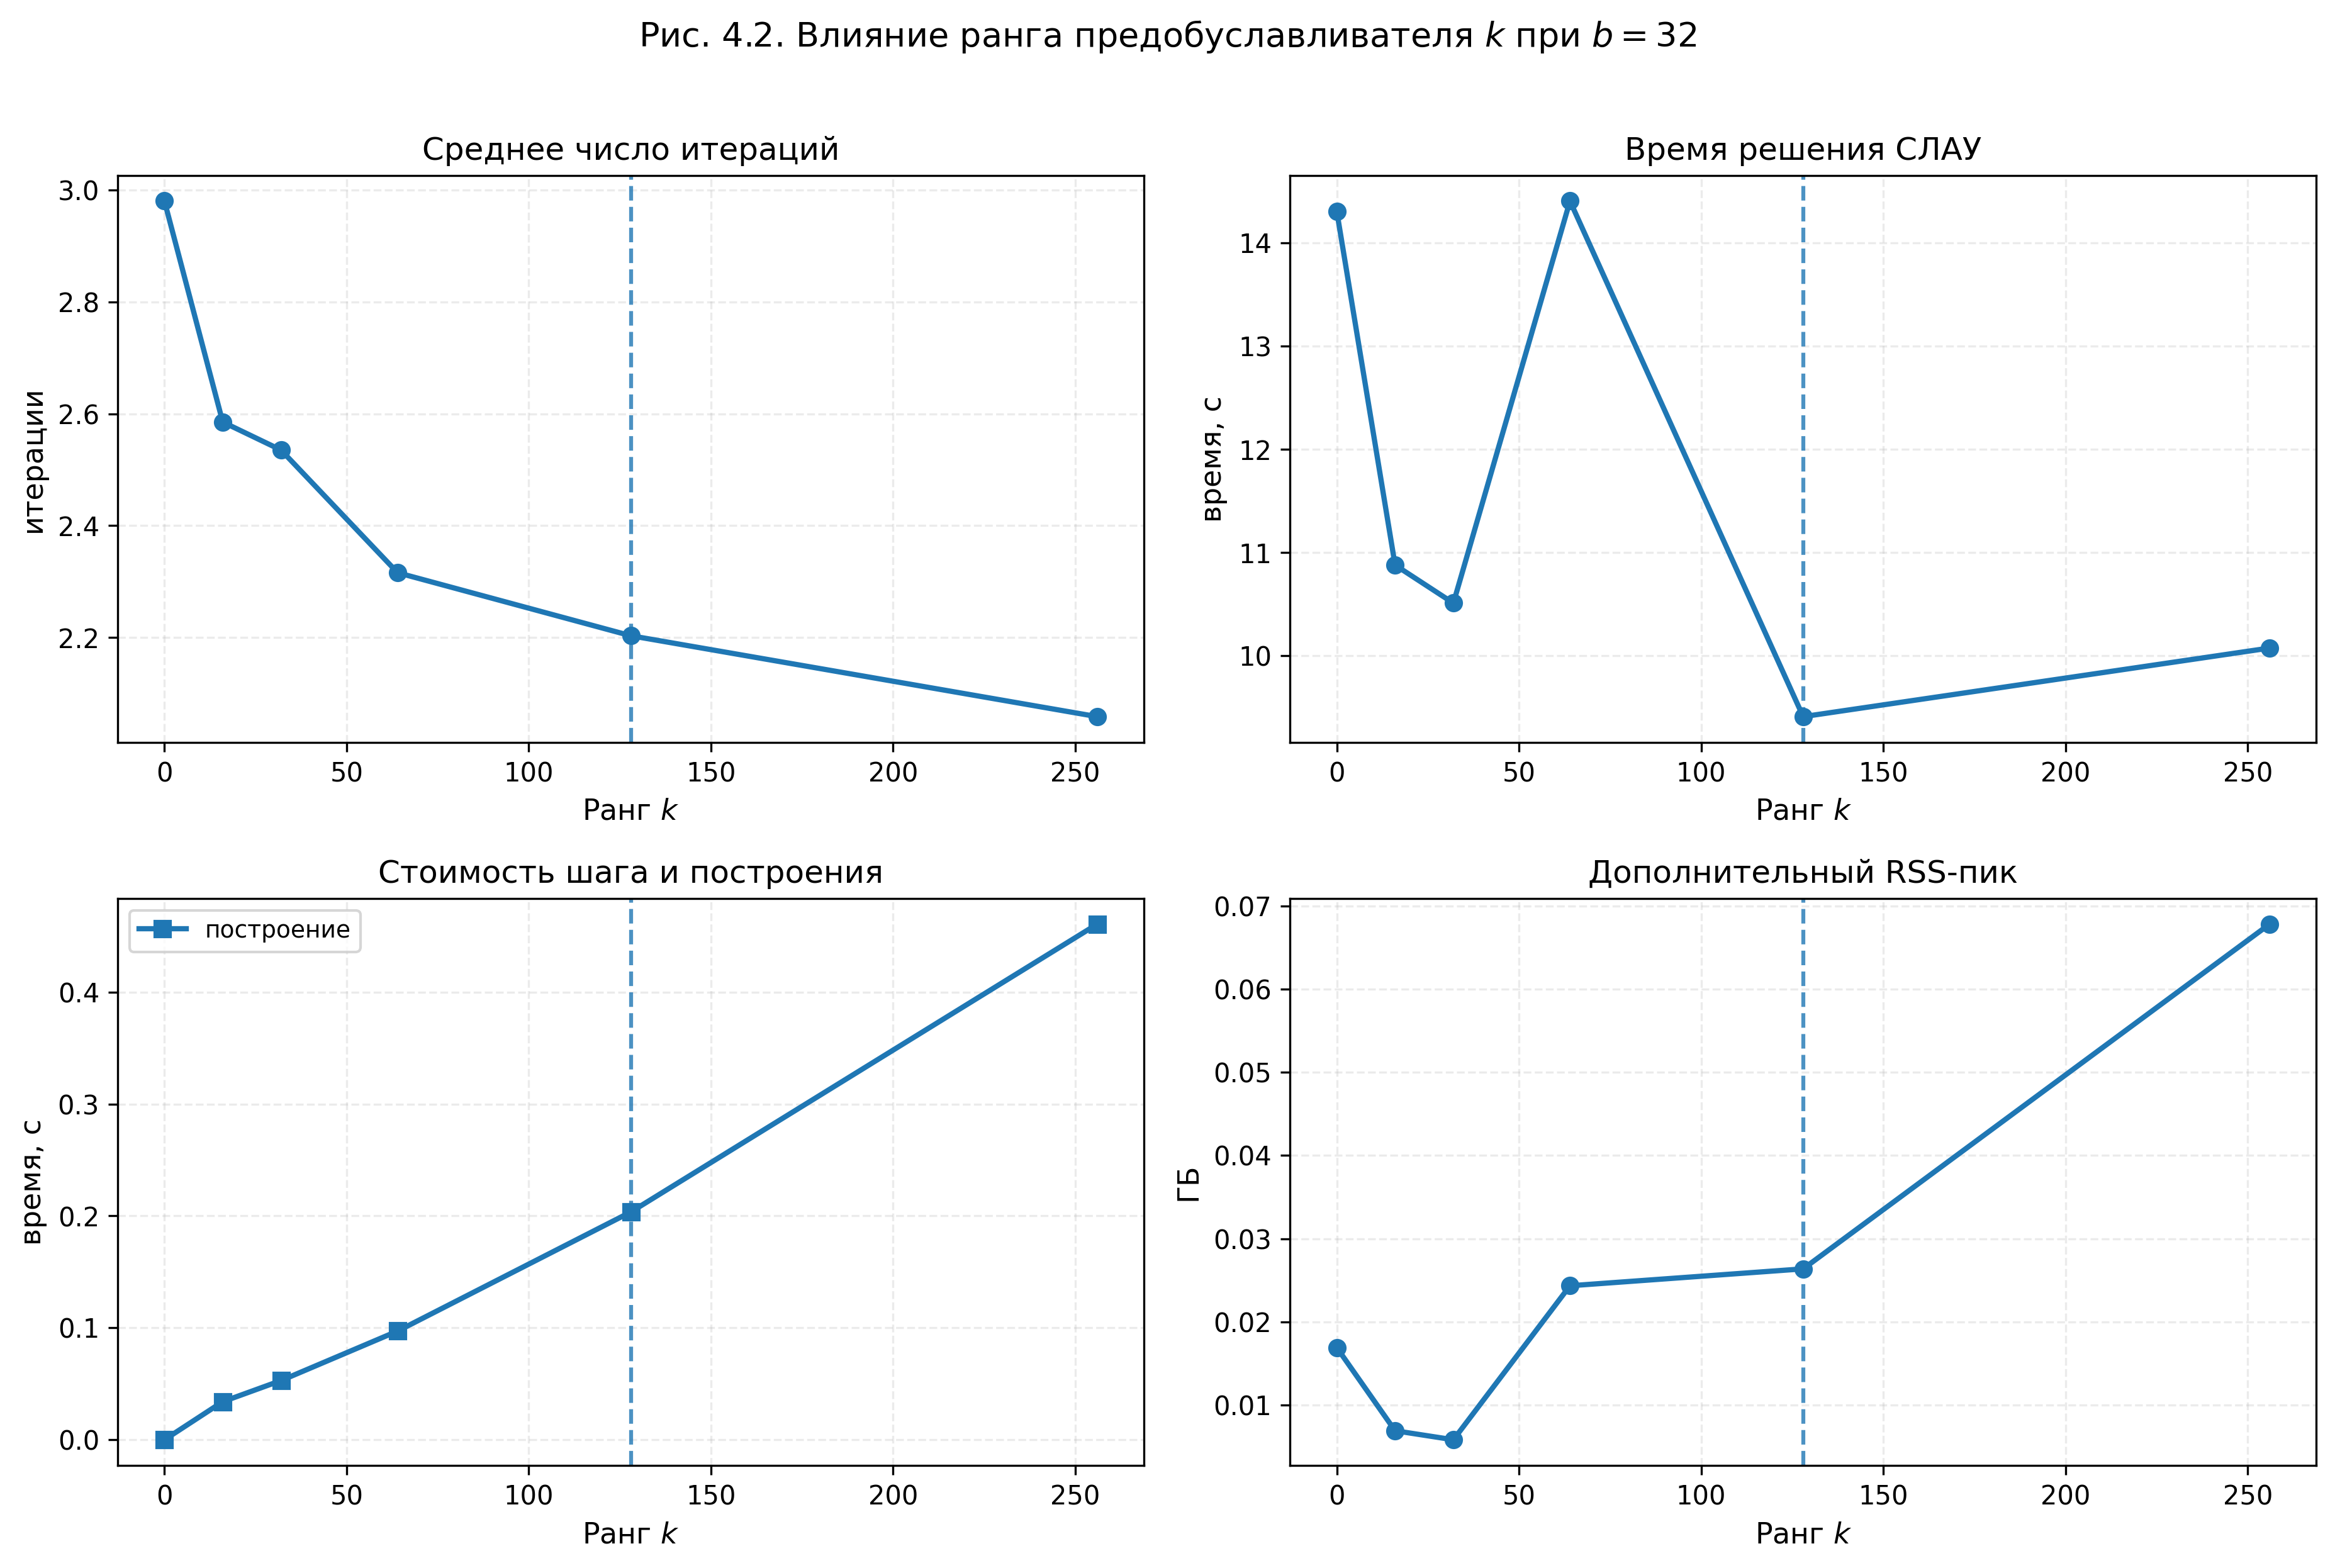

### figures/fig_4_3_block_selection.png

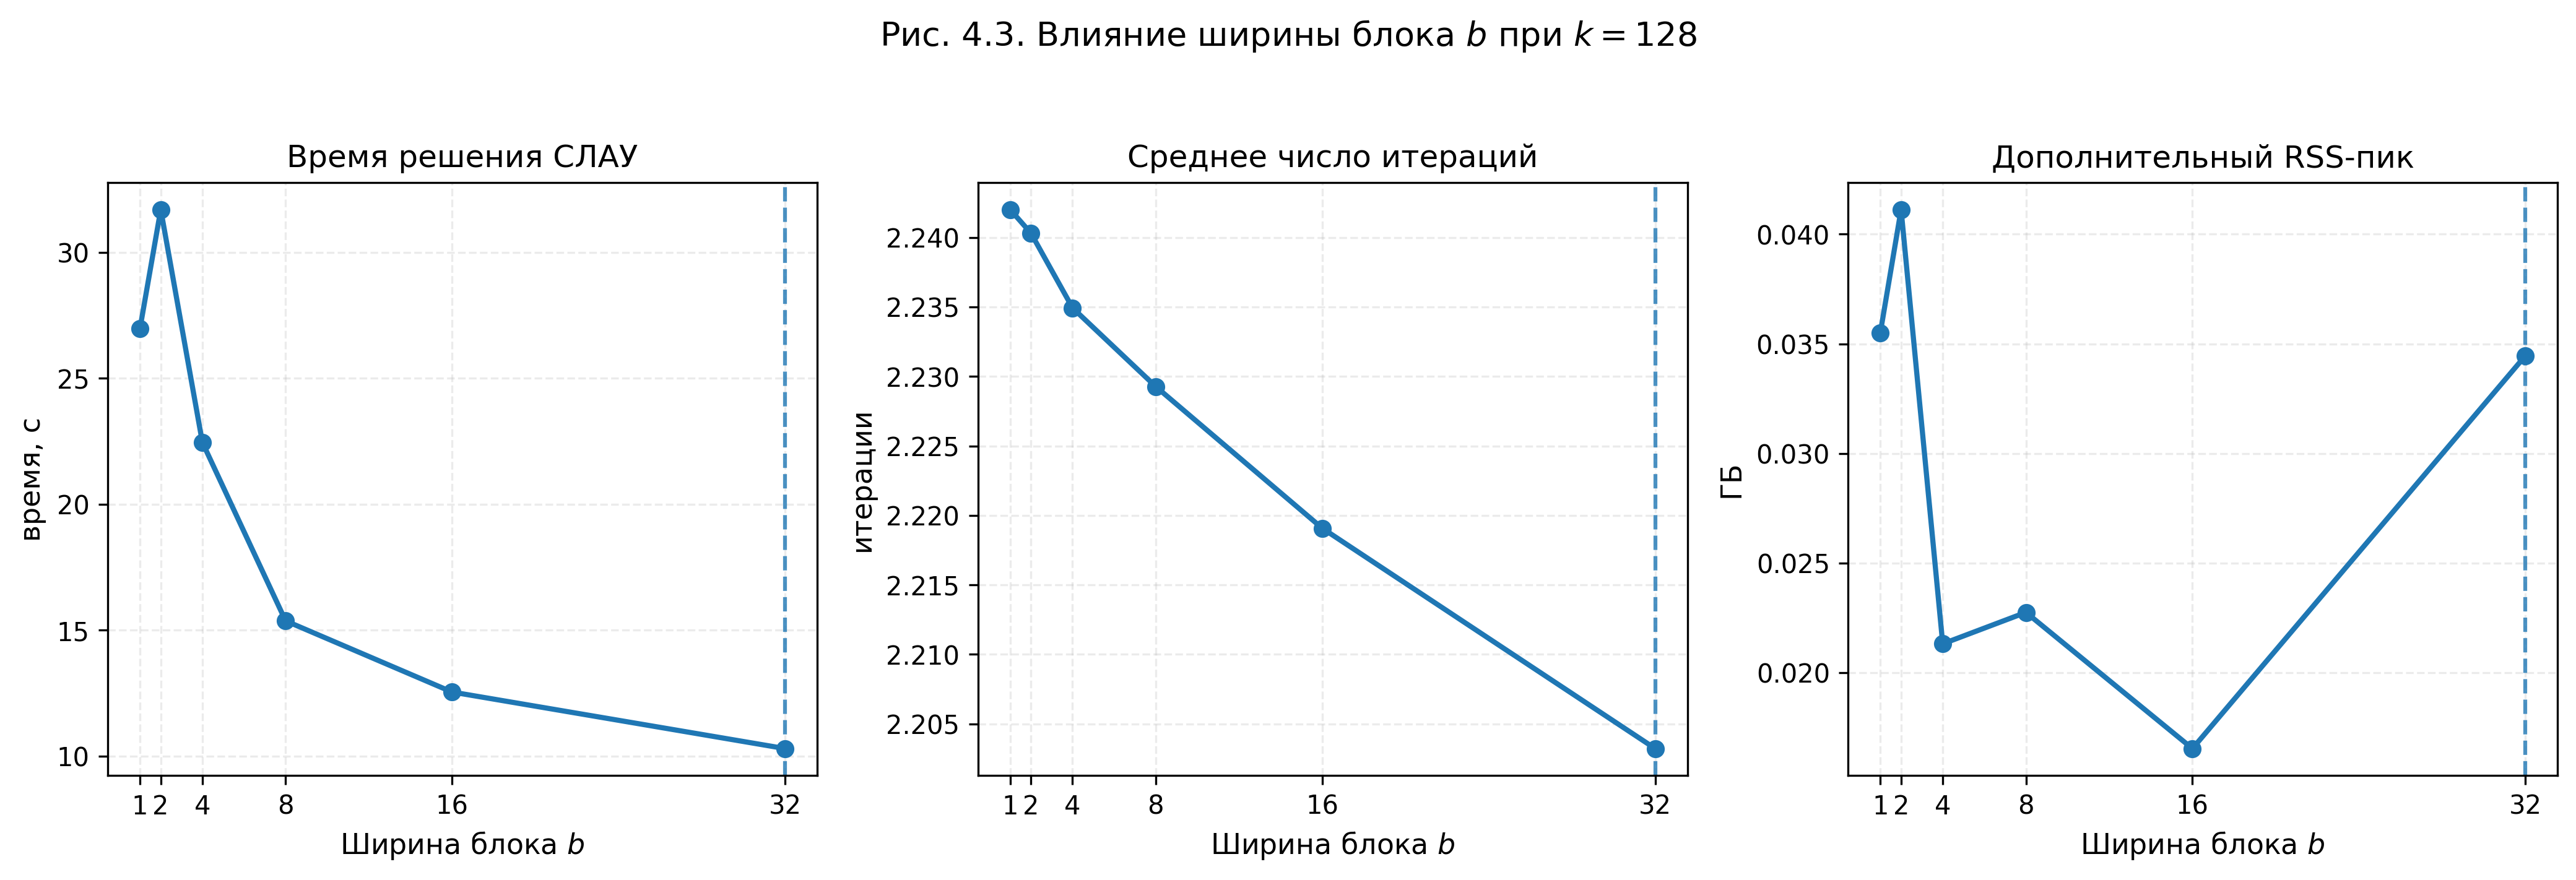

### figures/fig_4_4_lkeep_selection.png

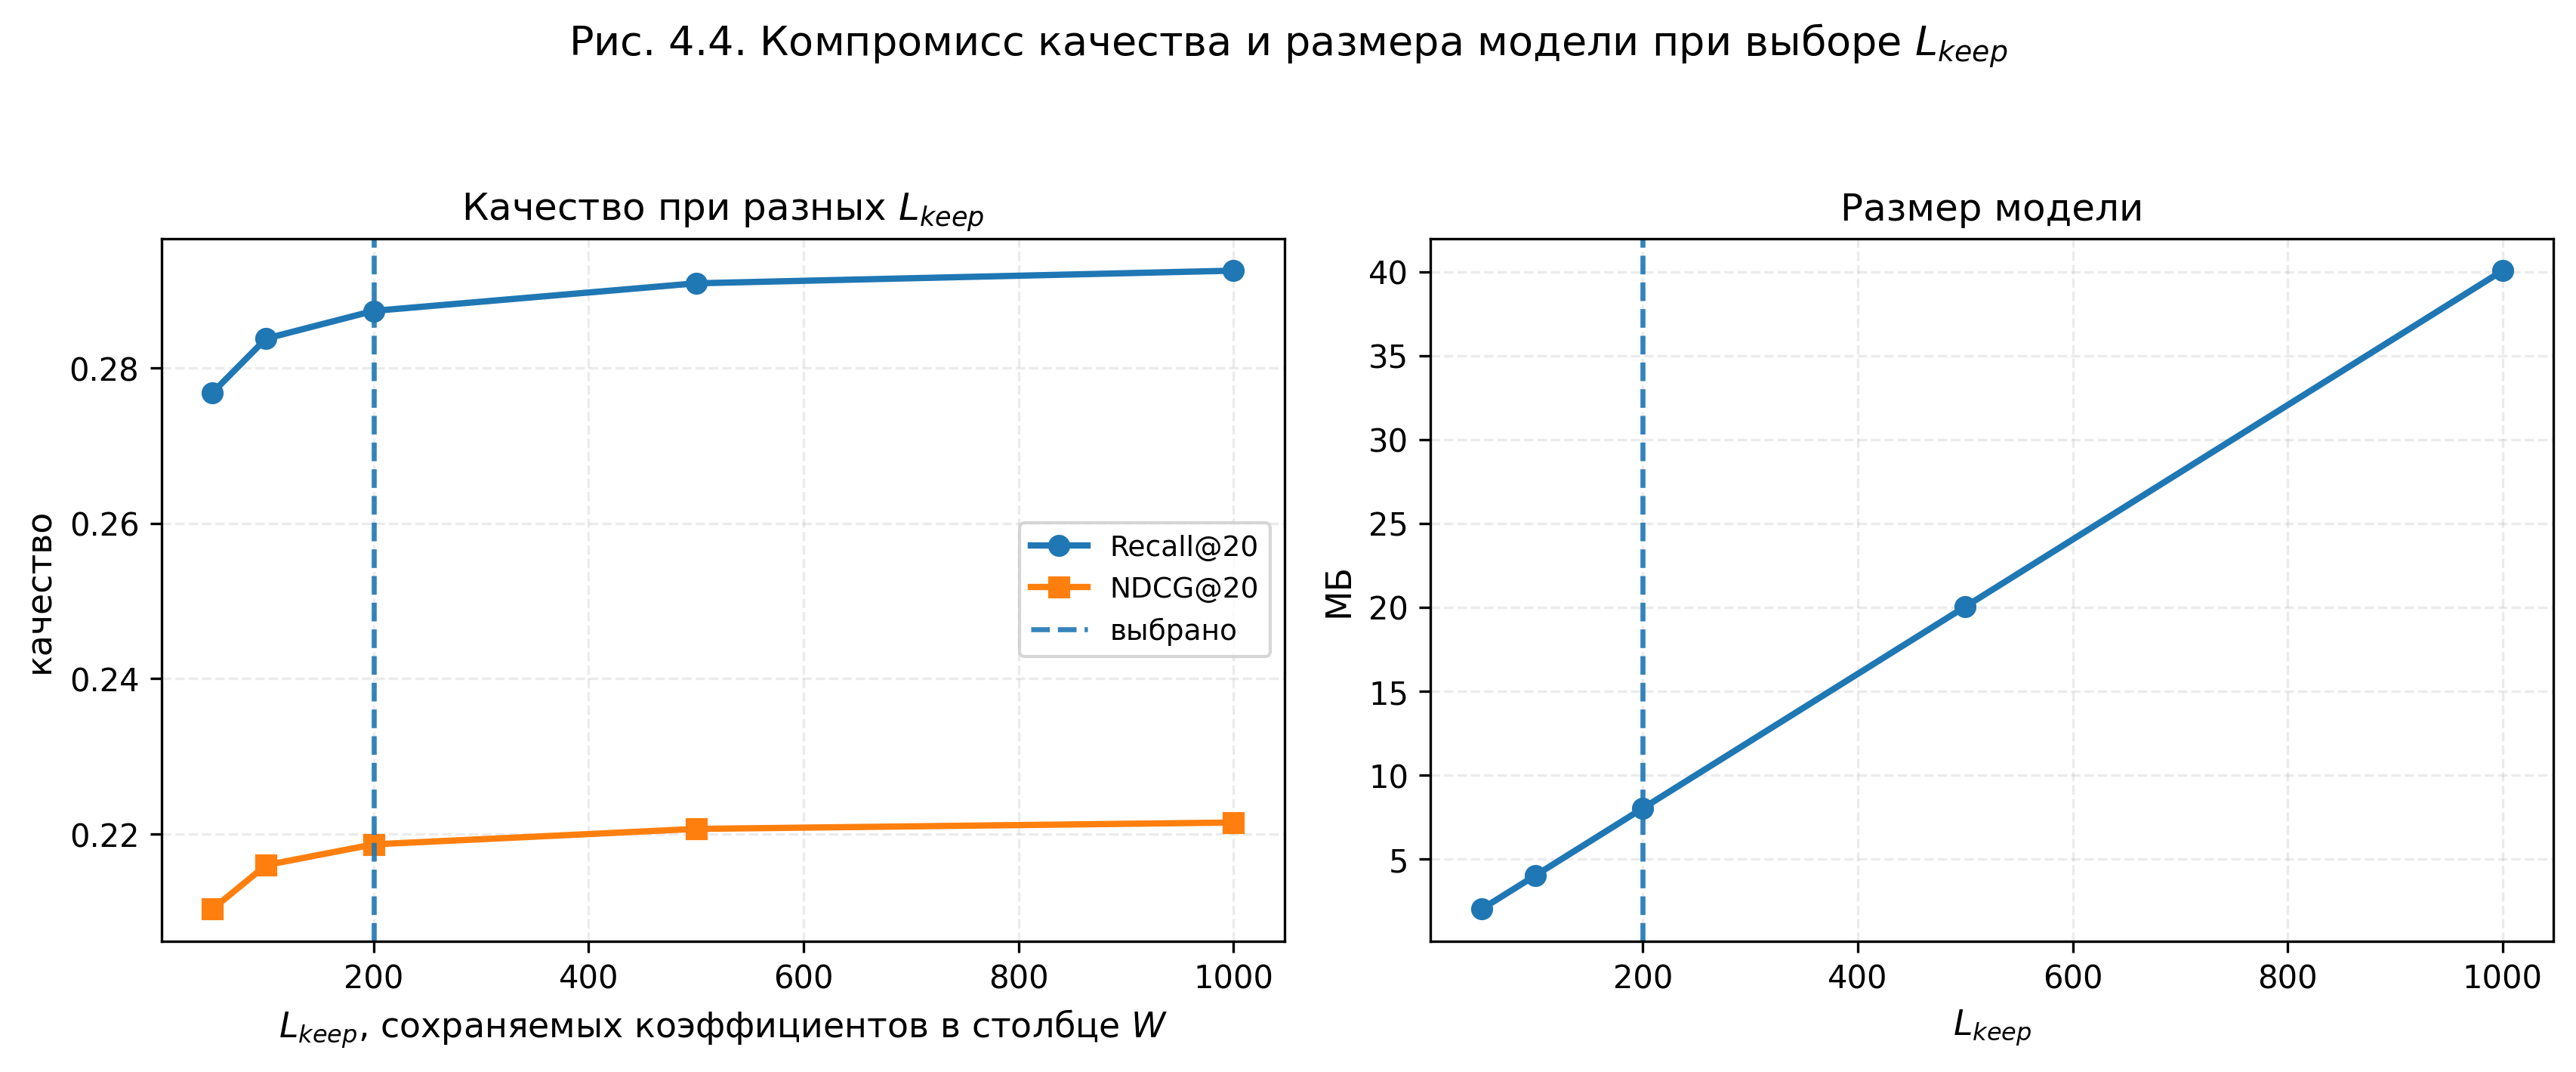

### figures/fig_4_5_internal_validation_comparison.png

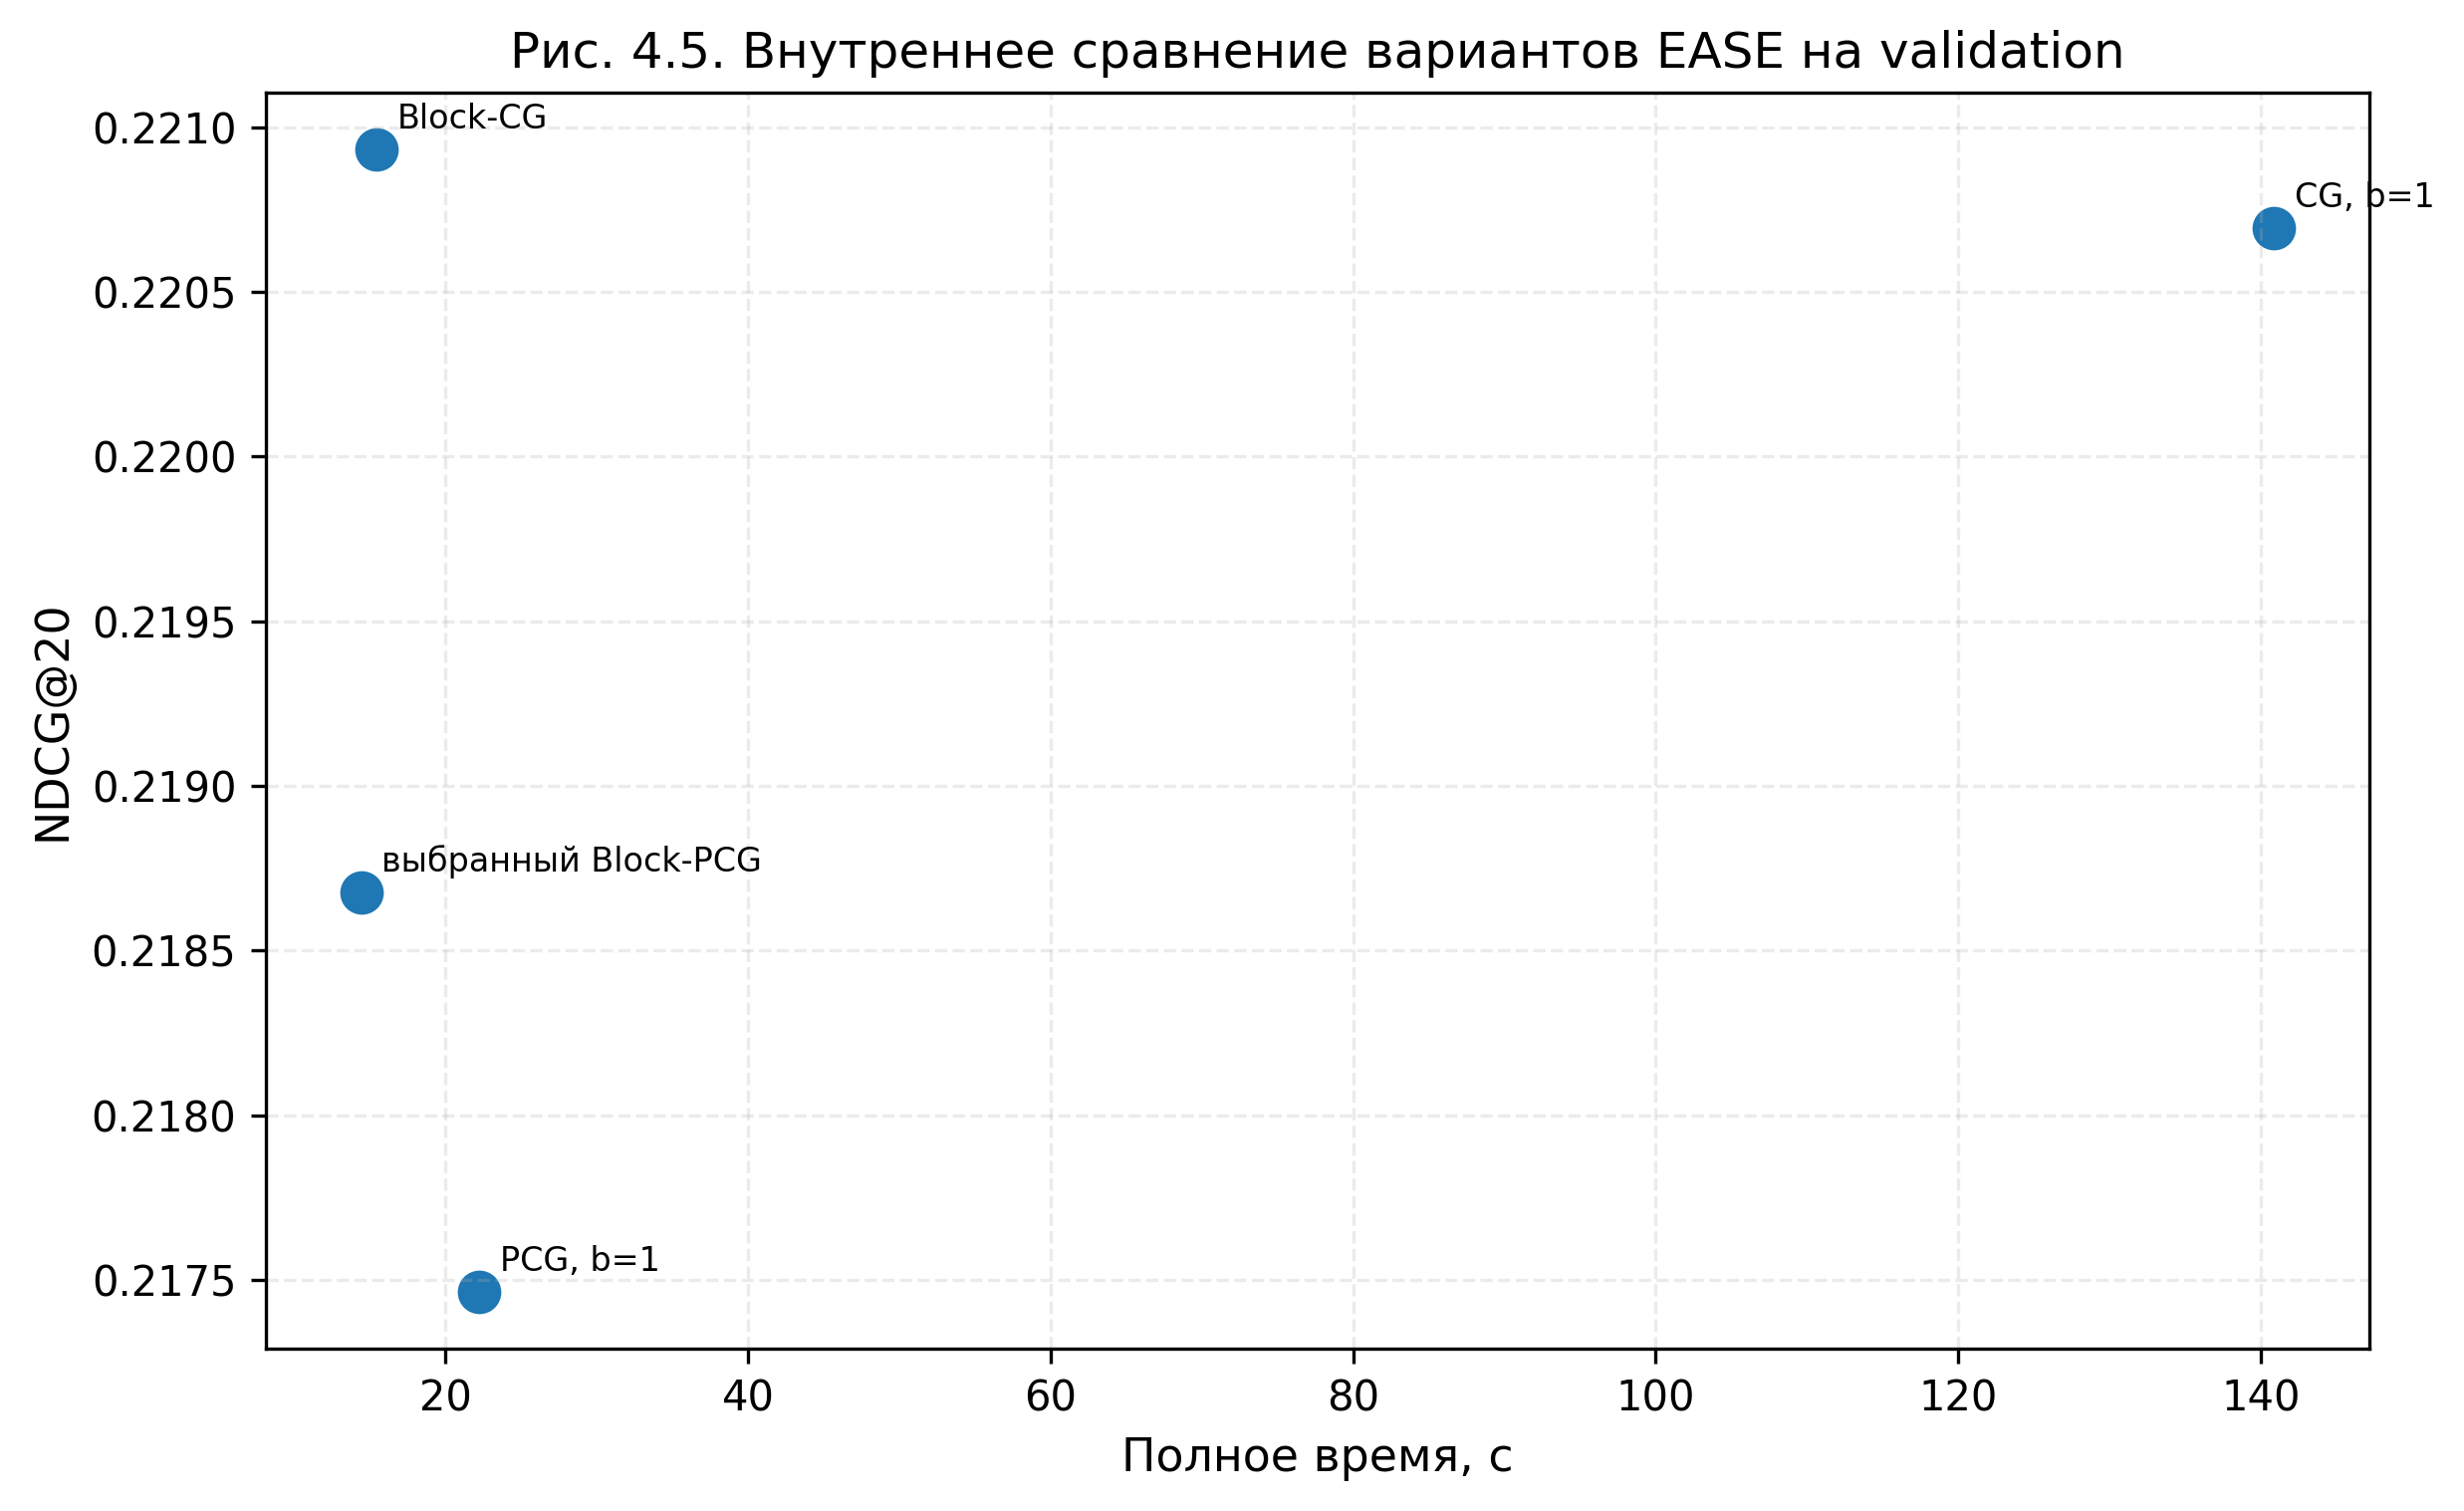

### figures/fig_4_5d_internal_test_refit_comparison.png

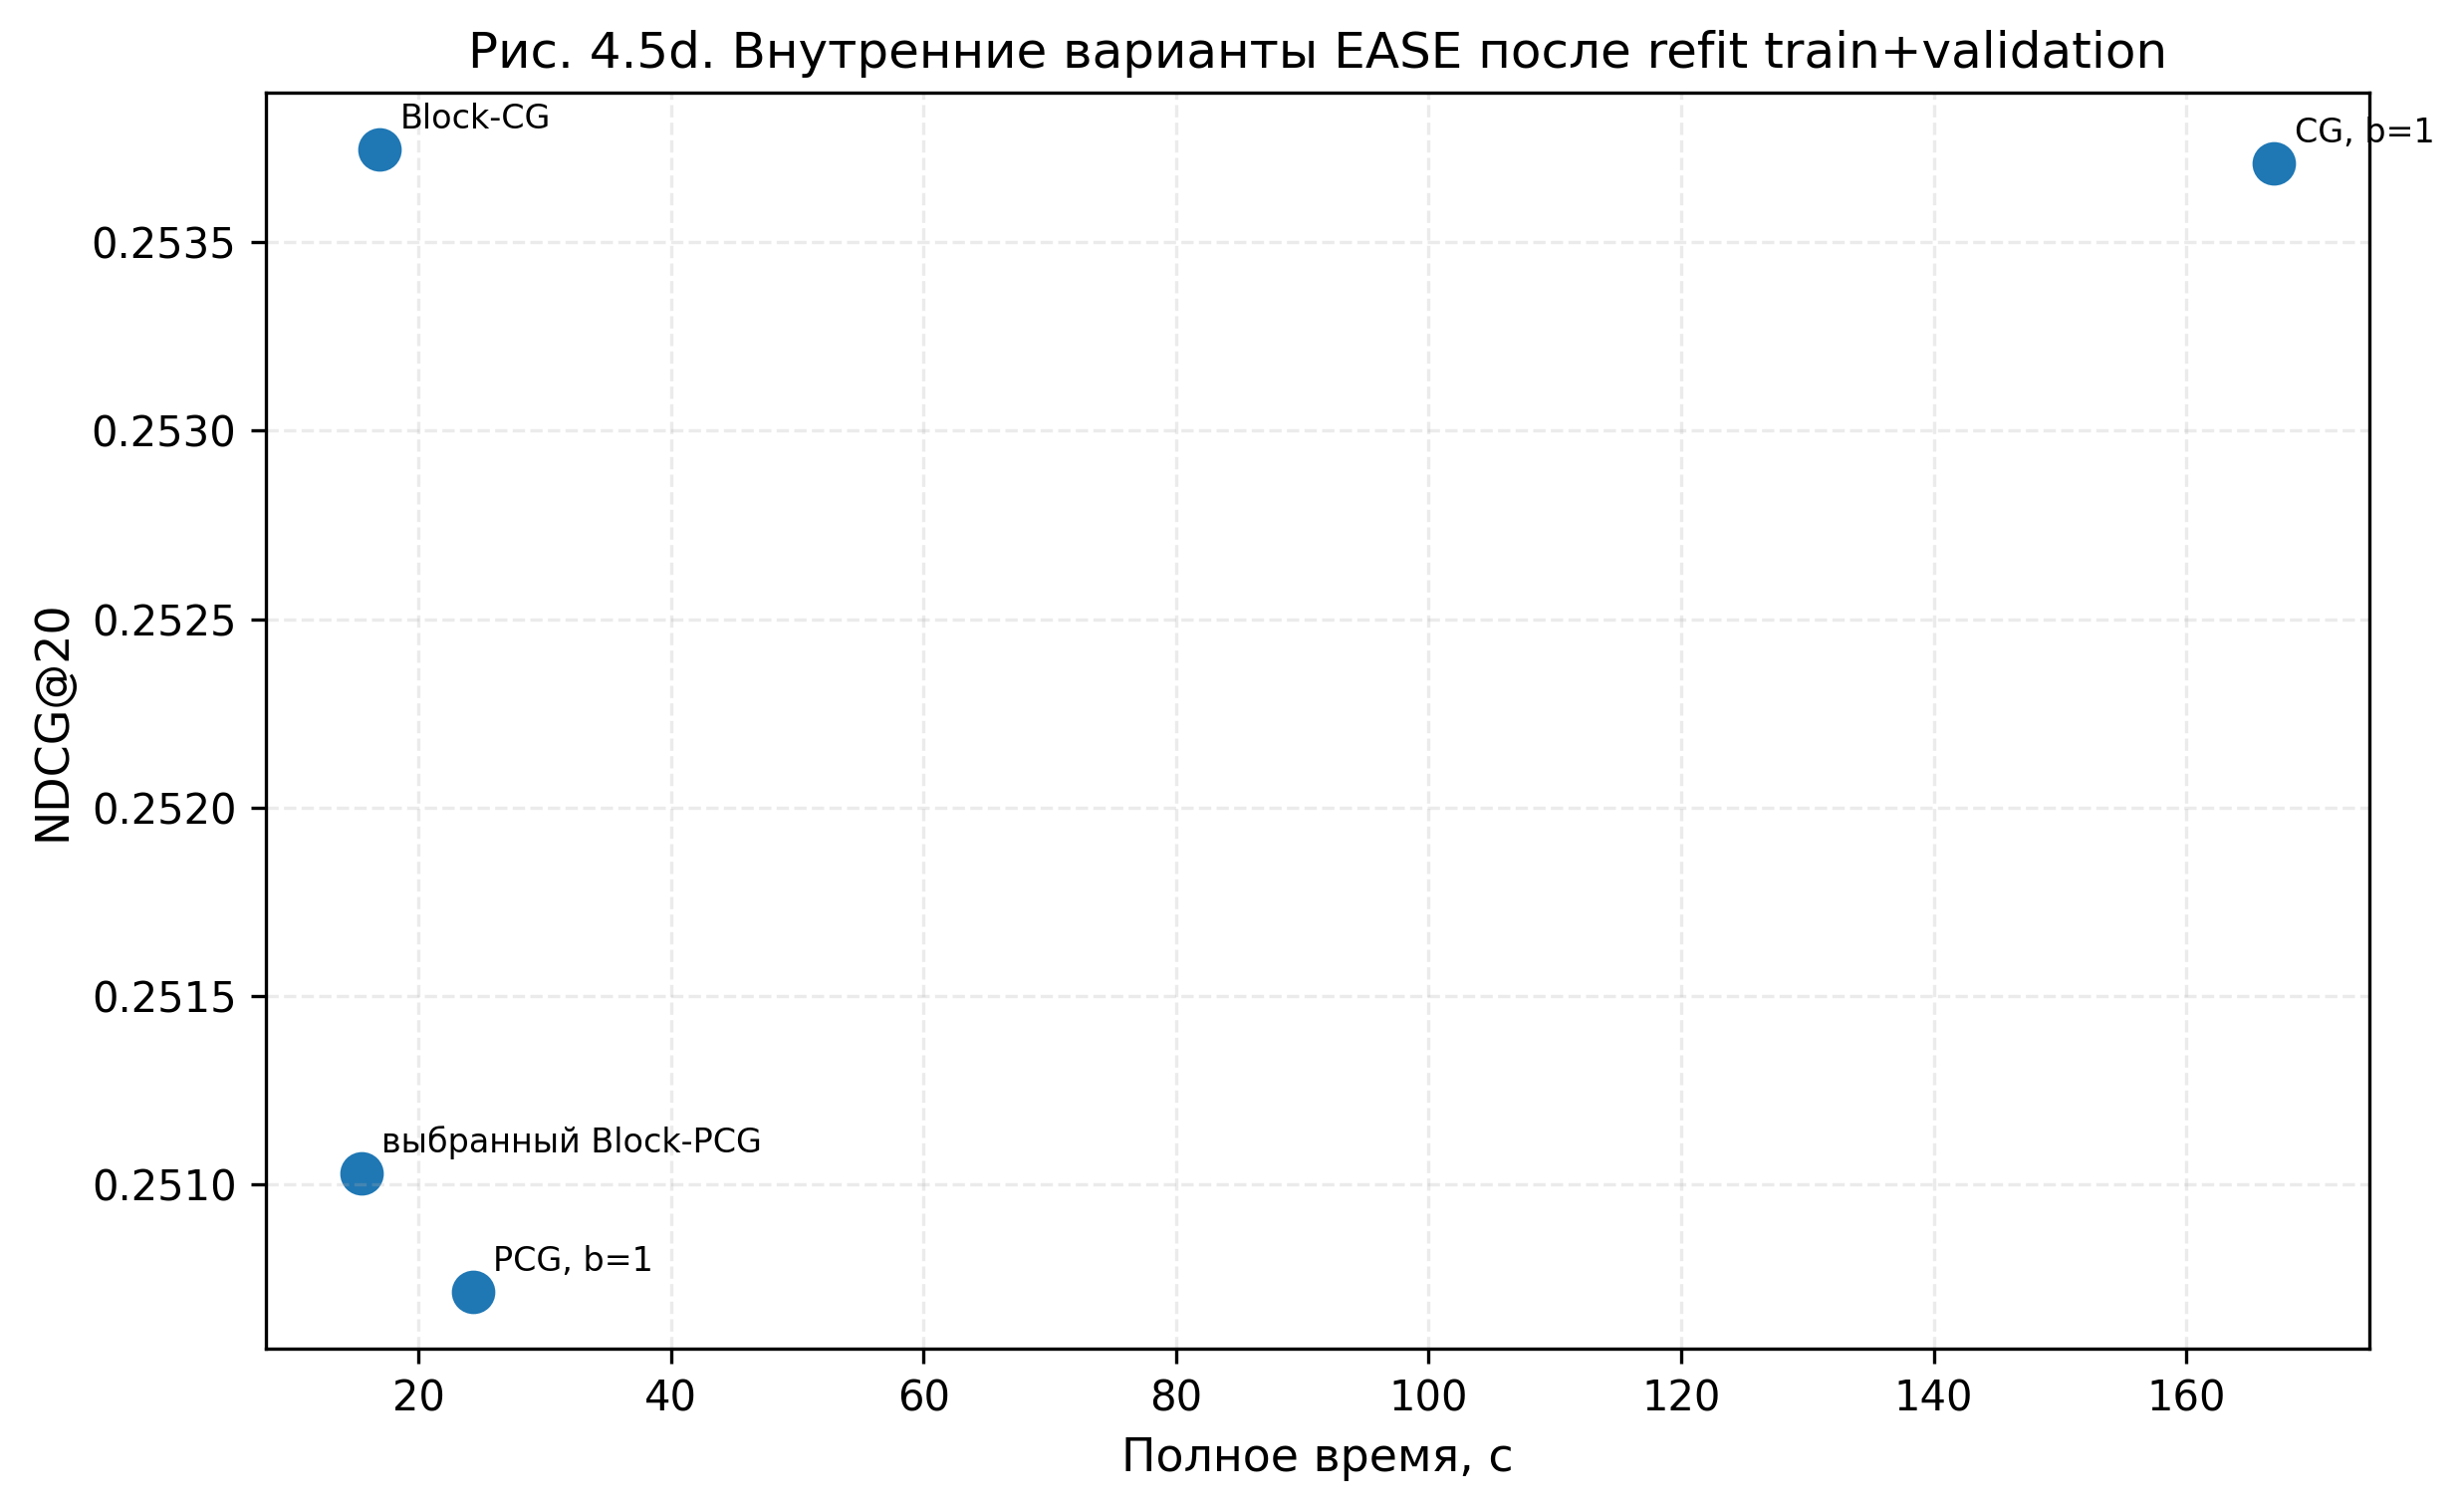

### figures/fig_4_6_final_comparison.png

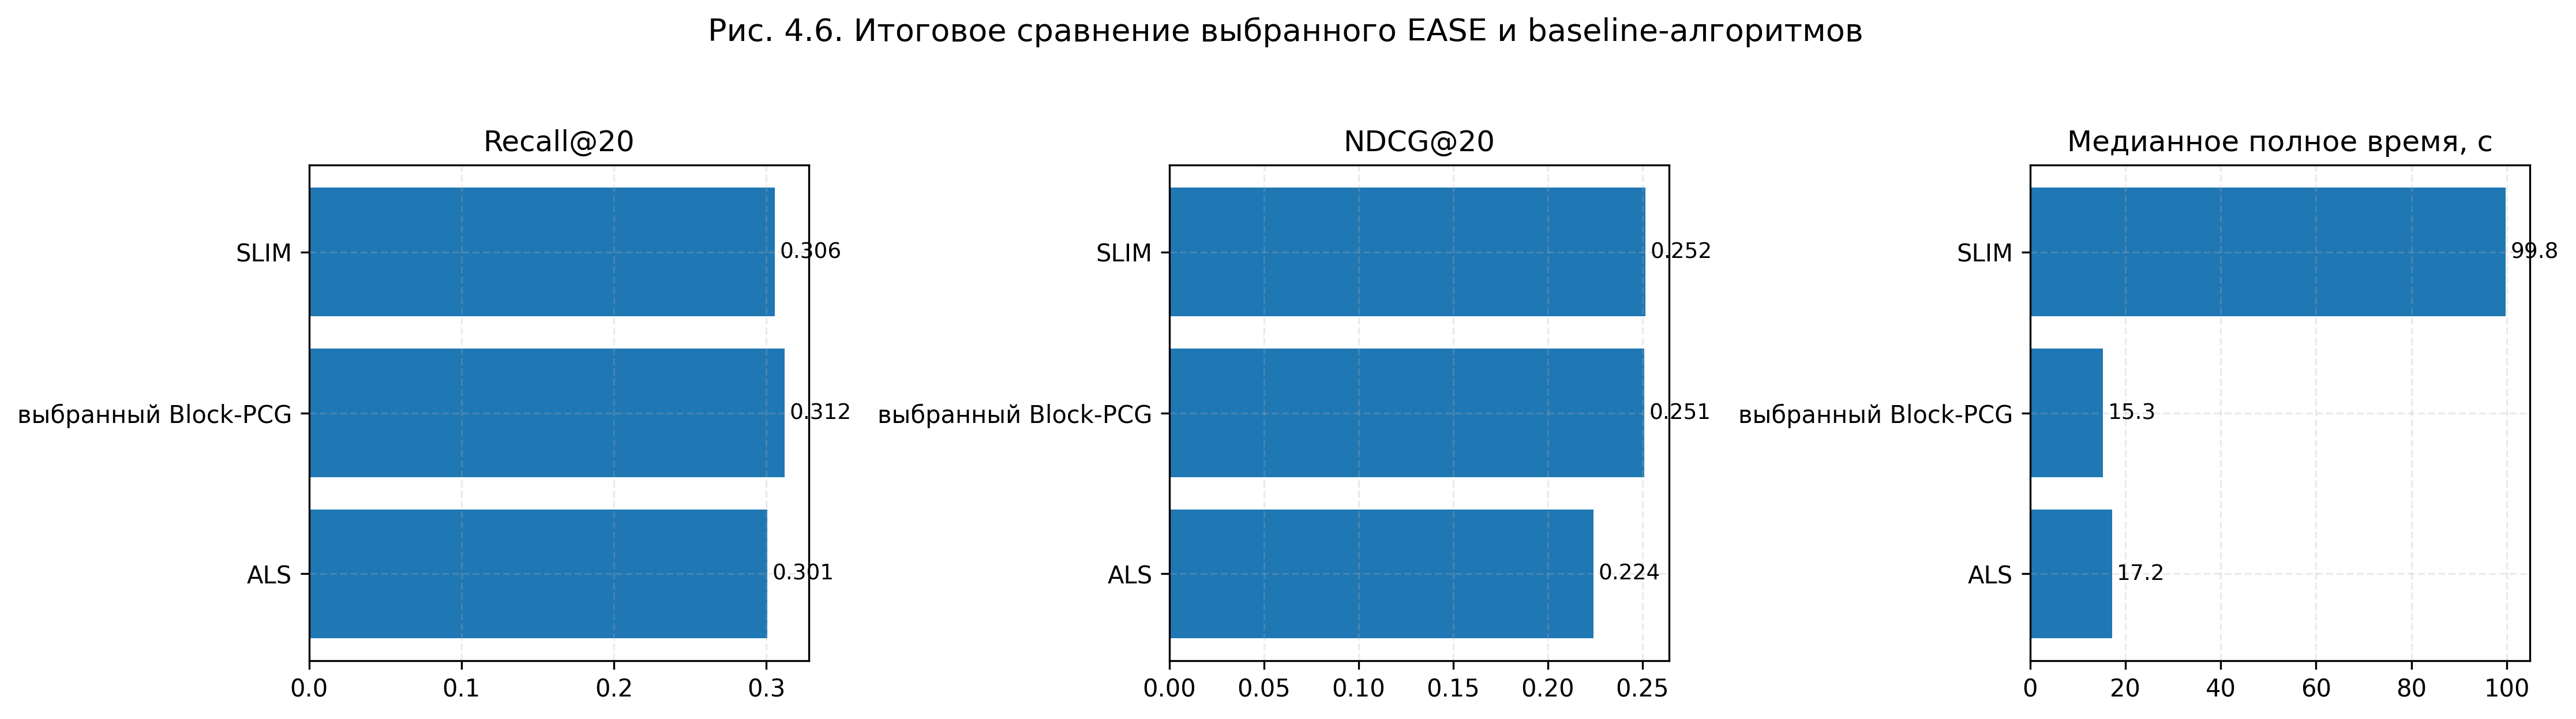

### figures/fig_4_8_topk_stability.png

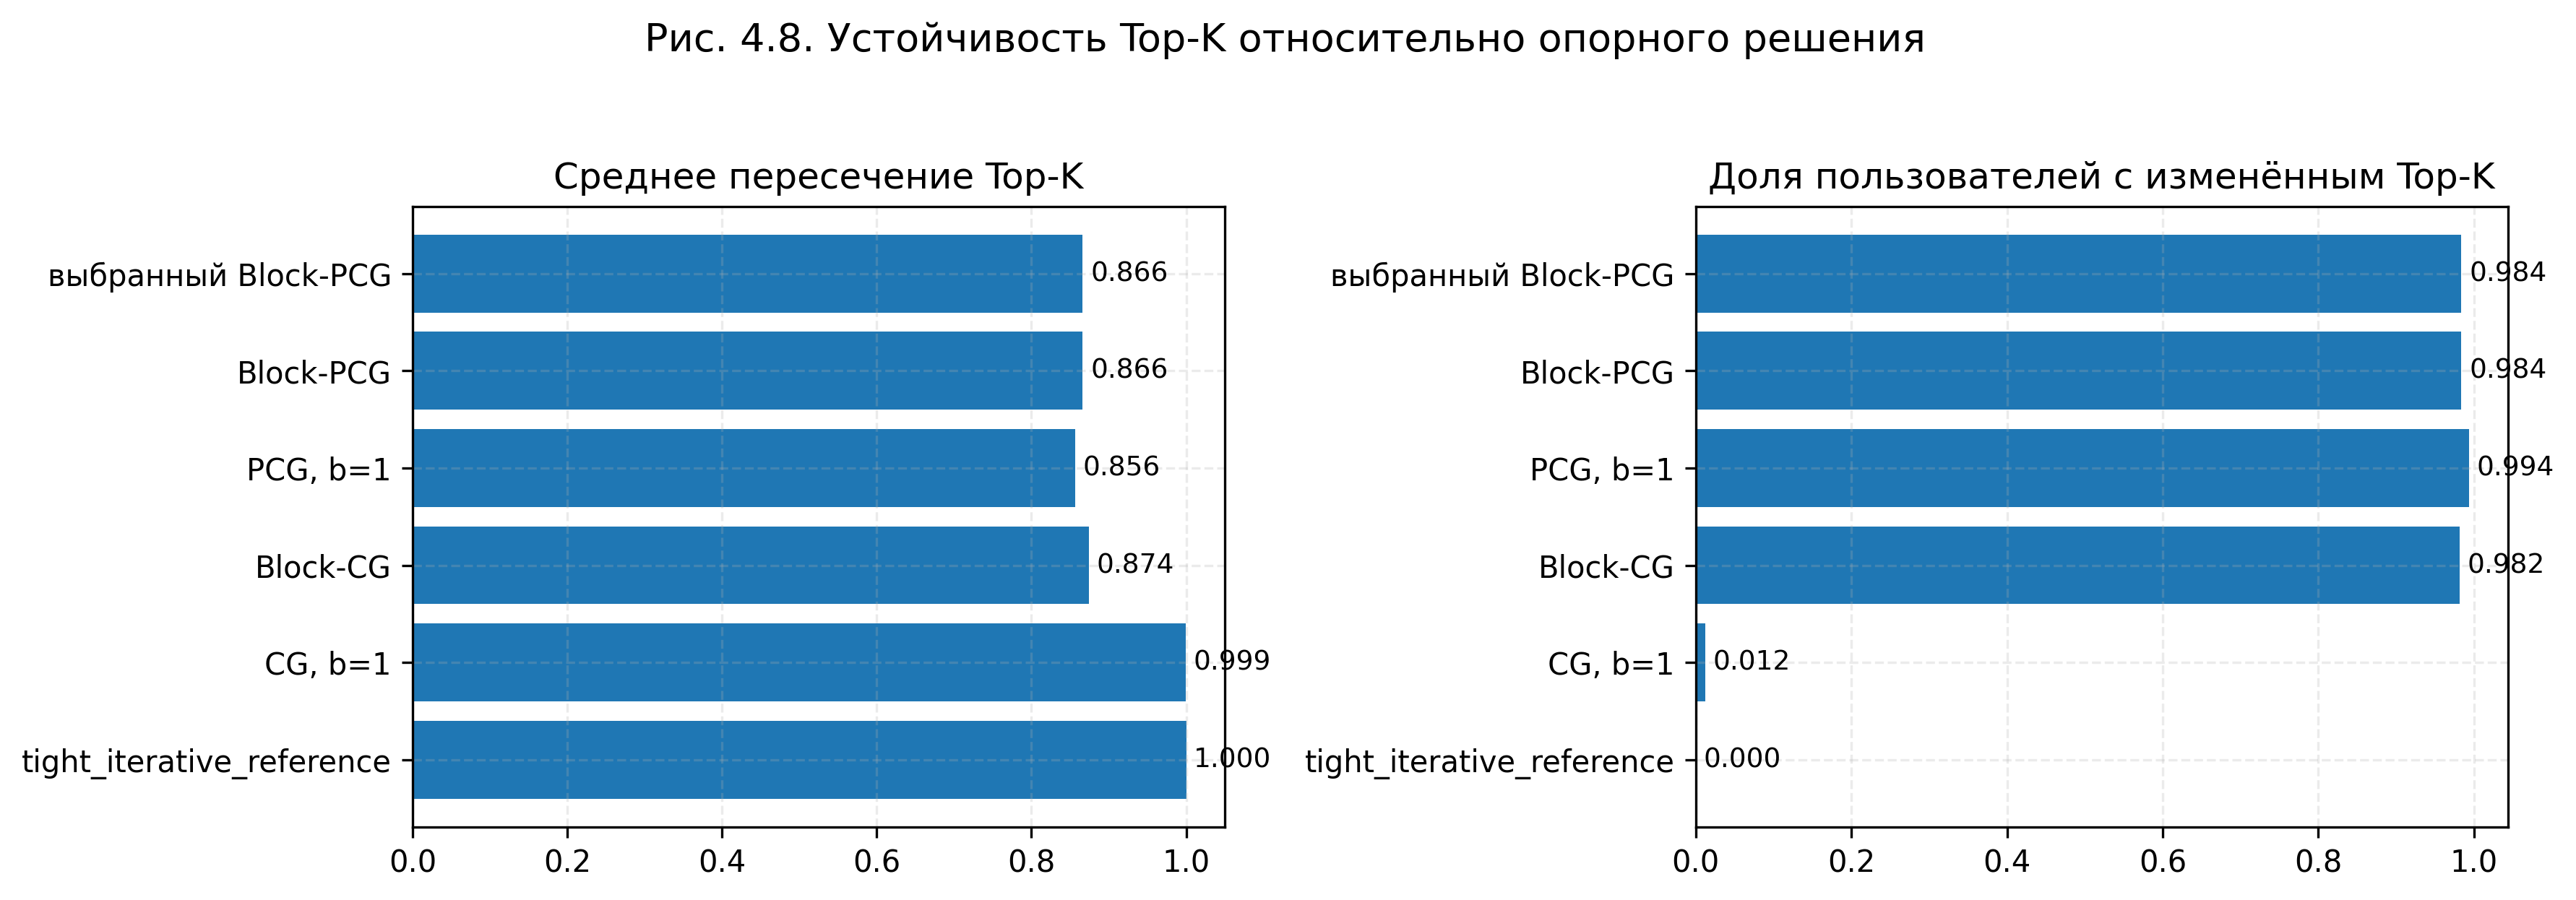

### figures/fig_4_canonical_ablation_quality_time.png

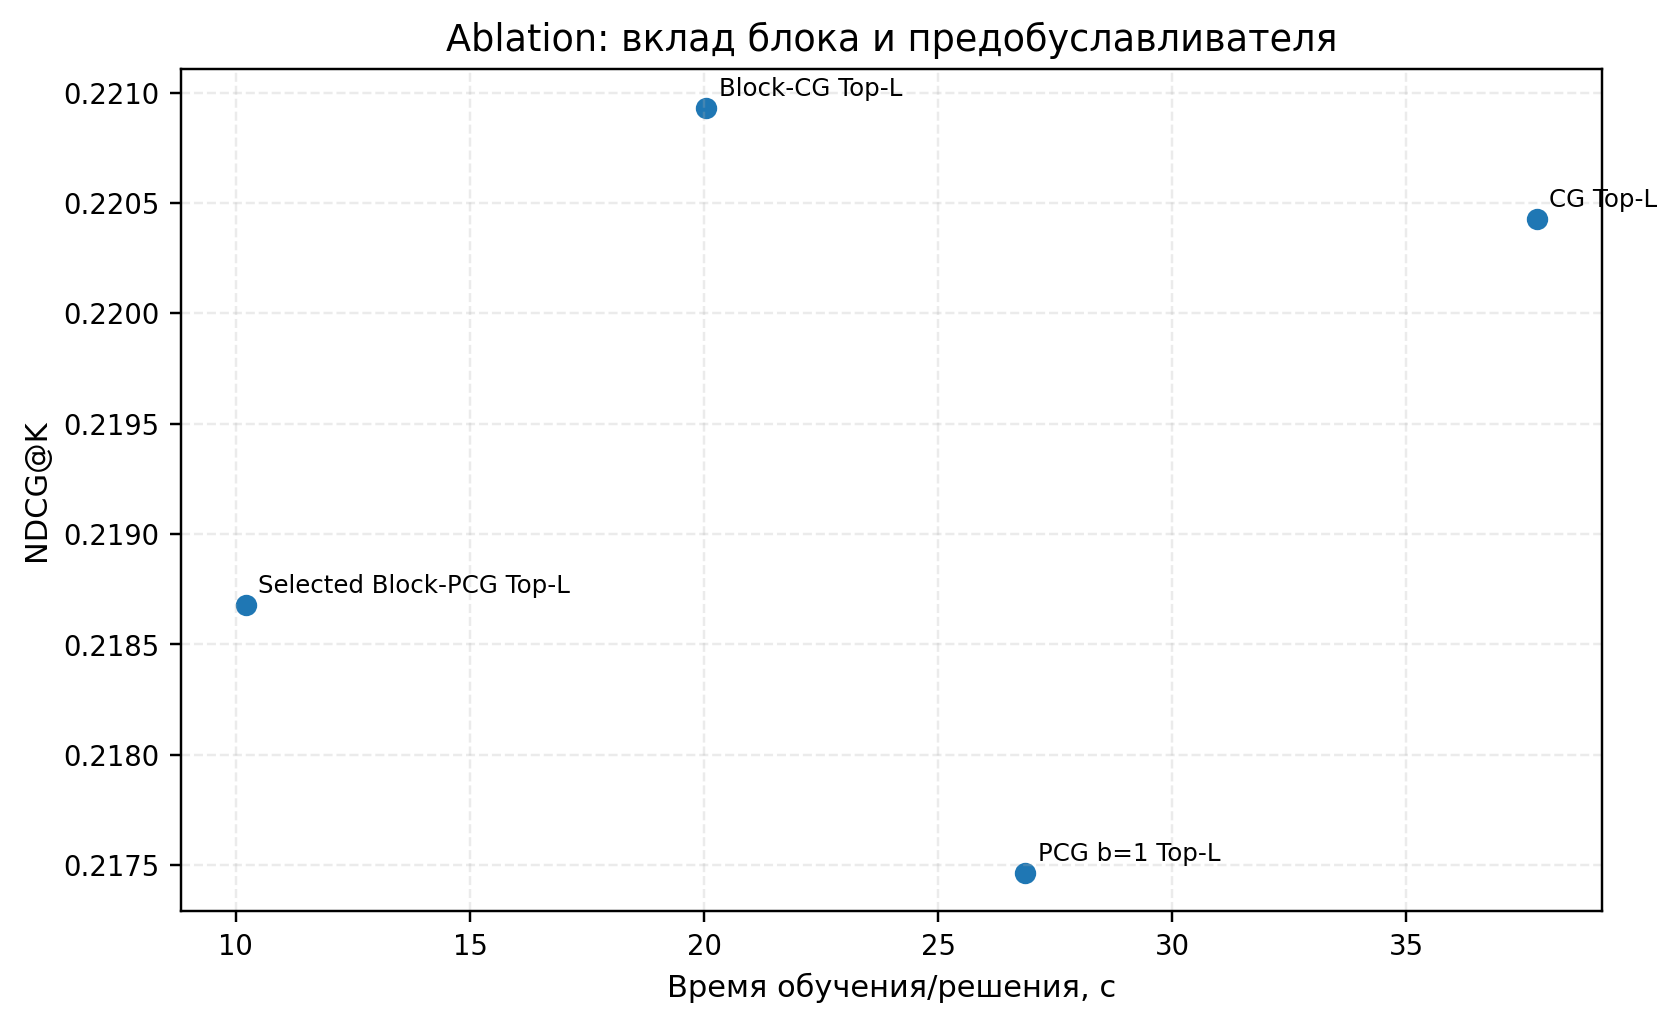

### figures/fig_4_canonical_final_quality.png

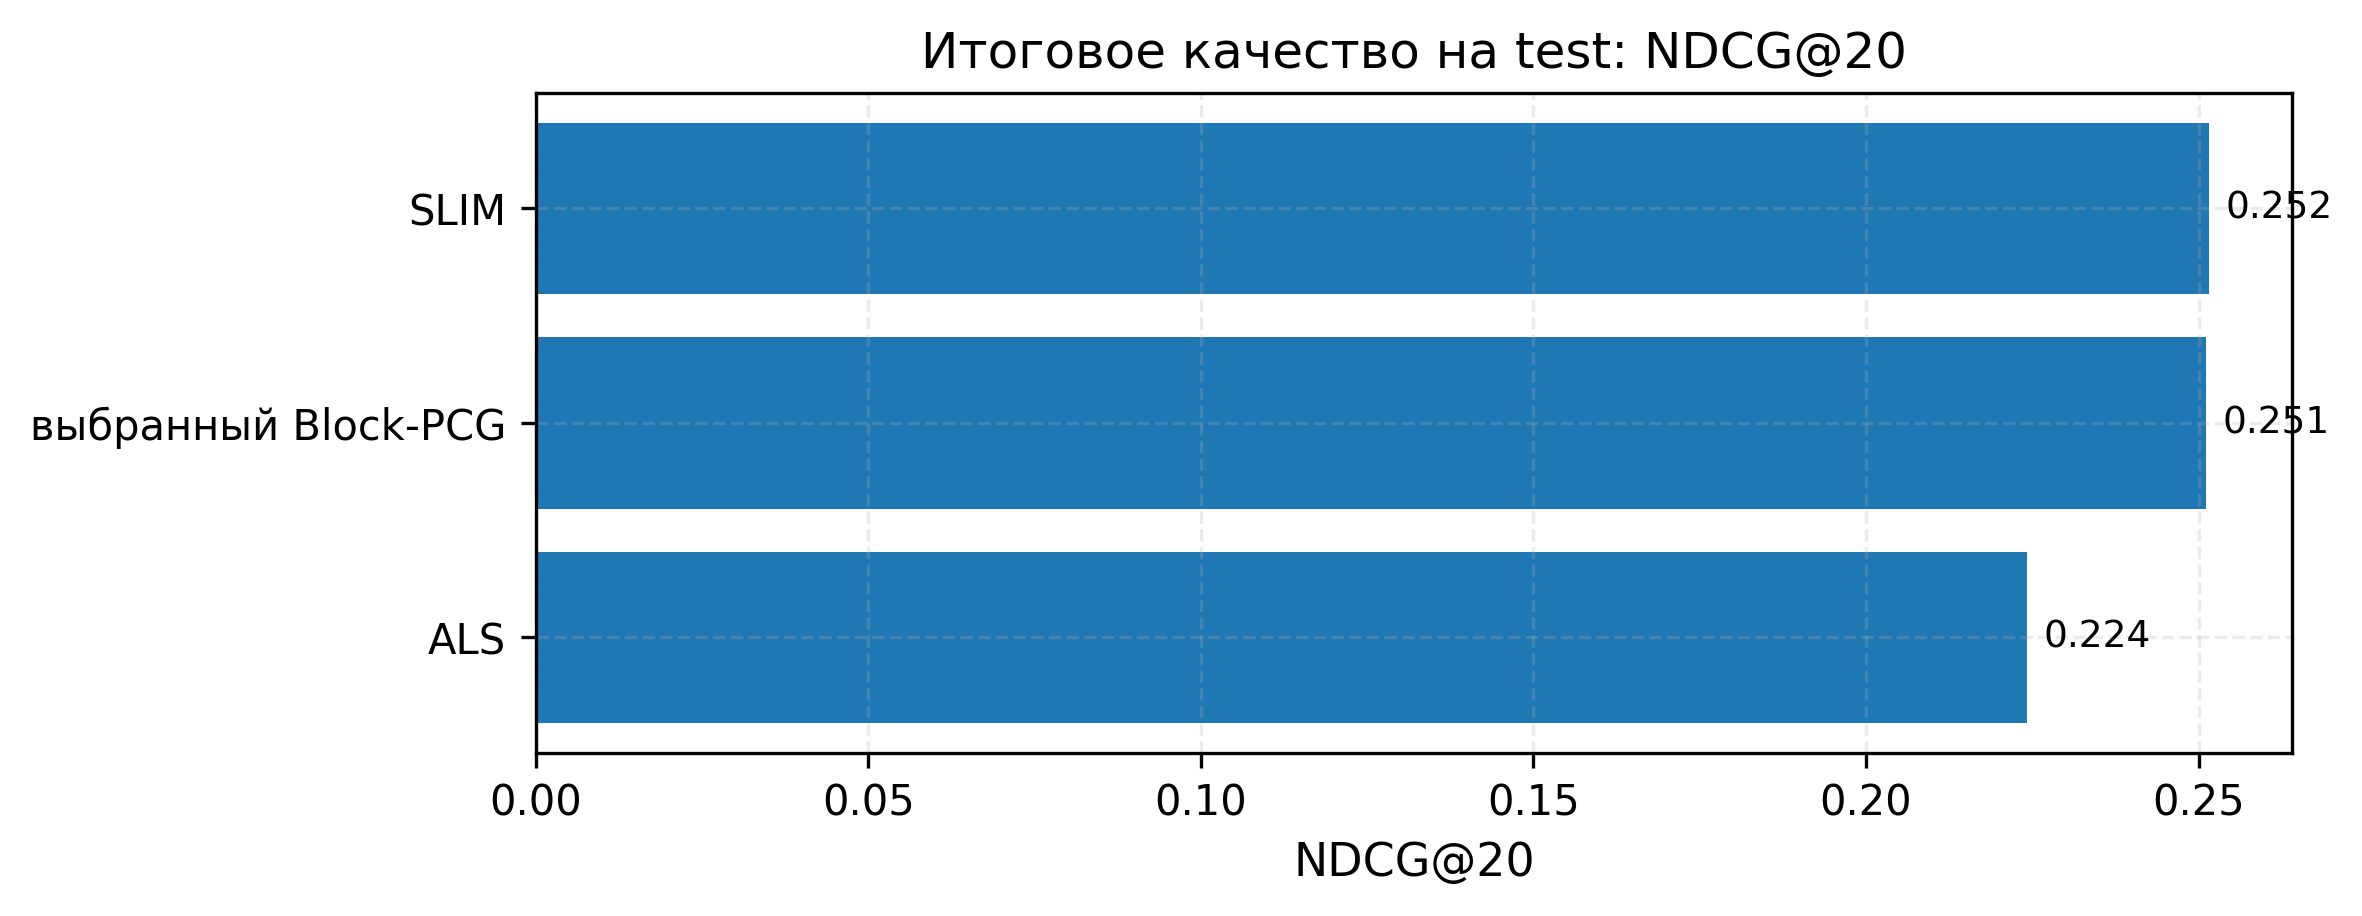

### figures/fig_4_canonical_final_time.png

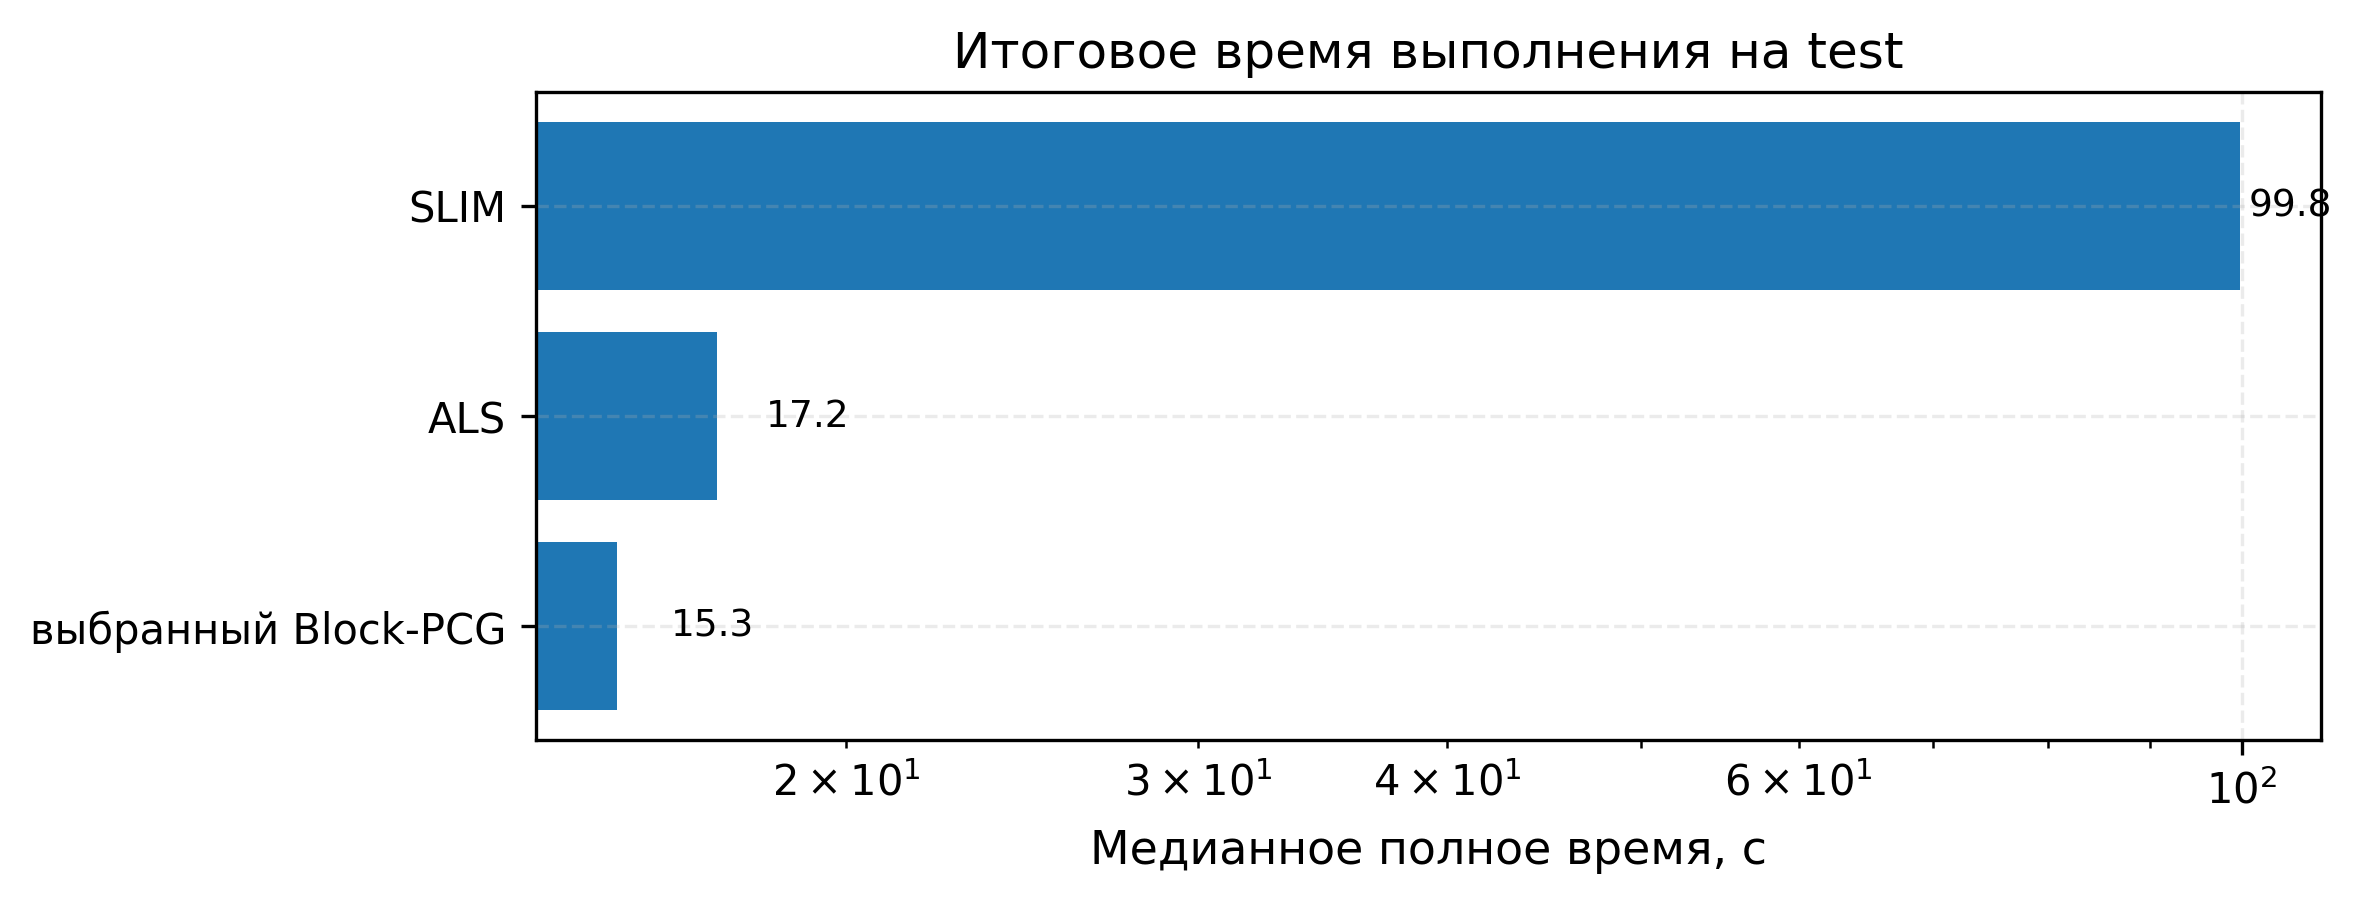

## chapter4_summary.md

# Chapter 4 experimental summary

Selected validation configuration:

- epsilon = 0.1
- selected_solver_family = Block PCG
- selected_method_id = Selected_Block_PCG
- Nyström rank = 128
- block_size = 32
- L_keep = 200
- K = 20
- lambda = 300.0
- quality reference = tight_iterative_top_l_matched

Strict selection rule:

1. Run small exact dense EASE only for algebraic and ranking correctness checks.
2. Keep full dense exact EASE outside the main runtime/quality comparison.
3. Use a top-L-matched tight iterative reference for selecting numerical parameters.
4. Use only ALS and SLIM as external baselines; extra weak baselines are excluded by protocol.
5. Report full dense exact EASE, when feasible, as a separate control baseline.
5. Choose the fastest acceptable epsilon-rank pair satisfying Recall/NDCG tolerance and q_epsilon >= 0.95.
6. Choose the fastest acceptable rank-block pair under the same validation constraints.
7. Choose the smallest acceptable L_keep by model size.
8. If strict constraints have no feasible row, use explicit fallback and write selection_failure_*.csv diagnostics.
9. Test split is used only after this validation selection.

Additional experiments added relative to the earlier pipeline:

- validation sweep for the EASE regularization parameter lambda;
- validation-tuned ALS baseline grid, with explicit failure/skip reporting if the optional dependency is unavailable;
- external-baseline diagnostics in tables/15b_external_baseline_diagnostics.csv and ALS diagnostics in tables/15c_als_diagnostics.csv;
- hypothesis verdicts in tables/16_hypothesis_verdicts.csv;
- scalability and memory proxy in tables/16b_scalability_memory_proxy.csv and tables/16c_scalability_conclusion.csv;
- split integrity checks;
- matrix-free operator identity check;
- small exact dense-vs-iterative algebraic check;
- conditional full dense exact EASE validation baseline;
- epsilon x rank factor grid;
- rank x block factor grid;
- optional epsilon x rank x block full factorial grid;
- strict selection with explicit non-silent fallback diagnostics when no row satisfies all constraints;
- sparse top-L model storage invariant;
- analytical memory estimate table;
- diagnostic quality ladder separating external baselines, exact/tight EASE, and selected approximate EASE;
- honest selected-method naming: k=0 is reported as Block CG, while positive-rank PCG is reported separately;
- final refit train+validation -> test comparison for all internal EASE variants.

Full dense exact status: not available.
ALS baseline status: enabled. Detailed ALS diagnostics: tables/15c_als_diagnostics.csv.
Selected-method note: Strict validation constraints selected the final configuration..
Selection used fallback: False. Fallback contexts: [].


## selection_diagnostics.json

{
  "fallback_contexts": [],
  "failure_tables": [],
  "policy": "min_constraint_violation_then_time",
  "selected_config_uses_fallback": false
}


## text_blocks/01_methodological_note_for_chapter4.md

...

,status,count
0,ok,6


### tables/16e_measured_memory_table.csv

,method,protocol,n_items,model_size_mb,peak_incremental_memory_gb,memory_metric_note,status
0,ALS implicit,B_refit_train_plus_valid,3533,NaN,0.004868,Process RSS diagnostic. Use peak_incremental_memory_gb as an empirical incremental peak and analytical_memory_estimate.csv for algorithmic memory.,ok
1,SLIM-ElasticNet,B_refit_train_plus_valid,3533,NaN,0.115936,Process RSS diagnostic. Use peak_incremental_memory_gb as an empirical incremental peak and analytical_memory_estimate.csv for algorithmic memory.,ok
2,Selected_Block_PCG,B_refit_train_plus_valid,3533,8.063255,0.039871,Process RSS diagnostic. Use peak_incremental_memory_gb as an empirical incremental peak and analytical_memory_estimate.csv for algorithmic memory.,ok
3,Selected_Block_PCG,A_train_only,3533,8.022057,0.025650,Process RSS diagnostic. Use peak_incremental_memory_gb as an empirical incremental peak and analytical_memory_estimate.csv for algorithmic memory.,ok


**Status counts**

,status,count
0,ok,4


In [31]:
# 17. Inline display

print("Results directory:", run_dir)

def display_table_diagnostics(rel: str, max_failed_rows: int = 8):
    p = run_dir / rel
    display(Markdown(f"### {rel}"))
    if not p.exists():
        display(Markdown("`not created`"))
        return

    df = pd.read_csv(p)
    if df.empty:
        display(Markdown("`empty table`"))
        return

    display(df)

    if "status" in df.columns:
        display(Markdown("**Status counts**"))
        display(df["status"].value_counts(dropna=False).rename_axis("status").reset_index(name="count"))

        bad = df[df["status"].astype(str).isin(["failed", "skipped"])].copy()
        if not bad.empty:
            cols = [c for c in ["spec_id", "method", "family", "experiment_name", "epsilon", "nystrom_rank", "block_size", "top_l", "warning"] if c in bad.columns]
            display(Markdown("**Failed/skipped diagnostics**"))
            display(bad[cols].head(max_failed_rows))

    if "peak_incremental_memory_gb_mean" in df.columns:
        display(Markdown("`peak_incremental_memory_gb_mean` is a process-RSS diagnostic, not a formal memory-complexity estimate."))


show_tables = [
    "tables/01_dataset_stats.csv",
    "tables/02_environment.csv",
    "tables/02b_split_integrity_checks.csv",
    "tables/03_external_baselines_validation.csv",
    "tables/04a_operator_identity_sanity.csv",
    "tables/04_small_exact_correctness.csv",
    "tables/04b_full_dense_exact_validation.csv",
    "tables/04aa_ease_formula_sanity.csv",
    "tables/04c_spectral_correction_proxy.csv",
    "tables/05_reference_iterative_validation.csv",
    "tables/05c_lambda_sweep.csv",
    "tables/05b_reference_vs_full_exact.csv",
    "tables/06_epsilon_sweep.csv",
    "tables/06b_epsilon_rank_factor_grid.csv",
    "tables/07_rank_sweep.csv",
    "tables/08b_rank_block_factor_grid.csv",
    "tables/08_block_sweep.csv",
    "tables/09_lkeep_sweep.csv",
    "tables/09b_analytical_memory_estimate.csv",
    "tables/10_internal_ease_comparison_validation.csv",
    "tables/10b_validation_quality_ladder.csv",
    "tables/11_topk_stability_vs_reference.csv",
    "tables/12_external_baselines_test.csv",
    "tables/13_final_ease_test_protocol.csv",
    "tables/14_internal_ease_comparison_test.csv",
    "tables/14b_internal_ease_comparison_test_refit.csv",
    "tables/15_final_test_comparison.csv",
    "tables/15b_external_baseline_diagnostics.csv",
    "tables/15c_als_diagnostics.csv",
    "tables/16_hypothesis_verdicts.csv",
    "tables/16b_scalability_memory_proxy.csv",
    "tables/16c_scalability_conclusion.csv",
]

# Add dynamically created strict-selection failure diagnostics if fallback was used.
for failure_path in selected_cfg.get("selection_failure_tables", []):
    try:
        failure_rel = str(Path(failure_path).relative_to(run_dir))
    except Exception:
        failure_rel = str(failure_path)
    if failure_rel not in show_tables:
        show_tables.append(failure_rel)


for rel in show_tables:
    display_table_diagnostics(rel)

fig_dir = run_dir / "figures"
if fig_dir.exists():
    for fig_path in sorted(fig_dir.glob("*.png")):
        display(Markdown(f"### figures/{fig_path.name}"))
        display(Image(filename=str(fig_path)))
else:
    display(Markdown("### figures\n`not created`"))

for rel in [
    "chapter4_summary.md",
    "selection_diagnostics.json",
    "text_blocks/01_methodological_note_for_chapter4.md",
    "text_blocks/02_limitations_note_for_chapter4.md",
    "text_blocks/03_topk_stability_note.md",
]:
    p = run_dir / rel
    display(Markdown(f"## {rel}"))
    if p.exists():
        display(Markdown(p.read_text(encoding="utf-8")))
    else:
        display(Markdown("`not created`"))


# Added preflight/coverage tables.
display_table_diagnostics("tables/02c_dependency_preflight.csv")
display_table_diagnostics("tables/02d_protocol_preflight.csv")
display_table_diagnostics("tables/16d_protocol_coverage_audit.csv")


# Canonical protocol additions.
for rel in [
    "tables/12b_full_dense_exact_test.csv",
    "tables/12c_external_baselines_test_multicutoff.csv",
    "tables/15d_final_metric_bootstrap_ci.csv",
    "tables/15e_final_timing_repeats.csv",
    "tables/11b_rank_stabilization_curve.csv",
    "tables/16e_measured_memory_table.csv",
]:
    if (run_dir / rel).exists():
        display_table_diagnostics(rel)


### Исправление графиков без пересчёта экспериментов

Исправлены только графики и подписи. Ячейка `14. Publication-quality figures for Chapter 4 — cleaned graph-only version` читает уже сохранённые CSV/JSON из `run_dir` и сохраняет рисунки в `run_dir / "figures"`.

Исправлены графики:
- `fig_4_1_epsilon_selection.*` — выбор порога невязки;
- `fig_4_2_rank_selection.*` — выбор ранга предобуславливателя;
- `fig_4_3_block_selection.*` — выбор ширины блока;
- `fig_4_4_lkeep_selection.*` — выбор `L_keep`;
- `fig_4_5_internal_validation_comparison.*` и `fig_4_5d_internal_test_refit_comparison.*` — сравнение вариантов EASE;
- `fig_4_6_final_comparison.*`, `fig_4_canonical_final_quality.*`, `fig_4_canonical_final_time.*` — итоговое сравнение на test;
- `fig_4_8_topk_stability.*`, `fig_4_10_spectral_proxy.*` и heatmap-графики `fig_4_11`–`fig_4_14`.

Исправлены подписи методов: `Selected_Block_PCG` и варианты `Selected ...` отображаются как `Block-PCG`; технические термины `Recall@20`, `NDCG@20`, `ALS`, `SLIM`, `KNN`, `EASE`, `CG`, `PCG`, `Block-PCG` сохранены.

Безопасно перезапускать только графическую ячейку раздела 14, отключённые no-op ячейки 14.1/14.2 и inline-display ячейки, которые читают готовые таблицы/картинки. Ячейки обучения моделей, sweeps, ALS/SLIM/KNN/Popularity, Block-PCG/CG/PCG и final test не запускались и не нужны для этой правки.

Отсутствующих CSV для построенных графиков не обнаружено.
